#### This document is for analysis on FACT-E emotional well being (EWB).

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import re

# Preliminary

In [2]:
# Read the CSV file - linked file 
file_path = "Merged_TSQIC_REDCap_ACCESS.xlsx" 
df = pd.read_excel(file_path)
df

,id,operation_date,redcap_event_name,qol_date,age_diagnosis,dob,overall_primary_tumour,overall_regional_ln,overall_distant_metastasis,neotx___notx,...,a_e5,a_e6,a_e7,a_c6,a_c2,a_act11,readmission_30d,postop_comp,los,DischargeDate
0,1,NaT,baseline_arm_1,NaT,NaN,1949-08-04,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,2012-04-27
1,1,2011-08-26,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011-08-26
2,1,2010-02-20,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.0,2010-03-08
3,1,2009-02-25,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,2009-03-05
4,1,2008-02-22,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.0,2008-03-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11934,1788,NaT,baseline_arm_1,NaT,NaN,1947-03-23,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
11935,1788,NaT,baseline_arm_1,2025-06-09,NaN,NaT,NaN,NaN,NaN,NaN,...,0.0,2.0,0.0,2.0,2.0,0.0,NaN,NaN,NaN,NaT
11936,1788,NaT,baseline_arm_1,NaT,NaN,NaT,3,1,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
11937,1789,NaT,baseline_arm_1,NaT,NaN,1945-08-19,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT


In [3]:
from datetime import datetime, timedelta

def preprocess_patient_data(df):
    """
    Preprocess patient data with two filtering steps:
    1. Filter out patients under 18 years old (if age information is available)
    2. Filter out patients with expectation_treatment == 1 (if information is available)
    """
    
    # Make a copy to avoid modifying original dataframe
    df_processed = df.copy()
    
    # Step 1: Age filtering (keep patients >= 18 years old)
    print("Step 1: Filtering patients by age...")
    
    # Get current date for age calculation
    current_date = datetime.now()
    
    # Group by patient id to check age information
    patient_groups = df_processed.groupby('id')
    patients_to_keep = []
    
    for patient_id, group in patient_groups:
        keep_patient = True
        
        # Check dob column first
        dob_available = group['dob'].notna().any()
        
        if dob_available:
            # Get the first non-null dob value
            dob = group['dob'].dropna().iloc[0]
            # Calculate age
            age_years = (current_date - dob).days / 365.25
            
            # Check if age is negative (invalid DOB data)
            if age_years < 0:
                # Check age_diagnosis column as fallback
                age_diag_available = group['age_diagnosis'].notna().any()
                
                if age_diag_available:
                    age_diagnosis = group['age_diagnosis'].dropna().iloc[0]
                    if age_diagnosis < 18:
                        keep_patient = False
                        print(f"Patient {patient_id}: Filtered out (age from diagnosis: {age_diagnosis} years)")
                # If no age_diagnosis available, keep patient (no valid age info)
            
            elif age_years < 18:
                keep_patient = False
                print(f"Patient {patient_id}: Filtered out (age from dob: {age_years:.1f} years)")
        
        else:
            # Check age_diagnosis column if dob is not available
            age_diag_available = group['age_diagnosis'].notna().any()
            
            if age_diag_available:
                # Get the first non-null age_diagnosis value
                age_diagnosis = group['age_diagnosis'].dropna().iloc[0]
                
                if age_diagnosis < 18:
                    keep_patient = False
                    print(f"Patient {patient_id}: Filtered out (age from diagnosis: {age_diagnosis} years)")
        
        # If patient should be kept, add all their rows
        if keep_patient:
            patients_to_keep.extend(group.index.tolist())
    
    # Filter dataframe to keep only selected patients
    df_processed = df_processed.loc[patients_to_keep]
    print(f"After age filtering: {len(df_processed)} rows remaining")
    
    # Step 2: expectation_treatment filtering (keep only patients with expectation_treatment == 1)
    print("\nStep 2: Filtering patients by expectation_treatment...")
    
    # Group by patient id again for expectation_treatment check
    patient_groups = df_processed.groupby('id')
    patients_to_keep = []
    
    for patient_id, group in patient_groups:
        keep_patient = True
        
        # Check if expectation_treatment column exists and has data for this patient
        if 'expectation_treatment' in group.columns:
            expectation_available = group['expectation_treatment'].notna().any()
            
            if expectation_available:
                # Check if any row has expectation_treatment == 1
                has_expectation_treatment = (group['expectation_treatment'] == 1).any()
                
                if not has_expectation_treatment:
                    keep_patient = False
                    print(f"Patient {patient_id}: Filtered out (no expectation_treatment == 1)")
        
        # If patient should be kept, add all their rows
        if keep_patient:
            patients_to_keep.extend(group.index.tolist())
    
    # Filter dataframe to keep only selected patients
    df_processed = df_processed.loc[patients_to_keep]
    print(f"After expectation_treatment filtering: {len(df_processed)} rows remaining")
    
    return df_processed

# Optional: Function to get summary statistics
def get_filtering_summary(df_original, df_filtered):
    """
    Print summary of filtering results
    """
    original_patients = df_original['id'].nunique()
    filtered_patients = df_filtered['id'].nunique()
    original_rows = len(df_original)
    filtered_rows = len(df_filtered)
    
    print(f"\n=== Filtering Summary ===")
    print(f"Original patients: {original_patients}")
    print(f"Filtered patients: {filtered_patients}")
    print(f"Patients removed: {original_patients - filtered_patients}")
    print(f"Original rows: {original_rows}")
    print(f"Filtered rows: {filtered_rows}")
    print(f"Rows removed: {original_rows - filtered_rows}")

# Example usage:
df_filtered = preprocess_patient_data(df)
get_filtering_summary(df, df_filtered)

Step 1: Filtering patients by age...
Patient 62: Filtered out (age from dob: 0.3 years)
Patient 68: Filtered out (age from dob: 2.4 years)
Patient 112: Filtered out (age from dob: 6.8 years)
Patient 130: Filtered out (age from dob: 0.0 years)
Patient 143: Filtered out (age from dob: 0.0 years)
Patient 159: Filtered out (age from dob: 8.0 years)
Patient 163: Filtered out (age from dob: 6.9 years)
Patient 181: Filtered out (age from dob: 5.2 years)
Patient 205: Filtered out (age from dob: 0.2 years)
Patient 385: Filtered out (age from dob: 9.2 years)
Patient 467: Filtered out (age from dob: 1.5 years)
Patient 600: Filtered out (age from dob: 1.5 years)
Patient 660: Filtered out (age from dob: 1.6 years)
Patient 1248: Filtered out (age from dob: 2.9 years)
After age filtering: 11838 rows remaining

Step 2: Filtering patients by expectation_treatment...
Patient 8: Filtered out (no expectation_treatment == 1)
Patient 59: Filtered out (no expectation_treatment == 1)
Patient 1179: Filtered ou

In [4]:
def preprocess_patient_data(df):
    """
    Preprocess patient data with expectation_treatment filtering:
    Filter out patients with expectation_treatment != 1 (if information is available)
    """
    
    # Make a copy to avoid modifying original dataframe
    df_processed = df.copy()
    
    # Step 1: expectation_treatment filtering (keep only patients with expectation_treatment == 1)
    print("Step 1: Filtering patients by expectation_treatment...")
    
    # Group by patient id again for expectation_treatment check
    patient_groups = df_processed.groupby('id')
    patients_to_keep = []
    
    for patient_id, group in patient_groups:
        keep_patient = True
        
        # Check if expectation_treatment column exists and has data for this patient
        if 'expectation_treatment' in group.columns:
            expectation_available = group['expectation_treatment'].notna().any()
            
            if expectation_available:
                # Check if any row has expectation_treatment == 1
                has_expectation_treatment = (group['expectation_treatment'] == 1).any()
                
                if not has_expectation_treatment:
                    keep_patient = False
                    print(f"Patient {patient_id}: Filtered out (no expectation_treatment == 1)")
        
        # If patient should be kept, add all their rows
        if keep_patient:
            patients_to_keep.extend(group.index.tolist())
    
    # Filter dataframe to keep only selected patients
    df_processed = df_processed.loc[patients_to_keep]
    print(f"After expectation_treatment filtering: {len(df_processed)} rows remaining")
    
    return df_processed

# Optional: Function to get summary statistics
def get_filtering_summary(df_original, df_filtered):
    """
    Print summary of filtering results
    """
    original_patients = df_original['id'].nunique()
    filtered_patients = df_filtered['id'].nunique()
    original_rows = len(df_original)
    filtered_rows = len(df_filtered)
    
    print(f"\n=== Filtering Summary ===")
    print(f"Original patients: {original_patients}")
    print(f"Filtered patients: {filtered_patients}")
    print(f"Patients removed: {original_patients - filtered_patients}")
    print(f"Original rows: {original_rows}")
    print(f"Filtered rows: {filtered_rows}")
    print(f"Rows removed: {original_rows - filtered_rows}")

# Example usage:
df_filtered = preprocess_patient_data(df)
get_filtering_summary(df, df_filtered)

Step 1: Filtering patients by expectation_treatment...
Patient 8: Filtered out (no expectation_treatment == 1)
Patient 59: Filtered out (no expectation_treatment == 1)
Patient 1179: Filtered out (no expectation_treatment == 1)
After expectation_treatment filtering: 11914 rows remaining

=== Filtering Summary ===
Original patients: 1773
Filtered patients: 1770
Patients removed: 3
Original rows: 11939
Filtered rows: 11914
Rows removed: 25


In [5]:
df = df_filtered.copy()
df

,id,operation_date,redcap_event_name,qol_date,age_diagnosis,dob,overall_primary_tumour,overall_regional_ln,overall_distant_metastasis,neotx___notx,...,a_e5,a_e6,a_e7,a_c6,a_c2,a_act11,readmission_30d,postop_comp,los,DischargeDate
0,1,NaT,baseline_arm_1,NaT,NaN,1949-08-04,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,2012-04-27
1,1,2011-08-26,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011-08-26
2,1,2010-02-20,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.0,2010-03-08
3,1,2009-02-25,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,2009-03-05
4,1,2008-02-22,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.0,2008-03-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11934,1788,NaT,baseline_arm_1,NaT,NaN,1947-03-23,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
11935,1788,NaT,baseline_arm_1,2025-06-09,NaN,NaT,NaN,NaN,NaN,NaN,...,0.0,2.0,0.0,2.0,2.0,0.0,NaN,NaN,NaN,NaT
11936,1788,NaT,baseline_arm_1,NaT,NaN,NaT,3,1,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
11937,1789,NaT,baseline_arm_1,NaT,NaN,1945-08-19,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT


# Preliminary 2

In [6]:
df['id'].nunique()

1770

In [7]:
# Step 1: Filter rows where redcap_event_name is either "baseline_arm_1" or "preoperative_arm_1"
filtered_df = df[df['redcap_event_name'].isin(["baseline_arm_1", "preoperative_arm_1"])]

# Step 2: Check if each id has both events
event_counts = filtered_df.groupby('id')['redcap_event_name'].nunique()
valid_ids = event_counts[event_counts == 2].index  # Keep only IDs with both events

# Step 3: Ensure all six columns have values (non-null) for these IDs
valid_rows = filtered_df[filtered_df['id'].isin(valid_ids)]
valid_rows = valid_rows.dropna(subset=["ge1", "ge2", "ge3", "ge4", "ge5", "ge6"])

# Step 4: Find IDs that still have both events after removing rows with NaNs
final_ids = valid_rows.groupby('id')['redcap_event_name'].nunique()
final_ids = final_ids[final_ids == 2].index

len(final_ids)


271

In [8]:
# Step 1: Filter relevant rows
filtered_df = df[df['redcap_event_name'].isin(["baseline_arm_1", "preoperative_arm_1", "1_year_postop_arm_1"])]

# Step 2: Ensure each id has required event pairs
event_counts = filtered_df.groupby('id')['redcap_event_name'].apply(set)

# Step 3: Find ids that have the required event pairs
valid_ids = event_counts[event_counts.apply(lambda x: {"baseline_arm_1", "1_year_postop_arm_1"}.issubset(x) or 
                                                        {"preoperative_arm_1", "1_year_postop_arm_1"}.issubset(x))].index

# Step 4: Check if all six columns have non-null values
valid_rows = filtered_df[filtered_df['id'].isin(valid_ids)]
valid_rows = valid_rows.dropna(subset=["ge1", "ge2", "ge3", "ge4", "ge5", "ge6"])

# Step 5: Reconfirm ids still have required event pairs after removing NaNs
final_event_counts = valid_rows.groupby('id')['redcap_event_name'].apply(set)
final_ids = final_event_counts[final_event_counts.apply(lambda x: {"baseline_arm_1", "1_year_postop_arm_1"}.issubset(x) or 
                                                                {"preoperative_arm_1", "1_year_postop_arm_1"}.issubset(x))].index

len(final_ids)


128

In [9]:
# Assuming your dataframe is called 'df' and the ID column is called 'id'
# If your ID column has a different name, replace 'id' with the actual column name

# Step 1: Find IDs that match each condition
# Group by ID and check which events are present
event_groups = df.groupby('id')['redcap_event_name'].unique()

# Condition 1: Has both "baseline_arm_1" and "1_year_postop_arm_1"
cond1_ids = event_groups[
    event_groups.apply(lambda x: all(event in x for event in ["baseline_arm_1", "1_year_postop_arm_1"]))
].index

# Condition 2: Has both "preoperative_arm_1" and "1_year_postop_arm_1"
cond2_ids = event_groups[
    event_groups.apply(lambda x: all(event in x for event in ["preoperative_arm_1", "1_year_postop_arm_1"]))
].index

# Condition 3: Has all three events
cond3_ids = event_groups[
    event_groups.apply(lambda x: all(event in x for event in ["baseline_arm_1", "preoperative_arm_1", "1_year_postop_arm_1"]))
].index

# Combine all matching IDs (using set to avoid duplicates)
matching_ids = set(cond1_ids).union(cond2_ids).union(cond3_ids)

# Step 2: Subset the original dataframe
filtered_df = df[df['id'].isin(matching_ids)]

# See how many unique IDs were found
print(f"Number of matching IDs: {len(matching_ids)}")

# See which events are present in the filtered data
print(filtered_df.groupby('id')['redcap_event_name'].unique())

Number of matching IDs: 192
id
32      [surgery_arm_1, baseline_arm_1, preoperative_a...
76      [baseline_arm_1, surgery_arm_1, preoperative_a...
125     [preoperative_arm_1, baseline_arm_1, surgery_a...
151     [surgery_arm_1, preoperative_arm_1, 1_year_pos...
160     [baseline_arm_1, surgery_arm_1, preoperative_a...
                              ...                        
1648    [1_year_postop_arm_1, surgery_arm_1, baseline_...
1653    [1_year_postop_arm_1, surgery_arm_1, preoperat...
1664    [surgery_arm_1, 1_year_postop_arm_1, baseline_...
1670    [baseline_arm_1, preoperative_arm_1, 1_year_po...
1690    [surgery_arm_1, baseline_arm_1, nan, 1_year_po...
Name: redcap_event_name, Length: 192, dtype: object


In [10]:
# Assuming df is your dataframe with 'id', 'redcap_event_name', and 'ge1' to 'ge6' columns
score_cols = ['ge1', 'ge2', 'ge3', 'ge4', 'ge5', 'ge6']

# Step 1: Filter IDs with required redcap_event_name combinations
id_events = df.groupby('id')['redcap_event_name'].unique().reset_index()
def has_required_events(events):
    events_set = set(events)
    baseline = "baseline_arm_1" in events_set
    preop = "preoperative_arm_1" in events_set
    postop = "1_year_postop_arm_1" in events_set
    return (baseline and postop) or (preop and postop) or (baseline and preop and postop)

valid_ids = id_events[id_events['redcap_event_name'].apply(has_required_events)]['id']
df_filtered = df[df['id'].isin(valid_ids)]

# Step 2: Filter IDs with at least one ge1-ge6 score in the required events
def check_scores_per_id(id_df):
    events = id_df['redcap_event_name'].unique()
    baseline = "baseline_arm_1" in events
    preop = "preoperative_arm_1" in events
    postop = "1_year_postop_arm_1" in events
    has_scores = lambda df: df[score_cols].notna().any().any()
    
    baseline_df = id_df[id_df['redcap_event_name'] == "baseline_arm_1"]
    preop_df = id_df[id_df['redcap_event_name'] == "preoperative_arm_1"]
    postop_df = id_df[id_df['redcap_event_name'] == "1_year_postop_arm_1"]
    
    if baseline and postop:
        if has_scores(baseline_df) and has_scores(postop_df):
            return True
    if preop and postop:
        if has_scores(preop_df) and has_scores(postop_df):
            return True
    if baseline and preop and postop:
        if has_scores(baseline_df) and has_scores(preop_df) and has_scores(postop_df):
            return True
    return False

id_groups = df_filtered.groupby('id')
valid_ids_with_scores = id_groups.filter(check_scores_per_id)['id'].unique()

# Output the result
print("IDs with required events and at least one ge1-ge6 score:", len(valid_ids_with_scores.tolist()))

IDs with required events and at least one ge1-ge6 score: 137


# Analysis

In [11]:
# Step 1: Find eligible IDs (unchanged)
def find_eligible_ids(df):
    id_events = df.groupby('id')['redcap_event_name'].apply(set)
    eligible_ids = []
    for id_val, events in id_events.items():
        has_baseline = "baseline_arm_1" in events
        has_preop = "preoperative_arm_1" in events
        has_one_year = "1_year_postop_arm_1" in events
        if (has_baseline and has_one_year) or (has_preop and has_one_year):
            eligible_ids.append(id_val)
    return eligible_ids

# Step 2: Filter dataset (unchanged)
def filter_eligible_data(df, eligible_ids):
    return df[df['id'].isin(eligible_ids)].copy()

# Step 3: Calculate all subscale scores (unchanged)
def calculate_subscale_score(df, cols, reverse_items=None, subscale_name=""):
    """Calculate subscale scores according to FACT scoring guidelines, only if >=50% items are answered"""
    # Convert to numeric and handle reverse scoring
    for col in cols:
        df[f"{col}_score"] = pd.to_numeric(df[col], errors='coerce')
        if reverse_items and col in reverse_items:
            df[f"{col}_score"] = 4 - df[f"{col}_score"]
    
    # Calculate the number of items and the 50% threshold
    total_items = len(cols)
    min_items_required = total_items / 2  # 50% threshold
    
    # Count non-NaN items for each row
    score_cols = [f"{col}_score" for col in cols]
    num_answered_items = df[score_cols].notna().sum(axis=1)
    
    # Calculate subscale score only if >=50% items are answered
    df[f"{subscale_name}_subscale_score"] = np.where(
        num_answered_items >= min_items_required,
        (df[score_cols].sum(axis=1, skipna=True) * total_items) / 
        df[score_cols].notna().sum(axis=1),
        np.nan
    )
    return df

def calculate_all_scores(df):
    pwb_cols = [f"gp{i}" for i in range(1, 8)]
    swb_cols = [f"gs{i}" for i in range(1, 8)]
    ewb_cols = [f"ge{i}" for i in range(1, 7)]
    fwb_cols = [f"gf{i}" for i in range(1, 8)]
    ecs_cols = [f"a_hn{i}" for i in range(1, 6)] + ["a_hn7", "a_hn10"] + \
                [f"a_e{i}" for i in range(1, 8)] + ["a_c6", "a_c2", "a_act11"]

    pwb_reverse = pwb_cols
    ewb_reverse = [f"ge{i}" for i in range(1, 7) if i != 2]
    ecs_reverse = ["a_e1", "a_e2", "a_e3", "a_e4", "a_e5", "a_e7", "a_act11", 
                    "a_c2", "a_hn2", "a_hn3"]

    df = calculate_subscale_score(df, pwb_cols, pwb_reverse, "pwb")
    df = calculate_subscale_score(df, swb_cols, None, "swb")
    df = calculate_subscale_score(df, ewb_cols, ewb_reverse, "ewb")
    df = calculate_subscale_score(df, fwb_cols, None, "fwb")
    df = calculate_subscale_score(df, ecs_cols, ecs_reverse, "ecs")

    # Calculate composite scores with both conditions
    # 1. FACT-G Total (PWB + SWB + EWB + FWB)
    fact_g_items = pwb_cols + swb_cols + ewb_cols + fwb_cols  # 27 items
    fact_g_item_cols = [f"{col}_score" for col in fact_g_items]
    fact_g_num_answered = df[fact_g_item_cols].notna().sum(axis=1)
    fact_g_min_items = 22  # 80% of 27 items = 21.6, rounded up to 22
    
    df['fact_g_total'] = np.where(
        # Condition 1: All subscales must be non-NaN (already ensures 50% of items per subscale)
        (df["pwb_subscale_score"].notna()) & 
        (df["swb_subscale_score"].notna()) & 
        (df["ewb_subscale_score"].notna()) & 
        (df["fwb_subscale_score"].notna()) &
        # Condition 2: At least 80% of FACT-G items must be answered
        (fact_g_num_answered >= fact_g_min_items),
        df["pwb_subscale_score"] + df["swb_subscale_score"] + 
        df["ewb_subscale_score"] + df["fwb_subscale_score"],
        np.nan
    )
    
    # 2. FACT-E Total (FACT-G + ECS)
    fact_e_items = fact_g_items + ecs_cols  # 27 + 17 = 44 items
    fact_e_item_cols = [f"{col}_score" for col in fact_e_items]
    fact_e_num_answered = df[fact_e_item_cols].notna().sum(axis=1)
    fact_e_min_items = 36  # 80% of 44 items = 35.2, rounded up to 36
    
    df['fact_e_total'] = np.where(
        # Condition 1: FACT-G and ECS must be non-NaN
        (df['fact_g_total'].notna()) & 
        (df["ecs_subscale_score"].notna()) &
        # Condition 2: At least 80% of FACT-E items must be answered
        (fact_e_num_answered >= fact_e_min_items),
        df['fact_g_total'] + df["ecs_subscale_score"],
        np.nan
    )
    
    # 3. TOI (PWB + FWB + ECS)
    toi_items = pwb_cols + fwb_cols + ecs_cols  # 7 + 7 + 17 = 31 items
    toi_item_cols = [f"{col}_score" for col in toi_items]
    toi_num_answered = df[toi_item_cols].notna().sum(axis=1)
    toi_min_items = 25  # 80% of 31 items = 24.8, rounded up to 25
    
    df['toi'] = np.where(
        # Condition 1: PWB, FWB, and ECS must be non-NaN
        (df["pwb_subscale_score"].notna()) & 
        (df["fwb_subscale_score"].notna()) & 
        (df["ecs_subscale_score"].notna()) &
        # Condition 2: At least 80% of TOI items must be answered
        (toi_num_answered >= toi_min_items),
        df["pwb_subscale_score"] + df["fwb_subscale_score"] + df["ecs_subscale_score"],
        np.nan
    )

    return df

# Step 4: Analyze improvement for all scores (fixed)
def analyze_improvement(df):
    results = []
    unique_ids = df['id'].unique()
    
    score_types = ['pwb_subscale_score', 'swb_subscale_score', 'ewb_subscale_score',
                    'fwb_subscale_score', 'ecs_subscale_score', 'fact_g_total',
                    'fact_e_total', 'toi']
    
    for id_val in unique_ids:
        id_data = df[df['id'] == id_val]
        events = id_data['redcap_event_name'].unique()
        print(f"\nID {id_val} has events: {events}")
        
        event_scores = id_data.groupby('redcap_event_name')[score_types].mean().reset_index()
        
        baseline_score = event_scores[event_scores['redcap_event_name'] == 'baseline_arm_1']
        preop_score = event_scores[event_scores['redcap_event_name'] == 'preoperative_arm_1']
        one_year_score = event_scores[event_scores['redcap_event_name'] == '1_year_postop_arm_1']
        
        # Skip if no one-year data
        if one_year_score.empty:
            continue
            
        one_year_values = one_year_score[score_types].iloc[0].to_dict()
        
        # Print scores
        if not baseline_score.empty:
            baseline_values = baseline_score[score_types].iloc[0].to_dict()
            print(f"Baseline score: [{', '.join([f'{k}: {v:.1f}' for k, v in baseline_values.items() if pd.notna(v)])}]")
        else:
            print("Baseline score: [nan]")
            
        if not preop_score.empty:
            preop_values = preop_score[score_types].iloc[0].to_dict()
            print(f"Preop score: [{', '.join([f'{k}: {v:.1f}' for k, v in preop_values.items() if pd.notna(v)])}]")
        else:
            print("Preop score: [nan]")
            
        print(f"One-year score: [{', '.join([f'{k}: {v:.1f}' for k, v in one_year_values.items() if pd.notna(v)])}]")
        
        # Determine which baseline to use (fixed logic)
        baseline_type = None
        baseline_values = None
        
        # Check if baseline_score exists and has non-NaN values
        if not baseline_score.empty:
            baseline_values_temp = baseline_score[score_types].iloc[0].to_dict()
            # Check if at least one score is non-NaN
            if any(pd.notna(val) for val in baseline_values_temp.values()):
                baseline_type = 'baseline_arm_1'
                baseline_values = baseline_values_temp
                print(f"Using baseline score: {', '.join([f'{k}: {v:.1f}' for k, v in baseline_values.items() if pd.notna(v)])}")
        
        # If baseline is not valid, fall back to preop
        if baseline_values is None and not preop_score.empty:
            preop_values_temp = preop_score[score_types].iloc[0].to_dict()
            if any(pd.notna(val) for val in preop_values_temp.values()):
                baseline_type = 'preoperative_arm_1'
                baseline_values = preop_values_temp
                print(f"Using preop score as baseline: {', '.join([f'{k}: {v:.1f}' for k, v in baseline_values.items() if pd.notna(v)])}")
        
        # Skip if no valid baseline
        if baseline_values is None:
            continue
        
        # Calculate improvements
        result = {'id': id_val, 'baseline_type': baseline_type}
        for score_type in score_types:
            if pd.notna(baseline_values[score_type]) and pd.notna(one_year_values[score_type]):
                improvement = one_year_values[score_type] - baseline_values[score_type]
                result.update({
                    f'{score_type}_baseline': baseline_values[score_type],
                    f'{score_type}_one_year': one_year_values[score_type],
                    f'{score_type}_improvement': improvement,
                    f'{score_type}_has_improved': improvement >= 5
                })
        
        results.append(result)
    
    return pd.DataFrame(results)

# Main function (unchanged)
def analyze_patient_outcomes(df):
    required_cols = ['id', 'redcap_event_name'] + \
                    [f"gp{i}" for i in range(1, 8)] + \
                    [f"gs{i}" for i in range(1, 8)] + \
                    [f"ge{i}" for i in range(1, 7)] + \
                    [f"gf{i}" for i in range(1, 8)] + \
                    [f"a_hn{i}" for i in range(1, 6)] + ["a_hn7", "a_hn10"] + \
                    [f"a_e{i}" for i in range(1, 8)] + ["a_c6", "a_c2", "a_act11"]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        print(f"Warning: Missing columns: {missing_cols}")
    
    eligible_ids = find_eligible_ids(df)
    print(f"Found {len(eligible_ids)} eligible IDs")
    
    filtered_df = filter_eligible_data(df, eligible_ids)
    print(f"Filtered dataframe shape: {filtered_df.shape}")
    
    filtered_df = calculate_all_scores(filtered_df)
    
    score_cols = [col for col in filtered_df.columns if col.endswith('_score') or col.endswith('_total')]
    print(f"Created score columns: {score_cols}")
    
    score_types = ['pwb_subscale_score', 'swb_subscale_score', 'ewb_subscale_score',
                    'fwb_subscale_score', 'ecs_subscale_score', 'fact_g_total',
                    'fact_e_total', 'toi']
    for score_type in score_types:
        non_nan_count = filtered_df[score_type].notna().sum()
        print(f"Non-NaN {score_type}: {non_nan_count} out of {len(filtered_df)}")
    
    results_df = analyze_improvement(filtered_df)
    
    if not results_df.empty:
        print(f"\nAnalysis complete for {len(results_df)} patients:")
        for score_type in score_types:
            # Count patients with non-NaN improvement values for this score type
            valid_improvements = results_df[f'{score_type}_improvement'].notna().sum()
            if valid_improvements > 0:
                improved = results_df[f'{score_type}_has_improved'].sum()
                rate = (improved / valid_improvements) * 100
                print(f"Patients with {score_type} improvement (≥5 points): {improved} out of {valid_improvements} ({rate:.1f}%)")
            else:
                print(f"Patients with {score_type} improvement (≥5 points): 0 out of 0 (0.0%)")
    return filtered_df, results_df

# Example usage
filtered_df, results_df = analyze_patient_outcomes(df)

results_df.to_csv("results.csv", index=False)

Found 192 eligible IDs
Filtered dataframe shape: (1977, 82)
Created score columns: ['cci_total', 'gp1_score', 'gp2_score', 'gp3_score', 'gp4_score', 'gp5_score', 'gp6_score', 'gp7_score', 'pwb_subscale_score', 'gs1_score', 'gs2_score', 'gs3_score', 'gs4_score', 'gs5_score', 'gs6_score', 'gs7_score', 'swb_subscale_score', 'ge1_score', 'ge2_score', 'ge3_score', 'ge4_score', 'ge5_score', 'ge6_score', 'ewb_subscale_score', 'gf1_score', 'gf2_score', 'gf3_score', 'gf4_score', 'gf5_score', 'gf6_score', 'gf7_score', 'fwb_subscale_score', 'a_hn1_score', 'a_hn2_score', 'a_hn3_score', 'a_hn4_score', 'a_hn5_score', 'a_hn7_score', 'a_hn10_score', 'a_e1_score', 'a_e2_score', 'a_e3_score', 'a_e4_score', 'a_e5_score', 'a_e6_score', 'a_e7_score', 'a_c6_score', 'a_c2_score', 'a_act11_score', 'ecs_subscale_score', 'fact_g_total', 'fact_e_total']
Non-NaN pwb_subscale_score: 451 out of 1977
Non-NaN swb_subscale_score: 441 out of 1977
Non-NaN ewb_subscale_score: 447 out of 1977
Non-NaN fwb_subscale_score: 4

In [12]:
results_df

,id,baseline_type,pwb_subscale_score_baseline,pwb_subscale_score_one_year,pwb_subscale_score_improvement,pwb_subscale_score_has_improved,swb_subscale_score_baseline,swb_subscale_score_one_year,swb_subscale_score_improvement,swb_subscale_score_has_improved,...,fact_g_total_improvement,fact_g_total_has_improved,fact_e_total_baseline,fact_e_total_one_year,fact_e_total_improvement,fact_e_total_has_improved,toi_baseline,toi_one_year,toi_improvement,toi_has_improved
0,32,baseline_arm_1,24.5,27.0,2.5,False,22.0,28.0,6.0,True,...,32.5,True,117.5,159.0,41.5,True,89.5,107.0,17.5,True
1,76,preoperative_arm_1,7.0,7.0,0.0,False,23.0,21.0,-2.0,False,...,-10.0,False,95.0,97.0,2.0,False,58.0,65.0,7.0,True
2,125,baseline_arm_1,21.0,22.0,1.0,False,17.5,21.0,3.5,False,...,7.5,True,119.5,129.0,9.5,True,81.0,89.0,8.0,True
3,160,baseline_arm_1,21.0,28.0,7.0,True,20.0,22.0,2.0,False,...,13.0,True,119.0,152.0,33.0,True,78.0,107.0,29.0,True
4,198,baseline_arm_1,25.0,26.5,1.5,False,13.0,18.0,5.0,True,...,12.0,True,133.0,139.0,6.0,True,103.0,98.0,-5.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138,1572,baseline_arm_1,27.0,24.0,-3.0,False,13.0,21.0,8.0,True,...,-1.0,False,141.0,115.0,-26.0,False,109.0,76.0,-33.0,False
139,1615,baseline_arm_1,23.0,19.0,-4.0,False,24.0,22.0,-2.0,False,...,-1.0,False,126.0,111.0,-15.0,False,86.0,69.0,-17.0,False
140,1621,baseline_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
141,1653,baseline_arm_1,21.0,26.0,5.0,True,19.0,21.0,2.0,False,...,9.0,True,112.0,153.0,41.0,True,75.0,116.0,41.0,True


In [13]:
filtered_df

,id,operation_date,redcap_event_name,qol_date,age_diagnosis,dob,overall_primary_tumour,overall_regional_ln,overall_distant_metastasis,neotx___notx,...,a_e5_score,a_e6_score,a_e7_score,a_c6_score,a_c2_score,a_act11_score,ecs_subscale_score,fact_g_total,fact_e_total,toi
242,32,2007-11-15,surgery_arm_1,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
243,32,NaT,baseline_arm_1,NaT,29.722718,NaT,3,0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
244,32,NaT,preoperative_arm_1,NaT,NaN,NaT,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
245,32,NaT,1_year_postop_arm_1,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
246,32,NaT,baseline_arm_1,NaT,NaN,1977-09-24,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11475,1690,NaT,baseline_arm_1,NaT,NaN,1977-08-25,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11476,1690,NaT,1_year_postop_arm_1,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11477,1690,NaT,surgery_arm_1,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11478,1690,NaT,1_year_postop_arm_1,2025-03-31,NaN,NaT,NaN,NaN,NaN,NaN,...,3.0,4.0,4.0,NaN,4.0,4.0,58.4375,85.666667,144.104167,96.4375


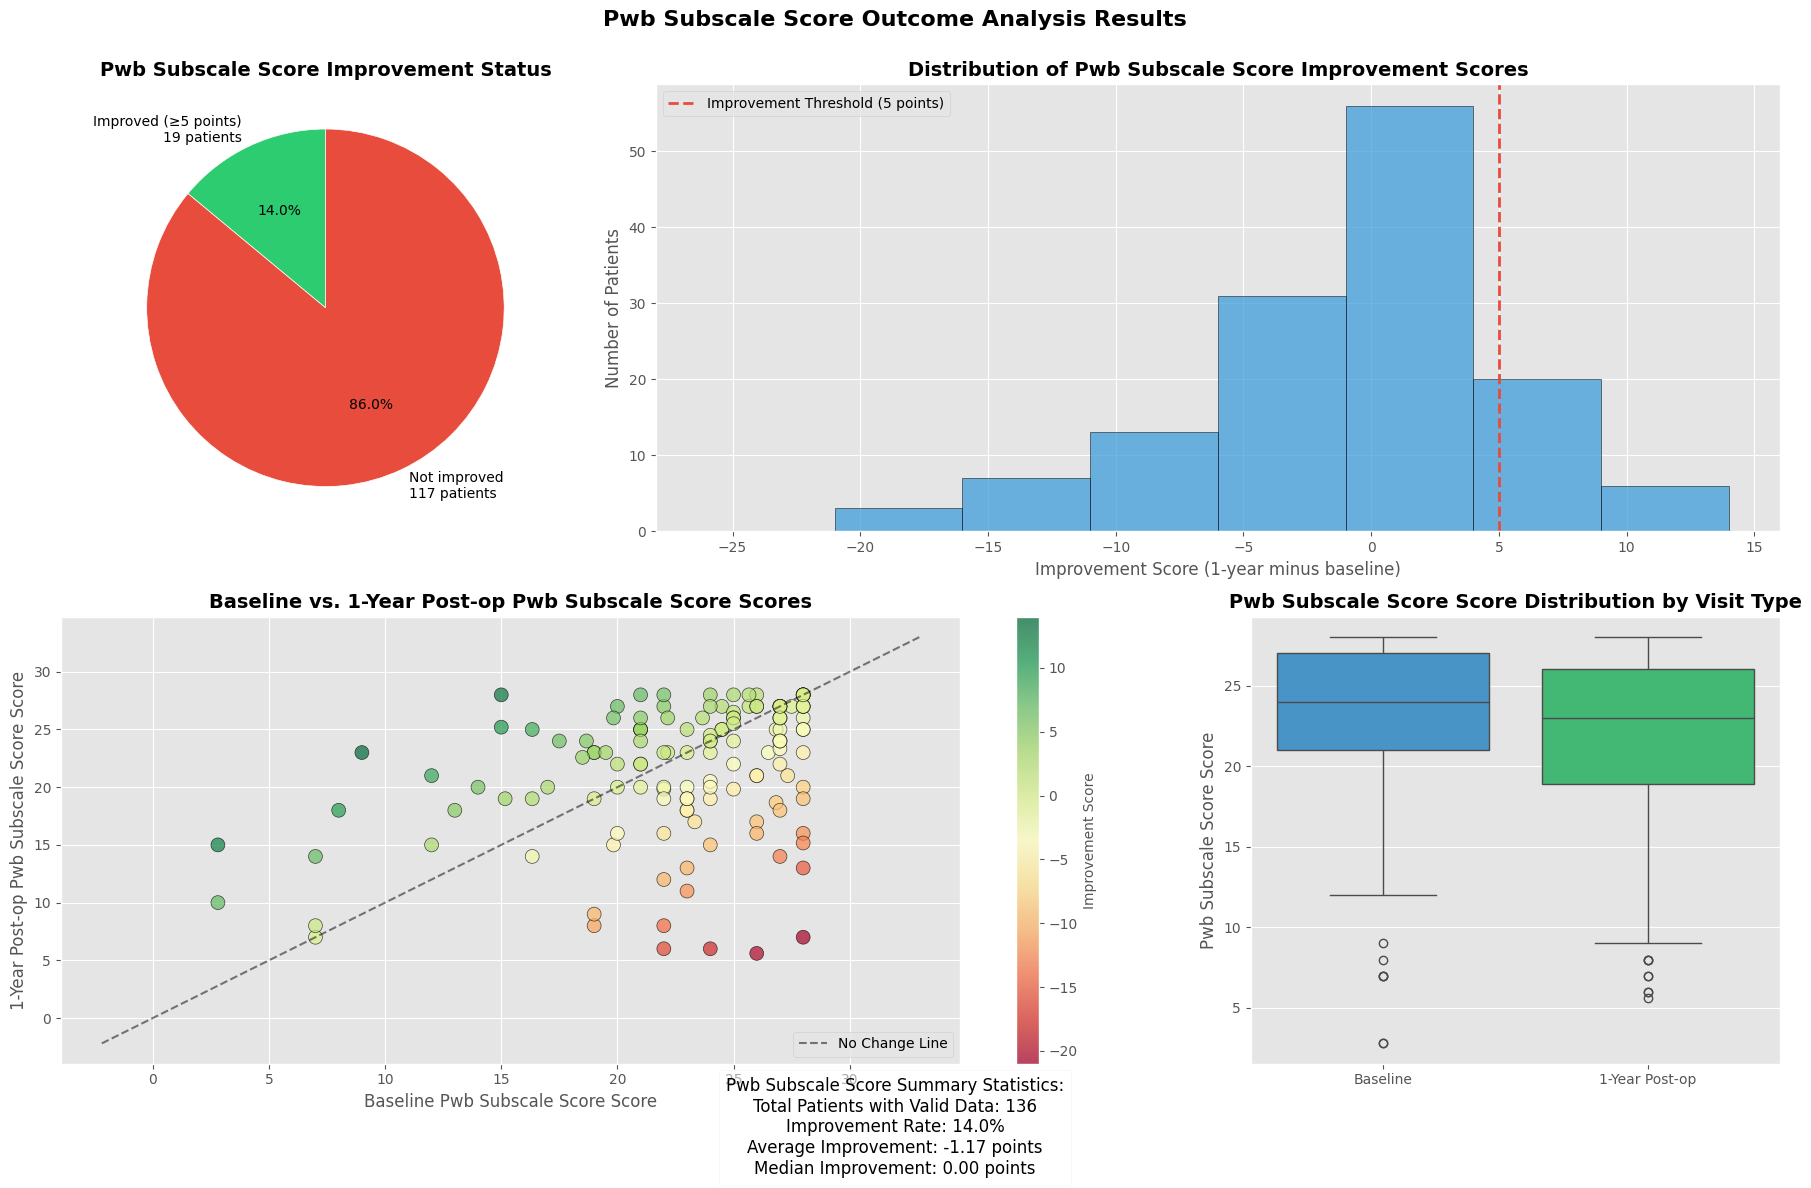

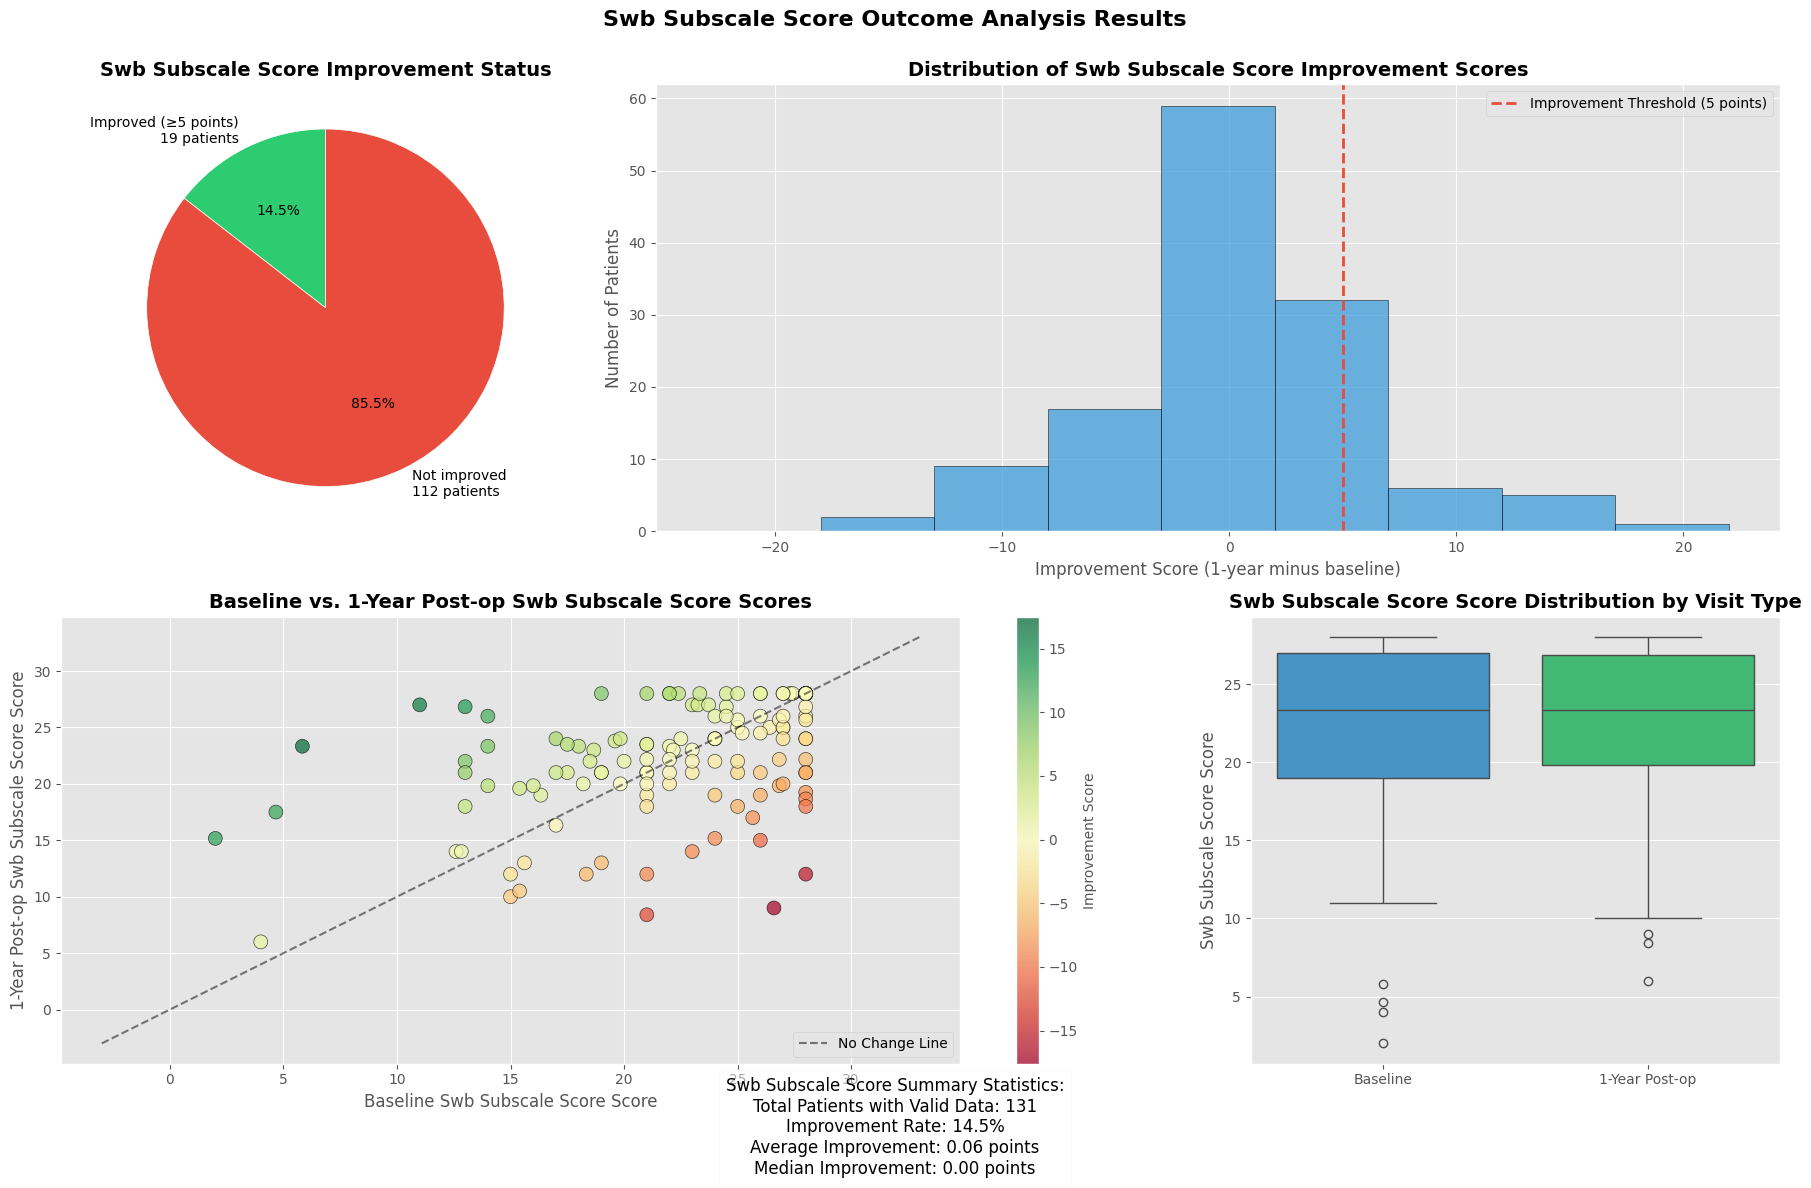

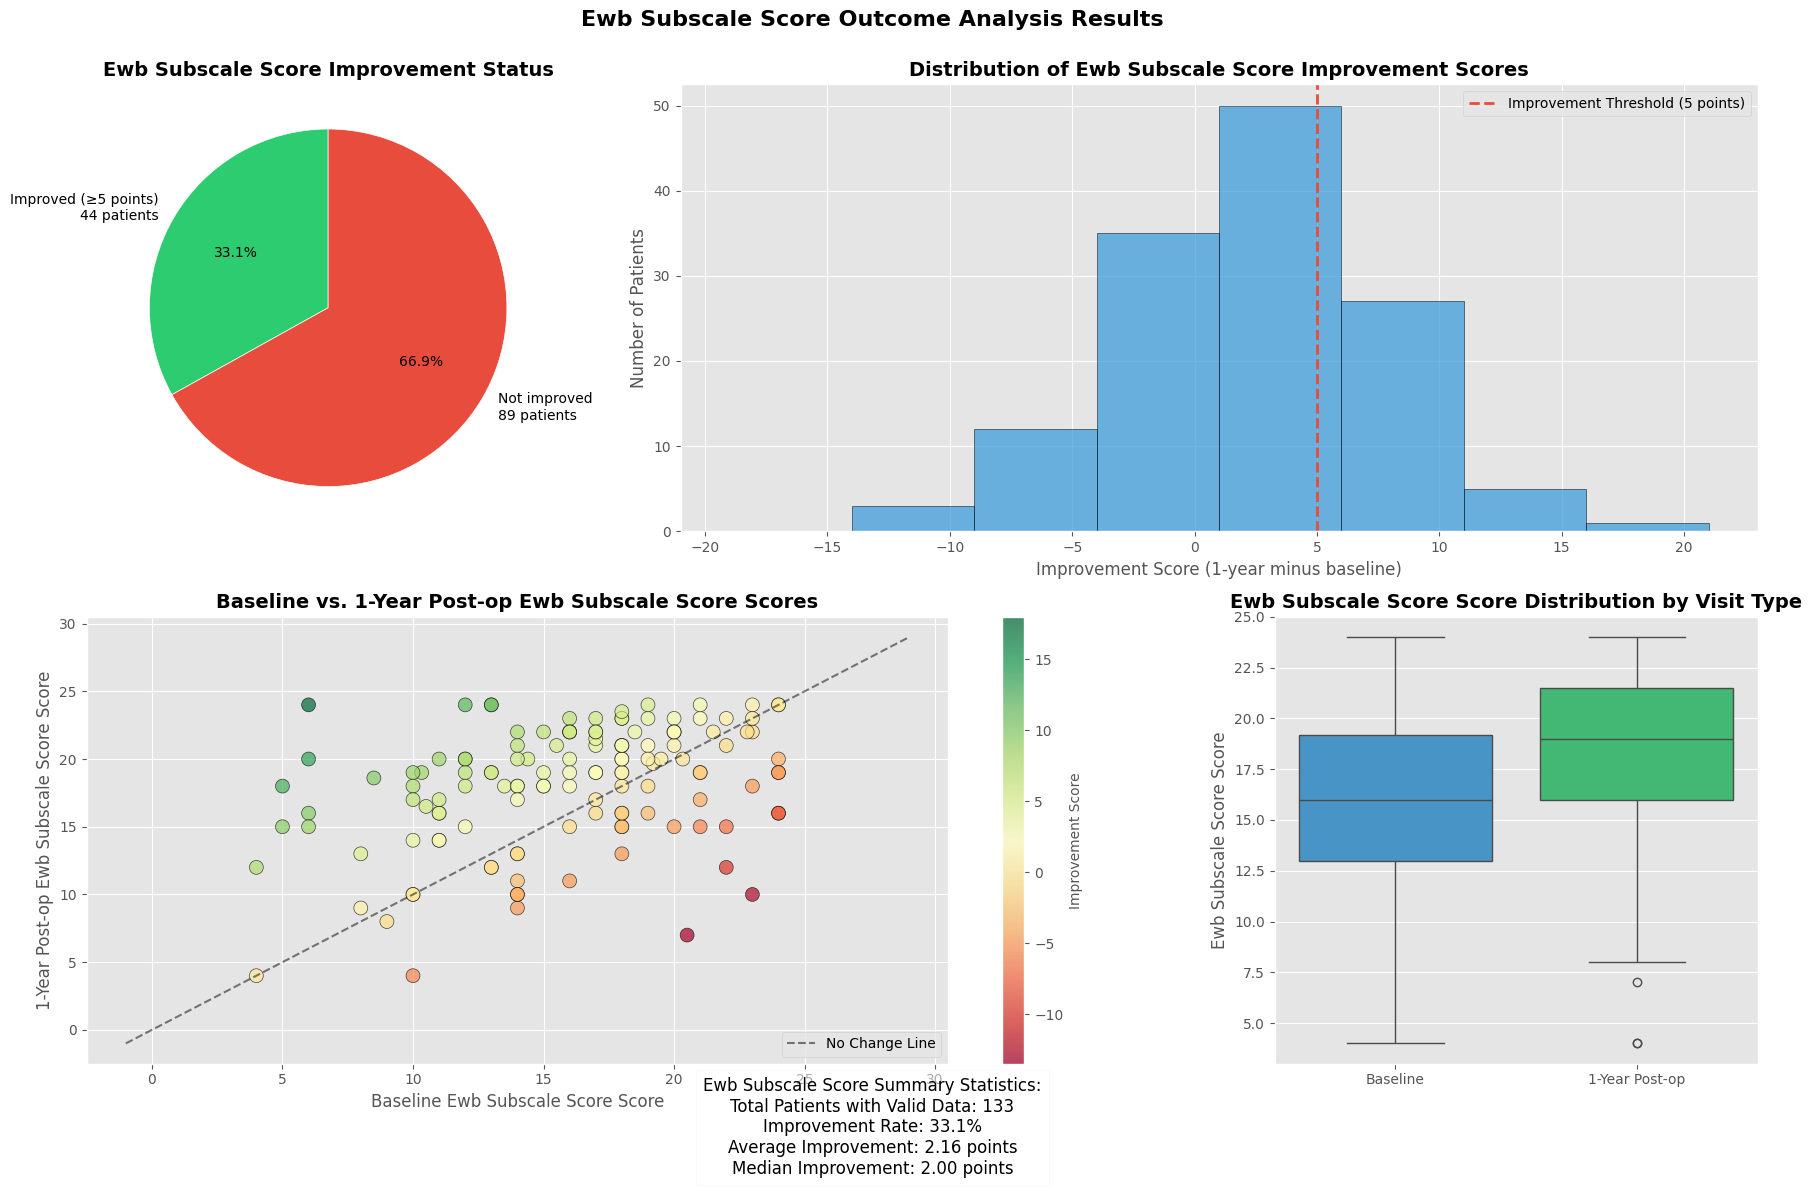

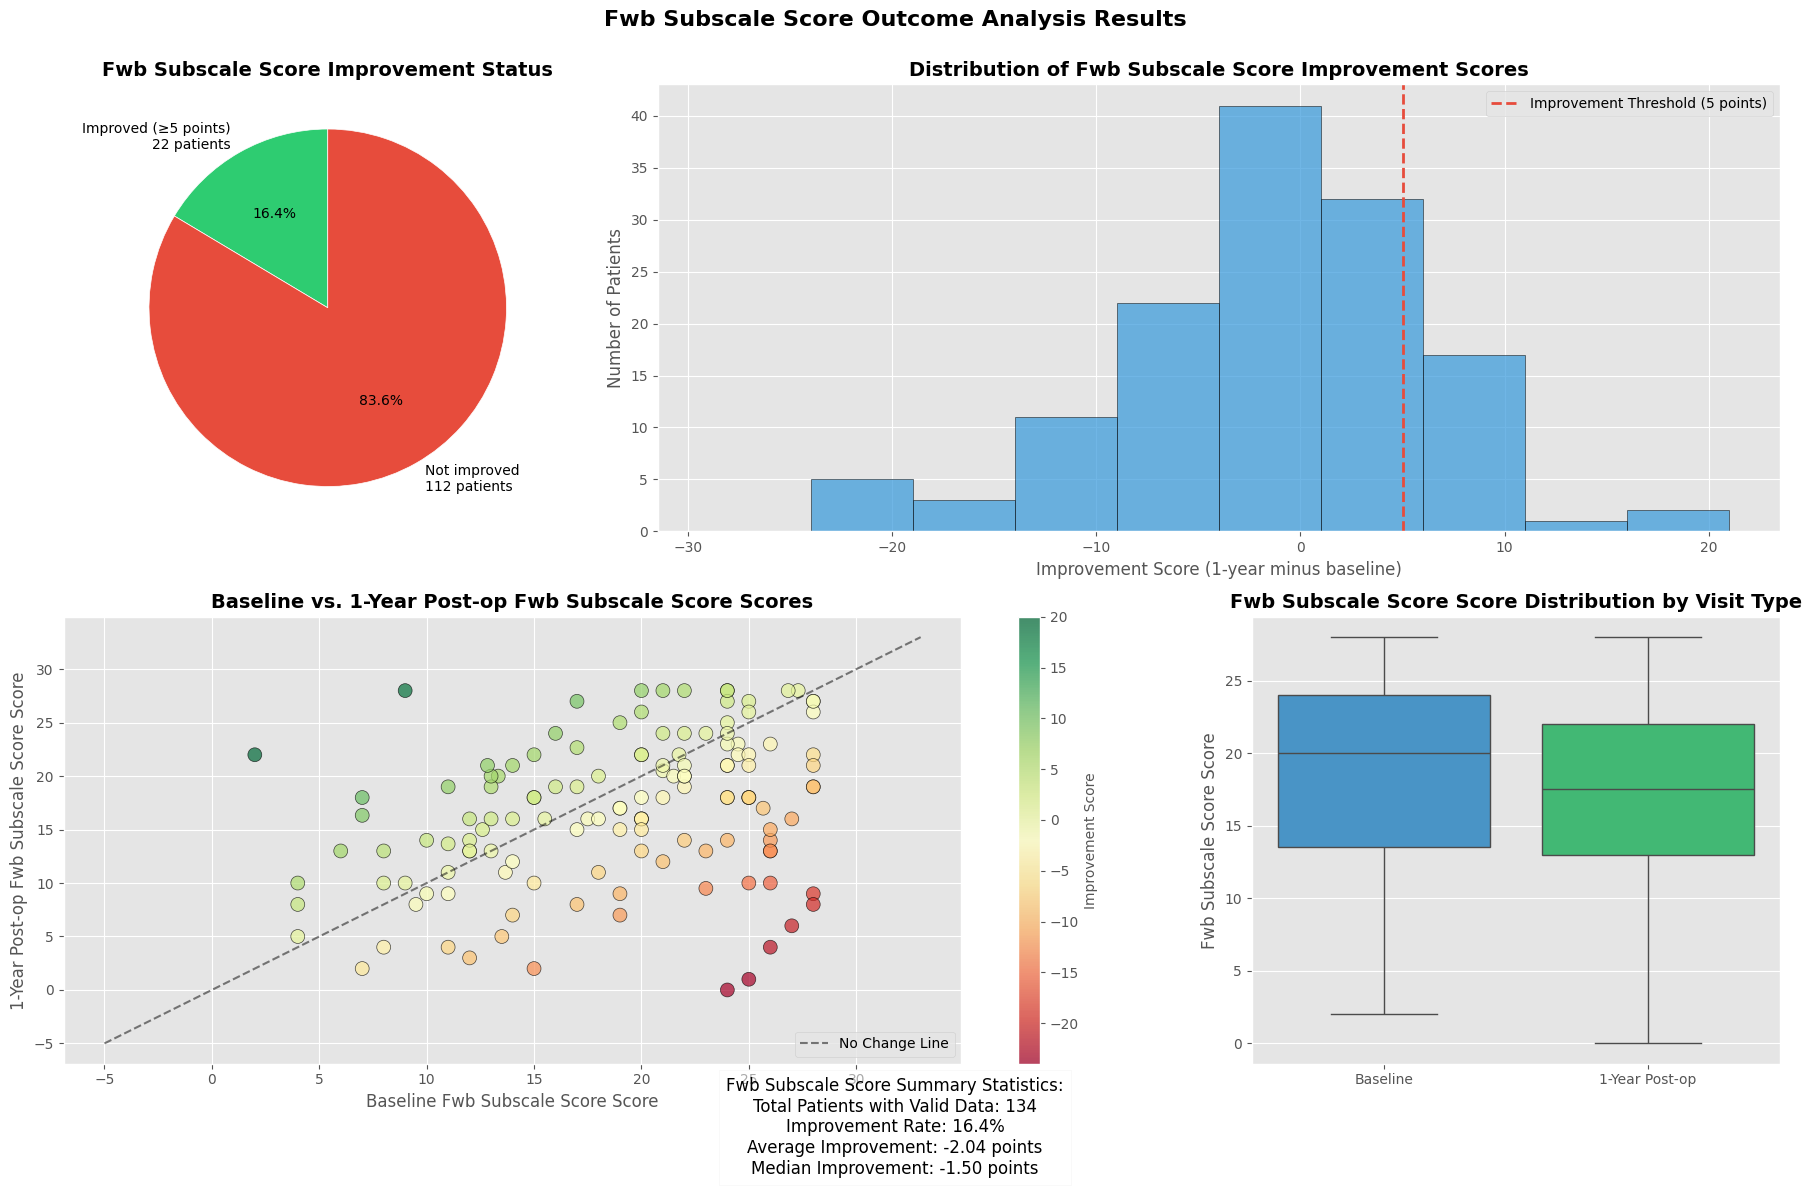

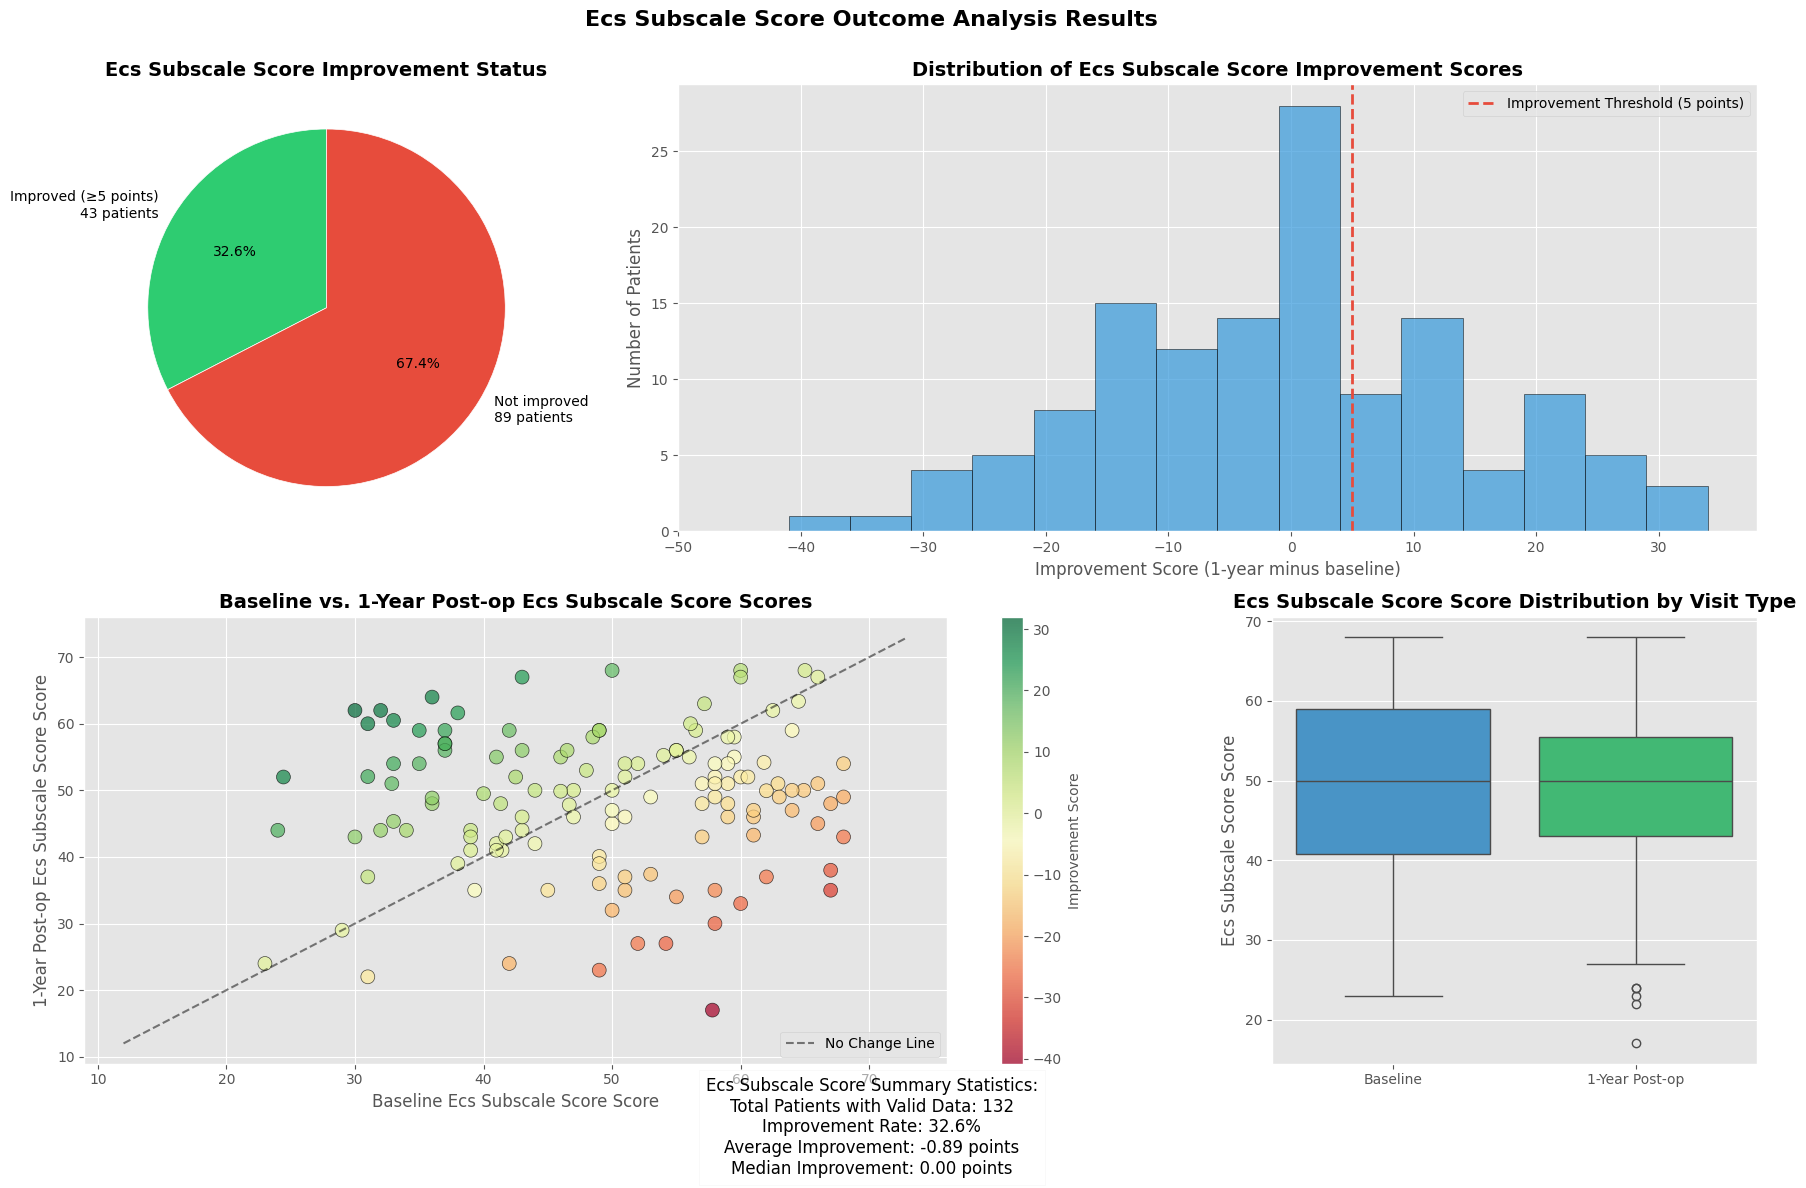

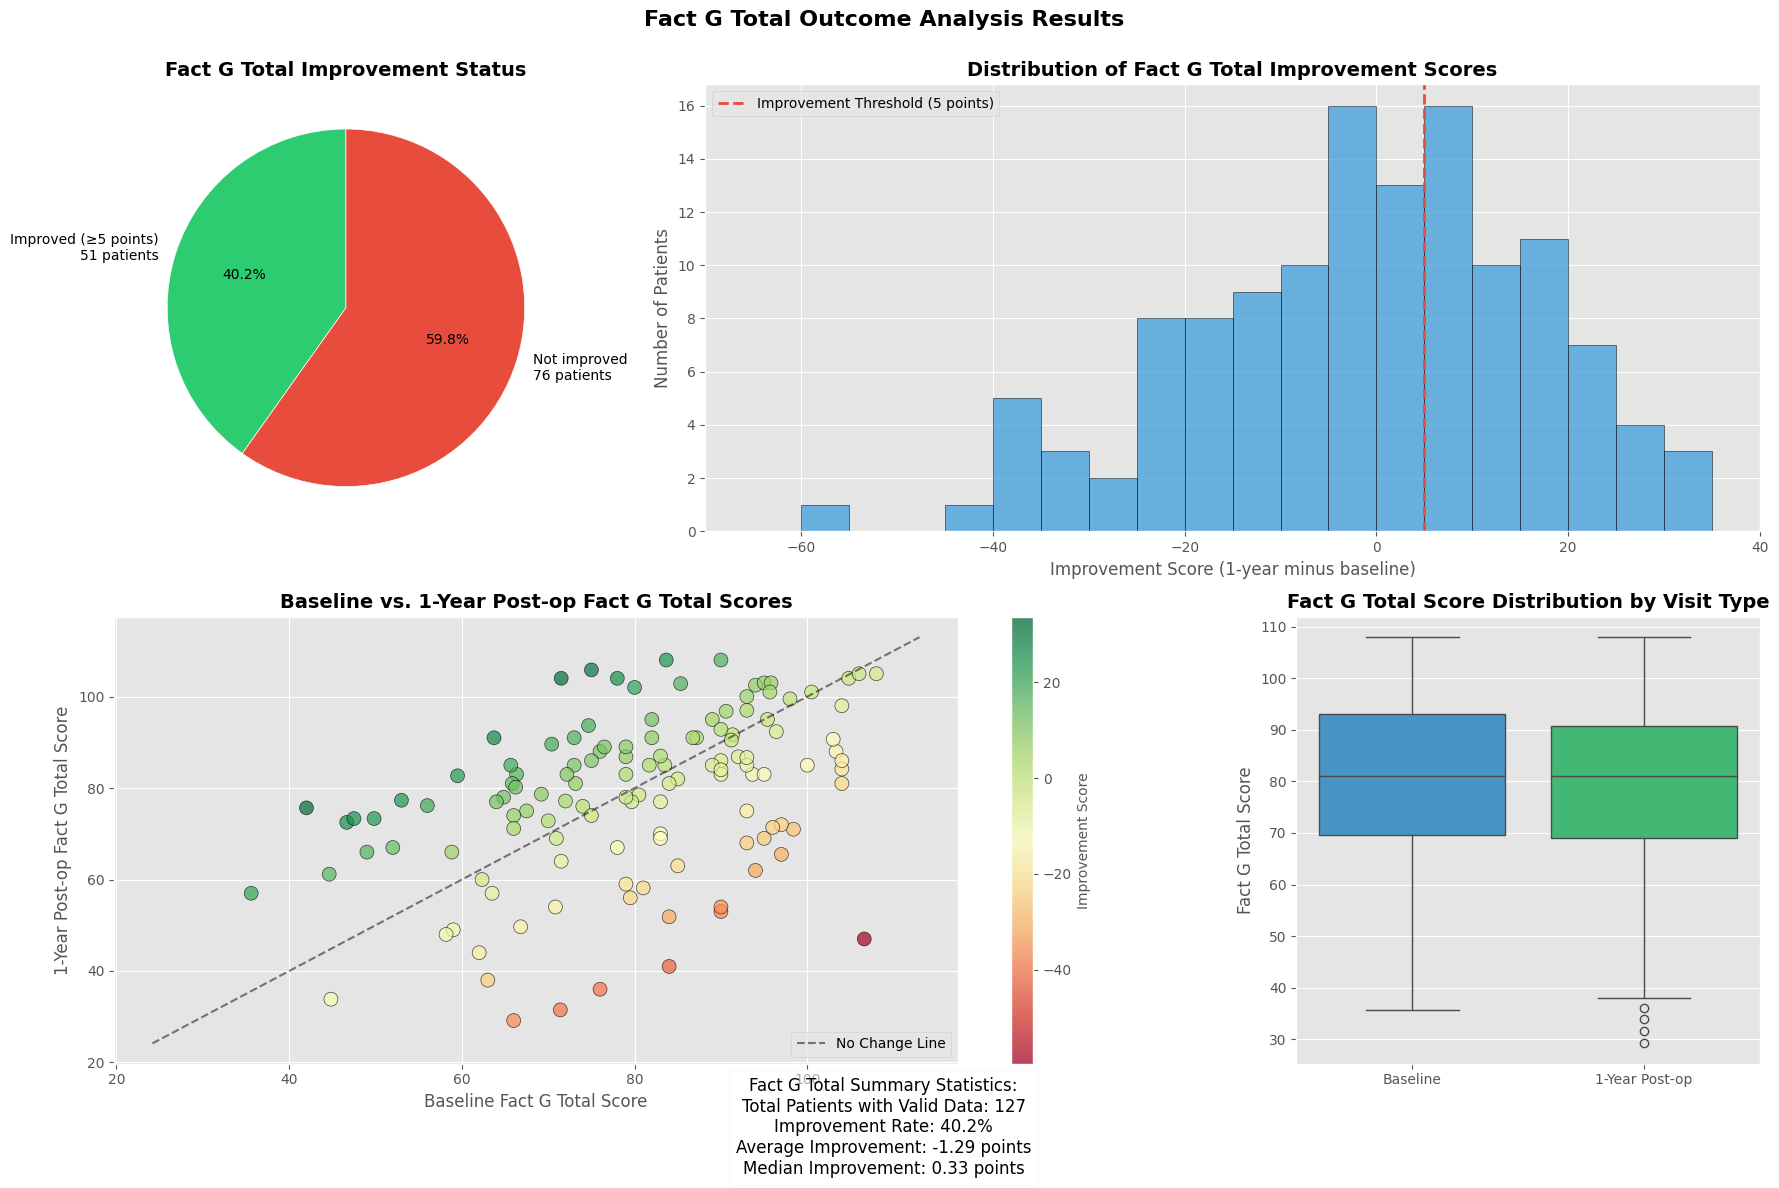

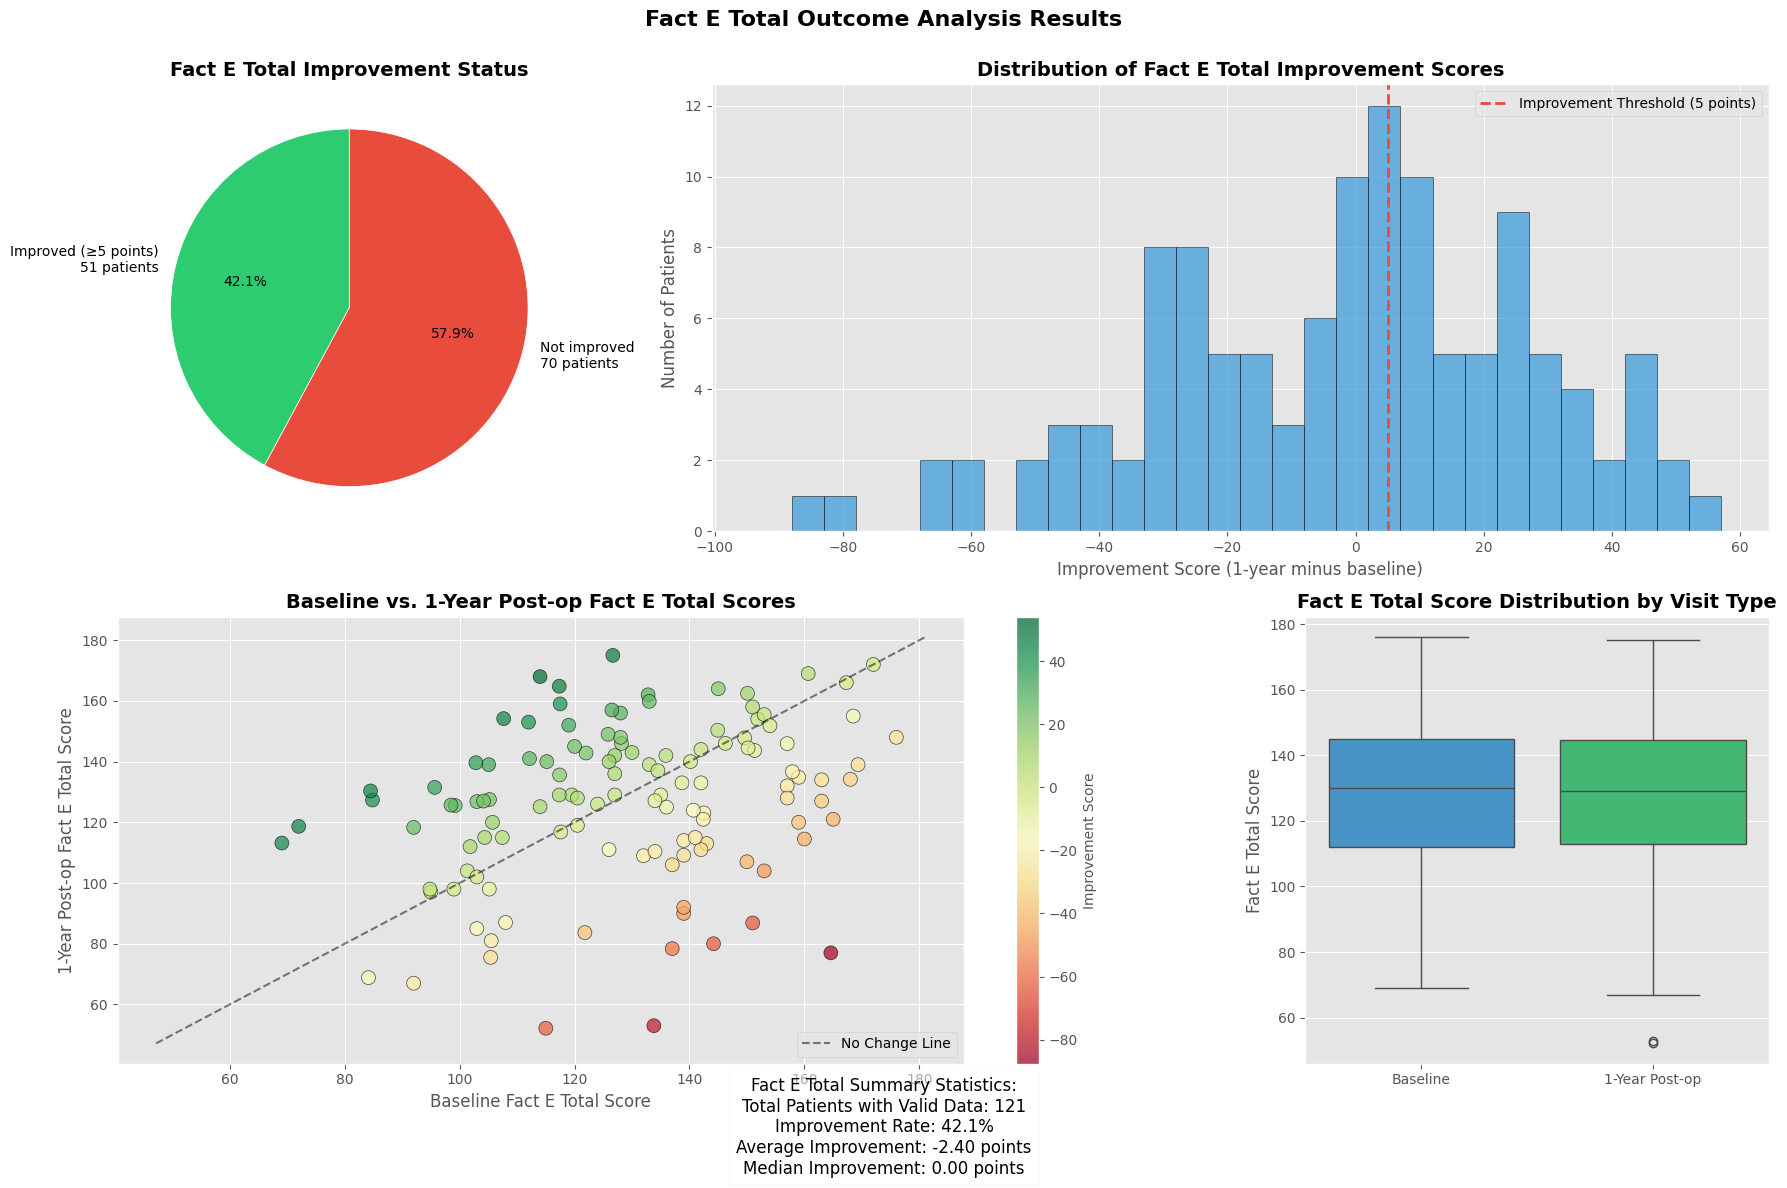

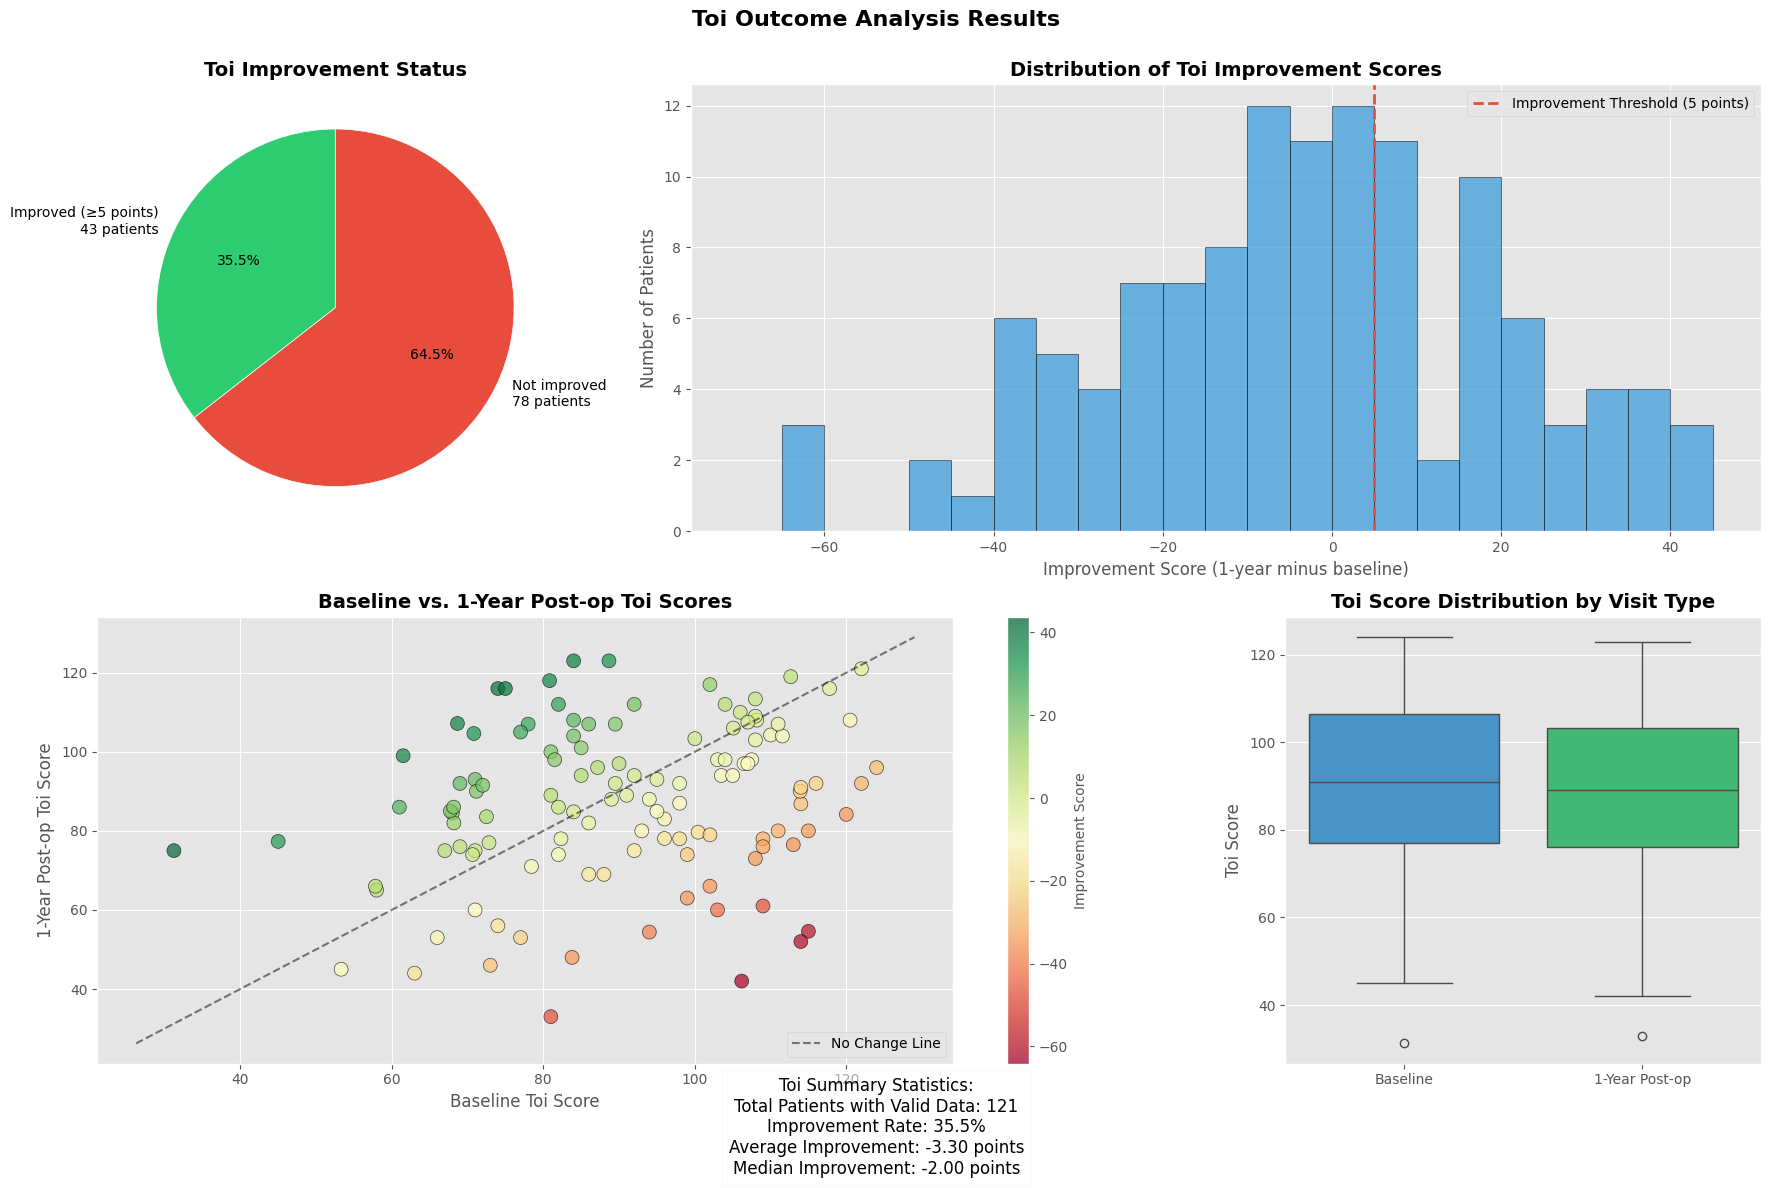

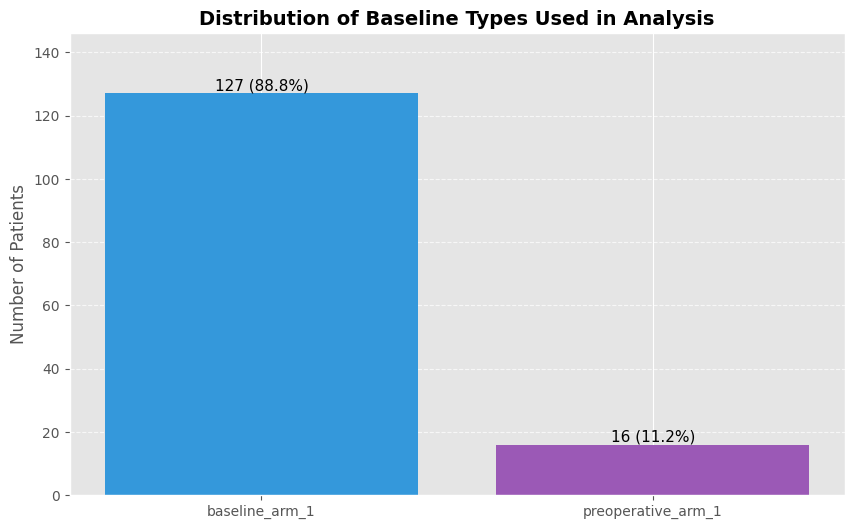

In [14]:
# Assuming results_df is available from the previous analysis
# If you need to recreate it, uncomment and run the code block below:
# filtered_df, results_df = analyze_patient_outcomes(df)

# Set the style
plt.style.use('ggplot')
sns.set_palette("colorblind")

# Define the score types to visualize
score_types = ['pwb_subscale_score', 'swb_subscale_score', 'ewb_subscale_score',
               'fwb_subscale_score', 'ecs_subscale_score', 'fact_g_total',
               'fact_e_total', 'toi']

# Create a separate figure for each score type
for score_type in score_types:
    # Create a figure with multiple subplots for the current score type
    fig = plt.figure(figsize=(18, 12))
    
    # 1. Pie chart showing percentage of patients who improved vs. didn't improve
    ax1 = plt.subplot2grid((2, 3), (0, 0))
    improved_count = results_df[f'{score_type}_has_improved'].sum()
    not_improved_count = results_df[f'{score_type}_has_improved'].notna().sum() - improved_count
    improvement_data = [improved_count, not_improved_count]
    labels = [f'Improved (≥5 points)\n{improved_count} patients', f'Not improved\n{not_improved_count} patients']
    colors = ['#2ecc71', '#e74c3c']
    ax1.pie(improvement_data, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, wedgeprops={'edgecolor': 'white'})
    ax1.set_title(f'{score_type.replace("_", " ").title()} Improvement Status', fontsize=14, fontweight='bold')

    # 2. Bar chart showing the distribution of improvement scores
    ax2 = plt.subplot2grid((2, 3), (0, 1), colspan=2)
    improvement_col = f'{score_type}_improvement'
    if improvement_col in results_df.columns:
        bins = np.arange(np.floor(results_df[improvement_col].min()) - 5, 
                        np.ceil(results_df[improvement_col].max()) + 5, 5)
        ax2.hist(results_df[improvement_col].dropna(), bins=bins, color='#3498db', alpha=0.7, edgecolor='black')
    ax2.axvline(x=5, color='#e74c3c', linestyle='--', linewidth=2, label='Improvement Threshold (5 points)')
    ax2.set_xlabel('Improvement Score (1-year minus baseline)', fontsize=12)
    ax2.set_ylabel('Number of Patients', fontsize=12)
    ax2.set_title(f'Distribution of {score_type.replace("_", " ").title()} Improvement Scores', fontsize=14, fontweight='bold')
    ax2.legend()

    # 3. Scatter plot of baseline vs one-year scores
    ax3 = plt.subplot2grid((2, 3), (1, 0), colspan=2)
    scatter = ax3.scatter(results_df[f'{score_type}_baseline'], results_df[f'{score_type}_one_year'], 
                         c=results_df[f'{score_type}_improvement'], cmap='RdYlGn', s=100, alpha=0.7, edgecolor='black')
    min_val = min(results_df[f'{score_type}_baseline'].min(), results_df[f'{score_type}_one_year'].min()) - 5
    max_val = max(results_df[f'{score_type}_baseline'].max(), results_df[f'{score_type}_one_year'].max()) + 5
    ax3.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='No Change Line')
    ax3.set_xlabel(f'Baseline {score_type.replace("_", " ").title()} Score', fontsize=12)
    ax3.set_ylabel(f'1-Year Post-op {score_type.replace("_", " ").title()} Score', fontsize=12)
    ax3.set_title(f'Baseline vs. 1-Year Post-op {score_type.replace("_", " ").title()} Scores', fontsize=14, fontweight='bold')
    cbar = plt.colorbar(scatter, ax=ax3)
    cbar.set_label('Improvement Score', fontsize=10)
    ax3.legend(loc='lower right')

    # 4. Box plot of scores by visit type
    ax4 = plt.subplot2grid((2, 3), (1, 2))
    box_data = pd.DataFrame({
        'Baseline': results_df[f'{score_type}_baseline'],
        '1-Year Post-op': results_df[f'{score_type}_one_year']
    })
    sns.boxplot(data=box_data, ax=ax4, palette=['#3498db', '#2ecc71'])
    ax4.set_ylabel(f'{score_type.replace("_", " ").title()} Score', fontsize=12)
    ax4.set_title(f'{score_type.replace("_", " ").title()} Score Distribution by Visit Type', fontsize=14, fontweight='bold')

    # Add a summary text box
    improved_count = results_df[f'{score_type}_has_improved'].sum()
    valid_count = results_df[f'{score_type}_improvement'].notna().sum()
    improvement_rate = (improved_count / valid_count * 100) if valid_count > 0 else 0
    avg_improvement = results_df[f'{score_type}_improvement'].mean()
    median_improvement = results_df[f'{score_type}_improvement'].median()
    plt.figtext(0.5, 0.01, 
               f"{score_type.replace('_', ' ').title()} Summary Statistics:\n"
               f"Total Patients with Valid Data: {valid_count}\n"
               f"Improvement Rate: {improvement_rate:.1f}%\n"
               f"Average Improvement: {avg_improvement:.2f} points\n"
               f"Median Improvement: {median_improvement:.2f} points",
               ha="center", fontsize=12, bbox={"facecolor":"white", "alpha":0.5, "pad":5})

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.suptitle(f'{score_type.replace("_", " ").title()} Outcome Analysis Results', fontsize=16, fontweight='bold', y=0.98)

    # Display the plot for this score type
    plt.show()

# Create additional visualization for baseline type distribution (unchanged)
plt.figure(figsize=(10, 6))
baseline_counts = results_df['baseline_type'].value_counts()
bars = plt.bar(baseline_counts.index, baseline_counts.values, color=['#3498db', '#9b59b6'])

# Add data labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{height} ({height/len(results_df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11)

plt.title('Distribution of Baseline Types Used in Analysis', fontsize=14, fontweight='bold')
plt.ylabel('Number of Patients', fontsize=12)
plt.ylim(0, baseline_counts.max() * 1.15)  # Add some space for the labels
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Data set up

In [15]:
results_df = pd.read_csv("results.csv")

In [16]:
results_df

,id,baseline_type,pwb_subscale_score_baseline,pwb_subscale_score_one_year,pwb_subscale_score_improvement,pwb_subscale_score_has_improved,swb_subscale_score_baseline,swb_subscale_score_one_year,swb_subscale_score_improvement,swb_subscale_score_has_improved,...,fact_g_total_improvement,fact_g_total_has_improved,fact_e_total_baseline,fact_e_total_one_year,fact_e_total_improvement,fact_e_total_has_improved,toi_baseline,toi_one_year,toi_improvement,toi_has_improved
0,32,baseline_arm_1,24.5,27.0,2.5,False,22.0,28.0,6.0,True,...,32.5,True,117.5,159.0,41.5,True,89.5,107.0,17.5,True
1,76,preoperative_arm_1,7.0,7.0,0.0,False,23.0,21.0,-2.0,False,...,-10.0,False,95.0,97.0,2.0,False,58.0,65.0,7.0,True
2,125,baseline_arm_1,21.0,22.0,1.0,False,17.5,21.0,3.5,False,...,7.5,True,119.5,129.0,9.5,True,81.0,89.0,8.0,True
3,160,baseline_arm_1,21.0,28.0,7.0,True,20.0,22.0,2.0,False,...,13.0,True,119.0,152.0,33.0,True,78.0,107.0,29.0,True
4,198,baseline_arm_1,25.0,26.5,1.5,False,13.0,18.0,5.0,True,...,12.0,True,133.0,139.0,6.0,True,103.0,98.0,-5.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138,1572,baseline_arm_1,27.0,24.0,-3.0,False,13.0,21.0,8.0,True,...,-1.0,False,141.0,115.0,-26.0,False,109.0,76.0,-33.0,False
139,1615,baseline_arm_1,23.0,19.0,-4.0,False,24.0,22.0,-2.0,False,...,-1.0,False,126.0,111.0,-15.0,False,86.0,69.0,-17.0,False
140,1621,baseline_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
141,1653,baseline_arm_1,21.0,26.0,5.0,True,19.0,21.0,2.0,False,...,9.0,True,112.0,153.0,41.0,True,75.0,116.0,41.0,True


In [17]:
results_df = results_df[['id','baseline_type', 'fact_e_total_baseline', 'fact_e_total_one_year', 'fact_e_total_improvement', 'fact_e_total_has_improved']]


# Rename the specified columns
results_df = results_df.rename(columns={
    "fact_e_total_baseline": "Baseline",
    "fact_e_total_one_year": "Postop1yr",
    "fact_e_total_improvement": "Change"
})

results_df["Trend Category"] = results_df['fact_e_total_has_improved'].map({True: 'Improved', False: 'Decreased/Same'}).fillna(results_df['fact_e_total_has_improved'])

results_df = results_df.dropna(subset=['Trend Category'])
results_df["Trend Category"].value_counts()


Trend Category
Decreased/Same    70
Improved          51
Name: count, dtype: int64

In [18]:
# Set 'id' column as the index
results_df = results_df.set_index("id")

# Rename the index and columns to match the second image
results_df.index.name = "id"
results_df.columns.name = "Timepoint"

results_df
score_comparison=results_df.copy()

In [19]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [20]:
score_comparison['baseline_type'].value_counts()

baseline_type
baseline_arm_1        109
preoperative_arm_1     12
Name: count, dtype: int64

In [21]:
def categorize_patients(data):
    # Get list of improvers (those with 'Improved' in Trend Category)
    improvers = data[data['Trend Category'] == 'Improved'].index.tolist()
    
    # Get list of non-improvers (those with 'Decreased/Same' in Trend Category)
    non_improvers = data[data['Trend Category'] == 'Decreased/Same'].index.tolist()
    
    return {
        'improvers': improvers,
        'non_improvers': non_improvers
    }

result = categorize_patients(score_comparison)
print(f"Improvers: {result['improvers']}")
print(f"Non-improvers: {result['non_improvers']}")

Improvers: [32, 125, 160, 198, 275, 307, 449, 466, 481, 521, 531, 537, 539, 543, 579, 589, 613, 644, 663, 671, 702, 704, 712, 769, 780, 816, 830, 836, 873, 877, 889, 898, 903, 905, 912, 920, 950, 1049, 1121, 1122, 1173, 1220, 1241, 1287, 1290, 1304, 1325, 1328, 1393, 1438, 1653]
Non-improvers: [76, 230, 364, 442, 465, 471, 501, 505, 508, 513, 523, 526, 536, 545, 549, 551, 557, 592, 629, 634, 659, 665, 668, 673, 682, 695, 698, 708, 740, 759, 764, 779, 785, 797, 850, 878, 891, 923, 938, 939, 975, 992, 1001, 1006, 1016, 1048, 1088, 1113, 1150, 1167, 1175, 1237, 1273, 1275, 1280, 1332, 1373, 1387, 1405, 1409, 1413, 1433, 1447, 1527, 1531, 1560, 1566, 1571, 1572, 1615]


# statistically significantly associated with 0) FACT E baseline 

In [22]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [23]:
# Create a clean dataframe with no missing values in Baseline
merged_df_baseline = score_comparison.copy()
merged_df_removedNA_baseline = merged_df_baseline.dropna(subset=["Baseline"])
merged_df_expanded_baseline = merged_df_removedNA_baseline.drop_duplicates()
merged_df_removedNA_baseline = merged_df_expanded_baseline.copy()
merged_df_removedNA_baseline

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [24]:

# Show summary statistics by improvement group
print("\nBaseline scores by Trend Category:")
print(merged_df_removedNA_baseline.groupby("Trend Category")["Baseline"].describe())


Baseline scores by Trend Category:
                count        mean        std        min         25%  \
Trend Category                                                        
Decreased/Same   70.0  138.144791  22.180625  84.145833  126.250000   
Improved         51.0  116.481199  18.826493  69.070833  104.711111   

                       50%     75%         max  
Trend Category                                  
Decreased/Same  140.833333  153.75  176.000000  
Improved        117.400000  127.50  160.666667  


In [25]:
# Perform Mann-Whitney U test to compare Baseline scores between groups
improved_baseline = merged_df_removedNA_baseline[merged_df_removedNA_baseline["Trend Category"] == "Improved"]["Baseline"]
decreased_same_baseline = merged_df_removedNA_baseline[merged_df_removedNA_baseline["Trend Category"] == "Decreased/Same"]["Baseline"]

stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
print(f"\nMann-Whitney U test:")
print(f"Statistic: {stat}")
print(f"p-value: {p_value}")


Mann-Whitney U test:
Statistic: 795.0
p-value: 2.055700875955558e-07


In [26]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_baseline["Trend Category_binary"] = merged_df_removedNA_baseline["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Logistic regression with Baseline as predictor
X = sm.add_constant(merged_df_removedNA_baseline["Baseline"])
y = merged_df_removedNA_baseline["Trend Category_binary"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print("\nLogistic Regression Results:")
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.565441
         Iterations 6

Logistic Regression Results:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  121
Model:                             Logit   Df Residuals:                      119
Method:                              MLE   Df Model:                            1
Date:                   Wed, 25 Jun 2025   Pseudo R-squ.:                  0.1694
Time:                           11:41:30   Log-Likelihood:                -68.418
converged:                          True   LL-Null:                       -82.373
Covariance Type:               nonrobust   LLR p-value:                 1.271e-07
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.8315      1.342      4.346      0.000


Odds Ratio for a 10-point increase in baseline score: 0.617
95% CI for a 10-point increase in baseline score: (0.503, 0.758)


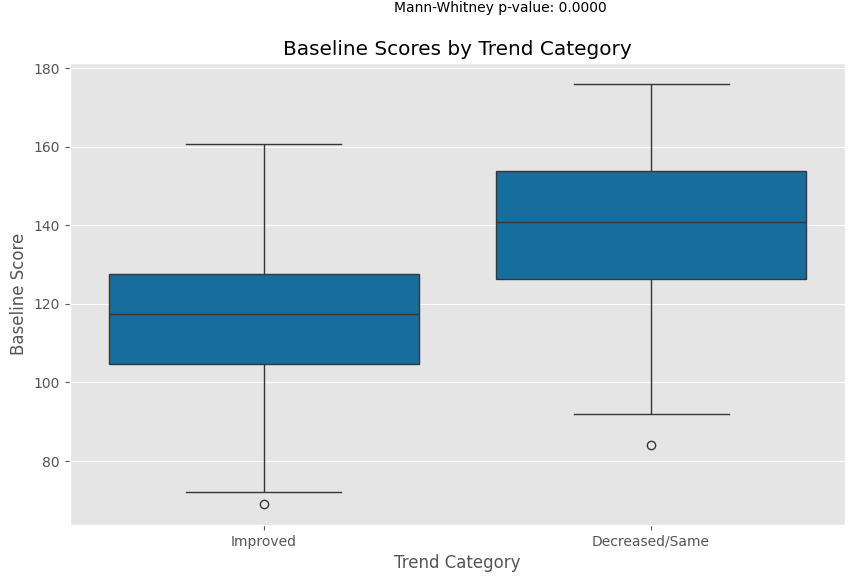

In [27]:
# Calculate odds ratio for a 10-point increase in baseline score
baseline_coef = result.params["Baseline"]
odds_ratio_10points = np.exp(baseline_coef * 10)
print(f"\nOdds Ratio for a 10-point increase in baseline score: {odds_ratio_10points:.3f}")

# Calculate confidence interval for the odds ratio
baseline_conf_int = result.conf_int().loc["Baseline"]
lower_ci_10points = np.exp(baseline_conf_int[0] * 10)
upper_ci_10points = np.exp(baseline_conf_int[1] * 10)
print(f"95% CI for a 10-point increase in baseline score: ({lower_ci_10points:.3f}, {upper_ci_10points:.3f})")

# Visualize with boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x="Trend Category", y="Baseline", data=merged_df_removedNA_baseline)
plt.title("Baseline Scores by Trend Category")
plt.xlabel("Trend Category")
plt.ylabel("Baseline Score")
plt.annotate(f"Mann-Whitney p-value: {p_value:.4f}", xy=(0.5, 0.95), 
             xycoords='figure fraction', ha='center')
plt.show()

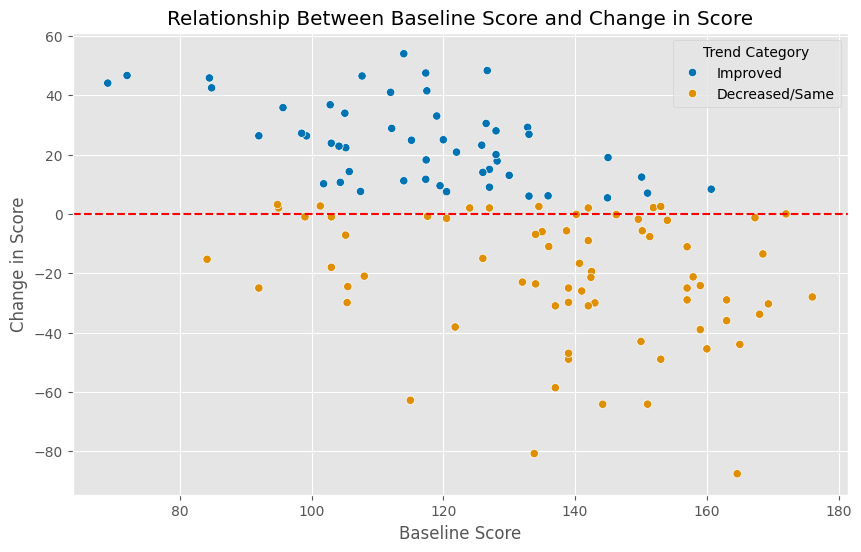

In [28]:

# Create a scatter plot of Baseline vs Change
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Baseline", y="Change", 
                hue="Trend Category", 
                data=merged_df_removedNA_baseline)
plt.title("Relationship Between Baseline Score and Change in Score")
plt.xlabel("Baseline Score")
plt.ylabel("Change in Score")
plt.axhline(y=0, color='r', linestyle='--')  # Add a horizontal line at y=0
plt.legend(title="Trend Category")
plt.show()

# sensitivity analysis 0) FACT E baseline 

In [29]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


Sensitivity Analysis Results:
    threshold  improvement_rate  mean_facte_improved  mean_facte_not_improved  \
0           0          0.504132           118.624445               139.576423   
1           1          0.495868           117.734853               140.107957   
2           2          0.495868           117.734853               140.107957   
3           3          0.429752           116.064894               138.772493   
4           4          0.421488           116.481199               138.144791   
5           5          0.421488           116.481199               138.144791   
6           6          0.413223           115.912490               138.240169   
7           7          0.396694           115.140094               138.136329   
8           8          0.371901           114.395267               137.669599   
9           9          0.363636           113.343644               137.968262   
10         10          0.347107           112.871913               137.595648  

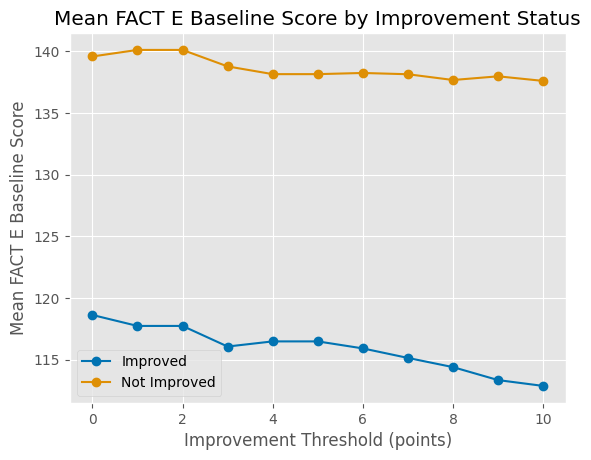

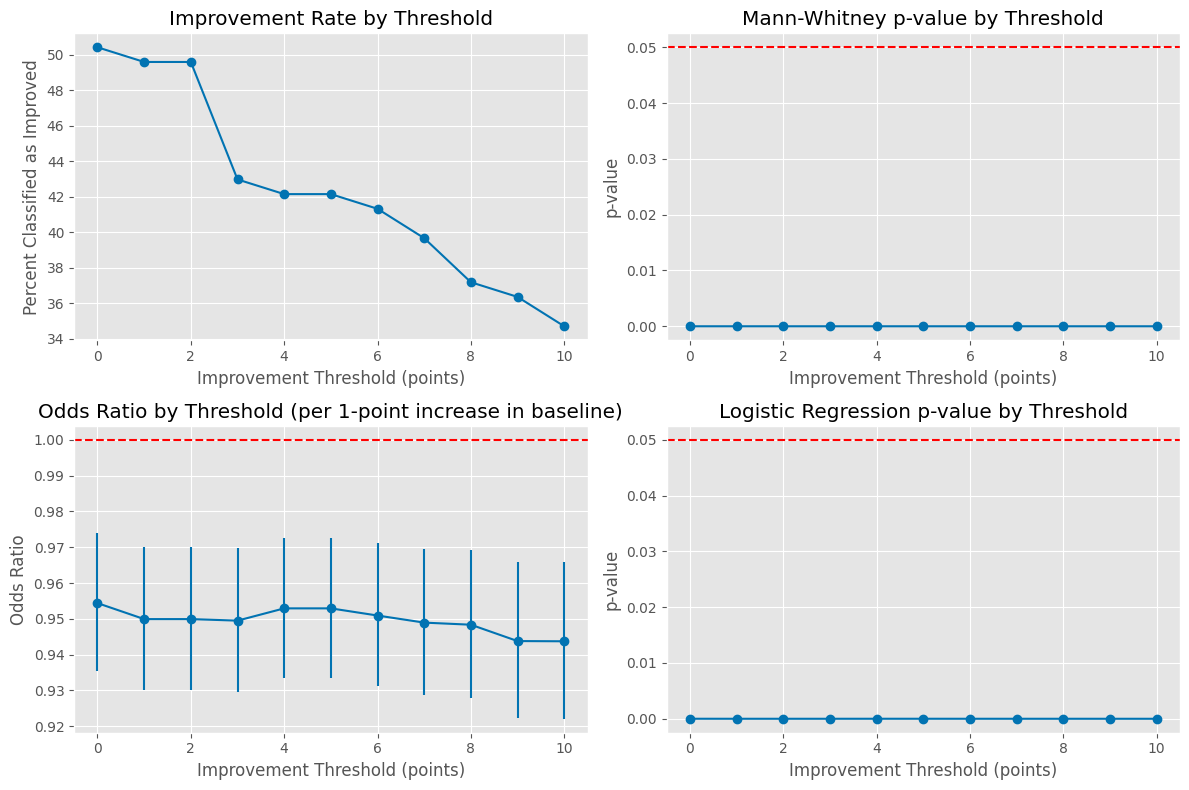


Patient Counts at Different Thresholds:
    Threshold  Improved Count  Decreased/Same Count  Improved %  \
0           0              61                    60   50.413223   
1           1              60                    61   49.586777   
2           2              60                    61   49.586777   
3           3              52                    69   42.975207   
4           4              51                    70   42.148760   
5           5              51                    70   42.148760   
6           6              50                    71   41.322314   
7           7              48                    73   39.669421   
8           8              45                    76   37.190083   
9           9              44                    77   36.363636   
10         10              42                    79   34.710744   

    Decreased/Same %  
0          49.586777  
1          50.413223  
2          50.413223  
3          57.024793  
4          57.851240  
5          57.85

In [30]:
# Assuming score_comparison contains the necessary columns: id, Baseline, Change
# Let's create a function to perform the analysis at different thresholds

def analyze_improvement_threshold(data, threshold):
    """
    Analyze how the improvement threshold affects classification and baseline score relationship
    
    Parameters:
    data: DataFrame containing Baseline and Change scores
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the new threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    df["Trend Category_binary"] = df["Improved"].astype(int)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count
    
    # Mann-Whitney U test
    improved_baseline = df[df["Improved"]]["Baseline"]
    decreased_same_baseline = df[~df["Improved"]]["Baseline"]
    
    if len(improved_baseline) > 0 and len(decreased_same_baseline) > 0:
        stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
    else:
        stat, p_value = None, None
    
    # Mean pwb_subscale_score_baseline in each group
    mean_facte_improved = improved_baseline.mean() if len(improved_baseline) > 0 else None
    mean_facte_not_improved = decreased_same_baseline.mean() if len(decreased_same_baseline) > 0 else None
    
    # Logistic regression
    X = sm.add_constant(df["Baseline"])
    y = df["Trend Category_binary"]
    
    try:
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        baseline_coef = result.params["Baseline"]
        baseline_p = result.pvalues["Baseline"]
        odds_ratio = np.exp(baseline_coef)
        
        # Confidence intervals
        baseline_conf_int = result.conf_int().loc["Baseline"]
        lower_ci = np.exp(baseline_conf_int[0])
        upper_ci = np.exp(baseline_conf_int[1])
    except:
        baseline_coef = None
        baseline_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "mean_facte_improved": mean_facte_improved,
        "mean_facte_not_improved": mean_facte_not_improved,
        "mann_whitney_stat": stat,
        "mann_whitney_p": p_value,
        "logistic_coef": baseline_coef,
        "logistic_p": baseline_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Prepare clean dataset
merged_df_clean = score_comparison.dropna(subset=["Baseline", "Change"]).drop_duplicates()

for threshold in thresholds:
    result = analyze_improvement_threshold(merged_df_clean, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis Results:")
print(sensitivity_df[["threshold", "improvement_rate", "mean_facte_improved", "mean_facte_not_improved", "mann_whitney_p", "logistic_p", "odds_ratio"]])

plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_facte_improved"], 'o-', label='Improved')
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_facte_not_improved"], 'o-', label='Not Improved')
plt.title("Mean FACT E Baseline Score by Improvement Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Mean FACT E Baseline Score")
plt.legend()
plt.grid(True)

# Plot how improvement rate changes with threshold
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(sensitivity_df["threshold"], sensitivity_df["improvement_rate"] * 100, 'o-')
plt.title("Improvement Rate by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Percent Classified as Improved")
plt.grid(True)

# Plot p-values from Mann-Whitney test
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mann_whitney_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Mann-Whitney p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot odds ratios from logistic regression
plt.subplot(2, 2, 3)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio by Threshold (per 1-point increase in baseline)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

# Plot p-values from logistic regression
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["logistic_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Create a table showing the number and percentage of patients in each category at different thresholds
category_counts = []

for threshold in thresholds:
    df_temp = merged_df_clean.copy()
    df_temp["Improved"] = df_temp["Change"] >= threshold
    improved_count = df_temp["Improved"].sum()
    total = len(df_temp)
    
    category_counts.append({
        "Threshold": threshold,
        "Improved Count": improved_count,
        "Decreased/Same Count": total - improved_count,
        "Improved %": (improved_count / total) * 100,
        "Decreased/Same %": ((total - improved_count) / total) * 100
    })

category_df = pd.DataFrame(category_counts)
print("\nPatient Counts at Different Thresholds:")
print(category_df)

# statistically significantly associated with 0B) PWB baseline 

In [31]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [32]:
score_info = pd.read_csv("results.csv")
score_info

,id,baseline_type,pwb_subscale_score_baseline,pwb_subscale_score_one_year,pwb_subscale_score_improvement,pwb_subscale_score_has_improved,swb_subscale_score_baseline,swb_subscale_score_one_year,swb_subscale_score_improvement,swb_subscale_score_has_improved,...,fact_g_total_improvement,fact_g_total_has_improved,fact_e_total_baseline,fact_e_total_one_year,fact_e_total_improvement,fact_e_total_has_improved,toi_baseline,toi_one_year,toi_improvement,toi_has_improved
0,32,baseline_arm_1,24.5,27.0,2.5,False,22.0,28.0,6.0,True,...,32.5,True,117.5,159.0,41.5,True,89.5,107.0,17.5,True
1,76,preoperative_arm_1,7.0,7.0,0.0,False,23.0,21.0,-2.0,False,...,-10.0,False,95.0,97.0,2.0,False,58.0,65.0,7.0,True
2,125,baseline_arm_1,21.0,22.0,1.0,False,17.5,21.0,3.5,False,...,7.5,True,119.5,129.0,9.5,True,81.0,89.0,8.0,True
3,160,baseline_arm_1,21.0,28.0,7.0,True,20.0,22.0,2.0,False,...,13.0,True,119.0,152.0,33.0,True,78.0,107.0,29.0,True
4,198,baseline_arm_1,25.0,26.5,1.5,False,13.0,18.0,5.0,True,...,12.0,True,133.0,139.0,6.0,True,103.0,98.0,-5.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138,1572,baseline_arm_1,27.0,24.0,-3.0,False,13.0,21.0,8.0,True,...,-1.0,False,141.0,115.0,-26.0,False,109.0,76.0,-33.0,False
139,1615,baseline_arm_1,23.0,19.0,-4.0,False,24.0,22.0,-2.0,False,...,-1.0,False,126.0,111.0,-15.0,False,86.0,69.0,-17.0,False
140,1621,baseline_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
141,1653,baseline_arm_1,21.0,26.0,5.0,True,19.0,21.0,2.0,False,...,9.0,True,112.0,153.0,41.0,True,75.0,116.0,41.0,True


In [33]:
merged_df_pwb = score_comparison.merge(score_info[["id", "pwb_subscale_score_baseline"]], on="id", how="left")
merged_df_removedNA_pwb = merged_df_pwb.dropna(subset=["pwb_subscale_score_baseline"])
merged_df_expanded_pwb = merged_df_removedNA_pwb.drop_duplicates()
merged_df_removedNA_pwb = merged_df_expanded_pwb.copy()
merged_df_removedNA_pwb

,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,pwb_subscale_score_baseline
0,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,24.5
1,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,7.0
2,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,21.0
3,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,21.0
4,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,25.0
...,...,...,...,...,...,...,...,...
116,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,23.0
117,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,26.0
118,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,27.0
119,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,23.0


In [34]:
# Show summary statistics by improvement group
print("\nBaseline scores by Trend Category:")
print(merged_df_removedNA_pwb.groupby("Trend Category")["pwb_subscale_score_baseline"].describe())


Baseline scores by Trend Category:
                count       mean       std  min   25%    50%   75%   max
Trend Category                                                          
Decreased/Same   70.0  23.582857  5.308795  2.8  22.0  24.75  27.0  28.0
Improved         51.0  21.515686  5.018819  2.8  19.0  22.00  25.0  28.0


In [35]:
# Perform Mann-Whitney U test to compare Baseline scores between groups
improved_baseline = merged_df_removedNA_pwb[merged_df_removedNA_pwb["Trend Category"] == "Improved"]["pwb_subscale_score_baseline"]
decreased_same_baseline = merged_df_removedNA_pwb[merged_df_removedNA_pwb["Trend Category"] == "Decreased/Same"]["pwb_subscale_score_baseline"]

stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
print(f"\nMann-Whitney U test:")
print(f"Statistic: {stat}")
print(f"p-value: {p_value}")


Mann-Whitney U test:
Statistic: 1191.5
p-value: 0.0017959257067856613


In [36]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_pwb["Trend Category_binary"] = merged_df_removedNA_pwb["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Logistic regression with Baseline as predictor
X = sm.add_constant(merged_df_removedNA_pwb["pwb_subscale_score_baseline"])
y = merged_df_removedNA_pwb["Trend Category_binary"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print("\nLogistic Regression Results:")
print(result.summary())


Optimization terminated successfully.
         Current function value: 0.661741
         Iterations 5

Logistic Regression Results:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  121
Model:                             Logit   Df Residuals:                      119
Method:                              MLE   Df Model:                            1
Date:                   Wed, 25 Jun 2025   Pseudo R-squ.:                 0.02795
Time:                           11:41:33   Log-Likelihood:                -80.071
converged:                          True   LL-Null:                       -82.373
Covariance Type:               nonrobust   LLR p-value:                   0.03189
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const               


Odds Ratio for a 10-point increase in baseline score: 0.462
95% CI for a 10-point increase in baseline score: (0.221, 0.964)


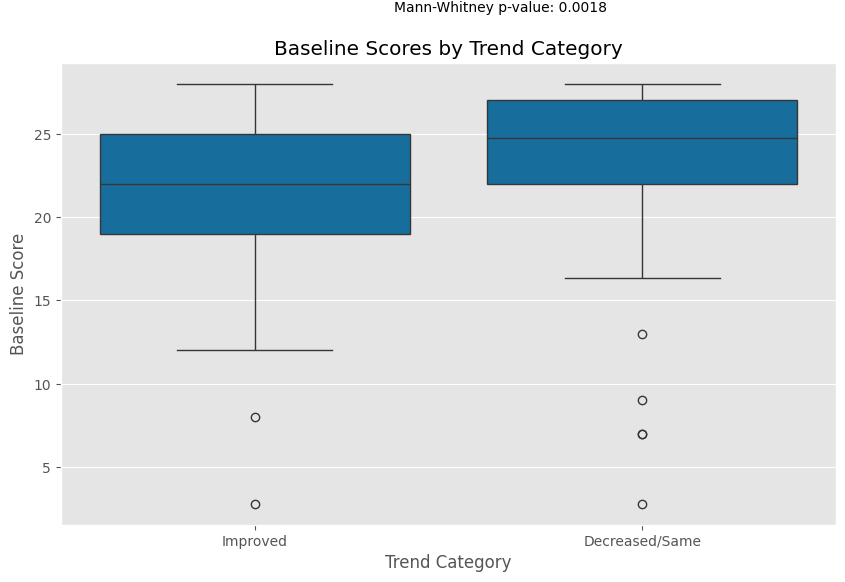

In [37]:
# Calculate odds ratio for a 10-point increase in baseline score
baseline_coef = result.params["pwb_subscale_score_baseline"]
odds_ratio_10points = np.exp(baseline_coef * 10)
print(f"\nOdds Ratio for a 10-point increase in baseline score: {odds_ratio_10points:.3f}")

# Calculate confidence interval for the odds ratio
baseline_conf_int = result.conf_int().loc["pwb_subscale_score_baseline"]
lower_ci_10points = np.exp(baseline_conf_int[0] * 10)
upper_ci_10points = np.exp(baseline_conf_int[1] * 10)
print(f"95% CI for a 10-point increase in baseline score: ({lower_ci_10points:.3f}, {upper_ci_10points:.3f})")

# Visualize with boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x="Trend Category", y="pwb_subscale_score_baseline", data=merged_df_removedNA_pwb)
plt.title("Baseline Scores by Trend Category")
plt.xlabel("Trend Category")
plt.ylabel("Baseline Score")
plt.annotate(f"Mann-Whitney p-value: {p_value:.4f}", xy=(0.5, 0.95), 
                xycoords='figure fraction', ha='center')
plt.show()

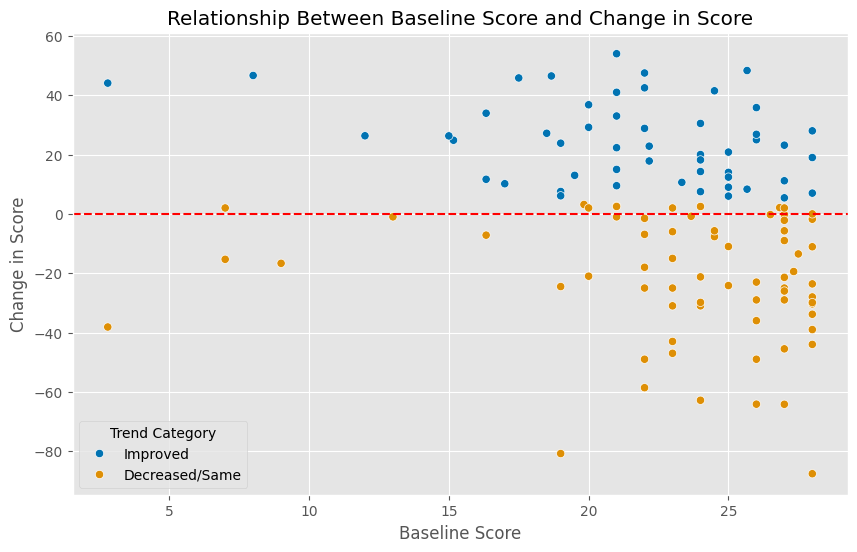

In [38]:
# Create a scatter plot of Baseline vs Change
plt.figure(figsize=(10, 6))
sns.scatterplot(x="pwb_subscale_score_baseline", y="Change", 
                hue="Trend Category", 
                data=merged_df_removedNA_pwb)
plt.title("Relationship Between Baseline Score and Change in Score")
plt.xlabel("Baseline Score")
plt.ylabel("Change in Score")
plt.axhline(y=0, color='r', linestyle='--')  # Add a horizontal line at y=0
plt.legend(title="Trend Category")
plt.show()

# sensitivity analysis 0B) PWB baseline 

Sensitivity Analysis Results:
    threshold  improvement_rate  mean_pwb_improved  mean_pwb_not_improved  \
0           0          0.504132          21.556831              23.885556   
1           1          0.495868          21.449444              23.953005   
2           2          0.495868          21.449444              23.953005   
3           3          0.429752          21.483333              23.637198   
4           4          0.421488          21.515686              23.582857   
5           5          0.421488          21.515686              23.582857   
6           6          0.413223          21.406000              23.630986   
7           7          0.396694          21.381250              23.586301   
8           8          0.371901          21.228889              23.589474   
9           9          0.363636          21.128030              23.616450   
10         10          0.347107          21.038889              23.600844   

    mann_whitney_p  logistic_p  odds_ratio  


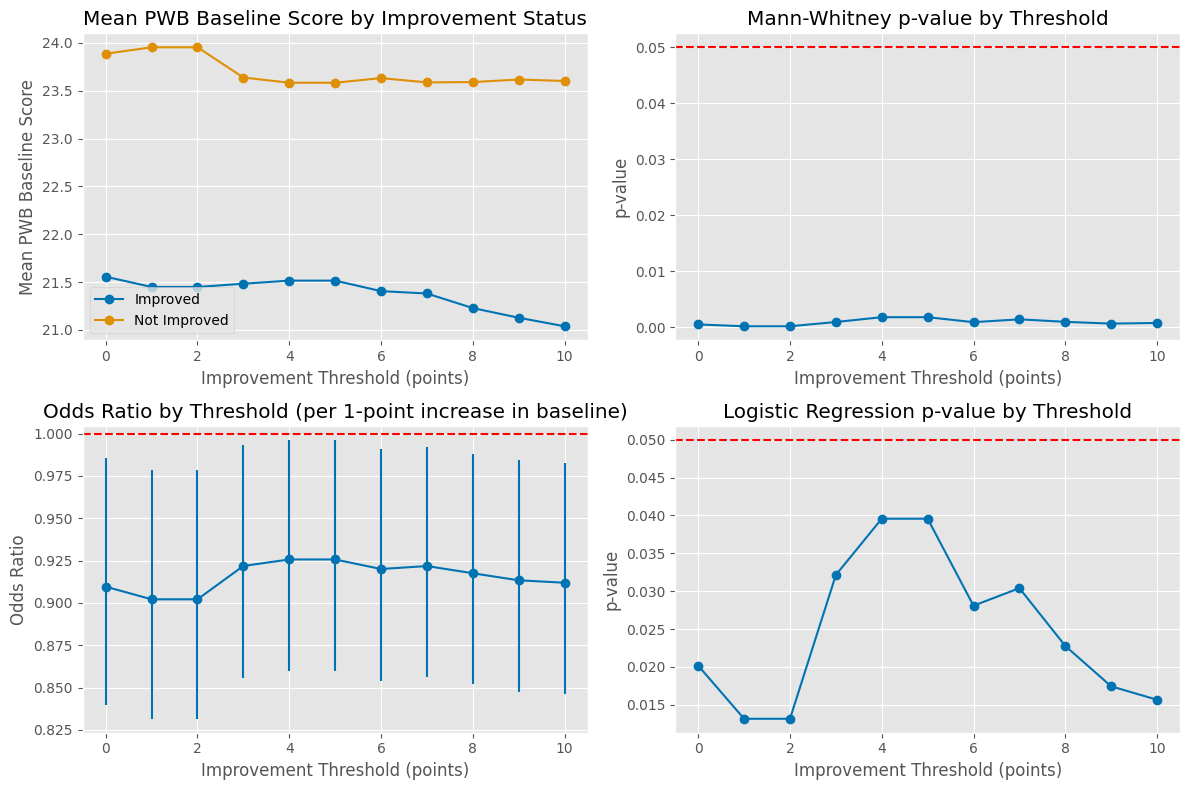


Patient Counts at Different Thresholds:
    Threshold  Improved Count  Decreased/Same Count  Improved %  \
0           0              61                    60   50.413223   
1           1              60                    61   49.586777   
2           2              60                    61   49.586777   
3           3              52                    69   42.975207   
4           4              51                    70   42.148760   
5           5              51                    70   42.148760   
6           6              50                    71   41.322314   
7           7              48                    73   39.669421   
8           8              45                    76   37.190083   
9           9              44                    77   36.363636   
10         10              42                    79   34.710744   

    Decreased/Same %  
0          49.586777  
1          50.413223  
2          50.413223  
3          57.024793  
4          57.851240  
5          57.85

In [39]:
def analyze_improvement_threshold(data, threshold):
    """
    Analyze how the improvement threshold affects classification and baseline score relationship
    
    Parameters:
    data: DataFrame containing Baseline and Change scores
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the new threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    df["Trend Category_binary"] = df["Improved"].astype(int)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count
    
    # Mann-Whitney U test
    improved_baseline = df[df["Improved"]]["pwb_subscale_score_baseline"]
    decreased_same_baseline = df[~df["Improved"]]["pwb_subscale_score_baseline"]
    
    if len(improved_baseline) > 0 and len(decreased_same_baseline) > 0:
        stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
    else:
        stat, p_value = None, None
        
    # Mean pwb_subscale_score_baseline in each group
    mean_pwb_improved = improved_baseline.mean() if len(improved_baseline) > 0 else None
    mean_pwb_not_improved = decreased_same_baseline.mean() if len(decreased_same_baseline) > 0 else None
    
    # Logistic regression
    X = sm.add_constant(df["pwb_subscale_score_baseline"])
    y = df["Trend Category_binary"]
    
    try:
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        baseline_coef = result.params["pwb_subscale_score_baseline"]
        baseline_p = result.pvalues["pwb_subscale_score_baseline"]
        odds_ratio = np.exp(baseline_coef)
        
        # Confidence intervals
        baseline_conf_int = result.conf_int().loc["pwb_subscale_score_baseline"]
        lower_ci = np.exp(baseline_conf_int[0])
        upper_ci = np.exp(baseline_conf_int[1])
    except:
        baseline_coef = None
        baseline_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "mean_pwb_improved": mean_pwb_improved,
        "mean_pwb_not_improved": mean_pwb_not_improved,
        "mann_whitney_stat": stat,
        "mann_whitney_p": p_value,
        "logistic_coef": baseline_coef,
        "logistic_p": baseline_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Prepare clean dataset
merged_df_clean = merged_df_pwb.dropna(subset=["pwb_subscale_score_baseline", "Change"]).drop_duplicates()

for threshold in thresholds:
    result = analyze_improvement_threshold(merged_df_clean, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis Results:")
print(sensitivity_df[["threshold", "improvement_rate", "mean_pwb_improved", "mean_pwb_not_improved", "mann_whitney_p", "logistic_p", "odds_ratio"]])


# Plot how improvement rate changes with threshold
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_pwb_improved"], 'o-', label='Improved')
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_pwb_not_improved"], 'o-', label='Not Improved')
plt.title("Mean PWB Baseline Score by Improvement Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Mean PWB Baseline Score")
plt.legend()
plt.grid(True)


# Plot p-values from Mann-Whitney test
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mann_whitney_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Mann-Whitney p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot odds ratios from logistic regression
plt.subplot(2, 2, 3)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio by Threshold (per 1-point increase in baseline)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

# Plot p-values from logistic regression
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["logistic_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Create a table showing the number and percentage of patients in each category at different thresholds
category_counts = []

for threshold in thresholds:
    df_temp = merged_df_clean.copy()
    df_temp["Improved"] = df_temp["Change"] >= threshold
    improved_count = df_temp["Improved"].sum()
    total = len(df_temp)
    
    category_counts.append({
        "Threshold": threshold,
        "Improved Count": improved_count,
        "Decreased/Same Count": total - improved_count,
        "Improved %": (improved_count / total) * 100,
        "Decreased/Same %": ((total - improved_count) / total) * 100
    })

category_df = pd.DataFrame(category_counts)
print("\nPatient Counts at Different Thresholds:")
print(category_df)

# statistically significantly associated with 0C) SWB baseline 

In [40]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [41]:
score_info = pd.read_csv("results.csv")
score_info

,id,baseline_type,pwb_subscale_score_baseline,pwb_subscale_score_one_year,pwb_subscale_score_improvement,pwb_subscale_score_has_improved,swb_subscale_score_baseline,swb_subscale_score_one_year,swb_subscale_score_improvement,swb_subscale_score_has_improved,...,fact_g_total_improvement,fact_g_total_has_improved,fact_e_total_baseline,fact_e_total_one_year,fact_e_total_improvement,fact_e_total_has_improved,toi_baseline,toi_one_year,toi_improvement,toi_has_improved
0,32,baseline_arm_1,24.5,27.0,2.5,False,22.0,28.0,6.0,True,...,32.5,True,117.5,159.0,41.5,True,89.5,107.0,17.5,True
1,76,preoperative_arm_1,7.0,7.0,0.0,False,23.0,21.0,-2.0,False,...,-10.0,False,95.0,97.0,2.0,False,58.0,65.0,7.0,True
2,125,baseline_arm_1,21.0,22.0,1.0,False,17.5,21.0,3.5,False,...,7.5,True,119.5,129.0,9.5,True,81.0,89.0,8.0,True
3,160,baseline_arm_1,21.0,28.0,7.0,True,20.0,22.0,2.0,False,...,13.0,True,119.0,152.0,33.0,True,78.0,107.0,29.0,True
4,198,baseline_arm_1,25.0,26.5,1.5,False,13.0,18.0,5.0,True,...,12.0,True,133.0,139.0,6.0,True,103.0,98.0,-5.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138,1572,baseline_arm_1,27.0,24.0,-3.0,False,13.0,21.0,8.0,True,...,-1.0,False,141.0,115.0,-26.0,False,109.0,76.0,-33.0,False
139,1615,baseline_arm_1,23.0,19.0,-4.0,False,24.0,22.0,-2.0,False,...,-1.0,False,126.0,111.0,-15.0,False,86.0,69.0,-17.0,False
140,1621,baseline_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
141,1653,baseline_arm_1,21.0,26.0,5.0,True,19.0,21.0,2.0,False,...,9.0,True,112.0,153.0,41.0,True,75.0,116.0,41.0,True


In [42]:
merged_df_swb = score_comparison.merge(score_info[["id", "swb_subscale_score_baseline"]], on="id", how="left")
merged_df_removedNA_swb = merged_df_swb.dropna(subset=["swb_subscale_score_baseline"])
merged_df_expanded_swb = merged_df_removedNA_swb.drop_duplicates()
merged_df_removedNA_swb = merged_df_expanded_swb.copy()
merged_df_removedNA_swb

,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,swb_subscale_score_baseline
0,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,22.0
1,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,23.0
2,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,17.5
3,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,20.0
4,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,13.0
...,...,...,...,...,...,...,...,...
116,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,24.0
117,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,28.0
118,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,13.0
119,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,24.0


In [43]:
# Show summary statistics by improvement group
print("\nBaseline scores by Trend Category:")
print(merged_df_removedNA_swb.groupby("Trend Category")["swb_subscale_score_baseline"].describe())


Baseline scores by Trend Category:
                count       mean       std   min   25%   50%     75%   max
Trend Category                                                            
Decreased/Same   70.0  23.741349  4.081648  13.0  21.0  24.5  27.825  28.0
Improved         51.0  20.111874  6.096211   2.0  17.0  21.0  24.500  28.0


In [44]:
# Perform Mann-Whitney U test to compare Baseline scores between groups
improved_baseline = merged_df_removedNA_swb[merged_df_removedNA_swb["Trend Category"] == "Improved"]["swb_subscale_score_baseline"]
decreased_same_baseline = merged_df_removedNA_swb[merged_df_removedNA_swb["Trend Category"] == "Decreased/Same"]["swb_subscale_score_baseline"]

stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
print(f"\nMann-Whitney U test:")
print(f"Statistic: {stat}")
print(f"p-value: {p_value}")


Mann-Whitney U test:
Statistic: 1117.5
p-value: 0.0004407606342050442


In [45]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_swb["Trend Category_binary"] = merged_df_removedNA_swb["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Logistic regression with Baseline as predictor
X = sm.add_constant(merged_df_removedNA_swb["swb_subscale_score_baseline"])
y = merged_df_removedNA_swb["Trend Category_binary"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print("\nLogistic Regression Results:")
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.620763
         Iterations 5

Logistic Regression Results:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  121
Model:                             Logit   Df Residuals:                      119
Method:                              MLE   Df Model:                            1
Date:                   Wed, 25 Jun 2025   Pseudo R-squ.:                 0.08814
Time:                           11:41:34   Log-Likelihood:                -75.112
converged:                          True   LL-Null:                       -82.373
Covariance Type:               nonrobust   LLR p-value:                 0.0001386
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const               


Odds Ratio for a 10-point increase in baseline score: 0.235
95% CI for a 10-point increase in baseline score: (0.103, 0.533)


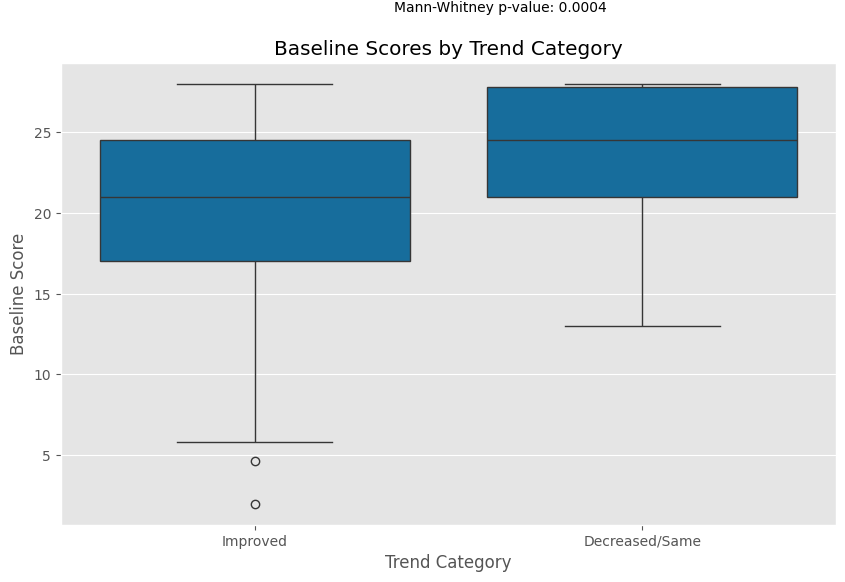

In [46]:
# Calculate odds ratio for a 10-point increase in baseline score
baseline_coef = result.params["swb_subscale_score_baseline"]
odds_ratio_10points = np.exp(baseline_coef * 10)
print(f"\nOdds Ratio for a 10-point increase in baseline score: {odds_ratio_10points:.3f}")

# Calculate confidence interval for the odds ratio
baseline_conf_int = result.conf_int().loc["swb_subscale_score_baseline"]
lower_ci_10points = np.exp(baseline_conf_int[0] * 10)
upper_ci_10points = np.exp(baseline_conf_int[1] * 10)
print(f"95% CI for a 10-point increase in baseline score: ({lower_ci_10points:.3f}, {upper_ci_10points:.3f})")

# Visualize with boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x="Trend Category", y="swb_subscale_score_baseline", data=merged_df_removedNA_swb)
plt.title("Baseline Scores by Trend Category")
plt.xlabel("Trend Category")
plt.ylabel("Baseline Score")
plt.annotate(f"Mann-Whitney p-value: {p_value:.4f}", xy=(0.5, 0.95), 
                xycoords='figure fraction', ha='center')
plt.show()

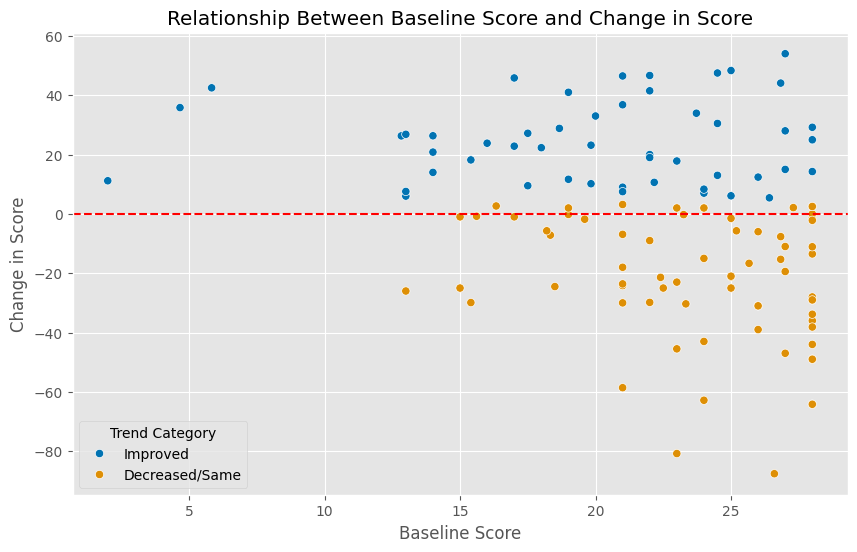

In [47]:
# Create a scatter plot of Baseline vs Change
plt.figure(figsize=(10, 6))
sns.scatterplot(x="swb_subscale_score_baseline", y="Change", 
                hue="Trend Category", 
                data=merged_df_removedNA_swb)
plt.title("Relationship Between Baseline Score and Change in Score")
plt.xlabel("Baseline Score")
plt.ylabel("Change in Score")
plt.axhline(y=0, color='r', linestyle='--')  # Add a horizontal line at y=0
plt.legend(title="Trend Category")
plt.show()

# sensitivity analysis 0C) SWB baseline 

Sensitivity Analysis Results:
    threshold  improvement_rate  mean_swb_improved  mean_swb_not_improved  \
0           0          0.504132          20.726867              23.721019   
1           1          0.495868          20.605648              23.791166   
2           2          0.495868          20.605648              23.791166   
3           3          0.429752          20.128953              23.781079   
4           4          0.421488          20.111874              23.741349   
5           5          0.421488          20.111874              23.741349   
6           6          0.413223          19.985778              23.779030   
7           7          0.396694          20.026852              23.648097   
8           8          0.371901          20.073086              23.477778   
9           9          0.363636          19.983838              23.484560   
10         10          0.347107          20.018783              23.377356   

    mann_whitney_p  logistic_p  odds_ratio  


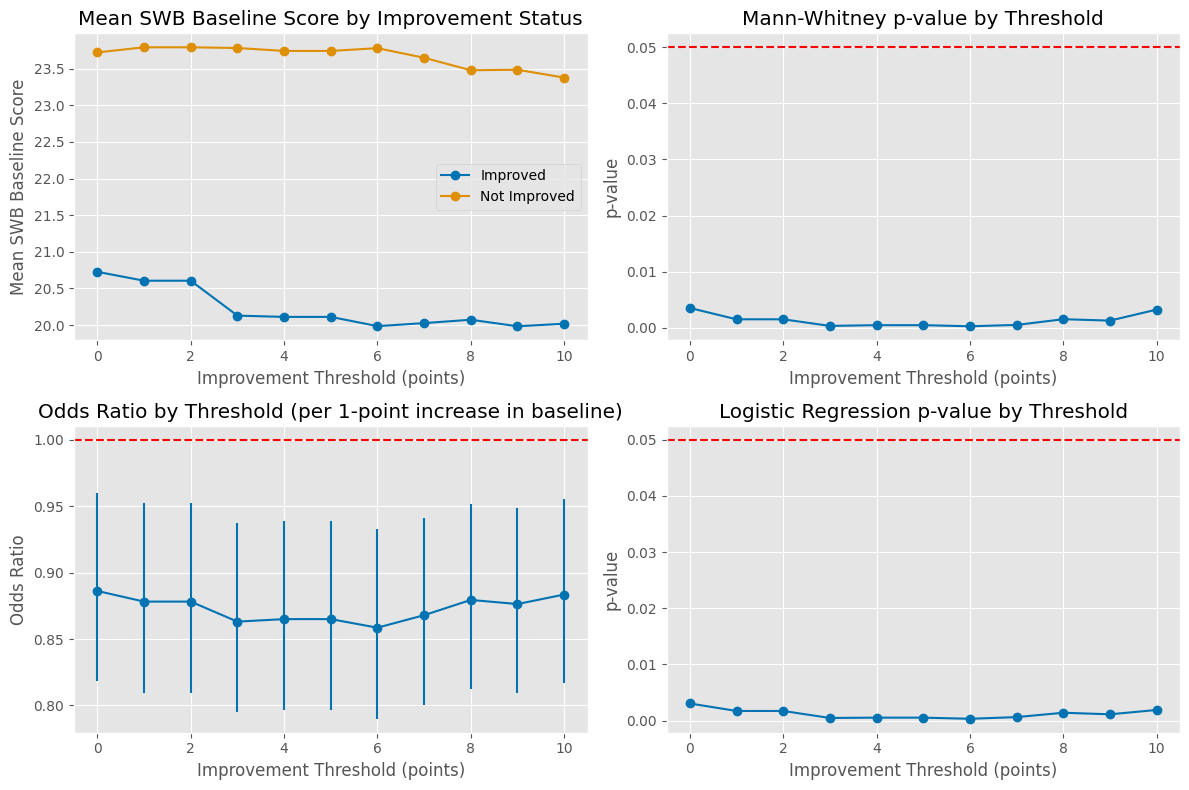


Patient Counts at Different Thresholds:
    Threshold  Improved Count  Decreased/Same Count  Improved %  \
0           0              61                    60   50.413223   
1           1              60                    61   49.586777   
2           2              60                    61   49.586777   
3           3              52                    69   42.975207   
4           4              51                    70   42.148760   
5           5              51                    70   42.148760   
6           6              50                    71   41.322314   
7           7              48                    73   39.669421   
8           8              45                    76   37.190083   
9           9              44                    77   36.363636   
10         10              42                    79   34.710744   

    Decreased/Same %  
0          49.586777  
1          50.413223  
2          50.413223  
3          57.024793  
4          57.851240  
5          57.85

In [48]:
def analyze_improvement_threshold(data, threshold):
    """
    Analyze how the improvement threshold affects classification and baseline score relationship
    
    Parameters:
    data: DataFrame containing Baseline and Change scores
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the new threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    df["Trend Category_binary"] = df["Improved"].astype(int)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count
    
    # Mann-Whitney U test
    improved_baseline = df[df["Improved"]]["swb_subscale_score_baseline"]
    decreased_same_baseline = df[~df["Improved"]]["swb_subscale_score_baseline"]
    
    if len(improved_baseline) > 0 and len(decreased_same_baseline) > 0:
        stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
    else:
        stat, p_value = None, None
        
    # Mean swb_subscale_score_baseline in each group
    mean_swb_improved = improved_baseline.mean() if len(improved_baseline) > 0 else None
    mean_swb_not_improved = decreased_same_baseline.mean() if len(decreased_same_baseline) > 0 else None
    
    # Logistic regression
    X = sm.add_constant(df["swb_subscale_score_baseline"])
    y = df["Trend Category_binary"]
    
    try:
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        baseline_coef = result.params["swb_subscale_score_baseline"]
        baseline_p = result.pvalues["swb_subscale_score_baseline"]
        odds_ratio = np.exp(baseline_coef)
        
        # Confidence intervals
        baseline_conf_int = result.conf_int().loc["swb_subscale_score_baseline"]
        lower_ci = np.exp(baseline_conf_int[0])
        upper_ci = np.exp(baseline_conf_int[1])
    except:
        baseline_coef = None
        baseline_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "mean_swb_improved": mean_swb_improved,
        "mean_swb_not_improved": mean_swb_not_improved,
        "mann_whitney_stat": stat,
        "mann_whitney_p": p_value,
        "logistic_coef": baseline_coef,
        "logistic_p": baseline_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Prepare clean dataset
merged_df_clean = merged_df_swb.dropna(subset=["swb_subscale_score_baseline", "Change"]).drop_duplicates()

for threshold in thresholds:
    result = analyze_improvement_threshold(merged_df_clean, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis Results:")
print(sensitivity_df[["threshold", "improvement_rate", "mean_swb_improved", "mean_swb_not_improved", "mann_whitney_p", "logistic_p", "odds_ratio"]])


# Plot how improvement rate changes with threshold
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_swb_improved"], 'o-', label='Improved')
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_swb_not_improved"], 'o-', label='Not Improved')
plt.title("Mean SWB Baseline Score by Improvement Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Mean SWB Baseline Score")
plt.legend()
plt.grid(True)

# Plot p-values from Mann-Whitney test
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mann_whitney_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Mann-Whitney p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot odds ratios from logistic regression
plt.subplot(2, 2, 3)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio by Threshold (per 1-point increase in baseline)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

# Plot p-values from logistic regression
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["logistic_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Create a table showing the number and percentage of patients in each category at different thresholds
category_counts = []

for threshold in thresholds:
    df_temp = merged_df_clean.copy()
    df_temp["Improved"] = df_temp["Change"] >= threshold
    improved_count = df_temp["Improved"].sum()
    total = len(df_temp)
    
    category_counts.append({
        "Threshold": threshold,
        "Improved Count": improved_count,
        "Decreased/Same Count": total - improved_count,
        "Improved %": (improved_count / total) * 100,
        "Decreased/Same %": ((total - improved_count) / total) * 100
    })

category_df = pd.DataFrame(category_counts)
print("\nPatient Counts at Different Thresholds:")
print(category_df)

# statistically significantly associated with 0d) EWB baseline 

In [49]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [50]:
score_info = pd.read_csv("results.csv")
score_info

,id,baseline_type,pwb_subscale_score_baseline,pwb_subscale_score_one_year,pwb_subscale_score_improvement,pwb_subscale_score_has_improved,swb_subscale_score_baseline,swb_subscale_score_one_year,swb_subscale_score_improvement,swb_subscale_score_has_improved,...,fact_g_total_improvement,fact_g_total_has_improved,fact_e_total_baseline,fact_e_total_one_year,fact_e_total_improvement,fact_e_total_has_improved,toi_baseline,toi_one_year,toi_improvement,toi_has_improved
0,32,baseline_arm_1,24.5,27.0,2.5,False,22.0,28.0,6.0,True,...,32.5,True,117.5,159.0,41.5,True,89.5,107.0,17.5,True
1,76,preoperative_arm_1,7.0,7.0,0.0,False,23.0,21.0,-2.0,False,...,-10.0,False,95.0,97.0,2.0,False,58.0,65.0,7.0,True
2,125,baseline_arm_1,21.0,22.0,1.0,False,17.5,21.0,3.5,False,...,7.5,True,119.5,129.0,9.5,True,81.0,89.0,8.0,True
3,160,baseline_arm_1,21.0,28.0,7.0,True,20.0,22.0,2.0,False,...,13.0,True,119.0,152.0,33.0,True,78.0,107.0,29.0,True
4,198,baseline_arm_1,25.0,26.5,1.5,False,13.0,18.0,5.0,True,...,12.0,True,133.0,139.0,6.0,True,103.0,98.0,-5.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138,1572,baseline_arm_1,27.0,24.0,-3.0,False,13.0,21.0,8.0,True,...,-1.0,False,141.0,115.0,-26.0,False,109.0,76.0,-33.0,False
139,1615,baseline_arm_1,23.0,19.0,-4.0,False,24.0,22.0,-2.0,False,...,-1.0,False,126.0,111.0,-15.0,False,86.0,69.0,-17.0,False
140,1621,baseline_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
141,1653,baseline_arm_1,21.0,26.0,5.0,True,19.0,21.0,2.0,False,...,9.0,True,112.0,153.0,41.0,True,75.0,116.0,41.0,True


In [51]:
merged_df_ewb = score_comparison.merge(score_info[["id", "ewb_subscale_score_baseline"]], on="id", how="left")

# Create a clean dataframe with no missing values in ewb_subscale_score_baseline
merged_df_removedNA_ewb = merged_df_ewb.dropna(subset=["ewb_subscale_score_baseline"])
merged_df_expanded_ewb = merged_df_removedNA_ewb.drop_duplicates()
merged_df_removedNA_ewb = merged_df_expanded_ewb.copy()
merged_df_removedNA_ewb


,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,ewb_subscale_score_baseline
0,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,6.0
1,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,14.0
2,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,21.0
3,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,21.0
4,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,17.0
...,...,...,...,...,...,...,...,...
116,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,18.0
117,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,16.0
118,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,19.0
119,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,16.0


In [52]:
# Show summary statistics by improvement group
print("\nBaseline scores by Trend Category:")
print(merged_df_removedNA_ewb.groupby("Trend Category")["ewb_subscale_score_baseline"].describe())


Baseline scores by Trend Category:
                count       mean       std  min   25%   50%    75%   max
Trend Category                                                          
Decreased/Same   70.0  16.976190  4.712105  4.0  14.0  18.0  20.25  24.0
Improved         51.0  14.896732  4.833371  4.0  11.5  15.0  18.00  24.0


In [53]:
# Perform Mann-Whitney U test to compare Baseline scores between groups
improved_baseline = merged_df_removedNA_ewb[merged_df_removedNA_ewb["Trend Category"] == "Improved"]["ewb_subscale_score_baseline"]
decreased_same_baseline = merged_df_removedNA_ewb[merged_df_removedNA_ewb["Trend Category"] == "Decreased/Same"]["ewb_subscale_score_baseline"]

stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
print(f"\nMann-Whitney U test:")
print(f"Statistic: {stat}")
print(f"p-value: {p_value}")


Mann-Whitney U test:
Statistic: 1332.5
p-value: 0.017455974699036068


In [54]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_ewb["Trend Category_binary"] = merged_df_removedNA_ewb["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Logistic regression with Baseline as predictor
X = sm.add_constant(merged_df_removedNA_ewb["ewb_subscale_score_baseline"])
y = merged_df_removedNA_ewb["Trend Category_binary"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print("\nLogistic Regression Results:")
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.657953
         Iterations 5

Logistic Regression Results:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  121
Model:                             Logit   Df Residuals:                      119
Method:                              MLE   Df Model:                            1
Date:                   Wed, 25 Jun 2025   Pseudo R-squ.:                 0.03351
Time:                           11:41:35   Log-Likelihood:                -79.612
converged:                          True   LL-Null:                       -82.373
Covariance Type:               nonrobust   LLR p-value:                   0.01879
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const               


Odds Ratio for a 10-point increase in baseline score: 0.401
95% CI for a 10-point increase in baseline score: (0.183, 0.877)


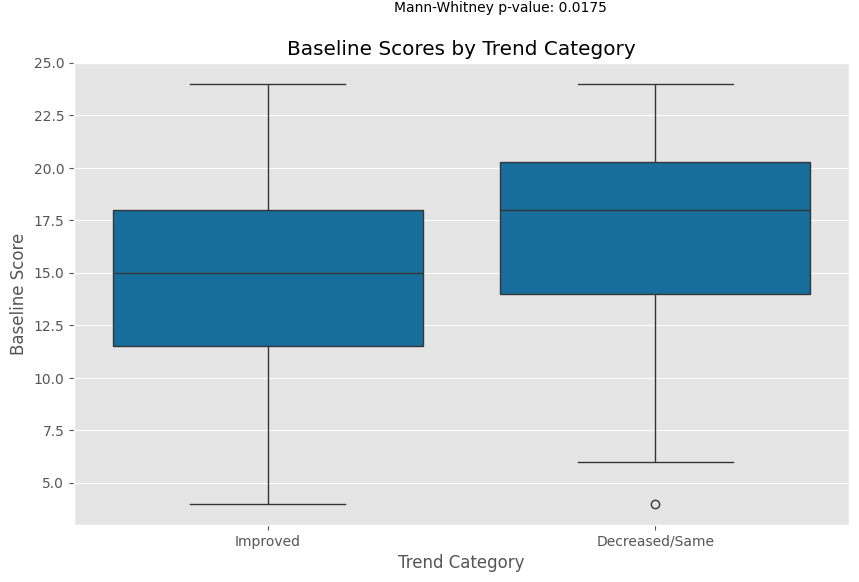

In [55]:
# Calculate odds ratio for a 10-point increase in baseline score
baseline_coef = result.params["ewb_subscale_score_baseline"]
odds_ratio_10points = np.exp(baseline_coef * 10)
print(f"\nOdds Ratio for a 10-point increase in baseline score: {odds_ratio_10points:.3f}")

# Calculate confidence interval for the odds ratio
baseline_conf_int = result.conf_int().loc["ewb_subscale_score_baseline"]
lower_ci_10points = np.exp(baseline_conf_int[0] * 10)
upper_ci_10points = np.exp(baseline_conf_int[1] * 10)
print(f"95% CI for a 10-point increase in baseline score: ({lower_ci_10points:.3f}, {upper_ci_10points:.3f})")

# Visualize with boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x="Trend Category", y="ewb_subscale_score_baseline", data=merged_df_removedNA_ewb)
plt.title("Baseline Scores by Trend Category")
plt.xlabel("Trend Category")
plt.ylabel("Baseline Score")
plt.annotate(f"Mann-Whitney p-value: {p_value:.4f}", xy=(0.5, 0.95), 
             xycoords='figure fraction', ha='center')
plt.show()

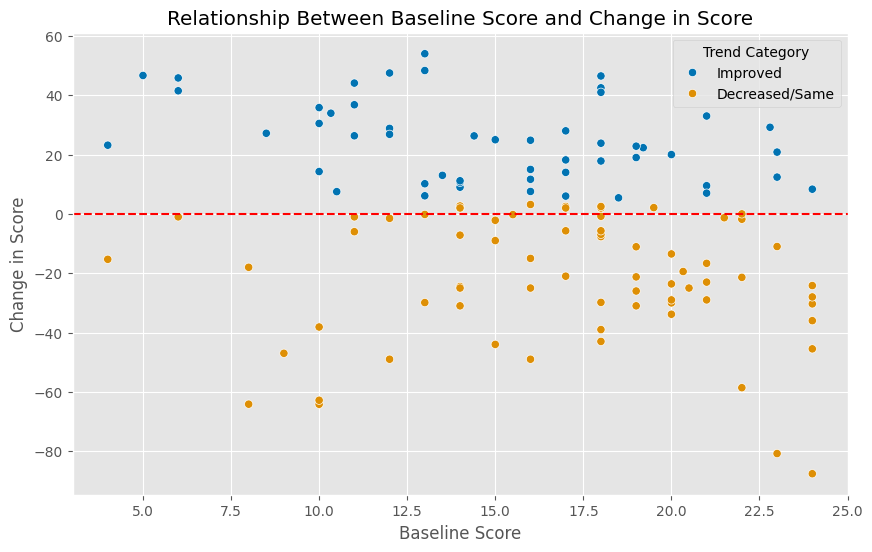

In [56]:

# Create a scatter plot of Baseline vs Change
plt.figure(figsize=(10, 6))
sns.scatterplot(x="ewb_subscale_score_baseline", y="Change", 
                hue="Trend Category", 
                data=merged_df_removedNA_ewb)
plt.title("Relationship Between Baseline Score and Change in Score")
plt.xlabel("Baseline Score")
plt.ylabel("Change in Score")
plt.axhline(y=0, color='r', linestyle='--')  # Add a horizontal line at y=0
plt.legend(title="Trend Category")
plt.show()

# sensitivity analysis 0d) EWB baseline 

Sensitivity Analysis Results:
    threshold  improvement_rate  mean_ewb_improved  mean_ewb_not_improved  \
0           0          0.504132          15.233333              16.980556   
1           1          0.495868          15.120556              17.062842   
2           2          0.495868          15.120556              17.062842   
3           3          0.429752          14.917949              16.990338   
4           4          0.421488          14.896732              16.976190   
5           5          0.421488          14.896732              16.976190   
6           6          0.413223          14.824667              16.997653   
7           7          0.396694          14.817361              16.942922   
8           8          0.371901          14.749630              16.899123   
9           9          0.363636          14.539394              16.991342   
10         10          0.347107          14.398413              17.004219   

    mann_whitney_p  logistic_p  odds_ratio  


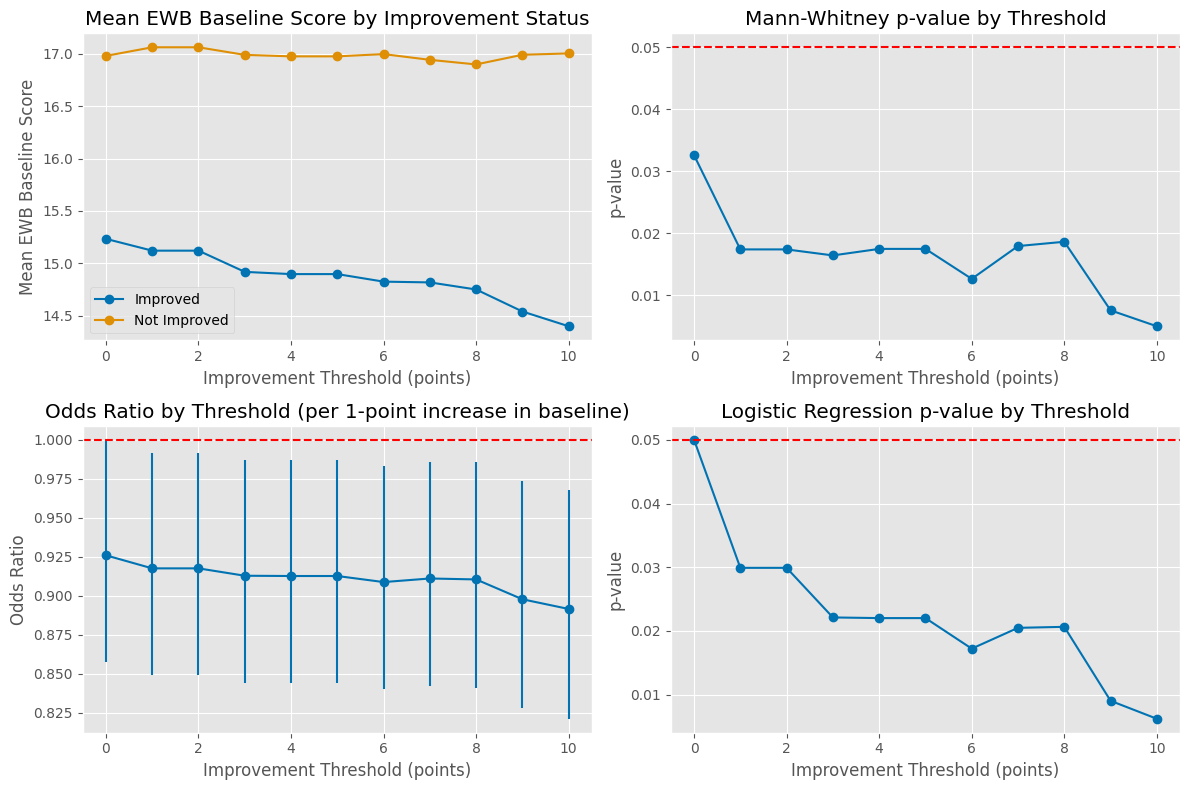


Patient Counts at Different Thresholds:
    Threshold  Improved Count  Decreased/Same Count  Improved %  \
0           0              61                    60   50.413223   
1           1              60                    61   49.586777   
2           2              60                    61   49.586777   
3           3              52                    69   42.975207   
4           4              51                    70   42.148760   
5           5              51                    70   42.148760   
6           6              50                    71   41.322314   
7           7              48                    73   39.669421   
8           8              45                    76   37.190083   
9           9              44                    77   36.363636   
10         10              42                    79   34.710744   

    Decreased/Same %  
0          49.586777  
1          50.413223  
2          50.413223  
3          57.024793  
4          57.851240  
5          57.85

In [57]:
def analyze_improvement_threshold(data, threshold):
    """
    Analyze how the improvement threshold affects classification and baseline score relationship
    
    Parameters:
    data: DataFrame containing Baseline and Change scores
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the new threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    df["Trend Category_binary"] = df["Improved"].astype(int)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count
    
    # Mann-Whitney U test
    improved_baseline = df[df["Improved"]]["ewb_subscale_score_baseline"]
    decreased_same_baseline = df[~df["Improved"]]["ewb_subscale_score_baseline"]
    
    if len(improved_baseline) > 0 and len(decreased_same_baseline) > 0:
        stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
    else:
        stat, p_value = None, None
        
    # Mean ewb_subscale_score_baseline in each group
    mean_ewb_improved = improved_baseline.mean() if len(improved_baseline) > 0 else None
    mean_ewb_not_improved = decreased_same_baseline.mean() if len(decreased_same_baseline) > 0 else None
    
    # Logistic regression
    X = sm.add_constant(df["ewb_subscale_score_baseline"])
    y = df["Trend Category_binary"]
    
    try:
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        baseline_coef = result.params["ewb_subscale_score_baseline"]
        baseline_p = result.pvalues["ewb_subscale_score_baseline"]
        odds_ratio = np.exp(baseline_coef)
        
        # Confidence intervals
        baseline_conf_int = result.conf_int().loc["ewb_subscale_score_baseline"]
        lower_ci = np.exp(baseline_conf_int[0])
        upper_ci = np.exp(baseline_conf_int[1])
    except:
        baseline_coef = None
        baseline_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "mean_ewb_improved": mean_ewb_improved,
        "mean_ewb_not_improved": mean_ewb_not_improved,
        "mann_whitney_stat": stat,
        "mann_whitney_p": p_value,
        "logistic_coef": baseline_coef,
        "logistic_p": baseline_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Prepare clean dataset
merged_df_clean = merged_df_ewb.dropna(subset=["ewb_subscale_score_baseline", "Change"]).drop_duplicates()

for threshold in thresholds:
    result = analyze_improvement_threshold(merged_df_clean, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis Results:")
print(sensitivity_df[["threshold", "improvement_rate", "mean_ewb_improved", "mean_ewb_not_improved", "mann_whitney_p", "logistic_p", "odds_ratio"]])

# Plot how improvement rate changes with threshold
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_ewb_improved"], 'o-', label='Improved')
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_ewb_not_improved"], 'o-', label='Not Improved')
plt.title("Mean EWB Baseline Score by Improvement Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Mean EWB Baseline Score")
plt.legend()
plt.grid(True)

# Plot p-values from Mann-Whitney test
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mann_whitney_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Mann-Whitney p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot odds ratios from logistic regression
plt.subplot(2, 2, 3)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio by Threshold (per 1-point increase in baseline)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

# Plot p-values from logistic regression
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["logistic_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Create a table showing the number and percentage of patients in each category at different thresholds
category_counts = []

for threshold in thresholds:
    df_temp = merged_df_clean.copy()
    df_temp["Improved"] = df_temp["Change"] >= threshold
    improved_count = df_temp["Improved"].sum()
    total = len(df_temp)
    
    category_counts.append({
        "Threshold": threshold,
        "Improved Count": improved_count,
        "Decreased/Same Count": total - improved_count,
        "Improved %": (improved_count / total) * 100,
        "Decreased/Same %": ((total - improved_count) / total) * 100
    })

category_df = pd.DataFrame(category_counts)
print("\nPatient Counts at Different Thresholds:")
print(category_df)

# statistically significantly associated with 0e) FWB baseline 

In [58]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [59]:
score_info = pd.read_csv("results.csv")
score_info

,id,baseline_type,pwb_subscale_score_baseline,pwb_subscale_score_one_year,pwb_subscale_score_improvement,pwb_subscale_score_has_improved,swb_subscale_score_baseline,swb_subscale_score_one_year,swb_subscale_score_improvement,swb_subscale_score_has_improved,...,fact_g_total_improvement,fact_g_total_has_improved,fact_e_total_baseline,fact_e_total_one_year,fact_e_total_improvement,fact_e_total_has_improved,toi_baseline,toi_one_year,toi_improvement,toi_has_improved
0,32,baseline_arm_1,24.5,27.0,2.5,False,22.0,28.0,6.0,True,...,32.5,True,117.5,159.0,41.5,True,89.5,107.0,17.5,True
1,76,preoperative_arm_1,7.0,7.0,0.0,False,23.0,21.0,-2.0,False,...,-10.0,False,95.0,97.0,2.0,False,58.0,65.0,7.0,True
2,125,baseline_arm_1,21.0,22.0,1.0,False,17.5,21.0,3.5,False,...,7.5,True,119.5,129.0,9.5,True,81.0,89.0,8.0,True
3,160,baseline_arm_1,21.0,28.0,7.0,True,20.0,22.0,2.0,False,...,13.0,True,119.0,152.0,33.0,True,78.0,107.0,29.0,True
4,198,baseline_arm_1,25.0,26.5,1.5,False,13.0,18.0,5.0,True,...,12.0,True,133.0,139.0,6.0,True,103.0,98.0,-5.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138,1572,baseline_arm_1,27.0,24.0,-3.0,False,13.0,21.0,8.0,True,...,-1.0,False,141.0,115.0,-26.0,False,109.0,76.0,-33.0,False
139,1615,baseline_arm_1,23.0,19.0,-4.0,False,24.0,22.0,-2.0,False,...,-1.0,False,126.0,111.0,-15.0,False,86.0,69.0,-17.0,False
140,1621,baseline_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
141,1653,baseline_arm_1,21.0,26.0,5.0,True,19.0,21.0,2.0,False,...,9.0,True,112.0,153.0,41.0,True,75.0,116.0,41.0,True


In [60]:
merged_df_fwb = score_comparison.merge(score_info[["id", "fwb_subscale_score_baseline"]], on="id", how="left")
# Create a clean dataframe with no missing values in fwb_subscale_score_baseline
merged_df_removedNA_fwb = merged_df_fwb.dropna(subset=["fwb_subscale_score_baseline"])
merged_df_expanded_fwb = merged_df_removedNA_fwb.drop_duplicates()
merged_df_removedNA_fwb = merged_df_expanded_fwb.copy()
merged_df_removedNA_fwb


,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,fwb_subscale_score_baseline
0,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,19.0
1,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,15.0
2,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,8.0
3,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,20.0
4,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,21.0
...,...,...,...,...,...,...,...,...
116,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,18.0
117,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,25.0
118,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,20.0
119,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,12.0


In [61]:
# Show summary statistics by improvement group
print("\nBaseline scores by Trend Category:")
print(merged_df_removedNA_fwb.groupby("Trend Category")["fwb_subscale_score_baseline"].describe())


Baseline scores by Trend Category:
                count       mean       std  min   25%     50%    75%  \
Trend Category                                                         
Decreased/Same   70.0  20.395952  6.245566  7.0  15.0  21.875  25.75   
Improved         51.0  16.490196  6.172107  2.0  13.0  17.000  21.00   

                      max  
Trend Category             
Decreased/Same  28.000000  
Improved        26.833333  


In [62]:
# Perform Mann-Whitney U test to compare Baseline scores between groups
improved_baseline = merged_df_removedNA_fwb[merged_df_removedNA_fwb["Trend Category"] == "Improved"]["fwb_subscale_score_baseline"]
decreased_same_baseline = merged_df_removedNA_fwb[merged_df_removedNA_fwb["Trend Category"] == "Decreased/Same"]["fwb_subscale_score_baseline"]

stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
print(f"\nMann-Whitney U test:")
print(f"Statistic: {stat}")
print(f"p-value: {p_value}")


Mann-Whitney U test:
Statistic: 1153.0
p-value: 0.0009040561748114833


In [63]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_fwb["Trend Category_binary"] = merged_df_removedNA_fwb["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Logistic regression with Baseline as predictor
X = sm.add_constant(merged_df_removedNA_fwb["fwb_subscale_score_baseline"])
y = merged_df_removedNA_fwb["Trend Category_binary"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print("\nLogistic Regression Results:")
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.635173
         Iterations 5

Logistic Regression Results:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  121
Model:                             Logit   Df Residuals:                      119
Method:                              MLE   Df Model:                            1
Date:                   Wed, 25 Jun 2025   Pseudo R-squ.:                 0.06697
Time:                           11:41:37   Log-Likelihood:                -76.856
converged:                          True   LL-Null:                       -82.373
Covariance Type:               nonrobust   LLR p-value:                 0.0008946
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const               


Odds Ratio for a 10-point increase in baseline score: 0.373
95% CI for a 10-point increase in baseline score: (0.203, 0.686)


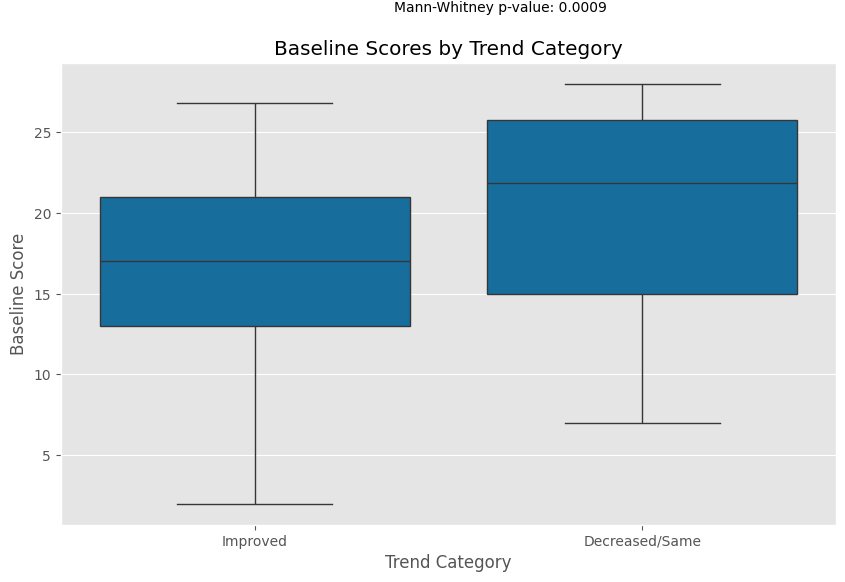

In [64]:
# Calculate odds ratio for a 10-point increase in baseline score
baseline_coef = result.params["fwb_subscale_score_baseline"]
odds_ratio_10points = np.exp(baseline_coef * 10)
print(f"\nOdds Ratio for a 10-point increase in baseline score: {odds_ratio_10points:.3f}")

# Calculate confidence interval for the odds ratio
baseline_conf_int = result.conf_int().loc["fwb_subscale_score_baseline"]
lower_ci_10points = np.exp(baseline_conf_int[0] * 10)
upper_ci_10points = np.exp(baseline_conf_int[1] * 10)
print(f"95% CI for a 10-point increase in baseline score: ({lower_ci_10points:.3f}, {upper_ci_10points:.3f})")

# Visualize with boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x="Trend Category", y="fwb_subscale_score_baseline", data=merged_df_removedNA_fwb)
plt.title("Baseline Scores by Trend Category")
plt.xlabel("Trend Category")
plt.ylabel("Baseline Score")
plt.annotate(f"Mann-Whitney p-value: {p_value:.4f}", xy=(0.5, 0.95), 
             xycoords='figure fraction', ha='center')
plt.show()


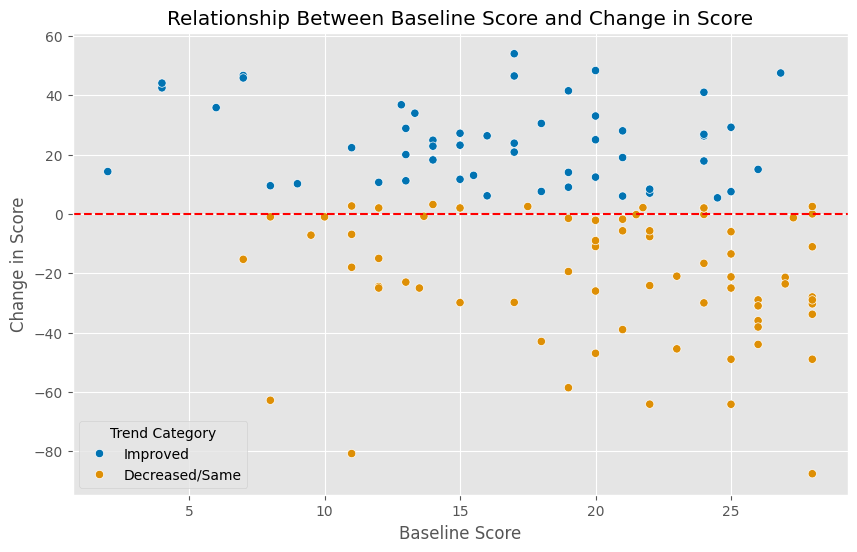

In [65]:
# Create a scatter plot of Baseline vs Change
plt.figure(figsize=(10, 6))
sns.scatterplot(x="fwb_subscale_score_baseline", y="Change", 
                hue="Trend Category", 
                data=merged_df_removedNA_fwb)
plt.title("Relationship Between Baseline Score and Change in Score")
plt.xlabel("Baseline Score")
plt.ylabel("Change in Score")
plt.axhline(y=0, color='r', linestyle='--')  # Add a horizontal line at y=0
plt.legend(title="Trend Category")
plt.show()

# sensitivity analysis 0e) FWB baseline 

Sensitivity Analysis Results:
    threshold  improvement_rate  mean_fwb_improved  mean_fwb_not_improved  \
0           0          0.504132          16.987705              20.541111   
1           1          0.495868          16.804167              20.663388   
2           2          0.495868          16.804167              20.663388   
3           3          0.429752          16.442308              20.488647   
4           4          0.421488          16.490196              20.395952   
5           5          0.421488          16.490196              20.395952   
6           6          0.413223          16.330000              20.453756   
7           7          0.396694          16.239583              20.400228   
8           8          0.371901          15.877778              20.450219   
9           9          0.363636          15.738636              20.470346   
10         10          0.347107          15.845238              20.293882   

    mann_whitney_p  logistic_p  odds_ratio  


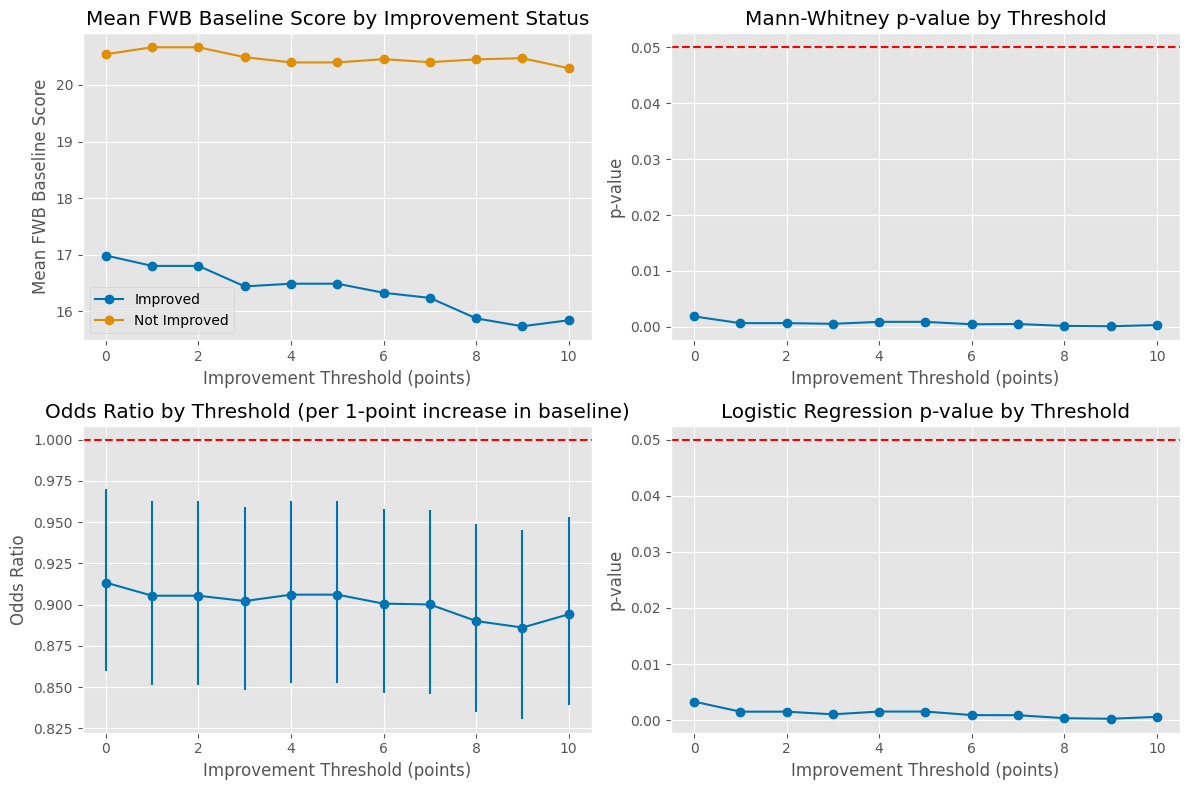


Patient Counts at Different Thresholds:
    Threshold  Improved Count  Decreased/Same Count  Improved %  \
0           0              61                    60   50.413223   
1           1              60                    61   49.586777   
2           2              60                    61   49.586777   
3           3              52                    69   42.975207   
4           4              51                    70   42.148760   
5           5              51                    70   42.148760   
6           6              50                    71   41.322314   
7           7              48                    73   39.669421   
8           8              45                    76   37.190083   
9           9              44                    77   36.363636   
10         10              42                    79   34.710744   

    Decreased/Same %  
0          49.586777  
1          50.413223  
2          50.413223  
3          57.024793  
4          57.851240  
5          57.85

In [66]:
def analyze_improvement_threshold(data, threshold):
    """
    Analyze how the improvement threshold affects classification and baseline score relationship
    
    Parameters:
    data: DataFrame containing Baseline and Change scores
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the new threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    df["Trend Category_binary"] = df["Improved"].astype(int)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count
    
    # Mann-Whitney U test
    improved_baseline = df[df["Improved"]]["fwb_subscale_score_baseline"]
    decreased_same_baseline = df[~df["Improved"]]["fwb_subscale_score_baseline"]
    
    if len(improved_baseline) > 0 and len(decreased_same_baseline) > 0:
        stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
    else:
        stat, p_value = None, None
        
    # Mean fwb_subscale_score_baseline in each group
    mean_fwb_improved = improved_baseline.mean() if len(improved_baseline) > 0 else None
    mean_fwb_not_improved = decreased_same_baseline.mean() if len(decreased_same_baseline) > 0 else None
    
    # Logistic regression
    X = sm.add_constant(df["fwb_subscale_score_baseline"])
    y = df["Trend Category_binary"]
    
    try:
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        baseline_coef = result.params["fwb_subscale_score_baseline"]
        baseline_p = result.pvalues["fwb_subscale_score_baseline"]
        odds_ratio = np.exp(baseline_coef)
        
        # Confidence intervals
        baseline_conf_int = result.conf_int().loc["fwb_subscale_score_baseline"]
        lower_ci = np.exp(baseline_conf_int[0])
        upper_ci = np.exp(baseline_conf_int[1])
    except:
        baseline_coef = None
        baseline_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "mean_fwb_improved": mean_fwb_improved,
        "mean_fwb_not_improved": mean_fwb_not_improved,
        "mann_whitney_stat": stat,
        "mann_whitney_p": p_value,
        "logistic_coef": baseline_coef,
        "logistic_p": baseline_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Prepare clean dataset
merged_df_clean = merged_df_fwb.dropna(subset=["fwb_subscale_score_baseline", "Change"]).drop_duplicates()

for threshold in thresholds:
    result = analyze_improvement_threshold(merged_df_clean, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis Results:")
print(sensitivity_df[["threshold", "improvement_rate", "mean_fwb_improved", "mean_fwb_not_improved", "mann_whitney_p", "logistic_p", "odds_ratio"]])

# Plot how improvement rate changes with threshold
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_fwb_improved"], 'o-', label='Improved')
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_fwb_not_improved"], 'o-', label='Not Improved')
plt.title("Mean FWB Baseline Score by Improvement Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Mean FWB Baseline Score")
plt.legend()
plt.grid(True)

# Plot p-values from Mann-Whitney test
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mann_whitney_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Mann-Whitney p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot odds ratios from logistic regression
plt.subplot(2, 2, 3)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio by Threshold (per 1-point increase in baseline)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

# Plot p-values from logistic regression
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["logistic_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Create a table showing the number and percentage of patients in each category at different thresholds
category_counts = []

for threshold in thresholds:
    df_temp = merged_df_clean.copy()
    df_temp["Improved"] = df_temp["Change"] >= threshold
    improved_count = df_temp["Improved"].sum()
    total = len(df_temp)
    
    category_counts.append({
        "Threshold": threshold,
        "Improved Count": improved_count,
        "Decreased/Same Count": total - improved_count,
        "Improved %": (improved_count / total) * 100,
        "Decreased/Same %": ((total - improved_count) / total) * 100
    })

category_df = pd.DataFrame(category_counts)
print("\nPatient Counts at Different Thresholds:")
print(category_df)

# statistically significantly associated with 0f) ECS baseline 

In [67]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [68]:
score_info = pd.read_csv("results.csv")
score_info

,id,baseline_type,pwb_subscale_score_baseline,pwb_subscale_score_one_year,pwb_subscale_score_improvement,pwb_subscale_score_has_improved,swb_subscale_score_baseline,swb_subscale_score_one_year,swb_subscale_score_improvement,swb_subscale_score_has_improved,...,fact_g_total_improvement,fact_g_total_has_improved,fact_e_total_baseline,fact_e_total_one_year,fact_e_total_improvement,fact_e_total_has_improved,toi_baseline,toi_one_year,toi_improvement,toi_has_improved
0,32,baseline_arm_1,24.5,27.0,2.5,False,22.0,28.0,6.0,True,...,32.5,True,117.5,159.0,41.5,True,89.5,107.0,17.5,True
1,76,preoperative_arm_1,7.0,7.0,0.0,False,23.0,21.0,-2.0,False,...,-10.0,False,95.0,97.0,2.0,False,58.0,65.0,7.0,True
2,125,baseline_arm_1,21.0,22.0,1.0,False,17.5,21.0,3.5,False,...,7.5,True,119.5,129.0,9.5,True,81.0,89.0,8.0,True
3,160,baseline_arm_1,21.0,28.0,7.0,True,20.0,22.0,2.0,False,...,13.0,True,119.0,152.0,33.0,True,78.0,107.0,29.0,True
4,198,baseline_arm_1,25.0,26.5,1.5,False,13.0,18.0,5.0,True,...,12.0,True,133.0,139.0,6.0,True,103.0,98.0,-5.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138,1572,baseline_arm_1,27.0,24.0,-3.0,False,13.0,21.0,8.0,True,...,-1.0,False,141.0,115.0,-26.0,False,109.0,76.0,-33.0,False
139,1615,baseline_arm_1,23.0,19.0,-4.0,False,24.0,22.0,-2.0,False,...,-1.0,False,126.0,111.0,-15.0,False,86.0,69.0,-17.0,False
140,1621,baseline_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
141,1653,baseline_arm_1,21.0,26.0,5.0,True,19.0,21.0,2.0,False,...,9.0,True,112.0,153.0,41.0,True,75.0,116.0,41.0,True


In [69]:
merged_df_ecs = score_comparison.merge(score_info[["id", "ecs_subscale_score_baseline"]], on="id", how="left")
# Create a clean dataframe with no missing values in ecs_subscale_score_baseline
merged_df_removedNA_ecs = merged_df_ecs.dropna(subset=["ecs_subscale_score_baseline"])
merged_df_expanded_ecs = merged_df_removedNA_ecs.drop_duplicates()
merged_df_removedNA_ecs = merged_df_expanded_ecs.copy()
merged_df_removedNA_ecs

,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,ecs_subscale_score_baseline
0,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,46.0
1,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,36.0
2,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,52.0
3,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,37.0
4,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,57.0
...,...,...,...,...,...,...,...,...
116,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,67.0
117,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,58.0
118,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,62.0
119,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,51.0


In [70]:
# Show summary statistics by improvement group
print("\nBaseline scores by Trend Category:")
print(merged_df_removedNA_ecs.groupby("Trend Category")["ecs_subscale_score_baseline"].describe())



Baseline scores by Trend Category:
                count       mean        std      min   25%        50%    75%  \
Trend Category                                                                 
Decreased/Same   70.0  53.450823  10.594123  23.0000  49.0  55.750000  60.75   
Improved         51.0  43.505927   9.883477  24.4375  36.0  41.727273  50.50   

                 max  
Trend Category        
Decreased/Same  68.0  
Improved        65.0  


In [71]:
# Perform Mann-Whitney U test to compare Baseline scores between groups
improved_baseline = merged_df_removedNA_ecs[merged_df_removedNA_ecs["Trend Category"] == "Improved"]["ecs_subscale_score_baseline"]
decreased_same_baseline = merged_df_removedNA_ecs[merged_df_removedNA_ecs["Trend Category"] == "Decreased/Same"]["ecs_subscale_score_baseline"]

stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
print(f"\nMann-Whitney U test:")
print(f"Statistic: {stat}")
print(f"p-value: {p_value}")


Mann-Whitney U test:
Statistic: 841.5
p-value: 7.363353274554633e-07


In [72]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_ecs["Trend Category_binary"] = merged_df_removedNA_ecs["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Logistic regression with Baseline as predictor
X = sm.add_constant(merged_df_removedNA_ecs["ecs_subscale_score_baseline"])
y = merged_df_removedNA_ecs["Trend Category_binary"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print("\nLogistic Regression Results:")
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.580855
         Iterations 5

Logistic Regression Results:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  121
Model:                             Logit   Df Residuals:                      119
Method:                              MLE   Df Model:                            1
Date:                   Wed, 25 Jun 2025   Pseudo R-squ.:                  0.1468
Time:                           11:41:38   Log-Likelihood:                -70.283
converged:                          True   LL-Null:                       -82.373
Covariance Type:               nonrobust   LLR p-value:                 8.779e-07
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const               


Odds Ratio for a 10-point increase in baseline score: 0.412
95% CI for a 10-point increase in baseline score: (0.278, 0.610)


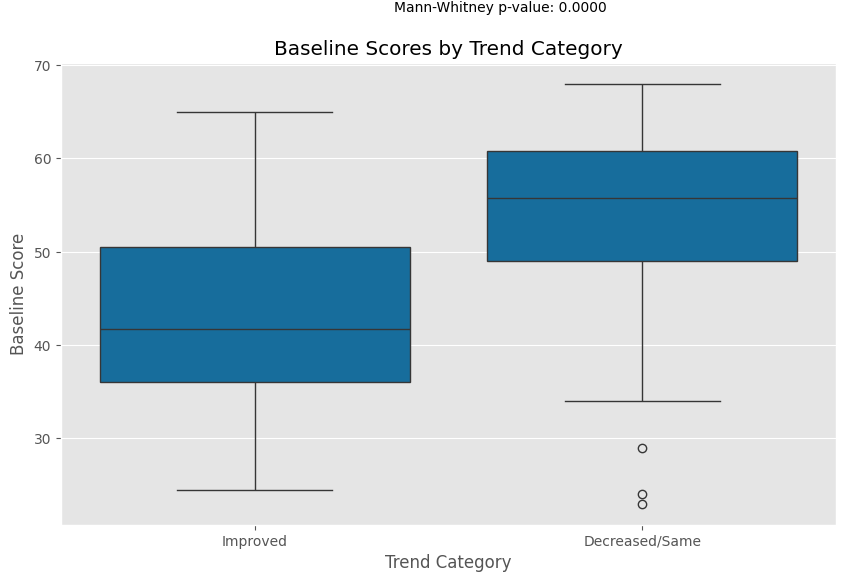

In [73]:
# Calculate odds ratio for a 10-point increase in baseline score
baseline_coef = result.params["ecs_subscale_score_baseline"]
odds_ratio_10points = np.exp(baseline_coef * 10)
print(f"\nOdds Ratio for a 10-point increase in baseline score: {odds_ratio_10points:.3f}")

# Calculate confidence interval for the odds ratio
baseline_conf_int = result.conf_int().loc["ecs_subscale_score_baseline"]
lower_ci_10points = np.exp(baseline_conf_int[0] * 10)
upper_ci_10points = np.exp(baseline_conf_int[1] * 10)
print(f"95% CI for a 10-point increase in baseline score: ({lower_ci_10points:.3f}, {upper_ci_10points:.3f})")

# Visualize with boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x="Trend Category", y="ecs_subscale_score_baseline", data=merged_df_removedNA_ecs)
plt.title("Baseline Scores by Trend Category")
plt.xlabel("Trend Category")
plt.ylabel("Baseline Score")
plt.annotate(f"Mann-Whitney p-value: {p_value:.4f}", xy=(0.5, 0.95), 
             xycoords='figure fraction', ha='center')
plt.show()

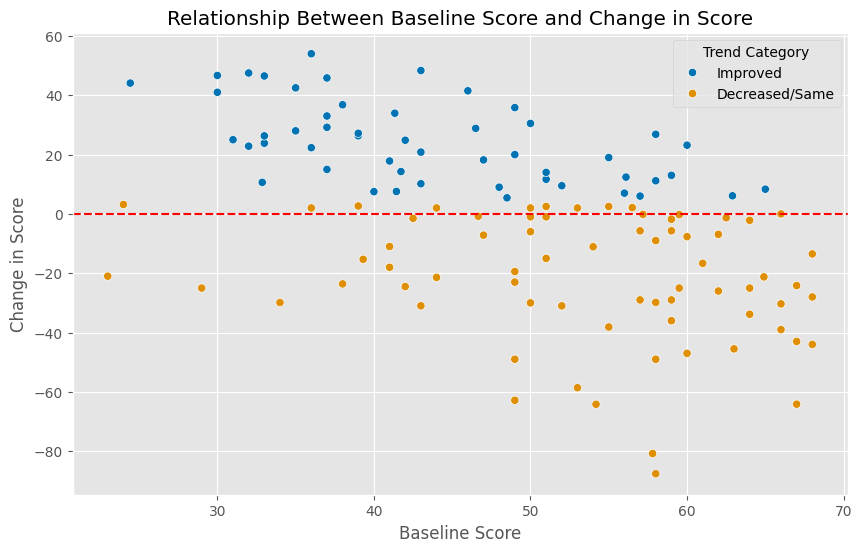

In [74]:
# Create a scatter plot of Baseline vs Change
plt.figure(figsize=(10, 6))
sns.scatterplot(x="ecs_subscale_score_baseline", y="Change", 
                hue="Trend Category", 
                data=merged_df_removedNA_ecs)
plt.title("Relationship Between Baseline Score and Change in Score")
plt.xlabel("Baseline Score")
plt.ylabel("Change in Score")
plt.axhline(y=0, color='r', linestyle='--')  # Add a horizontal line at y=0
plt.legend(title="Trend Category")
plt.show()

# sensitivity analysis 0f) ECS baseline 

Sensitivity Analysis Results:
    threshold  improvement_rate  mean_ecs_improved  mean_ecs_not_improved  \
0           0          0.504132          44.152496              54.450960   
1           1          0.495868          43.788371              54.640288   
2           2          0.495868          43.788371              54.640288   
3           3          0.429752          43.130813              53.877646   
4           4          0.421488          43.505927              53.450823   
5           5          0.421488          43.505927              53.450823   
6           6          0.413223          43.406045              53.381093   
7           7          0.396694          42.716714              53.561063   
8           8          0.371901          42.510328              53.255198   
9           9          0.363636          41.999199              53.407728   
10         10          0.347107          41.618209              53.321457   

    mann_whitney_p  logistic_p  odds_ratio  


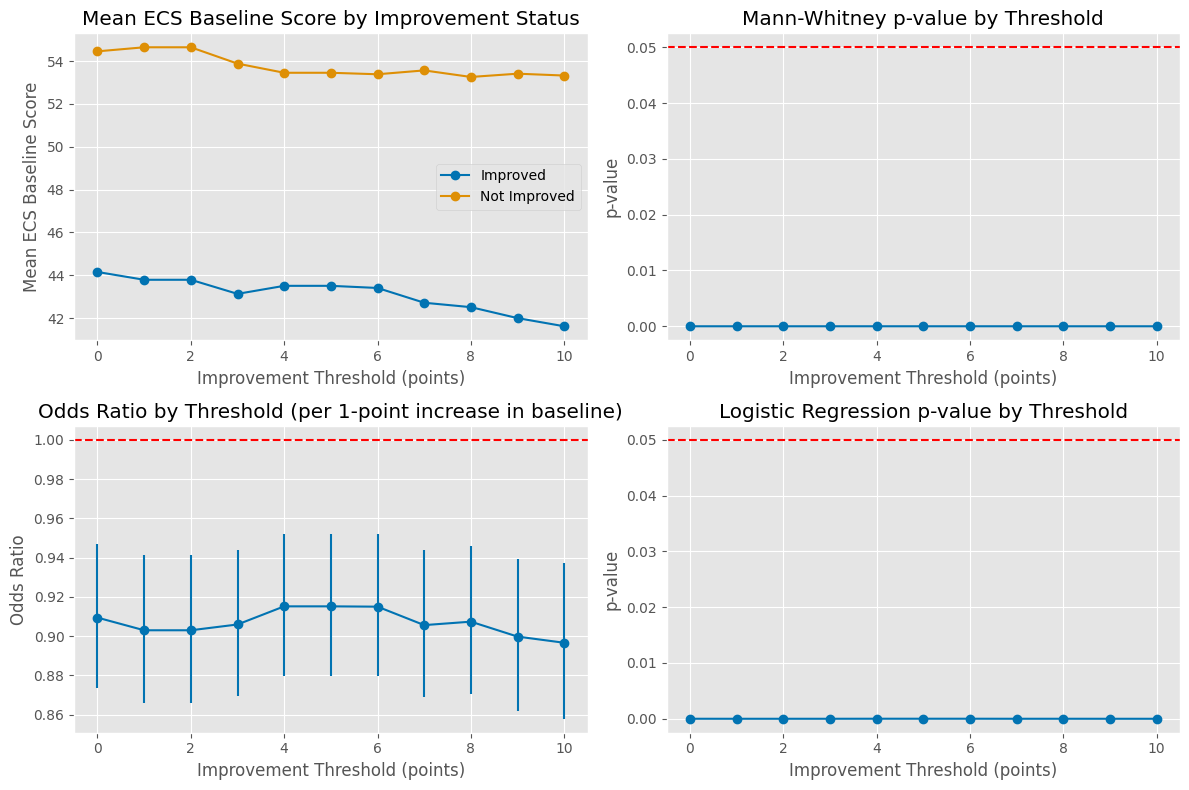


Patient Counts at Different Thresholds:
    Threshold  Improved Count  Decreased/Same Count  Improved %  \
0           0              61                    60   50.413223   
1           1              60                    61   49.586777   
2           2              60                    61   49.586777   
3           3              52                    69   42.975207   
4           4              51                    70   42.148760   
5           5              51                    70   42.148760   
6           6              50                    71   41.322314   
7           7              48                    73   39.669421   
8           8              45                    76   37.190083   
9           9              44                    77   36.363636   
10         10              42                    79   34.710744   

    Decreased/Same %  
0          49.586777  
1          50.413223  
2          50.413223  
3          57.024793  
4          57.851240  
5          57.85

In [75]:
def analyze_improvement_threshold(data, threshold):
    """
    Analyze how the improvement threshold affects classification and baseline score relationship
    
    Parameters:
    data: DataFrame containing Baseline and Change scores
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the new threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    df["Trend Category_binary"] = df["Improved"].astype(int)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count
    
    # Mann-Whitney U test
    improved_baseline = df[df["Improved"]]["ecs_subscale_score_baseline"]
    decreased_same_baseline = df[~df["Improved"]]["ecs_subscale_score_baseline"]
    
    if len(improved_baseline) > 0 and len(decreased_same_baseline) > 0:
        stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
    else:
        stat, p_value = None, None
        
    # Mean ecs_subscale_score_baseline in each group
    mean_ecs_improved = improved_baseline.mean() if len(improved_baseline) > 0 else None
    mean_ecs_not_improved = decreased_same_baseline.mean() if len(decreased_same_baseline) > 0 else None
    
    # Logistic regression
    X = sm.add_constant(df["ecs_subscale_score_baseline"])
    y = df["Trend Category_binary"]
    
    try:
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        baseline_coef = result.params["ecs_subscale_score_baseline"]
        baseline_p = result.pvalues["ecs_subscale_score_baseline"]
        odds_ratio = np.exp(baseline_coef)
        
        # Confidence intervals
        baseline_conf_int = result.conf_int().loc["ecs_subscale_score_baseline"]
        lower_ci = np.exp(baseline_conf_int[0])
        upper_ci = np.exp(baseline_conf_int[1])
    except:
        baseline_coef = None
        baseline_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "mean_ecs_improved": mean_ecs_improved,
        "mean_ecs_not_improved": mean_ecs_not_improved,
        "mann_whitney_stat": stat,
        "mann_whitney_p": p_value,
        "logistic_coef": baseline_coef,
        "logistic_p": baseline_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Prepare clean dataset
merged_df_clean = merged_df_ecs.dropna(subset=["ecs_subscale_score_baseline", "Change"]).drop_duplicates()

for threshold in thresholds:
    result = analyze_improvement_threshold(merged_df_clean, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis Results:")
print(sensitivity_df[["threshold", "improvement_rate", "mean_ecs_improved", "mean_ecs_not_improved", "mann_whitney_p", "logistic_p", "odds_ratio"]])

# Plot how improvement rate changes with threshold
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_ecs_improved"], 'o-', label='Improved')
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_ecs_not_improved"], 'o-', label='Not Improved')
plt.title("Mean ECS Baseline Score by Improvement Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Mean ECS Baseline Score")
plt.legend()
plt.grid(True)

# Plot p-values from Mann-Whitney test
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mann_whitney_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Mann-Whitney p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot odds ratios from logistic regression
plt.subplot(2, 2, 3)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio by Threshold (per 1-point increase in baseline)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

# Plot p-values from logistic regression
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["logistic_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Create a table showing the number and percentage of patients in each category at different thresholds
category_counts = []

for threshold in thresholds:
    df_temp = merged_df_clean.copy()
    df_temp["Improved"] = df_temp["Change"] >= threshold
    improved_count = df_temp["Improved"].sum()
    total = len(df_temp)
    
    category_counts.append({
        "Threshold": threshold,
        "Improved Count": improved_count,
        "Decreased/Same Count": total - improved_count,
        "Improved %": (improved_count / total) * 100,
        "Decreased/Same %": ((total - improved_count) / total) * 100
    })

category_df = pd.DataFrame(category_counts)
print("\nPatient Counts at Different Thresholds:")
print(category_df)

# statistically significantly associated with 1) BMI 

In [76]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [77]:
merged_df_bmi = score_comparison.merge(filtered_df[["id", "bmi"]], on="id", how="left")

# Calculate median BMI from all non-missing values
median_bmi = merged_df_bmi['bmi'].median()

# Find patient IDs where all BMI values are missing
patients_all_missing = merged_df_bmi.groupby('id')['bmi'].apply(lambda x: x.isna().all())
patients_to_impute = patients_all_missing[patients_all_missing].index

# Impute BMI for those patients
mask = merged_df_bmi['id'].isin(patients_to_impute)
merged_df_bmi.loc[mask, 'bmi'] = median_bmi
print(f"Imputed {len(patients_to_impute)} missing patients with median BMI: {median_bmi:.2f}")

# Replace BMI outliers with NA (outside range 7-186)
outlier_mask = (merged_df_bmi['bmi'] < 7) | (merged_df_bmi['bmi'] > 186)
outlier_count = outlier_mask.sum()
merged_df_bmi.loc[outlier_mask, 'bmi'] = median_bmi

print(f"Replaced {outlier_count} outlier BMI values with median BMI: {median_bmi:.2f}")

# Create a clean dataframe with no missing values in bmi
merged_df_removedNA_bmi = merged_df_bmi.dropna(subset=["bmi"])
merged_df_expanded_bmi = merged_df_removedNA_bmi.drop_duplicates()
merged_df_removedNA_bmi = merged_df_expanded_bmi.copy()
merged_df_removedNA_bmi


Imputed 7 missing patients with median BMI: 25.86
Replaced 3 outlier BMI values with median BMI: 25.86


,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,bmi
4,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,46.075514
11,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,25.360019
19,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,34.213824
28,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,27.115631
40,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,32.922429
...,...,...,...,...,...,...,...,...
1301,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,27.297959
1305,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,33.217993
1313,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,39.100346
1327,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,39.446367


In [78]:
# Show summary statistics by improvement group
print("\nBaseline scores by Trend Category:")
print(merged_df_removedNA_bmi.groupby("Trend Category")["bmi"].describe())



Baseline scores by Trend Category:
                count      mean       std       min        25%        50%  \
Trend Category                                                              
Decreased/Same   70.0  26.70038  6.468396  10.01001  23.092976  25.856286   
Improved         51.0  26.21552  4.823352  17.17532  23.803491  25.856286   

                     75%        max  
Trend Category                       
Decreased/Same  30.34178  45.923460  
Improved        27.75702  46.075514  


In [79]:
# Perform Mann-Whitney U test to compare Baseline scores between groups
improved_baseline = merged_df_removedNA_bmi[merged_df_removedNA_bmi["Trend Category"] == "Improved"]["bmi"]
decreased_same_baseline = merged_df_removedNA_bmi[merged_df_removedNA_bmi["Trend Category"] == "Decreased/Same"]["bmi"]

stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
print(f"\nMann-Whitney U test:")
print(f"Statistic: {stat}")
print(f"p-value: {p_value}")


Mann-Whitney U test:
Statistic: 1730.0
p-value: 0.7747416925606271


In [80]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_bmi["Trend Category_binary"] = merged_df_removedNA_bmi["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Logistic regression with Baseline as predictor
X = sm.add_constant(merged_df_removedNA_bmi["bmi"])
y = merged_df_removedNA_bmi["Trend Category_binary"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print("\nLogistic Regression Results:")
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.679909
         Iterations 4

Logistic Regression Results:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  121
Model:                             Logit   Df Residuals:                      119
Method:                              MLE   Df Model:                            1
Date:                   Wed, 25 Jun 2025   Pseudo R-squ.:                0.001261
Time:                           11:41:39   Log-Likelihood:                -82.269
converged:                          True   LL-Null:                       -82.373
Covariance Type:               nonrobust   LLR p-value:                    0.6486
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0685      0.866      0.079      0.937


Odds Ratio for a 10-point increase in baseline score: 0.865
95% CI for a 10-point increase in baseline score: (0.461, 1.620)


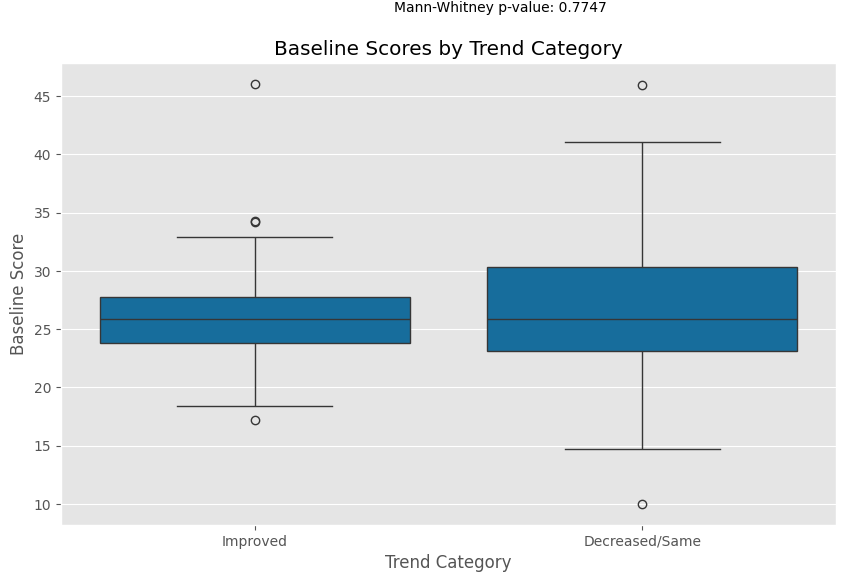

In [81]:
# Calculate odds ratio for a 10-point increase in baseline score
baseline_coef = result.params["bmi"]
odds_ratio_10points = np.exp(baseline_coef * 10)
print(f"\nOdds Ratio for a 10-point increase in baseline score: {odds_ratio_10points:.3f}")

# Calculate confidence interval for the odds ratio
baseline_conf_int = result.conf_int().loc["bmi"]
lower_ci_10points = np.exp(baseline_conf_int[0] * 10)
upper_ci_10points = np.exp(baseline_conf_int[1] * 10)
print(f"95% CI for a 10-point increase in baseline score: ({lower_ci_10points:.3f}, {upper_ci_10points:.3f})")

# Visualize with boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x="Trend Category", y="bmi", data=merged_df_removedNA_bmi)
plt.title("Baseline Scores by Trend Category")
plt.xlabel("Trend Category")
plt.ylabel("Baseline Score")
plt.annotate(f"Mann-Whitney p-value: {p_value:.4f}", xy=(0.5, 0.95), 
                xycoords='figure fraction', ha='center')
plt.show()

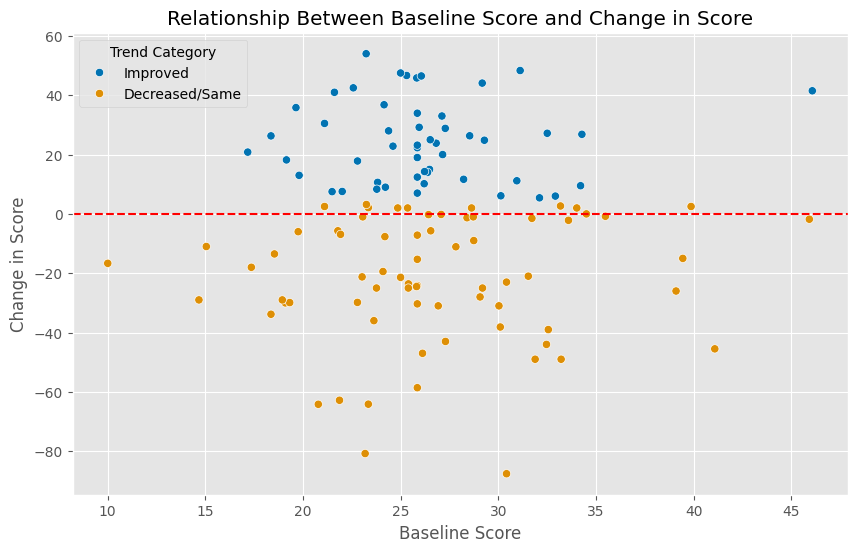

In [82]:
# Create a scatter plot of Baseline vs Change
plt.figure(figsize=(10, 6))
sns.scatterplot(x="bmi", y="Change", 
                hue="Trend Category", 
                data=merged_df_removedNA_bmi)
plt.title("Relationship Between Baseline Score and Change in Score")
plt.xlabel("Baseline Score")
plt.ylabel("Change in Score")
plt.axhline(y=0, color='r', linestyle='--')  # Add a horizontal line at y=0
plt.legend(title="Trend Category")
plt.show()

# sensitivity analysis 1) BMI

Sensitivity Analysis Results:
    threshold  improvement_rate  mean_bmi_improved  mean_bmi_not_improved  \
0           0          0.504132          26.641450              26.348161   
1           1          0.495868          26.510282              26.481987   
2           2          0.495868          26.510282              26.481987   
3           3          0.429752          26.158472              26.750400   
4           4          0.421488          26.215520              26.700380   
5           5          0.421488          26.215520              26.700380   
6           6          0.413223          26.097593              26.776598   
7           7          0.396694          25.871339              26.906766   
8           8          0.371901          26.054724              26.757310   
9           9          0.363636          26.106376              26.718670   
10         10          0.347107          25.958212              26.781940   

    mann_whitney_p  logistic_p  odds_ratio  


<Figure size 1000x600 with 0 Axes>

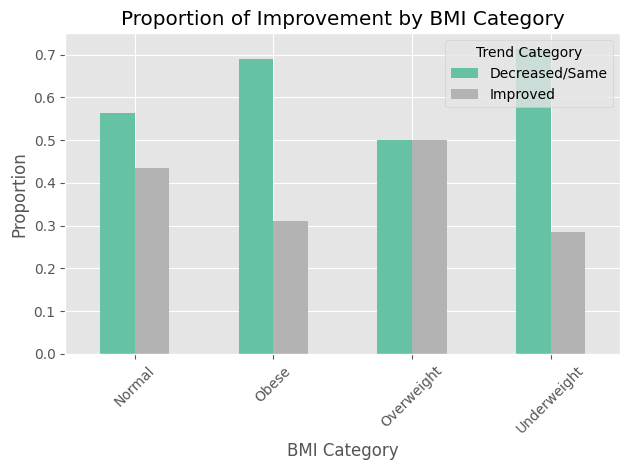

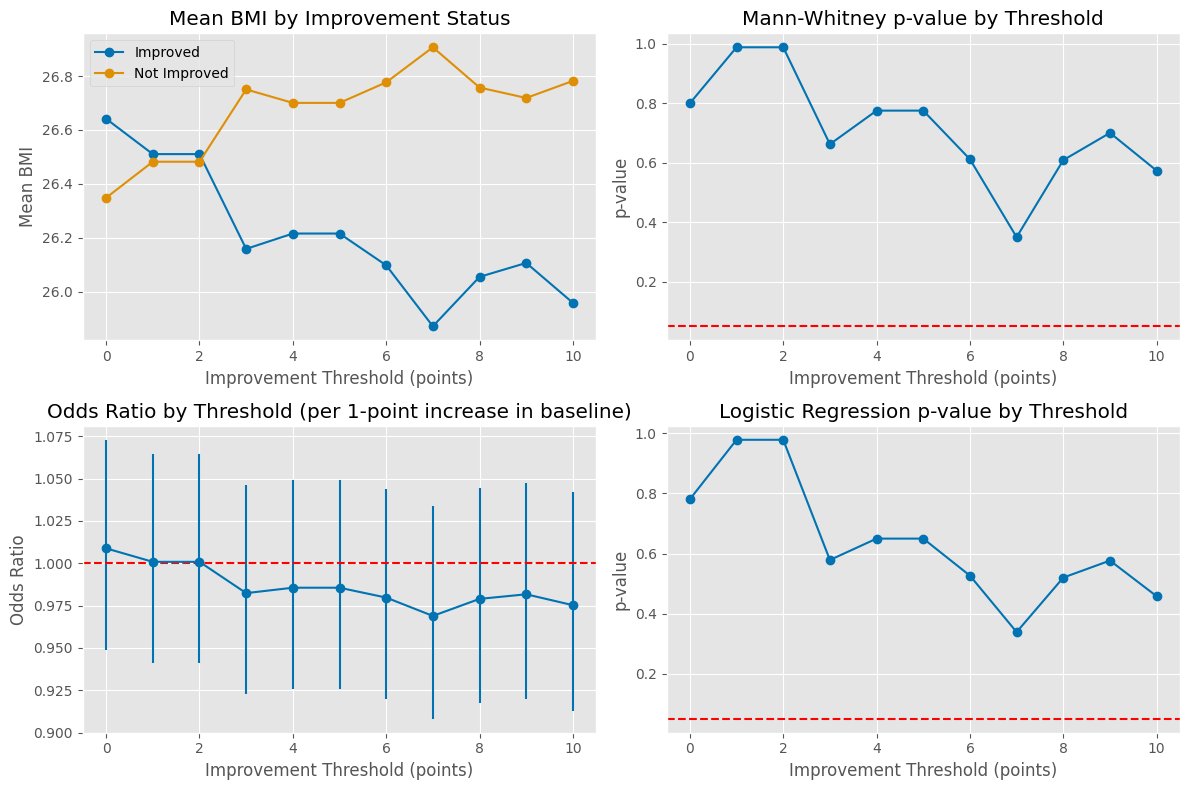


Patient Counts at Different Thresholds:
    Threshold  Improved Count  Decreased/Same Count  Improved %  \
0           0              61                    60   50.413223   
1           1              60                    61   49.586777   
2           2              60                    61   49.586777   
3           3              52                    69   42.975207   
4           4              51                    70   42.148760   
5           5              51                    70   42.148760   
6           6              50                    71   41.322314   
7           7              48                    73   39.669421   
8           8              45                    76   37.190083   
9           9              44                    77   36.363636   
10         10              42                    79   34.710744   

    Decreased/Same %  
0          49.586777  
1          50.413223  
2          50.413223  
3          57.024793  
4          57.851240  
5          57.85

In [83]:
def analyze_improvement_threshold(data, threshold):
    """
    Analyze how the improvement threshold affects classification and baseline score relationship
    
    Parameters:
    data: DataFrame containing Baseline and Change scores
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the new threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    df["Trend Category_binary"] = df["Improved"].astype(int)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count
    
    # Mann-Whitney U test
    improved_baseline = df[df["Improved"]]["bmi"]
    decreased_same_baseline = df[~df["Improved"]]["bmi"]
    
    if len(improved_baseline) > 0 and len(decreased_same_baseline) > 0:
        stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
    else:
        stat, p_value = None, None
        
    # Mean bmi in each group
    mean_bmi_improved = improved_baseline.mean() if len(improved_baseline) > 0 else None
    mean_bmi_not_improved = decreased_same_baseline.mean() if len(decreased_same_baseline) > 0 else None
    
    # Logistic regression
    X = sm.add_constant(df["bmi"])
    y = df["Trend Category_binary"]
    
    try:
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        baseline_coef = result.params["bmi"]
        baseline_p = result.pvalues["bmi"]
        odds_ratio = np.exp(baseline_coef)
        
        # Confidence intervals
        baseline_conf_int = result.conf_int().loc["bmi"]
        lower_ci = np.exp(baseline_conf_int[0])
        upper_ci = np.exp(baseline_conf_int[1])
    except:
        baseline_coef = None
        baseline_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "mean_bmi_improved": mean_bmi_improved,
        "mean_bmi_not_improved": mean_bmi_not_improved,
        "mann_whitney_stat": stat,
        "mann_whitney_p": p_value,
        "logistic_coef": baseline_coef,
        "logistic_p": baseline_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Prepare clean dataset
merged_df_clean = merged_df_bmi.dropna(subset=["bmi", "Change"]).drop_duplicates()

for threshold in thresholds:
    result = analyze_improvement_threshold(merged_df_clean, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis Results:")
print(sensitivity_df[["threshold", "improvement_rate", "mean_bmi_improved", "mean_bmi_not_improved", "mann_whitney_p", "logistic_p", "odds_ratio"]])

print("\n### Analysis with BMI categories ###")
# Define clinical BMI categories
def categorize_bmi(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

# Add BMI category column
merged_df_clean["bmi_category"] = merged_df_clean["bmi"].apply(categorize_bmi)

# Create contingency table
contingency_table_bmi = pd.crosstab(merged_df_clean["Trend Category"],
                                    merged_df_clean["bmi_category"])
print("Contingency Table:")
print(contingency_table_bmi)

# Chi-square test
chi2_stat, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_table_bmi)
print(f"Chi-Square Test p-value: {p_value_chi2}")

# Visualize the relationship between BMI categories and Trend Category
plt.figure(figsize=(10, 6))
proportions = pd.crosstab(merged_df_clean["bmi_category"],
                         merged_df_clean["Trend Category"],
                         normalize="index")
proportions.plot(kind="bar", stacked=False, colormap="Set2")
plt.title("Proportion of Improvement by BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("Proportion")
plt.legend(title="Trend Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot how improvement rate changes with threshold
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_bmi_improved"], 'o-', label='Improved')
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_bmi_not_improved"], 'o-', label='Not Improved')
plt.title("Mean BMI by Improvement Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Mean BMI")
plt.legend()
plt.grid(True)

# Plot p-values from Mann-Whitney test
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mann_whitney_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Mann-Whitney p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot odds ratios from logistic regression
plt.subplot(2, 2, 3)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio by Threshold (per 1-point increase in baseline)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

# Plot p-values from logistic regression
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["logistic_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Create a table showing the number and percentage of patients in each category at different thresholds
category_counts = []

for threshold in thresholds:
    df_temp = merged_df_clean.copy()
    df_temp["Improved"] = df_temp["Change"] >= threshold
    improved_count = df_temp["Improved"].sum()
    total = len(df_temp)
    
    category_counts.append({
        "Threshold": threshold,
        "Improved Count": improved_count,
        "Decreased/Same Count": total - improved_count,
        "Improved %": (improved_count / total) * 100,
        "Decreased/Same %": ((total - improved_count) / total) * 100
    })

category_df = pd.DataFrame(category_counts)
print("\nPatient Counts at Different Thresholds:")
print(category_df)

# statistically significantly associated with 2) smoking

In [84]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [85]:
merged_df_smoking = score_comparison.merge(filtered_df[["id", "smoking"]], on="id", how="left")

print(merged_df_smoking['smoking'].value_counts())

# Find patient IDs where all smoking values are missing
patients_all_missing = merged_df_smoking.groupby('id')['smoking'].apply(lambda x: x.isna().all())
patients_to_impute = patients_all_missing[patients_all_missing].index

# Impute smoking for those patients
mask = merged_df_smoking['id'].isin(patients_to_impute)
merged_df_smoking.loc[mask, 'smoking'] = 9999.0

print(f"Imputed {len(patients_to_impute)} missing data patients with mode smoking: 9999.0 (unknown)")

# Create a clean dataframe with no missing values in smoking
merged_df_removedNA_smoking = merged_df_smoking.dropna(subset=["smoking"])
merged_df_expanded_smoking = merged_df_removedNA_smoking.drop_duplicates()
merged_df_removedNA_smoking = merged_df_expanded_smoking.copy()
merged_df_removedNA_smoking


print(merged_df_removedNA_smoking['smoking'].value_counts())

smoking
3.0       36
0.0       32
1.0       17
9999.0     6
Name: count, dtype: int64
Imputed 30 missing data patients with mode smoking: 9999.0 (unknown)
smoking
3.0       36
9999.0    36
0.0       32
1.0       17
Name: count, dtype: int64


In [86]:
# Show summary statistics by improvement group
print("\nBaseline scores by Trend Category:")
print(merged_df_removedNA_smoking.groupby("Trend Category")["smoking"].describe())


Baseline scores by Trend Category:
                count         mean          std  min  25%  50%     75%     max
Trend Category                                                                
Decreased/Same   70.0  2715.042857  4477.994781  0.0  0.0  3.0  9999.0  9999.0
Improved         51.0  3334.039216  4759.734181  0.0  0.5  3.0  9999.0  9999.0


In [87]:
# Create smoking status labels
smoking_labels = {0: "Never smoked", 1: "Current smoker", 3: "Past smoker", 9999: "Unknown"}
merged_df_removedNA_smoking["smoking_status"] = merged_df_removedNA_smoking["smoking"].map(smoking_labels)

# Show summary statistics by improvement group and smoking status
print("\nCrosstab of Smoking Status and Trend Category:")
contingency_table = pd.crosstab(merged_df_removedNA_smoking["smoking_status"], 
                                merged_df_removedNA_smoking["Trend Category"])
print(contingency_table)


Crosstab of Smoking Status and Trend Category:
Trend Category  Decreased/Same  Improved
smoking_status                          
Current smoker              12         5
Never smoked                19        13
Past smoker                 20        16
Unknown                     19        17


In [88]:
# Chi-square test
chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nChi-square test:")
print(f"Chi-square statistic: {chi2}")
print(f"p-value: {p_value_chi2}")
print(f"Degrees of freedom: {dof}")


Chi-square test:
Chi-square statistic: 1.6193657773566947
p-value: 0.6550067750116115
Degrees of freedom: 3


In [89]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_smoking["Trend Category_binary"] = merged_df_removedNA_smoking["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Clean data for logistic regression
clean_data = merged_df_removedNA_smoking.dropna(subset=["smoking", "Trend Category_binary"])

# Logistic regression with one-hot encoding for categorical smoking variable
smoking_dummies = pd.get_dummies(clean_data["smoking"], prefix="smoking", drop_first=True).astype(int)
X = sm.add_constant(smoking_dummies)
y = clean_data["Trend Category_binary"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print("\nLogistic Regression Results:")
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.673899
         Iterations 5

Logistic Regression Results:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  121
Model:                             Logit   Df Residuals:                      117
Method:                              MLE   Df Model:                            3
Date:                   Wed, 25 Jun 2025   Pseudo R-squ.:                 0.01009
Time:                           11:41:41   Log-Likelihood:                -81.542
converged:                          True   LL-Null:                       -82.373
Covariance Type:               nonrobust   LLR p-value:                    0.6454
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.3795      0.360     -1.05


Odds Ratio for smoking_1.0: 0.609
95% CI for smoking_1.0: (0.173, 2.146)


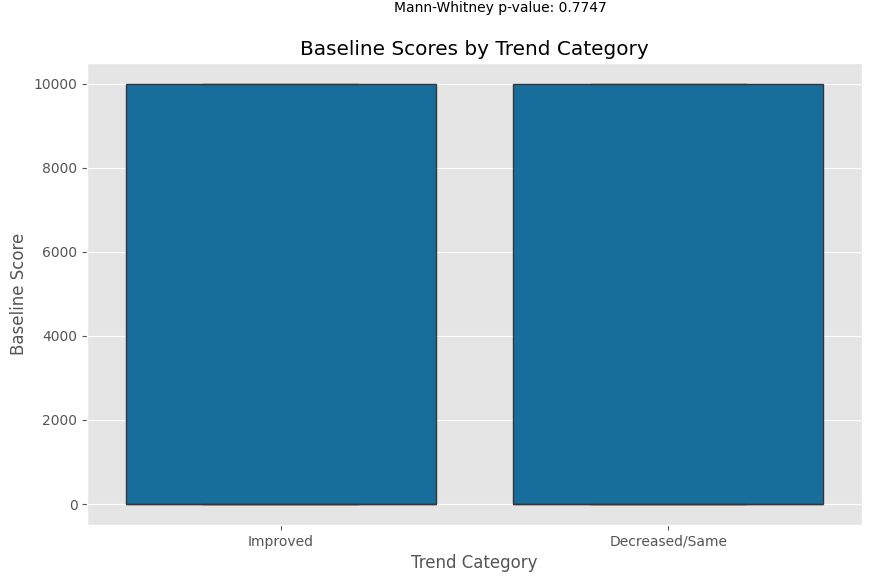

In [90]:
# Calculate odds ratio for smoking categories
smoking_cols = [col for col in result.params.index if col.startswith('smoking')]
if smoking_cols:
    first_smoking_col = smoking_cols[0]
    baseline_coef = result.params[first_smoking_col]
    odds_ratio_smoking = np.exp(baseline_coef)
    print(f"\nOdds Ratio for {first_smoking_col}: {odds_ratio_smoking:.3f}")
    
    # Calculate confidence interval for the odds ratio
    baseline_conf_int = result.conf_int().loc[first_smoking_col]
    lower_ci_smoking = np.exp(baseline_conf_int[0])
    upper_ci_smoking = np.exp(baseline_conf_int[1])
    print(f"95% CI for {first_smoking_col}: ({lower_ci_smoking:.3f}, {upper_ci_smoking:.3f})")

# Visualize with boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x="Trend Category", y="smoking", data=merged_df_removedNA_smoking)
plt.title("Baseline Scores by Trend Category")
plt.xlabel("Trend Category")
plt.ylabel("Baseline Score")
plt.annotate(f"Mann-Whitney p-value: {p_value:.4f}", xy=(0.5, 0.95), 
             xycoords='figure fraction', ha='center')
plt.show()

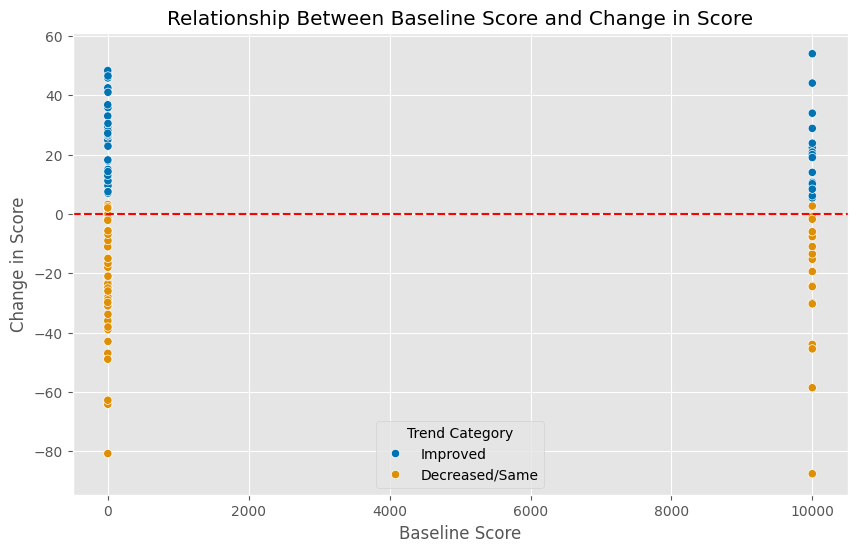

In [91]:
# Create a scatter plot of Baseline vs Change
plt.figure(figsize=(10, 6))
sns.scatterplot(x="smoking", y="Change", 
                hue="Trend Category", 
                data=merged_df_removedNA_smoking)
plt.title("Relationship Between Baseline Score and Change in Score")
plt.xlabel("Baseline Score")
plt.ylabel("Change in Score")
plt.axhline(y=0, color='r', linestyle='--')  # Add a horizontal line at y=0
plt.legend(title="Trend Category")
plt.show()

In [92]:
# Calculate proportions for plotting
proportion_data = []
for smoking_val, label in smoking_labels.items():
    subset = merged_df_removedNA_smoking[merged_df_removedNA_smoking["smoking"] == smoking_val]
    if len(subset) > 0:
        improved_count = len(subset[subset["Trend Category"] == "Improved"])
        total_count = len(subset)
        proportion = improved_count / total_count
        proportion_data.append({
            "smoking_status": label,
            "proportion_improved": proportion,
            "total_count": total_count,
            "improved_count": improved_count
        })

proportion_df = pd.DataFrame(proportion_data)
print(f"\nProportion of improvement by smoking status:")
print(proportion_df)


Proportion of improvement by smoking status:
   smoking_status  proportion_improved  total_count  improved_count
0    Never smoked             0.406250           32              13
1  Current smoker             0.294118           17               5
2     Past smoker             0.444444           36              16
3         Unknown             0.472222           36              17


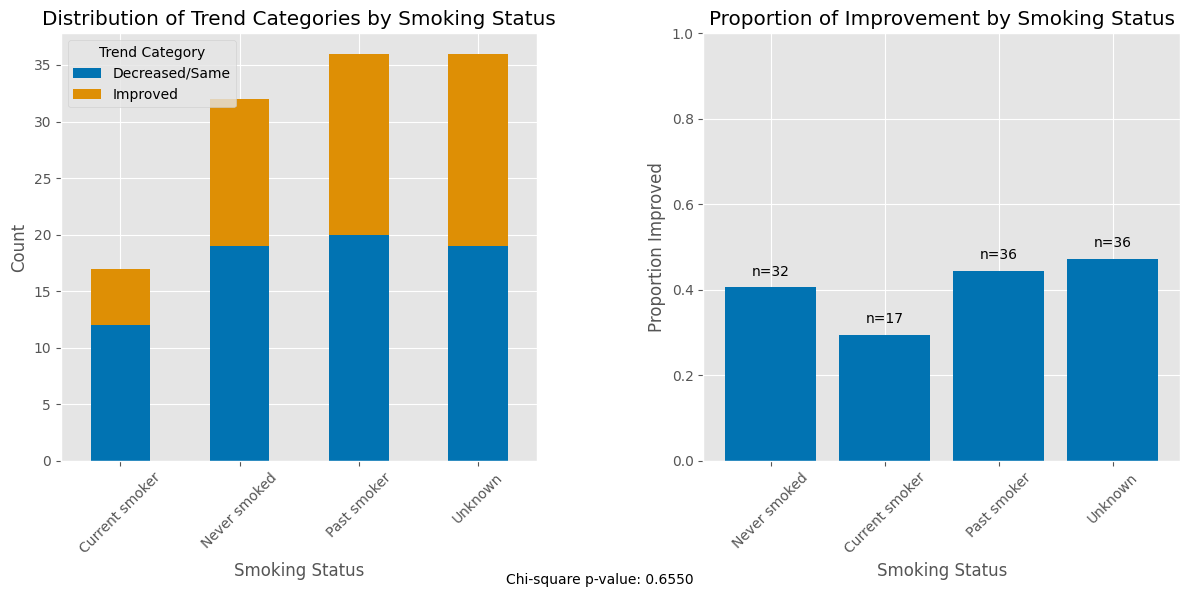

In [93]:
# Visualize with bar plot showing proportions
plt.figure(figsize=(12, 6))

# Subplot 1: Contingency table as stacked bar chart
plt.subplot(1, 2, 1)
contingency_table.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title("Distribution of Trend Categories by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Trend Category")

# Subplot 2: Proportion of improvement by smoking status
plt.subplot(1, 2, 2)
bars = plt.bar(proportion_df["smoking_status"], proportion_df["proportion_improved"])
plt.title("Proportion of Improvement by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Proportion Improved")
plt.xticks(rotation=45)
plt.ylim(0, 1)

# Add count labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'n={proportion_df.iloc[i]["total_count"]}',
                ha='center', va='bottom')

plt.annotate(f"Chi-square p-value: {p_value_chi2:.4f}", xy=(0.5, 0.02), 
                xycoords='figure fraction', ha='center')

plt.tight_layout()
plt.show()

# sensitivity analysis 2) smoking

Sensitivity Analysis Results:
    threshold  improvement_rate    chi2_p  logistic_p  odds_ratio
0           0          0.504132  0.311331    0.074020    0.327273
1           1          0.495868  0.271679    0.074020    0.327273
2           2          0.495868  0.271679    0.074020    0.327273
3           3          0.429752  0.663778    0.329864    0.535714
4           4          0.421488  0.655007    0.291735    0.608974
5           5          0.421488  0.655007    0.291735    0.608974
6           6          0.413223  0.731394    0.291735    0.608974
7           7          0.396694  0.774240    0.291735    0.608974
8           8          0.371901  0.912122    0.161827    0.694444
9           9          0.363636  0.924761    0.161827    0.694444
10         10          0.347107  0.943980    0.161827    0.694444


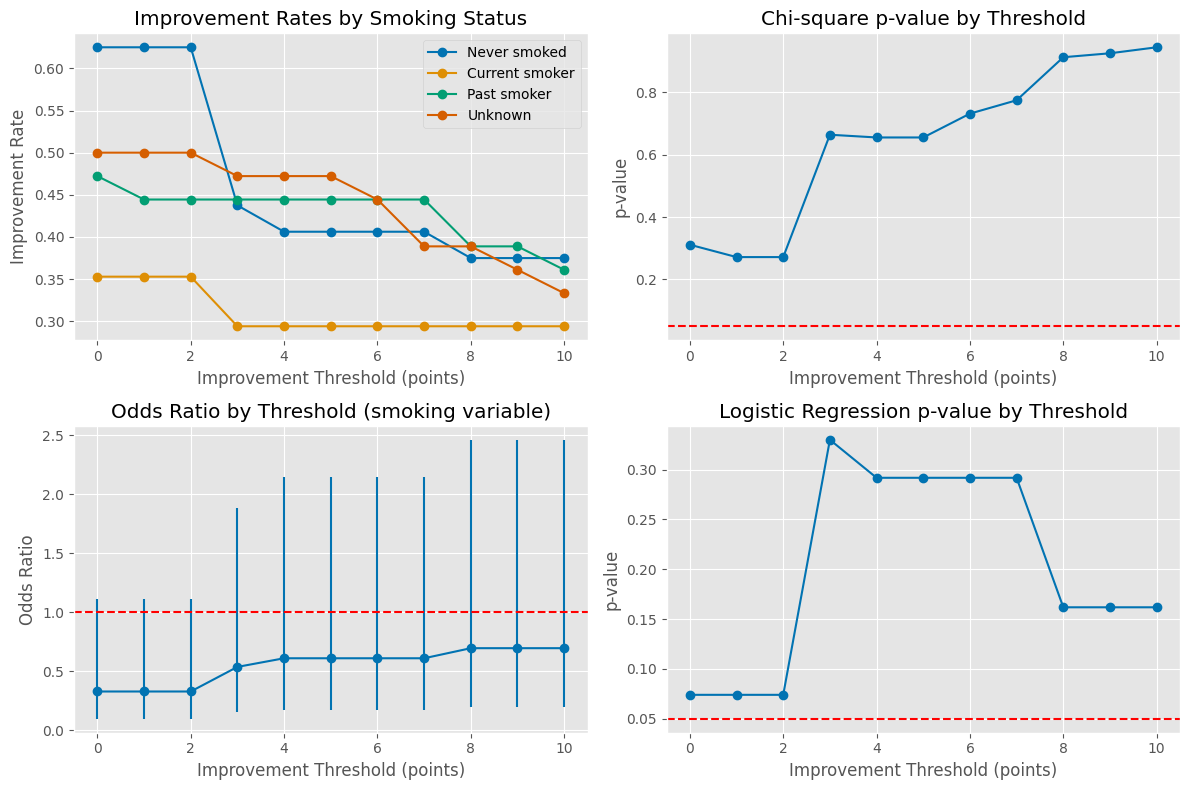


Patient Counts at Different Thresholds:
    Threshold  Improved Count  Decreased/Same Count  Improved %  \
0           0              61                    60   50.413223   
1           1              60                    61   49.586777   
2           2              60                    61   49.586777   
3           3              52                    69   42.975207   
4           4              51                    70   42.148760   
5           5              51                    70   42.148760   
6           6              50                    71   41.322314   
7           7              48                    73   39.669421   
8           8              45                    76   37.190083   
9           9              44                    77   36.363636   
10         10              42                    79   34.710744   

    Decreased/Same %  
0          49.586777  
1          50.413223  
2          50.413223  
3          57.024793  
4          57.851240  
5          57.85

In [94]:
def analyze_improvement_threshold_smoking(data, threshold):
    """
    Analyze how the improvement threshold affects classification and smoking status relationship
    
    Parameters:
    data: DataFrame containing smoking and Change scores
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the new threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    df["Trend Category_binary"] = df["Improved"].astype(int)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count
    
    # Chi-square test
    try:
        contingency = pd.crosstab(df["smoking"], df["Improved"])
        chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency)
    except:
        chi2, p_value_chi2 = None, None
    
    # Logistic regression with one-hot encoding
    try:
        smoking_dummies = pd.get_dummies(df["smoking"], prefix="smoking", drop_first=True).astype(int)
        X = sm.add_constant(smoking_dummies)
        y = df["Trend Category_binary"]
        
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        logistic_p = result.pvalues.min()  # Get minimum p-value from all smoking coefficients
        
        # Get odds ratios and confidence intervals
        odds_ratios = np.exp(result.params[1:])  # Exclude intercept
        conf_int = result.conf_int()
        odds_ratio_lower_ci = np.exp(conf_int.iloc[1:, 0])  # Lower CI for smoking variables
        odds_ratio_upper_ci = np.exp(conf_int.iloc[1:, 1])  # Upper CI for smoking variables
        
        # Take the first smoking variable's odds ratio as representative
        odds_ratio = odds_ratios.iloc[0] if len(odds_ratios) > 0 else None
        lower_ci = odds_ratio_lower_ci.iloc[0] if len(odds_ratio_lower_ci) > 0 else None
        upper_ci = odds_ratio_upper_ci.iloc[0] if len(odds_ratio_upper_ci) > 0 else None
        
    except:
        logistic_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "chi2_stat": chi2,
        "chi2_p": p_value_chi2,
        "logistic_p": logistic_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Prepare clean dataset
merged_df_clean_smoking = merged_df_smoking.dropna(subset=["smoking", "Change"]).drop_duplicates()
merged_df_clean_smoking["smoking"] = pd.to_numeric(merged_df_clean_smoking["smoking"], errors='coerce')
merged_df_clean_smoking = merged_df_clean_smoking.dropna(subset=["smoking"])

for threshold in thresholds:
    result = analyze_improvement_threshold_smoking(merged_df_clean_smoking, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis Results:")
print(sensitivity_df[["threshold", "improvement_rate", "chi2_p", "logistic_p", "odds_ratio"]])

# Plot how improvement rate changes with threshold
plt.figure(figsize=(12, 8))

# Plot improvement rates by smoking status
plt.subplot(2, 2, 1)
for smoking_val, label in smoking_labels.items():
    rates = []
    for threshold in thresholds:
        subset = merged_df_clean_smoking[merged_df_clean_smoking["smoking"] == smoking_val]
        if len(subset) > 0:
            improved = (subset["Change"] >= threshold).sum()
            rate = improved / len(subset)
            rates.append(rate)
        else:
            rates.append(0)
    plt.plot(thresholds, rates, 'o-', label=label)

plt.title("Improvement Rates by Smoking Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Improvement Rate")
plt.legend()
plt.grid(True)

# Plot p-values from Chi-square test (equivalent to Mann-Whitney for categorical)
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["chi2_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Chi-square p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot odds ratios from logistic regression
plt.subplot(2, 2, 3)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio by Threshold (smoking variable)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

# Plot p-values from logistic regression
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["logistic_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Create a table showing the number and percentage of patients in each category at different thresholds
category_counts = []

for threshold in thresholds:
    df_temp = merged_df_clean_smoking.copy()
    df_temp["Improved"] = df_temp["Change"] >= threshold
    improved_count = df_temp["Improved"].sum()
    total = len(df_temp)
    
    category_counts.append({
        "Threshold": threshold,
        "Improved Count": improved_count,
        "Decreased/Same Count": total - improved_count,
        "Improved %": (improved_count / total) * 100,
        "Decreased/Same %": ((total - improved_count) / total) * 100
    })

category_df = pd.DataFrame(category_counts)
print("\nPatient Counts at Different Thresholds:")
print(category_df)

# statistically significantly associated with 3) alcohol consumption

In [95]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [96]:
# Merge score_comparison with alcohol data
merged_df_alcohol = score_comparison.merge(filtered_df[["id", "alcohol"]], on="id", how="left")

print(merged_df_alcohol['alcohol'].value_counts())

# Find patient IDs where all alcohol values are missing
patients_all_missing = merged_df_alcohol.groupby('id')['alcohol'].apply(lambda x: x.isna().all())
patients_to_impute = patients_all_missing[patients_all_missing].index

# Impute alcohol for those patients with 9999.0 (unknown/missing indicator)
mask = merged_df_alcohol['id'].isin(patients_to_impute)
merged_df_alcohol.loc[mask, 'alcohol'] = 9999.0

print(f"Imputed {len(patients_to_impute)} missing data patients with alcohol = 9999.0 (unknown)")

# Create a clean dataframe with no missing values in alcohol
merged_df_removedNA_alcohol = merged_df_alcohol.dropna(subset=["alcohol"])
merged_df_expanded_alcohol = merged_df_removedNA_alcohol.drop_duplicates()
merged_df_removedNA_alcohol = merged_df_expanded_alcohol.copy()

print(merged_df_removedNA_alcohol['alcohol'].value_counts())
merged_df_removedNA_alcohol


alcohol
1.0       44
0.0       31
9999.0    10
2.0        6
Name: count, dtype: int64
Imputed 30 missing data patients with alcohol = 9999.0 (unknown)
alcohol
1.0       44
9999.0    40
0.0       31
2.0        6
Name: count, dtype: int64


,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,alcohol
4,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,1.0
11,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,1.0
19,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,0.0
28,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,0.0
38,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,9999.0
...,...,...,...,...,...,...,...,...
1301,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,1.0
1305,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,0.0
1313,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,2.0
1327,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,0.0


In [97]:
# Create alcohol status labels
alcohol_labels = {0: "Non drinker", 1: "Current drinker", 2: "Past drinker", 9999: "Unknown"}
merged_df_removedNA_alcohol["alcohol_status"] = merged_df_removedNA_alcohol["alcohol"].map(alcohol_labels)

# Show summary statistics by improvement group and alcohol status
print("\nCrosstab of Alcohol Status and Trend Category:")
contingency_table = pd.crosstab(merged_df_removedNA_alcohol["alcohol_status"], 
                               merged_df_removedNA_alcohol["Trend Category"])
print(contingency_table)


Crosstab of Alcohol Status and Trend Category:
Trend Category   Decreased/Same  Improved
alcohol_status                           
Current drinker              26        18
Non drinker                  19        12
Past drinker                  3         3
Unknown                      22        18


In [98]:
# Chi-square test
chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nChi-square test:")
print(f"Chi-square statistic: {chi2}")
print(f"p-value: {p_value_chi2}")
print(f"Degrees of freedom: {dof}")


Chi-square test:
Chi-square statistic: 0.46313906207644395
p-value: 0.9269116736123891
Degrees of freedom: 3


In [99]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_alcohol["Trend Category_binary"] = merged_df_removedNA_alcohol["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Clean data for logistic regression
clean_data = merged_df_removedNA_alcohol.dropna(subset=["alcohol", "Trend Category_binary"])

# Logistic regression with one-hot encoding for categorical alcohol variable
alcohol_dummies = pd.get_dummies(clean_data["alcohol"], prefix="alcohol", drop_first=True).astype(int)
X = sm.add_constant(alcohol_dummies)
y = clean_data["Trend Category_binary"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print("\nLogistic Regression Results:")
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.678859
         Iterations 4

Logistic Regression Results:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  121
Model:                             Logit   Df Residuals:                      117
Method:                              MLE   Df Model:                            3
Date:                   Wed, 25 Jun 2025   Pseudo R-squ.:                0.002803
Time:                           11:41:42   Log-Likelihood:                -82.142
converged:                          True   LL-Null:                       -82.373
Covariance Type:               nonrobust   LLR p-value:                    0.9272
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.4595      0.369     -1.24

In [100]:
# Calculate proportions for plotting
proportion_data = []
for alcohol_val, label in alcohol_labels.items():
    subset = merged_df_removedNA_alcohol[merged_df_removedNA_alcohol["alcohol"] == alcohol_val]
    if len(subset) > 0:
        improved_count = len(subset[subset["Trend Category"] == "Improved"])
        total_count = len(subset)
        proportion = improved_count / total_count
        proportion_data.append({
            "alcohol_status": label,
            "proportion_improved": proportion,
            "total_count": total_count,
            "improved_count": improved_count
        })

proportion_df = pd.DataFrame(proportion_data)
print(f"\nProportion of improvement by alcohol status:")
print(proportion_df)


Proportion of improvement by alcohol status:
    alcohol_status  proportion_improved  total_count  improved_count
0      Non drinker             0.387097           31              12
1  Current drinker             0.409091           44              18
2     Past drinker             0.500000            6               3
3          Unknown             0.450000           40              18


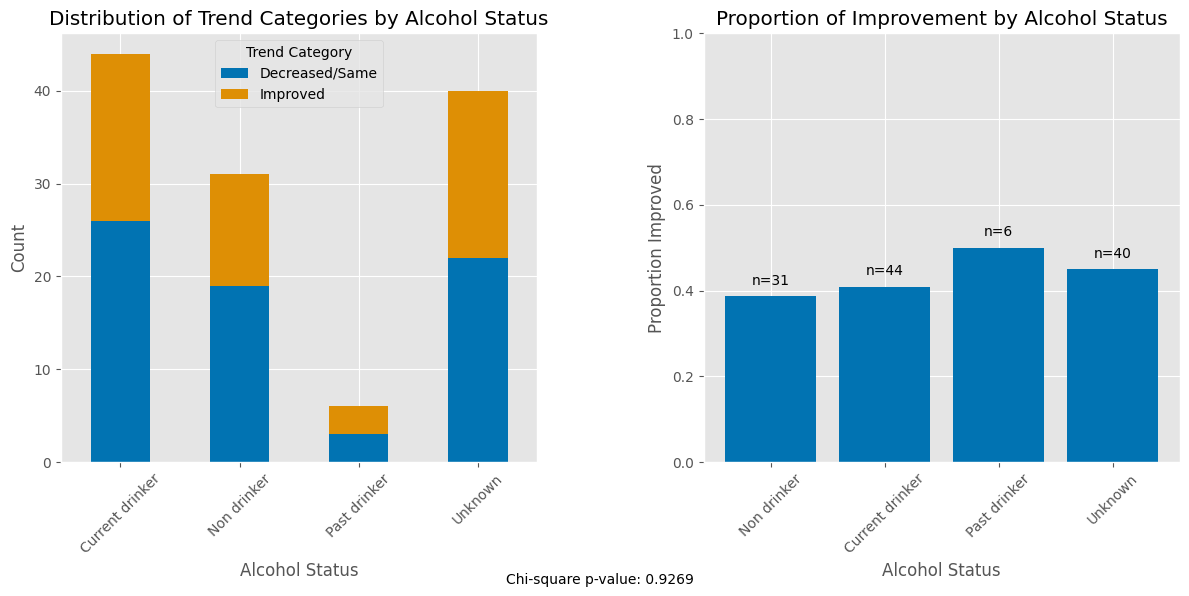

In [101]:
# Visualize with bar plot showing proportions
plt.figure(figsize=(12, 6))

# Subplot 1: Contingency table as stacked bar chart
plt.subplot(1, 2, 1)
contingency_table.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title("Distribution of Trend Categories by Alcohol Status")
plt.xlabel("Alcohol Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Trend Category")

# Subplot 2: Proportion of improvement by alcohol status
plt.subplot(1, 2, 2)
bars = plt.bar(proportion_df["alcohol_status"], proportion_df["proportion_improved"])
plt.title("Proportion of Improvement by Alcohol Status")
plt.xlabel("Alcohol Status")
plt.ylabel("Proportion Improved")
plt.xticks(rotation=45)
plt.ylim(0, 1)

# Add count labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'n={proportion_df.iloc[i]["total_count"]}',
             ha='center', va='bottom')

plt.annotate(f"Chi-square p-value: {p_value_chi2:.4f}", xy=(0.5, 0.02), 
             xycoords='figure fraction', ha='center')

plt.tight_layout()
plt.show()

# sensitivity analysis 3) alcohol consumption

Sensitivity Analysis Results:
    threshold  improvement_rate    chi2_p  logistic_p  odds_ratio
0           0          0.504132  0.655659    0.206121    1.821862
1           1          0.495868  0.762155    0.283515    1.661538
2           2          0.495868  0.762155    0.283515    1.661538
3           3          0.429752  0.936361    0.212675    1.203333
4           4          0.421488  0.926912    0.212675    1.096154
5           5          0.421488  0.926912    0.212675    1.096154
6           6          0.413223  0.960106    0.212675    1.096154
7           7          0.396694  0.943038    0.212675    1.096154
8           8          0.371901  0.852967    0.053475    1.322222
9           9          0.363636  0.840284    0.053475    1.322222
10         10          0.347107  0.694917    0.023888    1.539095


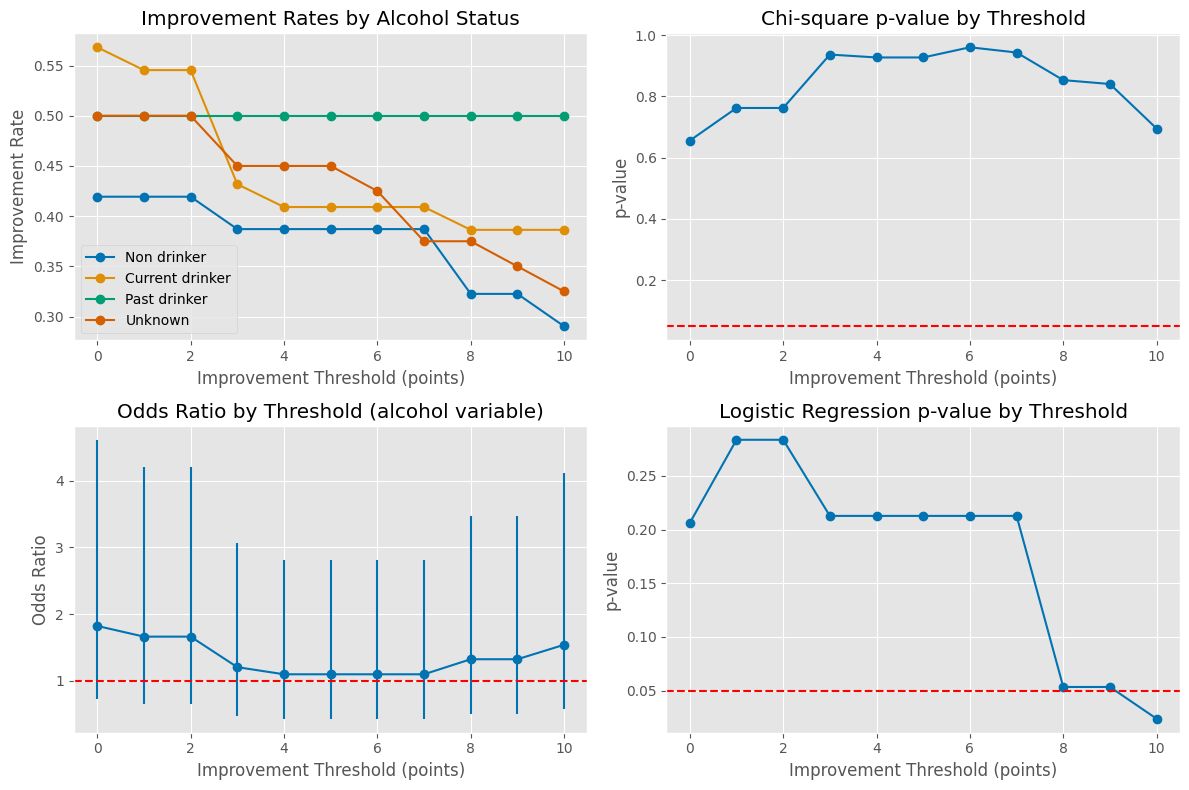


Patient Counts at Different Thresholds:
    Threshold  Improved Count  Decreased/Same Count  Improved %  \
0           0              61                    60   50.413223   
1           1              60                    61   49.586777   
2           2              60                    61   49.586777   
3           3              52                    69   42.975207   
4           4              51                    70   42.148760   
5           5              51                    70   42.148760   
6           6              50                    71   41.322314   
7           7              48                    73   39.669421   
8           8              45                    76   37.190083   
9           9              44                    77   36.363636   
10         10              42                    79   34.710744   

    Decreased/Same %  
0          49.586777  
1          50.413223  
2          50.413223  
3          57.024793  
4          57.851240  
5          57.85

In [102]:
def analyze_improvement_threshold_alcohol(data, threshold):
    """
    Analyze how the improvement threshold affects classification and alcohol status relationship
    
    Parameters:
    data: DataFrame containing alcohol and Change scores
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the new threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    df["Trend Category_binary"] = df["Improved"].astype(int)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count
    
    # Chi-square test
    try:
        contingency = pd.crosstab(df["alcohol"], df["Improved"])
        chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency)
    except:
        chi2, p_value_chi2 = None, None
    
    # Logistic regression with one-hot encoding
    try:
        alcohol_dummies = pd.get_dummies(df["alcohol"], prefix="alcohol", drop_first=True).astype(int)
        X = sm.add_constant(alcohol_dummies)
        y = df["Trend Category_binary"]
        
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        logistic_p = result.pvalues.min()  # Get minimum p-value from all alcohol coefficients
        
        # Get odds ratios and confidence intervals
        odds_ratios = np.exp(result.params[1:])  # Exclude intercept
        conf_int = result.conf_int()
        odds_ratio_lower_ci = np.exp(conf_int.iloc[1:, 0])  # Lower CI for alcohol variables
        odds_ratio_upper_ci = np.exp(conf_int.iloc[1:, 1])  # Upper CI for alcohol variables
        
        # Take the first alcohol variable's odds ratio as representative
        odds_ratio = odds_ratios.iloc[0] if len(odds_ratios) > 0 else None
        lower_ci = odds_ratio_lower_ci.iloc[0] if len(odds_ratio_lower_ci) > 0 else None
        upper_ci = odds_ratio_upper_ci.iloc[0] if len(odds_ratio_upper_ci) > 0 else None
        
    except:
        logistic_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "chi2_stat": chi2,
        "chi2_p": p_value_chi2,
        "logistic_p": logistic_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Prepare clean dataset
merged_df_clean_alcohol = merged_df_alcohol.dropna(subset=["alcohol", "Change"]).drop_duplicates()
merged_df_clean_alcohol["alcohol"] = pd.to_numeric(merged_df_clean_alcohol["alcohol"], errors='coerce')
merged_df_clean_alcohol = merged_df_clean_alcohol.dropna(subset=["alcohol"])

for threshold in thresholds:
    result = analyze_improvement_threshold_alcohol(merged_df_clean_alcohol, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis Results:")
print(sensitivity_df[["threshold", "improvement_rate", "chi2_p", "logistic_p", "odds_ratio"]])

# Plot how improvement rate changes with threshold
plt.figure(figsize=(12, 8))

# Plot improvement rates by alcohol status
plt.subplot(2, 2, 1)
for alcohol_val, label in alcohol_labels.items():
    rates = []
    for threshold in thresholds:
        subset = merged_df_clean_alcohol[merged_df_clean_alcohol["alcohol"] == alcohol_val]
        if len(subset) > 0:
            improved = (subset["Change"] >= threshold).sum()
            rate = improved / len(subset)
            rates.append(rate)
        else:
            rates.append(0)
    plt.plot(thresholds, rates, 'o-', label=label)

plt.title("Improvement Rates by Alcohol Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Improvement Rate")
plt.legend()
plt.grid(True)

# Plot p-values from Chi-square test (equivalent to Mann-Whitney for categorical)
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["chi2_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Chi-square p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot odds ratios from logistic regression
plt.subplot(2, 2, 3)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio by Threshold (alcohol variable)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

# Plot p-values from logistic regression
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["logistic_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Create a table showing the number and percentage of patients in each category at different thresholds
category_counts = []

for threshold in thresholds:
    df_temp = merged_df_clean_alcohol.copy()
    df_temp["Improved"] = df_temp["Change"] >= threshold
    improved_count = df_temp["Improved"].sum()
    total = len(df_temp)
    
    category_counts.append({
        "Threshold": threshold,
        "Improved Count": improved_count,
        "Decreased/Same Count": total - improved_count,
        "Improved %": (improved_count / total) * 100,
        "Decreased/Same %": ((total - improved_count) / total) * 100
    })

category_df = pd.DataFrame(category_counts)
print("\nPatient Counts at Different Thresholds:")
print(category_df)

# statistically significantly associated with 4) level of tumor (level_tumor)

In [103]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [104]:
# Merge score_comparison with level_tumor data
merged_df_level = score_comparison.merge(filtered_df[["id", "level_tumor"]], on="id", how="left")

print(merged_df_level['level_tumor'].value_counts())

# Find patient IDs where all level_tumor values are missing
patients_all_missing = merged_df_level.groupby('id')['level_tumor'].apply(lambda x: x.isna().all())
patients_to_impute = patients_all_missing[patients_all_missing].index

# Impute level_tumor for those patients with 9999.0 (unknown/missing indicator)
mask = merged_df_level['id'].isin(patients_to_impute)
merged_df_level.loc[mask, 'level_tumor'] = 9999.0

print(f"Imputed {len(patients_to_impute)} missing data patients with level_tumor = 9999.0 (unknown)")


# Create a clean dataframe with no missing values in level_tumor
merged_df_removedNA_level = merged_df_level.dropna(subset=["level_tumor"])
merged_df_expanded_level = merged_df_removedNA_level.drop_duplicates()
merged_df_removedNA_level = merged_df_expanded_level.copy()

print(merged_df_removedNA_level['level_tumor'].value_counts())
merged_df_removedNA_level


level_tumor
4.0    52
6.0    30
7.0    17
5.0    11
3.0    10
2.0     2
1.0     1
Name: count, dtype: int64
Imputed 1 missing data patients with level_tumor = 9999.0 (unknown)
level_tumor
4.0       52
6.0       28
7.0       17
5.0       11
3.0        9
2.0        2
9999.0     1
1.0        1
Name: count, dtype: int64


,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,level_tumor
1,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,4.0
10,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,4.0
22,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,4.0
31,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,6.0
39,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,4.0
...,...,...,...,...,...,...,...,...
1296,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,6.0
1304,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,6.0
1320,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,6.0
1323,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,4.0


In [105]:
# Create level_tumor status labels
level_tumor_labels = {1: "Cervical", 2: "Thoracic Upper 1/3", 3: "Thoracic Middle 1/3", 4: "Thoracic Lower 1/3", 5: "GEJ Siewert 1", 6: "GEJ Siewert 2", 7: "GEJ Siewert 3", 9999: "Unknown"}
merged_df_removedNA_level["level_tumor_status"] = merged_df_removedNA_level["level_tumor"].map(level_tumor_labels)

# Show summary statistics by improvement group and level_tumor status
print("\nCrosstab of Level Tumor Status and Trend Category:")
contingency_table = pd.crosstab(merged_df_removedNA_level["level_tumor_status"], 
                                merged_df_removedNA_level["Trend Category"])
print(contingency_table)


Crosstab of Level Tumor Status and Trend Category:
Trend Category       Decreased/Same  Improved
level_tumor_status                           
Cervical                          1         0
GEJ Siewert 1                     4         7
GEJ Siewert 2                    15        13
GEJ Siewert 3                    12         5
Thoracic Lower 1/3               29        23
Thoracic Middle 1/3               8         1
Thoracic Upper 1/3                0         2
Unknown                           1         0


In [106]:
# Chi-square test
chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nChi-square test:")
print(f"Chi-square statistic: {chi2}")
print(f"p-value: {p_value_chi2}")
print(f"Degrees of freedom: {dof}")


Chi-square test:
Chi-square statistic: 11.274670089252393
p-value: 0.12707869902729393
Degrees of freedom: 7


In [107]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_level["Trend Category_binary"] = merged_df_removedNA_level["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Clean data for logistic regression
clean_data = merged_df_removedNA_level.dropna(subset=["level_tumor", "Trend Category_binary"])

# Logistic regression with one-hot encoding for categorical level_tumor variable
level_tumor_dummies = pd.get_dummies(clean_data["level_tumor"], prefix="level_tumor", drop_first=True).astype(int)
X = sm.add_constant(level_tumor_dummies)
y = clean_data["Trend Category_binary"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print("\nLogistic Regression Results:")
print(result.summary())


         Current function value: 0.625469
         Iterations: 35

Logistic Regression Results:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  121
Model:                             Logit   Df Residuals:                      113
Method:                              MLE   Df Model:                            7
Date:                   Wed, 25 Jun 2025   Pseudo R-squ.:                 0.08123
Time:                           11:41:43   Log-Likelihood:                -75.682
converged:                         False   LL-Null:                       -82.373
Covariance Type:               nonrobust   LLR p-value:                   0.06332
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                -19.7601   1.95e+04     -0.001      0.999   -3.83e+04

/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [108]:
# Calculate proportions for plotting
proportion_data = []
for level_tumor_val, label in level_tumor_labels.items():
    subset = merged_df_removedNA_level[merged_df_removedNA_level["level_tumor"] == level_tumor_val]
    if len(subset) > 0:
        improved_count = len(subset[subset["Trend Category"] == "Improved"])
        total_count = len(subset)
        proportion = improved_count / total_count
        proportion_data.append({
            "level_tumor_status": label,
            "proportion_improved": proportion,
            "total_count": total_count,
            "improved_count": improved_count
        })

proportion_df = pd.DataFrame(proportion_data)
print(f"\nProportion of improvement by level_tumor status:")
print(proportion_df)


Proportion of improvement by level_tumor status:
    level_tumor_status  proportion_improved  total_count  improved_count
0             Cervical             0.000000            1               0
1   Thoracic Upper 1/3             1.000000            2               2
2  Thoracic Middle 1/3             0.111111            9               1
3   Thoracic Lower 1/3             0.442308           52              23
4        GEJ Siewert 1             0.636364           11               7
5        GEJ Siewert 2             0.464286           28              13
6        GEJ Siewert 3             0.294118           17               5
7              Unknown             0.000000            1               0


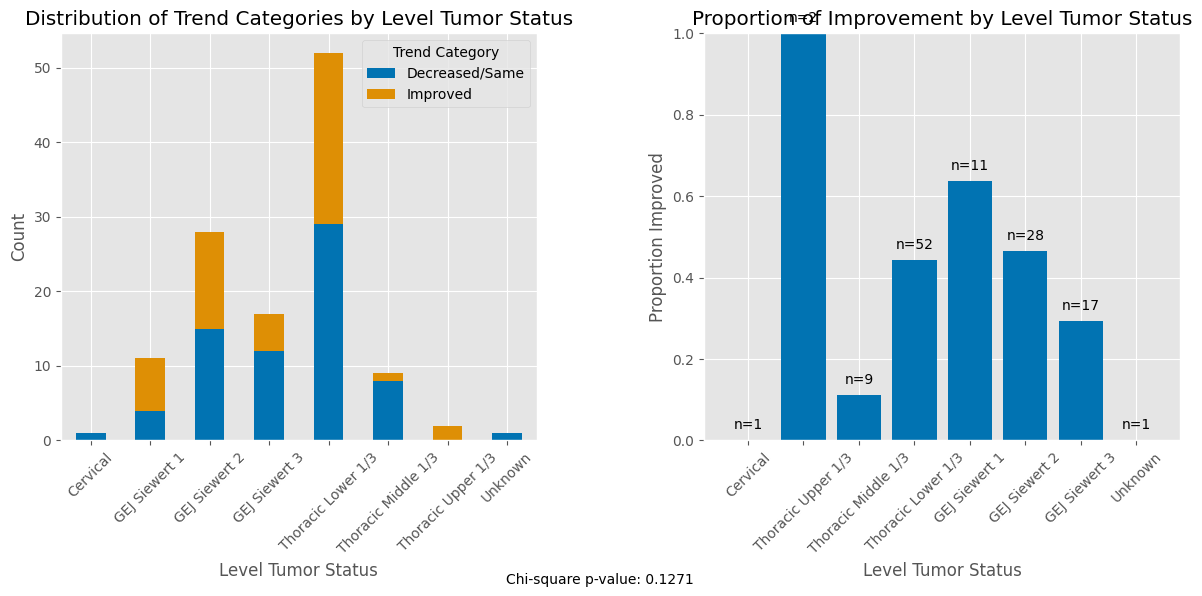

In [109]:
# Visualize with bar plot showing proportions
plt.figure(figsize=(12, 6))

# Subplot 1: Contingency table as stacked bar chart
plt.subplot(1, 2, 1)
contingency_table.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title("Distribution of Trend Categories by Level Tumor Status")
plt.xlabel("Level Tumor Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Trend Category")

# Subplot 2: Proportion of improvement by level_tumor status
plt.subplot(1, 2, 2)
bars = plt.bar(proportion_df["level_tumor_status"], proportion_df["proportion_improved"])
plt.title("Proportion of Improvement by Level Tumor Status")
plt.xlabel("Level Tumor Status")
plt.ylabel("Proportion Improved")
plt.xticks(rotation=45)
plt.ylim(0, 1)

# Add count labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'n={proportion_df.iloc[i]["total_count"]}',
                ha='center', va='bottom')

plt.annotate(f"Chi-square p-value: {p_value_chi2:.4f}", xy=(0.5, 0.02), 
                xycoords='figure fraction', ha='center')

plt.tight_layout()
plt.show()

# sensitivity analysis 4) level of tumor (level_tumor)

/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/yjkweon2/jinenv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/yjkweon2/jinenv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warn

Sensitivity Analysis Results:
    threshold  improvement_rate    chi2_p  logistic_p    odds_ratio
0           0          0.504132  0.310689    0.998851  3.046141e+17
1           1          0.495868  0.330508    0.998851  3.052360e+17
2           2          0.495868  0.330508    0.998851  3.052360e+17
3           3          0.429752  0.120824    0.998905  3.740541e+17
4           4          0.421488  0.127079    0.998940  4.213128e+17
5           5          0.421488  0.127079    0.998940  4.213128e+17
6           6          0.413223  0.129648    0.998942  4.243075e+17
7           7          0.396694  0.141202    0.998937  4.169636e+17
8           8          0.371901  0.057244    0.998939  4.191506e+17
9           9          0.363636  0.027870    0.998979  4.763067e+17
10         10          0.347107  0.026350    0.999033  5.607303e+17


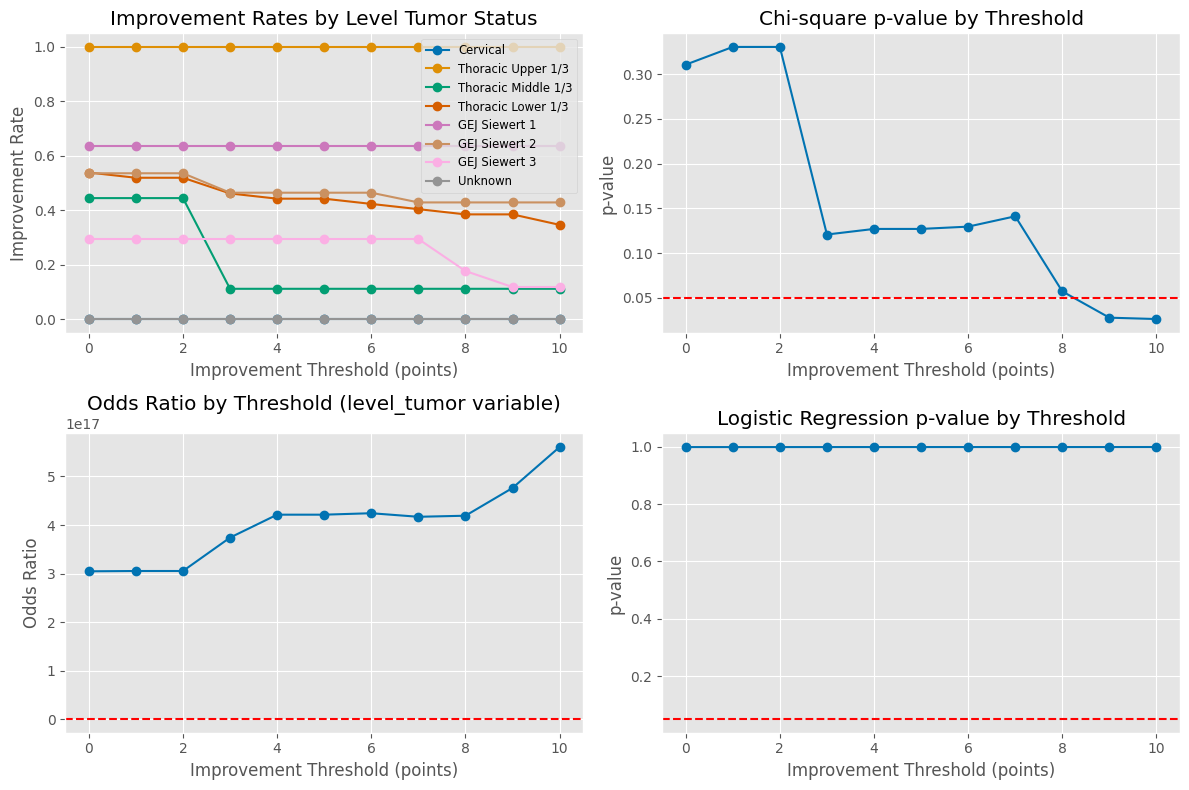


Patient Counts at Different Thresholds:
    Threshold  Improved Count  Decreased/Same Count  Improved %  \
0           0              61                    60   50.413223   
1           1              60                    61   49.586777   
2           2              60                    61   49.586777   
3           3              52                    69   42.975207   
4           4              51                    70   42.148760   
5           5              51                    70   42.148760   
6           6              50                    71   41.322314   
7           7              48                    73   39.669421   
8           8              45                    76   37.190083   
9           9              44                    77   36.363636   
10         10              42                    79   34.710744   

    Decreased/Same %  
0          49.586777  
1          50.413223  
2          50.413223  
3          57.024793  
4          57.851240  
5          57.85

In [110]:
def analyze_improvement_threshold_level_tumor(data, threshold):
    """
    Analyze how the improvement threshold affects classification and level_tumor status relationship
    
    Parameters:
    data: DataFrame containing level_tumor and Change scores
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the new threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    df["Trend Category_binary"] = df["Improved"].astype(int)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count
    
    # Chi-square test
    try:
        contingency = pd.crosstab(df["level_tumor"], df["Improved"])
        chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency)
    except:
        chi2, p_value_chi2 = None, None
    
    # Logistic regression with one-hot encoding
    try:
        level_tumor_dummies = pd.get_dummies(df["level_tumor"], prefix="level_tumor", drop_first=True).astype(int)
        X = sm.add_constant(level_tumor_dummies)
        y = df["Trend Category_binary"]
        
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        logistic_p = result.pvalues.min()  # Get minimum p-value from all level_tumor coefficients
        
        # Get odds ratios and confidence intervals
        odds_ratios = np.exp(result.params[1:])  # Exclude intercept
        conf_int = result.conf_int()
        odds_ratio_lower_ci = np.exp(conf_int.iloc[1:, 0])  # Lower CI for level_tumor variables
        odds_ratio_upper_ci = np.exp(conf_int.iloc[1:, 1])  # Upper CI for level_tumor variables
        
        # Take the first level_tumor variable's odds ratio as representative
        odds_ratio = odds_ratios.iloc[0] if len(odds_ratios) > 0 else None
        lower_ci = odds_ratio_lower_ci.iloc[0] if len(odds_ratio_lower_ci) > 0 else None
        upper_ci = odds_ratio_upper_ci.iloc[0] if len(odds_ratio_upper_ci) > 0 else None
        
    except:
        logistic_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "chi2_stat": chi2,
        "chi2_p": p_value_chi2,
        "logistic_p": logistic_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Prepare clean dataset
merged_df_clean_level = merged_df_level.dropna(subset=["level_tumor", "Change"]).drop_duplicates()
merged_df_clean_level["level_tumor"] = pd.to_numeric(merged_df_clean_level["level_tumor"], errors='coerce')
merged_df_clean_level = merged_df_clean_level.dropna(subset=["level_tumor"])

for threshold in thresholds:
    result = analyze_improvement_threshold_level_tumor(merged_df_clean_level, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis Results:")
print(sensitivity_df[["threshold", "improvement_rate", "chi2_p", "logistic_p", "odds_ratio"]])

# Plot how improvement rate changes with threshold
plt.figure(figsize=(12, 8))

# Plot improvement rates by level_tumor status
plt.subplot(2, 2, 1)
for level_tumor_val, label in level_tumor_labels.items():
    rates = []
    for threshold in thresholds:
        subset = merged_df_clean_level[merged_df_clean_level["level_tumor"] == level_tumor_val]
        if len(subset) > 0:
            improved = (subset["Change"] >= threshold).sum()
            rate = improved / len(subset)
            rates.append(rate)
        else:
            rates.append(0)
    plt.plot(thresholds, rates, 'o-', label=label)

plt.title("Improvement Rates by Level Tumor Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Improvement Rate")
plt.legend(fontsize='small')
plt.grid(True)

# Plot p-values from Chi-square test (equivalent to Mann-Whitney for categorical)
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["chi2_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Chi-square p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot odds ratios from logistic regression
plt.subplot(2, 2, 3)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio by Threshold (level_tumor variable)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

# Plot p-values from logistic regression
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["logistic_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Create a table showing the number and percentage of patients in each category at different thresholds
category_counts = []

for threshold in thresholds:
    df_temp = merged_df_clean_level.copy()
    df_temp["Improved"] = df_temp["Change"] >= threshold
    improved_count = df_temp["Improved"].sum()
    total = len(df_temp)
    
    category_counts.append({
        "Threshold": threshold,
        "Improved Count": improved_count,
        "Decreased/Same Count": total - improved_count,
        "Improved %": (improved_count / total) * 100,
        "Decreased/Same %": ((total - improved_count) / total) * 100
    })

category_df = pd.DataFrame(category_counts)
print("\nPatient Counts at Different Thresholds:")
print(category_df)

# statistically significantly associated with 5) histology (path_histology)

In [111]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [112]:
merged_df_tumorhistology = score_comparison.merge(filtered_df[["id", "path_histology___noca", 
                                                        "path_histology___hgd", "path_histology___cis", "path_histology___adeno", 
                                                        "path_histology___scc", "path_histology___nec", "path_histology___other"]], on="id", how="left")

# First, create a mapping dictionary
histology_mapping = {
    "path_histology___noca": 1,
    "path_histology___hgd": 2,
    "path_histology___cis": 3,
    "path_histology___adeno": 4,
    "path_histology___scc": 5,
    "path_histology___nec": 6,
    "path_histology___other": 7
}

# Create the histology column
def assign_histology(row):
    # Get columns that are 1 (True)
    active_cols = [col for col in histology_mapping.keys() if row[col] == 1]
    
    if len(active_cols) == 1:
        return histology_mapping[active_cols[0]]
    elif len(active_cols) > 1:
        return 8  # mixed
    else:
        return None  # missing/NaN

merged_df_tumorhistology['histology'] = merged_df_tumorhistology.apply(assign_histology, axis=1)

# If you want to handle mixed at the patient level (across multiple rows per patient):
# Group by id and check if patient has multiple different histology types
patient_histology = merged_df_tumorhistology.groupby('id')['histology'].apply(lambda x: 8 if len(set(x.dropna())) > 1 else x.dropna().iloc[0] if len(x.dropna()) > 0 else None).reset_index()
patient_histology.columns = ['id', 'final_histology']

# Merge back
merged_df_tumorhistology = merged_df_tumorhistology.merge(patient_histology[['id', 'final_histology']], on='id', how='left')

# Drop the individual histology columns and rename final_histology
merged_df_tumorhistology = merged_df_tumorhistology.drop(columns=[
    "path_histology___noca",
    "path_histology___hgd", 
    "path_histology___cis",
    "path_histology___adeno",
    "path_histology___scc",
    "path_histology___nec",
    "path_histology___other",
    "histology"
]).rename(columns={"final_histology": "path_histology"})

merged_df_tumorhistology

,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,path_histology
0,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,1.0
1,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,1.0
2,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,1.0
3,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,1.0
4,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,1.0
...,...,...,...,...,...,...,...,...
1334,1653,baseline_arm_1,112.0,153.0,41.0,True,Improved,4.0
1335,1653,baseline_arm_1,112.0,153.0,41.0,True,Improved,4.0
1336,1653,baseline_arm_1,112.0,153.0,41.0,True,Improved,4.0
1337,1653,baseline_arm_1,112.0,153.0,41.0,True,Improved,4.0


In [113]:

# Find patient IDs where all path_histology values are missing
patients_all_missing = merged_df_tumorhistology.groupby('id')['path_histology'].apply(lambda x: x.isna().all())
patients_to_impute = patients_all_missing[patients_all_missing].index

# Impute path_histology for those patients with 9999.0 (unknown/missing indicator)
mask = merged_df_tumorhistology['id'].isin(patients_to_impute)
merged_df_tumorhistology.loc[mask, 'path_histology'] = 9999.0

print(f"Imputed {len(patients_to_impute)} missing data patients with path_histology = 9999.0 (unknown)")

# Create a clean dataframe with no missing values in path_histology
merged_df_removedNA_tumorhistology = merged_df_tumorhistology.dropna(subset=["path_histology"])
merged_df_expanded_tumorhistology = merged_df_removedNA_tumorhistology.drop_duplicates()
merged_df_removedNA_tumorhistology = merged_df_expanded_tumorhistology.copy()

print(merged_df_removedNA_tumorhistology['path_histology'].value_counts())
merged_df_removedNA_tumorhistology

Imputed 1 missing data patients with path_histology = 9999.0 (unknown)
path_histology
4.0       71
8.0       22
1.0       15
5.0       10
7.0        1
9999.0     1
2.0        1
Name: count, dtype: int64


,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,path_histology
0,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,1.0
10,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,4.0
18,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,4.0
28,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,4.0
38,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,8.0
...,...,...,...,...,...,...,...,...
1294,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,4.0
1302,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,1.0
1312,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,8.0
1321,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,4.0


In [114]:
# Create path_histology status labels
path_histology_labels = {1: "noca", 2: "hgd", 3: "cis", 4: "adeno", 5: "scc", 6: "nec", 7: "other", 8: "mixed", 9999: "unknown"}
merged_df_removedNA_tumorhistology["path_histology_status"] = merged_df_removedNA_tumorhistology["path_histology"].map(path_histology_labels)

In [115]:
# Show summary statistics by improvement group and path_histology status
print("\nCrosstab of Path Histology Status and Trend Category:")
contingency_table = pd.crosstab(merged_df_removedNA_tumorhistology["path_histology_status"], 
                                merged_df_removedNA_tumorhistology["Trend Category"])
print(contingency_table)


Crosstab of Path Histology Status and Trend Category:
Trend Category         Decreased/Same  Improved
path_histology_status                          
adeno                              38        33
hgd                                 1         0
mixed                              13         9
noca                                8         7
other                               0         1
scc                                 9         1
unknown                             1         0


In [116]:
# Chi-square test
chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nChi-square test:")
print(f"Chi-square statistic: {chi2}")
print(f"p-value: {p_value_chi2}")
print(f"Degrees of freedom: {dof}")


Chi-square test:
Chi-square statistic: 7.753763890532738
p-value: 0.2567039638468331
Degrees of freedom: 6


In [117]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_tumorhistology["Trend Category_binary"] = merged_df_removedNA_tumorhistology["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Clean data for logistic regression
clean_data = merged_df_removedNA_tumorhistology.dropna(subset=["path_histology", "Trend Category_binary"])

# Logistic regression with one-hot encoding for categorical path_histology variable
path_histology_dummies = pd.get_dummies(clean_data["path_histology"], prefix="path_histology", drop_first=True).astype(int)
X = sm.add_constant(path_histology_dummies)
y = clean_data["Trend Category_binary"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print("\nLogistic Regression Results:")
print(result.summary())

         Current function value: 0.640789
         Iterations: 35

Logistic Regression Results:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  121
Model:                             Logit   Df Residuals:                      114
Method:                              MLE   Df Model:                            6
Date:                   Wed, 25 Jun 2025   Pseudo R-squ.:                 0.05873
Time:                           11:41:45   Log-Likelihood:                -77.535
converged:                         False   LL-Null:                       -82.373
Covariance Type:               nonrobust   LLR p-value:                    0.1390
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -0.1335      0.518     -0.258      0.796   

/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [118]:
# Calculate proportions for plotting
proportion_data = []
for path_histology_val, label in path_histology_labels.items():
    subset = merged_df_removedNA_tumorhistology[merged_df_removedNA_tumorhistology["path_histology"] == path_histology_val]
    if len(subset) > 0:
        improved_count = len(subset[subset["Trend Category"] == "Improved"])
        total_count = len(subset)
        proportion = improved_count / total_count
        proportion_data.append({
            "path_histology_status": label,
            "proportion_improved": proportion,
            "total_count": total_count,
            "improved_count": improved_count
        })

proportion_df = pd.DataFrame(proportion_data)
print(f"\nProportion of improvement by path_histology status:")
print(proportion_df)


Proportion of improvement by path_histology status:
  path_histology_status  proportion_improved  total_count  improved_count
0                  noca             0.466667           15               7
1                   hgd             0.000000            1               0
2                 adeno             0.464789           71              33
3                   scc             0.100000           10               1
4                 other             1.000000            1               1
5                 mixed             0.409091           22               9
6               unknown             0.000000            1               0


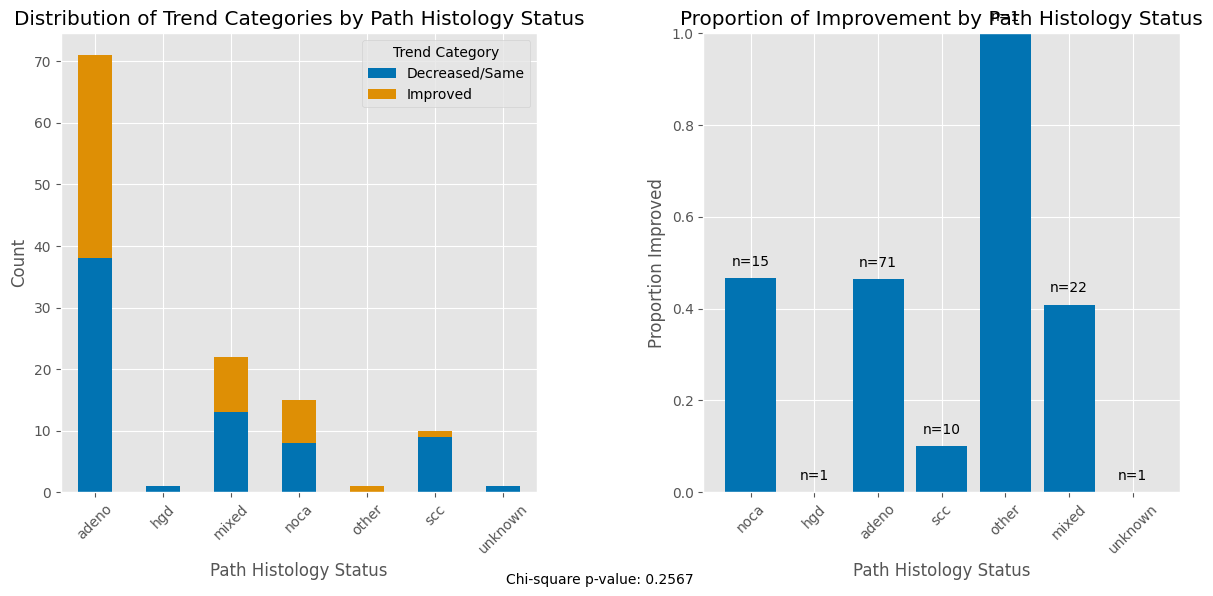

In [119]:
# Visualize with bar plot showing proportions
plt.figure(figsize=(12, 6))

# Subplot 1: Contingency table as stacked bar chart
plt.subplot(1, 2, 1)
contingency_table.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title("Distribution of Trend Categories by Path Histology Status")
plt.xlabel("Path Histology Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Trend Category")

# Subplot 2: Proportion of improvement by path_histology status
plt.subplot(1, 2, 2)
bars = plt.bar(proportion_df["path_histology_status"], proportion_df["proportion_improved"])
plt.title("Proportion of Improvement by Path Histology Status")
plt.xlabel("Path Histology Status")
plt.ylabel("Proportion Improved")
plt.xticks(rotation=45)
plt.ylim(0, 1)

# Add count labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'n={proportion_df.iloc[i]["total_count"]}',
                ha='center', va='bottom')

plt.annotate(f"Chi-square p-value: {p_value_chi2:.4f}", xy=(0.5, 0.02), 
                xycoords='figure fraction', ha='center')

plt.tight_layout()
plt.show()


# sensitivity analysis 5) histology (path_histology)

/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/yjkweon2/jinenv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/yjkweon2/jinenv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warn

Sensitivity Analysis Results:
    threshold  improvement_rate    chi2_p  logistic_p    odds_ratio
0           0          0.504132  0.277000    0.059326  1.726568e-07
1           1          0.495868  0.292351    0.059326  1.726568e-07
2           2          0.495868  0.292351    0.059326  1.726568e-07
3           3          0.429752  0.231440    0.078851  3.261651e-07
4           4          0.421488  0.256704    0.078851  3.261651e-07
5           5          0.421488  0.256704    0.078851  3.261651e-07
6           6          0.413223  0.234240    0.078851  3.261651e-07
7           7          0.396694  0.220154    0.078851  3.261651e-07
8           8          0.371901  0.294637    0.078851  3.261651e-07
9           9          0.363636  0.314359    0.078851  3.261651e-07
10         10          0.347107  0.140990    0.362926  3.268950e-07


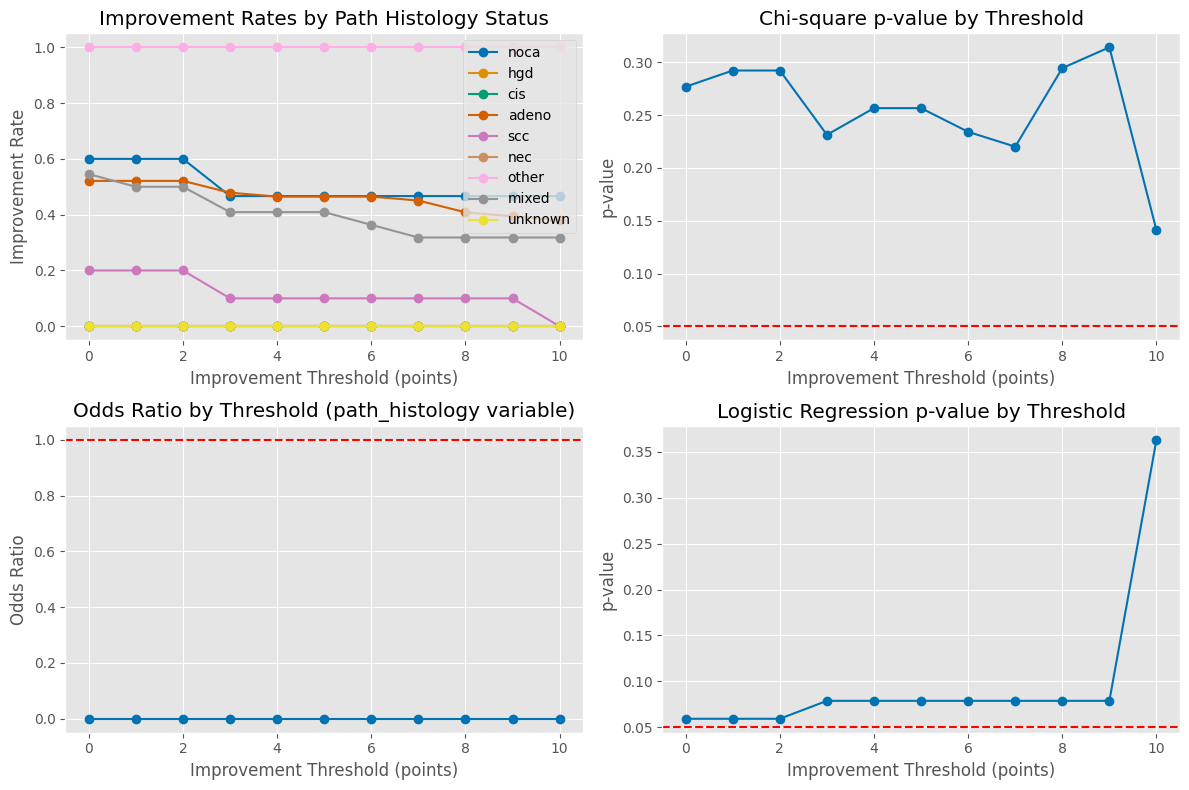


Patient Counts at Different Thresholds:
    Threshold  Improved Count  Decreased/Same Count  Improved %  \
0           0              61                    60   50.413223   
1           1              60                    61   49.586777   
2           2              60                    61   49.586777   
3           3              52                    69   42.975207   
4           4              51                    70   42.148760   
5           5              51                    70   42.148760   
6           6              50                    71   41.322314   
7           7              48                    73   39.669421   
8           8              45                    76   37.190083   
9           9              44                    77   36.363636   
10         10              42                    79   34.710744   

    Decreased/Same %  
0          49.586777  
1          50.413223  
2          50.413223  
3          57.024793  
4          57.851240  
5          57.85

In [120]:
def analyze_improvement_threshold_path_histology(data, threshold):
    """
    Analyze how the improvement threshold affects classification and path_histology status relationship
    
    Parameters:
    data: DataFrame containing path_histology and Change scores
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the new threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    df["Trend Category_binary"] = df["Improved"].astype(int)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count
    
    # Chi-square test
    try:
        contingency = pd.crosstab(df["path_histology"], df["Improved"])
        chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency)
    except:
        chi2, p_value_chi2 = None, None
    
    # Logistic regression with one-hot encoding
    try:
        path_histology_dummies = pd.get_dummies(df["path_histology"], prefix="path_histology", drop_first=True).astype(int)
        X = sm.add_constant(path_histology_dummies)
        y = df["Trend Category_binary"]
        
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        logistic_p = result.pvalues.min()  # Get minimum p-value from all path_histology coefficients
        
        # Get odds ratios and confidence intervals
        odds_ratios = np.exp(result.params[1:])  # Exclude intercept
        conf_int = result.conf_int()
        odds_ratio_lower_ci = np.exp(conf_int.iloc[1:, 0])  # Lower CI for path_histology variables
        odds_ratio_upper_ci = np.exp(conf_int.iloc[1:, 1])  # Upper CI for path_histology variables
        
        # Take the first path_histology variable's odds ratio as representative
        odds_ratio = odds_ratios.iloc[0] if len(odds_ratios) > 0 else None
        lower_ci = odds_ratio_lower_ci.iloc[0] if len(odds_ratio_lower_ci) > 0 else None
        upper_ci = odds_ratio_upper_ci.iloc[0] if len(odds_ratio_upper_ci) > 0 else None
        
    except:
        logistic_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "chi2_stat": chi2,
        "chi2_p": p_value_chi2,
        "logistic_p": logistic_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Prepare clean dataset
merged_df_clean_tumorhistology = merged_df_tumorhistology.dropna(subset=["path_histology", "Change"]).drop_duplicates()
merged_df_clean_tumorhistology["path_histology"] = pd.to_numeric(merged_df_clean_tumorhistology["path_histology"], errors='coerce')
merged_df_clean_tumorhistology = merged_df_clean_tumorhistology.dropna(subset=["path_histology"])

for threshold in thresholds:
    result = analyze_improvement_threshold_path_histology(merged_df_clean_tumorhistology, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis Results:")
print(sensitivity_df[["threshold", "improvement_rate", "chi2_p", "logistic_p", "odds_ratio"]])

# Plot how improvement rate changes with threshold
plt.figure(figsize=(12, 8))

# Plot improvement rates by path_histology status
plt.subplot(2, 2, 1)
for path_histology_val, label in path_histology_labels.items():
    rates = []
    for threshold in thresholds:
        subset = merged_df_clean_tumorhistology[merged_df_clean_tumorhistology["path_histology"] == path_histology_val]
        if len(subset) > 0:
            improved = (subset["Change"] >= threshold).sum()
            rate = improved / len(subset)
            rates.append(rate)
        else:
            rates.append(0)
    plt.plot(thresholds, rates, 'o-', label=label)

plt.title("Improvement Rates by Path Histology Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Improvement Rate")
plt.legend()
plt.grid(True)

# Plot p-values from Chi-square test (equivalent to Mann-Whitney for categorical)
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["chi2_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Chi-square p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot odds ratios from logistic regression
plt.subplot(2, 2, 3)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio by Threshold (path_histology variable)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

# Plot p-values from logistic regression
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["logistic_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Create a table showing the number and percentage of patients in each category at different thresholds
category_counts = []

for threshold in thresholds:
    df_temp = merged_df_clean_tumorhistology.copy()
    df_temp["Improved"] = df_temp["Change"] >= threshold
    improved_count = df_temp["Improved"].sum()
    total = len(df_temp)
    
    category_counts.append({
        "Threshold": threshold,
        "Improved Count": improved_count,
        "Decreased/Same Count": total - improved_count,
        "Improved %": (improved_count / total) * 100,
        "Decreased/Same %": ((total - improved_count) / total) * 100
    })

category_df = pd.DataFrame(category_counts)
print("\nPatient Counts at Different Thresholds:")
print(category_df)

# statistically significantly associated with 6) pathological stage (path_esoph_stage)

In [121]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [122]:
# Merge score_comparison with path_esoph_stage data
merged_df_pathstage = score_comparison.merge(filtered_df[["id", "path_esoph_stage"]], on="id", how="left")

print(merged_df_pathstage['path_esoph_stage'].value_counts())

# Find patient IDs where all path_esoph_stage values are missing
patients_all_missing = merged_df_pathstage.groupby('id')['path_esoph_stage'].apply(lambda x: x.isna().all())
patients_to_impute = patients_all_missing[patients_all_missing].index

# Impute path_esoph_stage for those patients with 9999.0 (unknown/missing indicator)
mask = merged_df_pathstage['id'].isin(patients_to_impute)
merged_df_pathstage.loc[mask, 'path_esoph_stage'] = 9999.0

print(f"Imputed {len(patients_to_impute)} missing data patients with path_esoph_stage = 9999.0 (unknown)")


# Create a clean dataframe with no missing values in path_esoph_stage
merged_df_removedNA_pathstage = merged_df_pathstage.dropna(subset=["path_esoph_stage"])
merged_df_expanded_pathstage = merged_df_removedNA_pathstage.drop_duplicates()
merged_df_removedNA_pathstage = merged_df_expanded_pathstage.copy()


merged_df_removedNA_pathstage

path_esoph_stage
3b    15
2b    12
0      8
3a     5
4a     4
2a     4
1b     4
5      3
4b     1
1a     1
Name: count, dtype: int64
Imputed 67 missing data patients with path_esoph_stage = 9999.0 (unknown)


,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,path_esoph_stage
0,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,9999.0
10,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,9999.0
25,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,3b
37,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,3b
38,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,9999.0
...,...,...,...,...,...,...,...,...
1294,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,9999.0
1302,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,9999.0
1312,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,9999.0
1321,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,9999.0


In [123]:
#Duplicate row for one patient 
print(merged_df_removedNA_pathstage['id'][merged_df_removedNA_pathstage['id'].duplicated()].unique())

print(merged_df_removedNA_pathstage[merged_df_removedNA_pathstage['id']==836])

[836]
      id   baseline_type  Baseline   Postop1yr     Change  \
741  836  baseline_arm_1     114.0  125.166667  11.166667   
748  836  baseline_arm_1     114.0  125.166667  11.166667   

    fact_e_total_has_improved Trend Category path_esoph_stage  
741                      True       Improved               1b  
748                      True       Improved                0  


In [124]:
# Find all rows with patient ID 836
patient_rows = merged_df_removedNA_pathstage[merged_df_removedNA_pathstage['id'] == 836]

# Get the index of the last occurrence
last_index = patient_rows.index[-1]

# Drop that row
merged_df_removedNA_pathstage = merged_df_removedNA_pathstage.drop(index=last_index)

print(merged_df_removedNA_pathstage[merged_df_removedNA_pathstage['id'] == 836])

print(merged_df_removedNA_pathstage['path_esoph_stage'].value_counts())

merged_df_removedNA_pathstage


      id   baseline_type  Baseline   Postop1yr     Change  \
741  836  baseline_arm_1     114.0  125.166667  11.166667   

    fact_e_total_has_improved Trend Category path_esoph_stage  
741                      True       Improved               1b  
path_esoph_stage
9999.0    67
3b        13
2b        12
0          7
3a         5
4a         4
2a         4
1b         4
5          3
4b         1
1a         1
Name: count, dtype: int64


,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,path_esoph_stage
0,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,9999.0
10,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,9999.0
25,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,3b
37,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,3b
38,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,9999.0
...,...,...,...,...,...,...,...,...
1294,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,9999.0
1302,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,9999.0
1312,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,9999.0
1321,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,9999.0


In [125]:
# Just clean any whitespace and ensure consistent formatting
merged_df_removedNA_pathstage["path_esoph_stage"] = merged_df_removedNA_pathstage["path_esoph_stage"].astype(str).str.strip()

# Create a status column (this will be the same as the original column since it's already in the right format)
merged_df_removedNA_pathstage["path_esoph_stage_status"] = merged_df_removedNA_pathstage["path_esoph_stage"]

# Show summary statistics by improvement group and path_esoph_stage status
print("\nCrosstab of Path Esoph Stage Status and Trend Category:")
contingency_table = pd.crosstab(merged_df_removedNA_pathstage["path_esoph_stage_status"], 
                                merged_df_removedNA_pathstage["Trend Category"])
print(contingency_table)


Crosstab of Path Esoph Stage Status and Trend Category:
Trend Category           Decreased/Same  Improved
path_esoph_stage_status                          
0                                     6         1
1a                                    1         0
1b                                    1         3
2a                                    3         1
2b                                    7         5
3a                                    4         1
3b                                    6         7
4a                                    1         3
4b                                    1         0
5                                     2         1
9999.0                               38        29


In [126]:
# Chi-square test
chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nChi-square test:")
print(f"Chi-square statistic: {chi2}")
print(f"p-value: {p_value_chi2}")
print(f"Degrees of freedom: {dof}")



Chi-square test:
Chi-square statistic: 9.576631413376676
p-value: 0.4783876957929313
Degrees of freedom: 10


In [127]:
#Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_pathstage["Trend Category_binary"] = merged_df_removedNA_pathstage["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Clean data for logistic regression
clean_data = merged_df_removedNA_pathstage.dropna(subset=["path_esoph_stage", "Trend Category_binary"])

# Logistic regression with one-hot encoding for categorical path_esoph_stage variable
path_esoph_stage_dummies = pd.get_dummies(clean_data["path_esoph_stage"], prefix="path_esoph_stage", drop_first=True).astype(int)
X = sm.add_constant(path_esoph_stage_dummies)
y = clean_data["Trend Category_binary"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print("\nLogistic Regression Results:")
print(result.summary())

         Current function value: 0.636262
         Iterations: 35

Logistic Regression Results:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  121
Model:                             Logit   Df Residuals:                      110
Method:                              MLE   Df Model:                           10
Date:                   Wed, 25 Jun 2025   Pseudo R-squ.:                 0.06538
Time:                           11:41:47   Log-Likelihood:                -76.988
converged:                         False   LL-Null:                       -82.373
Covariance Type:               nonrobust   LLR p-value:                    0.3757
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -1.7918      1.080     -1.659      0.

/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [128]:
# Calculate proportions for plotting
# Get unique values from the actual data
unique_stages = merged_df_removedNA_pathstage["path_esoph_stage"].unique()
proportion_data = []

for stage in unique_stages:
    subset = merged_df_removedNA_pathstage[merged_df_removedNA_pathstage["path_esoph_stage"] == stage]
    if len(subset) > 0:
        improved_count = len(subset[subset["Trend Category"] == "Improved"])
        total_count = len(subset)
        proportion = improved_count / total_count
        proportion_data.append({
            "path_esoph_stage_status": stage,
            "proportion_improved": proportion,
            "total_count": total_count,
            "improved_count": improved_count
        })

proportion_df = pd.DataFrame(proportion_data)
# Sort by stage for better visualization (optional - you might want to define a custom order)
proportion_df = proportion_df.sort_values("path_esoph_stage_status")
print(f"\nProportion of improvement by path_esoph_stage status:")
print(proportion_df)


Proportion of improvement by path_esoph_stage status:
   path_esoph_stage_status  proportion_improved  total_count  improved_count
5                        0             0.142857            7               1
10                      1a             0.000000            1               0
8                       1b             0.750000            4               3
7                       2a             0.250000            4               1
2                       2b             0.416667           12               5
3                       3a             0.200000            5               1
1                       3b             0.538462           13               7
6                       4a             0.750000            4               3
9                       4b             0.000000            1               0
4                        5             0.333333            3               1
0                   9999.0             0.432836           67              29


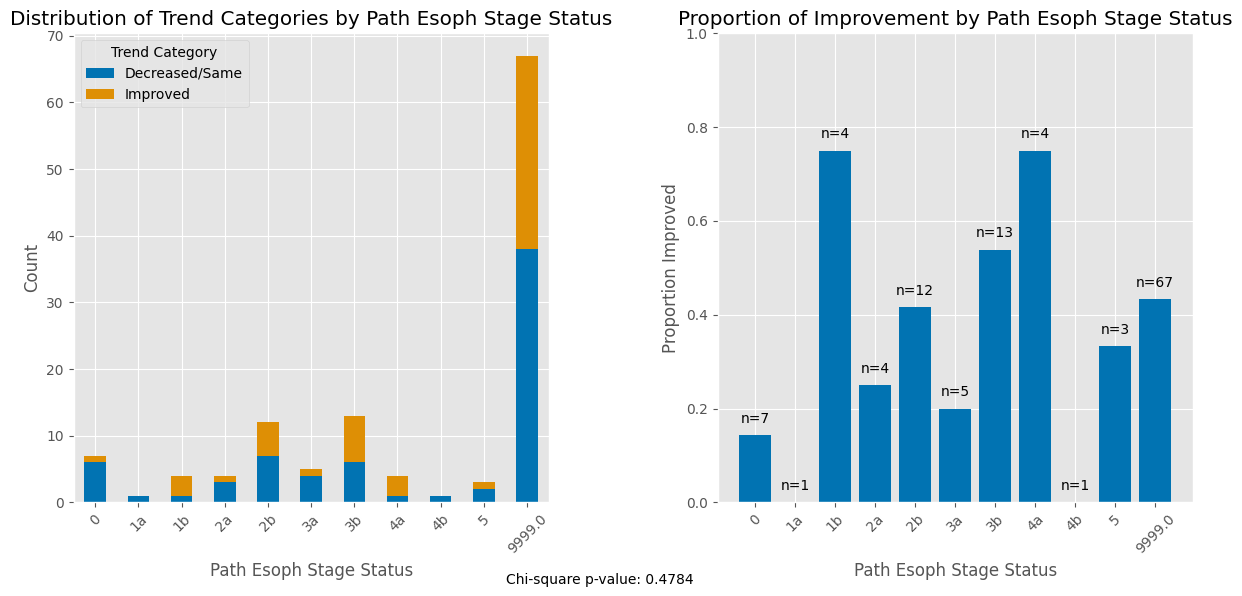

In [129]:
# Visualize with bar plot showing proportions
plt.figure(figsize=(12, 6))

# Subplot 1: Contingency table as stacked bar chart
plt.subplot(1, 2, 1)
contingency_table.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title("Distribution of Trend Categories by Path Esoph Stage Status")
plt.xlabel("Path Esoph Stage Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Trend Category")

# Subplot 2: Proportion of improvement by path_esoph_stage status
plt.subplot(1, 2, 2)
bars = plt.bar(proportion_df["path_esoph_stage_status"], proportion_df["proportion_improved"])
plt.title("Proportion of Improvement by Path Esoph Stage Status")
plt.xlabel("Path Esoph Stage Status")
plt.ylabel("Proportion Improved")
plt.xticks(rotation=45)
plt.ylim(0, 1)

# Add count labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'n={proportion_df.iloc[i]["total_count"]}',
             ha='center', va='bottom')

plt.annotate(f"Chi-square p-value: {p_value_chi2:.4f}", xy=(0.5, 0.02), 
             xycoords='figure fraction', ha='center')

plt.tight_layout()
plt.show()

# sensitivity analysis 6) pathological stage (path_esoph_stage)

/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/yjkweon2/jinenv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/yjkweon2/jinenv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warn

Sensitivity Analysis Results:
    threshold  improvement_rate    chi2_p  logistic_p    odds_ratio
0           0          0.508197  0.647402    0.294666  1.299168e+11
1           1          0.500000  0.595609    0.238801  2.166128e+11
2           2          0.500000  0.595609    0.238801  2.166128e+11
3           3          0.434426  0.583371    0.120263  2.311126e-11
4           4          0.426230  0.601801    0.120263  2.311126e-11
5           5          0.426230  0.601801    0.120263  2.311126e-11
6           6          0.418033  0.757780    0.120263  2.311126e-11
7           7          0.401639  0.735311    0.120263  2.311126e-11
8           8          0.377049  0.508727    0.120263  2.311126e-11
9           9          0.368852  0.322744    0.120263  2.311126e-11
10         10          0.352459  0.426238    0.120263  2.311126e-11


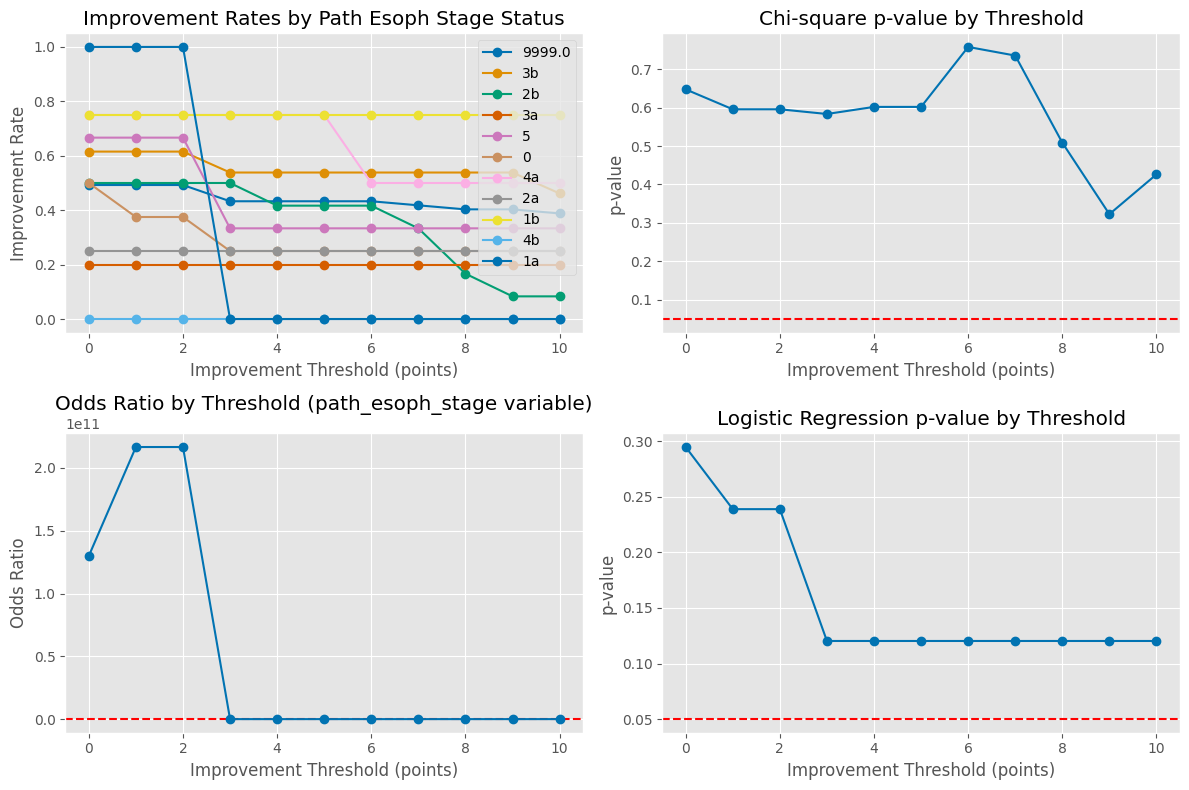


Patient Counts at Different Thresholds:
    Threshold  Improved Count  Decreased/Same Count  Improved %  \
0           0              62                    60   50.819672   
1           1              61                    61   50.000000   
2           2              61                    61   50.000000   
3           3              53                    69   43.442623   
4           4              52                    70   42.622951   
5           5              52                    70   42.622951   
6           6              51                    71   41.803279   
7           7              49                    73   40.163934   
8           8              46                    76   37.704918   
9           9              45                    77   36.885246   
10         10              43                    79   35.245902   

    Decreased/Same %  
0          49.180328  
1          50.000000  
2          50.000000  
3          56.557377  
4          57.377049  
5          57.37

In [130]:
def analyze_improvement_threshold_path_esoph_stage(data, threshold):
    """
    Analyze how the improvement threshold affects classification and path_esoph_stage status relationship
    
    Parameters:
    data: DataFrame containing path_esoph_stage and Change scores
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the new threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    df["Trend Category_binary"] = df["Improved"].astype(int)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count
    
    # Chi-square test
    try:
        contingency = pd.crosstab(df["path_esoph_stage"], df["Improved"])
        chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency)
    except:
        chi2, p_value_chi2 = None, None
    
    # Logistic regression with one-hot encoding
    try:
        path_esoph_stage_dummies = pd.get_dummies(df["path_esoph_stage"], prefix="path_esoph_stage", drop_first=True).astype(int)
        X = sm.add_constant(path_esoph_stage_dummies)
        y = df["Trend Category_binary"]
        
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        logistic_p = result.pvalues.min()  # Get minimum p-value from all path_esoph_stage coefficients
        
        # Get odds ratios and confidence intervals
        odds_ratios = np.exp(result.params[1:])  # Exclude intercept
        conf_int = result.conf_int()
        odds_ratio_lower_ci = np.exp(conf_int.iloc[1:, 0])  # Lower CI for path_esoph_stage variables
        odds_ratio_upper_ci = np.exp(conf_int.iloc[1:, 1])  # Upper CI for path_esoph_stage variables
        
        # Take the first path_esoph_stage variable's odds ratio as representative
        odds_ratio = odds_ratios.iloc[0] if len(odds_ratios) > 0 else None
        lower_ci = odds_ratio_lower_ci.iloc[0] if len(odds_ratio_lower_ci) > 0 else None
        upper_ci = odds_ratio_upper_ci.iloc[0] if len(odds_ratio_upper_ci) > 0 else None
        
    except:
        logistic_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "chi2_stat": chi2,
        "chi2_p": p_value_chi2,
        "logistic_p": logistic_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Prepare clean dataset - DON'T convert to numeric since path_esoph_stage is already strings
merged_df_clean_pathstage = merged_df_pathstage.dropna(subset=["path_esoph_stage", "Change"]).drop_duplicates()
merged_df_clean_pathstage["path_esoph_stage"] = merged_df_clean_pathstage["path_esoph_stage"].astype(str).str.strip()

for threshold in thresholds:
    result = analyze_improvement_threshold_path_esoph_stage(merged_df_clean_pathstage, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis Results:")
print(sensitivity_df[["threshold", "improvement_rate", "chi2_p", "logistic_p", "odds_ratio"]])

# Plot how improvement rate changes with threshold
plt.figure(figsize=(12, 8))

# Get unique stage values for plotting
unique_stages = merged_df_clean_pathstage["path_esoph_stage"].unique()

# Plot improvement rates by path_esoph_stage status
plt.subplot(2, 2, 1)
for stage in unique_stages:
    rates = []
    for threshold in thresholds:
        subset = merged_df_clean_pathstage[merged_df_clean_pathstage["path_esoph_stage"] == stage]
        if len(subset) > 0:
            improved = (subset["Change"] >= threshold).sum()
            rate = improved / len(subset)
            rates.append(rate)
        else:
            rates.append(0)
    plt.plot(thresholds, rates, 'o-', label=stage)

plt.title("Improvement Rates by Path Esoph Stage Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Improvement Rate")
plt.legend()
plt.grid(True)

# Plot p-values from Chi-square test
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["chi2_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Chi-square p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot odds ratios from logistic regression
plt.subplot(2, 2, 3)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio by Threshold (path_esoph_stage variable)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

# Plot p-values from logistic regression
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["logistic_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Create a table showing the number and percentage of patients in each category at different thresholds
category_counts = []

for threshold in thresholds:
    df_temp = merged_df_clean_pathstage.copy()
    df_temp["Improved"] = df_temp["Change"] >= threshold
    improved_count = df_temp["Improved"].sum()
    total = len(df_temp)
    
    category_counts.append({
        "Threshold": threshold,
        "Improved Count": improved_count,
        "Decreased/Same Count": total - improved_count,
        "Improved %": (improved_count / total) * 100,
        "Decreased/Same %": ((total - improved_count) / total) * 100
    })

category_df = pd.DataFrame(category_counts)
print("\nPatient Counts at Different Thresholds:")
print(category_df)

# statistically significantly associated with 7) surgery type (procedure123456)

In [131]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [132]:
# Merge score_comparison with procedure123456 data
merged_df_procedure = score_comparison.merge(filtered_df[["id", "procedure123456"]], on="id", how="left")

print(merged_df_procedure['procedure123456'].value_counts())

# Find patient IDs where all procedure123456 values are missing
patients_all_missing = merged_df_procedure.groupby('id')['procedure123456'].apply(lambda x: x.isna().all())
patients_to_impute = patients_all_missing[patients_all_missing].index

# Impute procedure123456 for those patients with 9999.0 (unknown/missing indicator)
mask = merged_df_procedure['id'].isin(patients_to_impute)
merged_df_procedure.loc[mask, 'procedure123456'] = 9999.0

print(f"Imputed {len(patients_to_impute)} missing data patients with procedure123456 = 9999.0 (unknown)")

# Create a clean dataframe with no missing values in procedure123456
merged_df_removedNA_procedure = merged_df_procedure.dropna(subset=["procedure123456"])
merged_df_expanded_procedure = merged_df_removedNA_procedure.drop_duplicates()
merged_df_removedNA_procedure = merged_df_expanded_procedure.copy()

print(merged_df_procedure['procedure123456'].value_counts())
merged_df_removedNA_procedure

procedure123456
1.0    71
2.0    21
4.0    12
8.0     9
5.0     5
3.0     3
Name: count, dtype: int64
Imputed 8 missing data patients with procedure123456 = 9999.0 (unknown)
procedure123456
1.0       71
9999.0    71
2.0       21
4.0       12
8.0        9
5.0        5
3.0        3
Name: count, dtype: int64


,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,procedure123456
0,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,1.0
12,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,1.0
20,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,1.0
29,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,1.0
38,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,2.0
...,...,...,...,...,...,...,...,...
1295,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,1.0
1303,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,1.0
1316,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,1.0
1329,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,1.0


In [133]:
# Create procedure123456 status labels
procedure123456_labels = {1: "Ivor Lewis", 2: "3 Hole", 3: "Transab", 4: "Left-Thor eso", 5: "Left-Thor extended-tot", 6: "Pharyngo lary", 8: "Other", 9999: "unknown"}
merged_df_removedNA_procedure["procedure123456_status"] = merged_df_removedNA_procedure["procedure123456"].map(procedure123456_labels)

# Show summary statistics by improvement group and procedure123456 status
print("\nCrosstab of Procedure123456 Status and Trend Category:")
contingency_table = pd.crosstab(merged_df_removedNA_procedure["procedure123456_status"], 
                                merged_df_removedNA_procedure["Trend Category"])
print(contingency_table)


Crosstab of Procedure123456 Status and Trend Category:
Trend Category          Decreased/Same  Improved
procedure123456_status                          
3 Hole                              13         8
Ivor Lewis                          38        32
Left-Thor eso                       10         2
Left-Thor extended-tot               4         1
Other                                4         3
Transab                              1         2
unknown                              3         5


In [134]:
# Chi-square test
chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nChi-square test:")
print(f"Chi-square statistic: {chi2}")
print(f"p-value: {p_value_chi2}")
print(f"Degrees of freedom: {dof}")



Chi-square test:
Chi-square statistic: 6.811294908245024
p-value: 0.3386517750644736
Degrees of freedom: 6


In [135]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_procedure["Trend Category_binary"] = merged_df_removedNA_procedure["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Clean data for logistic regression
clean_data = merged_df_removedNA_procedure.dropna(subset=["procedure123456", "Trend Category_binary"])

# Logistic regression with one-hot encoding for categorical procedure123456 variable
procedure123456_dummies = pd.get_dummies(clean_data["procedure123456"], prefix="procedure123456", drop_first=True).astype(int)
X = sm.add_constant(procedure123456_dummies)
y = clean_data["Trend Category_binary"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print("\nLogistic Regression Results:")
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.651659
         Iterations 5

Logistic Regression Results:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  126
Model:                             Logit   Df Residuals:                      119
Method:                              MLE   Df Model:                            6
Date:                   Wed, 25 Jun 2025   Pseudo R-squ.:                 0.04238
Time:                           11:41:49   Log-Likelihood:                -82.109
converged:                          True   LL-Null:                       -85.743
Covariance Type:               nonrobust   LLR p-value:                    0.2969
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -0.1

In [136]:
# Calculate proportions for plotting
proportion_data = []
for procedure123456_val, label in procedure123456_labels.items():
    subset = merged_df_removedNA_procedure[merged_df_removedNA_procedure["procedure123456"] == procedure123456_val]
    if len(subset) > 0:
        improved_count = len(subset[subset["Trend Category"] == "Improved"])
        total_count = len(subset)
        proportion = improved_count / total_count
        proportion_data.append({
            "procedure123456_status": label,
            "proportion_improved": proportion,
            "total_count": total_count,
            "improved_count": improved_count
        })

proportion_df = pd.DataFrame(proportion_data)
print(f"\nProportion of improvement by procedure123456 status:")
print(proportion_df)


Proportion of improvement by procedure123456 status:
   procedure123456_status  proportion_improved  total_count  improved_count
0              Ivor Lewis             0.457143           70              32
1                  3 Hole             0.380952           21               8
2                 Transab             0.666667            3               2
3           Left-Thor eso             0.166667           12               2
4  Left-Thor extended-tot             0.200000            5               1
5                   Other             0.428571            7               3
6                 unknown             0.625000            8               5


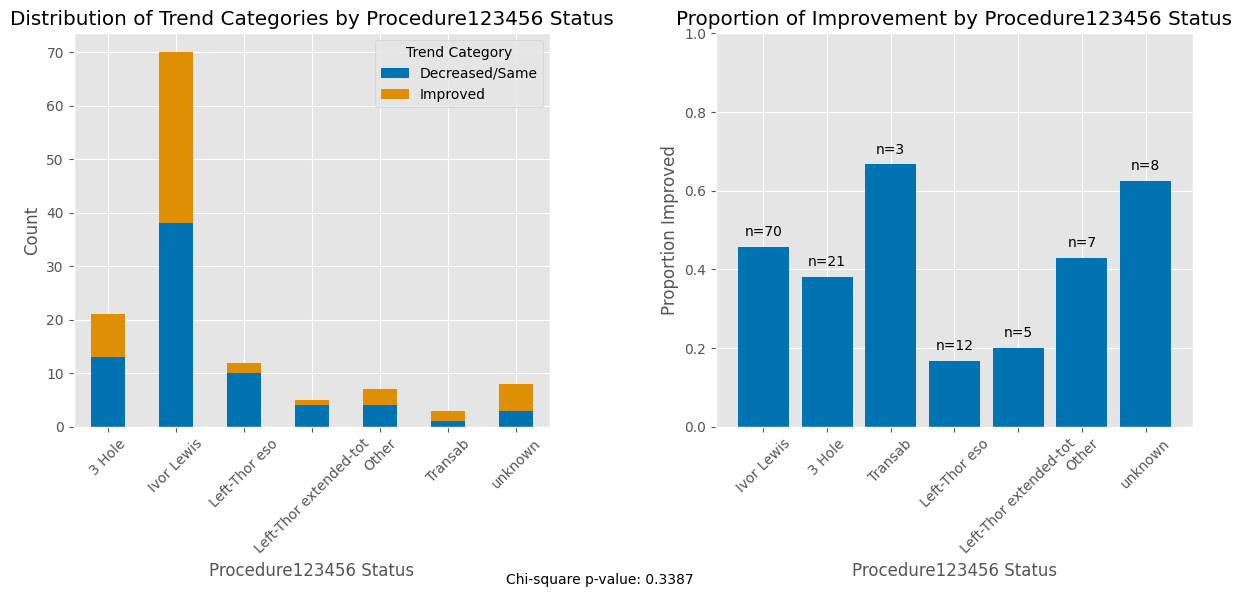

In [137]:
# Visualize with bar plot showing proportions
plt.figure(figsize=(12, 6))

# Subplot 1: Contingency table as stacked bar chart
plt.subplot(1, 2, 1)
contingency_table.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title("Distribution of Trend Categories by Procedure123456 Status")
plt.xlabel("Procedure123456 Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Trend Category")

# Subplot 2: Proportion of improvement by procedure123456 status
plt.subplot(1, 2, 2)
bars = plt.bar(proportion_df["procedure123456_status"], proportion_df["proportion_improved"])
plt.title("Proportion of Improvement by Procedure123456 Status")
plt.xlabel("Procedure123456 Status")
plt.ylabel("Proportion Improved")
plt.xticks(rotation=45)
plt.ylim(0, 1)

# Add count labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'n={proportion_df.iloc[i]["total_count"]}',
             ha='center', va='bottom')

plt.annotate(f"Chi-square p-value: {p_value_chi2:.4f}", xy=(0.5, 0.02), 
             xycoords='figure fraction', ha='center')

plt.tight_layout()
plt.show()

# sensitivity analysis 7) surgery type (procedure123456)

/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/yjkweon2/jinenv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/yjkweon2/jinenv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warn

Sensitivity Analysis Results:
    threshold  improvement_rate    chi2_p  logistic_p  odds_ratio
0           0          0.500000  0.345749    0.060937    0.722611
1           1          0.492063  0.389593    0.072956    0.765550
2           2          0.492063  0.389593    0.072956    0.765550
3           3          0.428571  0.357825    0.076258    0.890625
4           4          0.420635  0.338652    0.076258    0.730769
5           5          0.420635  0.338652    0.076258    0.730769
6           6          0.412698  0.362103    0.088905    0.774194
7           7          0.396825  0.340154    0.103307    0.666667
8           8          0.373016  0.231215    0.119667    0.706897
9           9          0.365079  0.128323    0.119667    0.706897
10         10          0.349206  0.154450    0.058064    0.796296


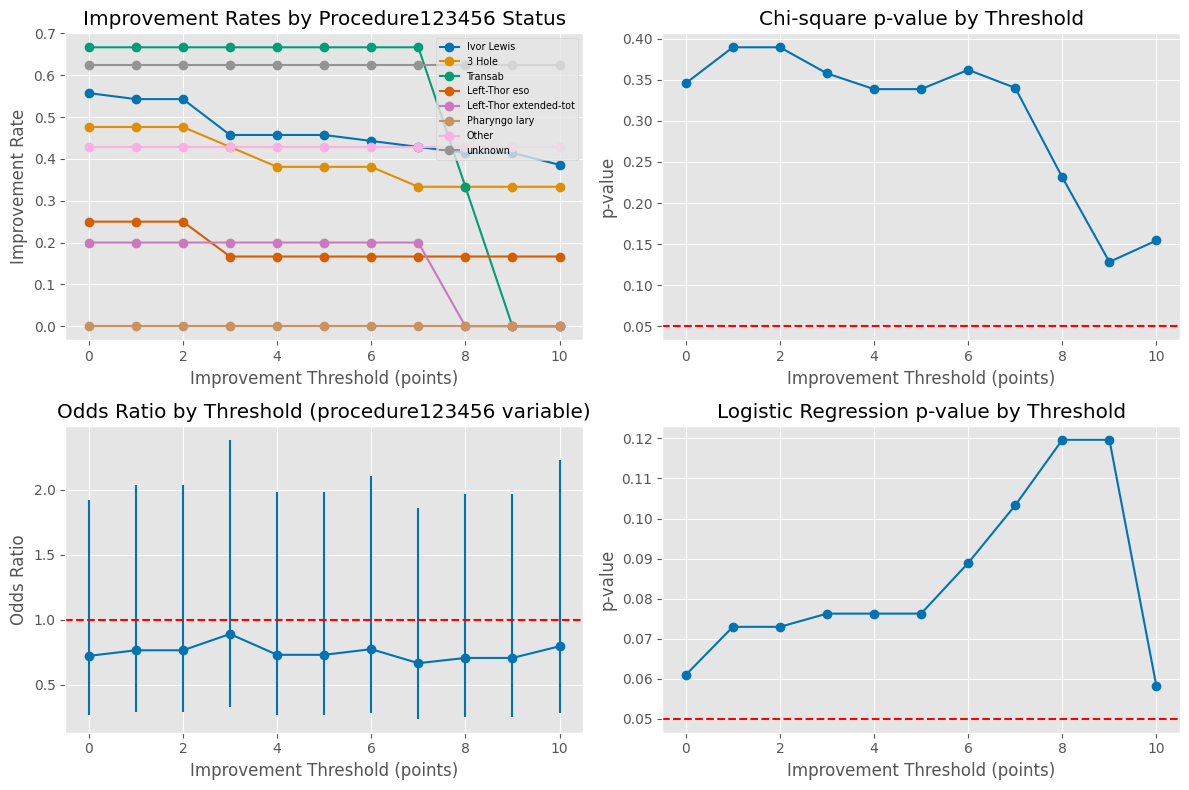


Patient Counts at Different Thresholds:
    Threshold  Improved Count  Decreased/Same Count  Improved %  \
0           0              63                    63   50.000000   
1           1              62                    64   49.206349   
2           2              62                    64   49.206349   
3           3              54                    72   42.857143   
4           4              53                    73   42.063492   
5           5              53                    73   42.063492   
6           6              52                    74   41.269841   
7           7              50                    76   39.682540   
8           8              47                    79   37.301587   
9           9              46                    80   36.507937   
10         10              44                    82   34.920635   

    Decreased/Same %  
0          50.000000  
1          50.793651  
2          50.793651  
3          57.142857  
4          57.936508  
5          57.93

In [138]:
def analyze_improvement_threshold_procedure123456(data, threshold):
    """
    Analyze how the improvement threshold affects classification and procedure123456 status relationship
    
    Parameters:
    data: DataFrame containing procedure123456 and Change scores
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the new threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    df["Trend Category_binary"] = df["Improved"].astype(int)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count
    
    # Chi-square test
    try:
        contingency = pd.crosstab(df["procedure123456"], df["Improved"])
        chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency)
    except:
        chi2, p_value_chi2 = None, None
    
    # Logistic regression with one-hot encoding
    try:
        procedure123456_dummies = pd.get_dummies(df["procedure123456"], prefix="procedure123456", drop_first=True).astype(int)
        X = sm.add_constant(procedure123456_dummies)
        y = df["Trend Category_binary"]
        
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        logistic_p = result.pvalues.min()  # Get minimum p-value from all procedure123456 coefficients
        
        # Get odds ratios and confidence intervals
        odds_ratios = np.exp(result.params[1:])  # Exclude intercept
        conf_int = result.conf_int()
        odds_ratio_lower_ci = np.exp(conf_int.iloc[1:, 0])  # Lower CI for procedure123456 variables
        odds_ratio_upper_ci = np.exp(conf_int.iloc[1:, 1])  # Upper CI for procedure123456 variables
        
        # Take the first procedure123456 variable's odds ratio as representative
        odds_ratio = odds_ratios.iloc[0] if len(odds_ratios) > 0 else None
        lower_ci = odds_ratio_lower_ci.iloc[0] if len(odds_ratio_lower_ci) > 0 else None
        upper_ci = odds_ratio_upper_ci.iloc[0] if len(odds_ratio_upper_ci) > 0 else None
        
    except:
        logistic_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "chi2_stat": chi2,
        "chi2_p": p_value_chi2,
        "logistic_p": logistic_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Prepare clean dataset
merged_df_clean_procedure = merged_df_procedure.dropna(subset=["procedure123456", "Change"]).drop_duplicates()
merged_df_clean_procedure["procedure123456"] = pd.to_numeric(merged_df_clean_procedure["procedure123456"], errors='coerce')
merged_df_clean_procedure = merged_df_clean_procedure.dropna(subset=["procedure123456"])

for threshold in thresholds:
    result = analyze_improvement_threshold_procedure123456(merged_df_clean_procedure, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis Results:")
print(sensitivity_df[["threshold", "improvement_rate", "chi2_p", "logistic_p", "odds_ratio"]])

# Plot how improvement rate changes with threshold
plt.figure(figsize=(12, 8))

# Plot improvement rates by procedure123456 status
plt.subplot(2, 2, 1)
for procedure123456_val, label in procedure123456_labels.items():
    rates = []
    for threshold in thresholds:
        subset = merged_df_clean_procedure[merged_df_clean_procedure["procedure123456"] == procedure123456_val]
        if len(subset) > 0:
            improved = (subset["Change"] >= threshold).sum()
            rate = improved / len(subset)
            rates.append(rate)
        else:
            rates.append(0)
    plt.plot(thresholds, rates, 'o-', label=label)

plt.title("Improvement Rates by Procedure123456 Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Improvement Rate")
plt.legend(fontsize='x-small')
plt.grid(True)

# Plot p-values from Chi-square test (equivalent to Mann-Whitney for categorical)
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["chi2_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Chi-square p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot odds ratios from logistic regression
plt.subplot(2, 2, 3)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio by Threshold (procedure123456 variable)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

# Plot p-values from logistic regression
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["logistic_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Create a table showing the number and percentage of patients in each category at different thresholds
category_counts = []

for threshold in thresholds:
    df_temp = merged_df_clean_procedure.copy()
    df_temp["Improved"] = df_temp["Change"] >= threshold
    improved_count = df_temp["Improved"].sum()
    total = len(df_temp)
    
    category_counts.append({
        "Threshold": threshold,
        "Improved Count": improved_count,
        "Decreased/Same Count": total - improved_count,
        "Improved %": (improved_count / total) * 100,
        "Decreased/Same %": ((total - improved_count) / total) * 100
    })

category_df = pd.DataFrame(category_counts)
print("\nPatient Counts at Different Thresholds:")
print(category_df)

# statistically significantly associated with 8) Neoadjuvant treatment

In [139]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [140]:
merged_df_neotx = score_comparison.merge(filtered_df[["id", "neotx___notx",
                                                    "neotx___chemo", "neotx___rads", "neotx___chemorads",
                                                    "neotx___immuno", "neotx___other"]], on="id", how="left")

# First, create a mapping dictionary
neotx_mapping = {
    "neotx___notx": 1,
    "neotx___chemo": 2,
    "neotx___rads": 3,
    "neotx___chemorads": 4,
    "neotx___immuno": 5,
    "neotx___other": 6
}

# Create the neotx column
def assign_neotx(row):
    # Get columns that are 1 (True)
    active_cols = [col for col in neotx_mapping.keys() if row[col] == 1]
    
    if len(active_cols) == 1:
        return neotx_mapping[active_cols[0]]
    elif len(active_cols) > 1:
        return 7  # mixed
    else:
        return None  # missing/NaN

merged_df_neotx['neotx'] = merged_df_neotx.apply(assign_neotx, axis=1)

# If you want to handle mixed at the patient level (across multiple rows per patient):
# Group by id and check if patient has multiple different neotx types
patient_neotx = merged_df_neotx.groupby('id')['neotx'].apply(lambda x: 7 if len(set(x.dropna())) > 1 else x.dropna().iloc[0] if len(x.dropna()) > 0 else None).reset_index()
patient_neotx.columns = ['id', 'final_neotx']

# Merge back
merged_df_neotx = merged_df_neotx.merge(patient_neotx[['id', 'final_neotx']], on='id', how='left')

# Drop the individual neotx columns and rename final_neotx
merged_df_neotx = merged_df_neotx.drop(columns=[
    "neotx___notx",
    "neotx___chemo",
    "neotx___rads",
    "neotx___chemorads",
    "neotx___immuno",
    "neotx___other",
    "neotx"
]).rename(columns={"final_neotx": "neotx"})

merged_df_neotx

,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,neotx
0,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,2.0
1,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,2.0
2,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,2.0
3,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,2.0
4,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,2.0
...,...,...,...,...,...,...,...,...
1334,1653,baseline_arm_1,112.0,153.0,41.0,True,Improved,2.0
1335,1653,baseline_arm_1,112.0,153.0,41.0,True,Improved,2.0
1336,1653,baseline_arm_1,112.0,153.0,41.0,True,Improved,2.0
1337,1653,baseline_arm_1,112.0,153.0,41.0,True,Improved,2.0


In [141]:
# Find patient IDs where all neotx values are missing
patients_all_missing = merged_df_neotx.groupby('id')['neotx'].apply(lambda x: x.isna().all())
patients_to_impute = patients_all_missing[patients_all_missing].index

# Impute neotx for those patients with 9999.0 (unknown/missing indicator)
mask = merged_df_neotx['id'].isin(patients_to_impute)
merged_df_neotx.loc[mask, 'neotx'] = 9999.0

print(f"Imputed {len(patients_to_impute)} missing data patients with neotx = 9999.0 (unknown)")

# Create a clean dataframe with no missing values in neotx
merged_df_removedNA_neotx = merged_df_neotx.dropna(subset=["neotx"])
merged_df_expanded_neotx = merged_df_removedNA_neotx.drop_duplicates()
merged_df_removedNA_neotx = merged_df_expanded_neotx.copy()

print(merged_df_removedNA_neotx['neotx'].value_counts())
merged_df_removedNA_neotx

Imputed 9 missing data patients with neotx = 9999.0 (unknown)
neotx
2.0       68
7.0       19
1.0       12
4.0       10
9999.0     9
6.0        2
3.0        1
Name: count, dtype: int64


,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,neotx
0,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,2.0
10,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,2.0
18,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,2.0
28,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,2.0
38,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,9999.0
...,...,...,...,...,...,...,...,...
1294,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,2.0
1302,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,2.0
1312,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,2.0
1321,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,2.0


In [142]:
# Create neotx status labels
neotx_labels = {1: "notx", 2: "chemo", 3: "rads", 4: "chemorads", 5: "immuno", 6: "other", 7: "mixed", 9999: "unknown"}
merged_df_removedNA_neotx["neotx_status"] = merged_df_removedNA_neotx["neotx"].map(neotx_labels)

In [143]:
# Show summary statistics by improvement group and neotx status
print("\nCrosstab of Neotx Status and Trend Category:")
contingency_table = pd.crosstab(merged_df_removedNA_neotx["neotx_status"], 
                               merged_df_removedNA_neotx["Trend Category"])
print(contingency_table)



Crosstab of Neotx Status and Trend Category:
Trend Category  Decreased/Same  Improved
neotx_status                            
chemo                       42        26
chemorads                    5         5
mixed                        9        10
notx                         7         5
other                        1         1
rads                         1         0
unknown                      5         4


In [144]:
# Chi-square test
chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nChi-square test:")
print(f"Chi-square statistic: {chi2}")
print(f"p-value: {p_value_chi2}")
print(f"Degrees of freedom: {dof}")


Chi-square test:
Chi-square statistic: 2.3359067844544086
p-value: 0.8863613618216413
Degrees of freedom: 6


In [145]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_neotx["Trend Category_binary"] = merged_df_removedNA_neotx["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Clean data for logistic regression
clean_data = merged_df_removedNA_neotx.dropna(subset=["neotx", "Trend Category_binary"])

# Logistic regression with one-hot encoding for categorical neotx variable
neotx_dummies = pd.get_dummies(clean_data["neotx"], prefix="neotx", drop_first=True).astype(int)
X = sm.add_constant(neotx_dummies)
y = clean_data["Trend Category_binary"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print("\nLogistic Regression Results:")
print(result.summary())

         Current function value: 0.669654
         Iterations: 35

Logistic Regression Results:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  121
Model:                             Logit   Df Residuals:                      114
Method:                              MLE   Df Model:                            6
Date:                   Wed, 25 Jun 2025   Pseudo R-squ.:                 0.01633
Time:                           11:41:51   Log-Likelihood:                -81.028
converged:                         False   LL-Null:                       -82.373
Covariance Type:               nonrobust   LLR p-value:                    0.8467
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.3365      0.586     -0.575      0.566      -1.484       0.811
neotx

/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [146]:
# Calculate proportions for plotting
proportion_data = []
for neotx_val, label in neotx_labels.items():
    subset = merged_df_removedNA_neotx[merged_df_removedNA_neotx["neotx"] == neotx_val]
    if len(subset) > 0:
        improved_count = len(subset[subset["Trend Category"] == "Improved"])
        total_count = len(subset)
        proportion = improved_count / total_count
        proportion_data.append({
            "neotx_status": label,
            "proportion_improved": proportion,
            "total_count": total_count,
            "improved_count": improved_count
        })

proportion_df = pd.DataFrame(proportion_data)
print(f"\nProportion of improvement by neotx status:")
print(proportion_df)



Proportion of improvement by neotx status:
  neotx_status  proportion_improved  total_count  improved_count
0         notx             0.416667           12               5
1        chemo             0.382353           68              26
2         rads             0.000000            1               0
3    chemorads             0.500000           10               5
4        other             0.500000            2               1
5        mixed             0.526316           19              10
6      unknown             0.444444            9               4


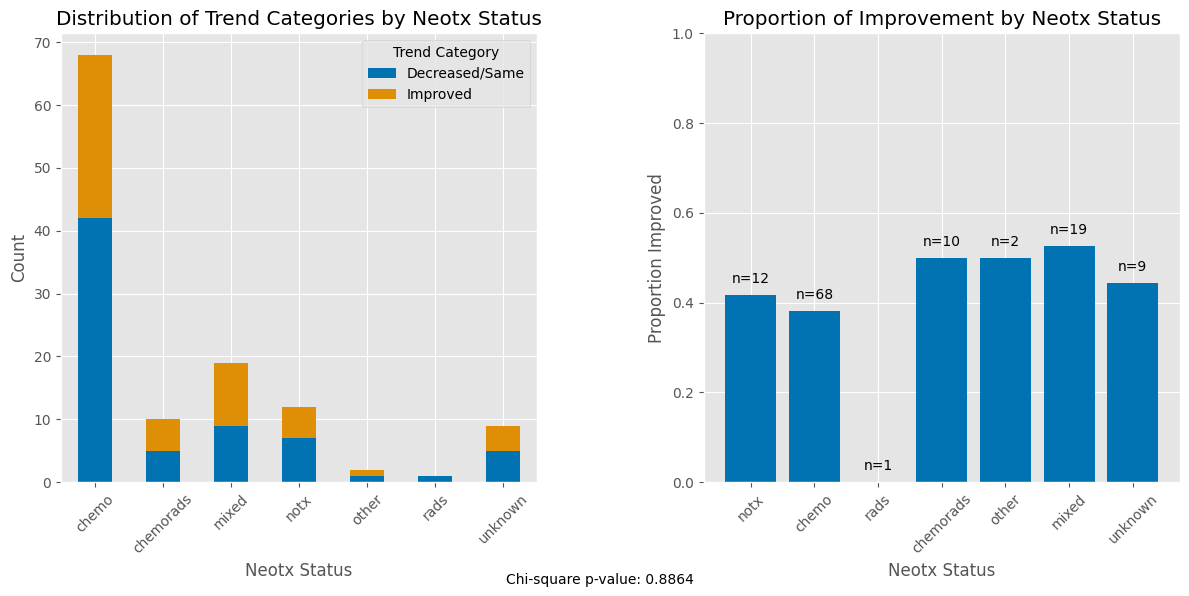

In [147]:
# Visualize with bar plot showing proportions
plt.figure(figsize=(12, 6))

# Subplot 1: Contingency table as stacked bar chart
plt.subplot(1, 2, 1)
contingency_table.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title("Distribution of Trend Categories by Neotx Status")
plt.xlabel("Neotx Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Trend Category")

# Subplot 2: Proportion of improvement by neotx status
plt.subplot(1, 2, 2)
bars = plt.bar(proportion_df["neotx_status"], proportion_df["proportion_improved"])
plt.title("Proportion of Improvement by Neotx Status")
plt.xlabel("Neotx Status")
plt.ylabel("Proportion Improved")
plt.xticks(rotation=45)
plt.ylim(0, 1)

# Add count labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'n={proportion_df.iloc[i]["total_count"]}',
                ha='center', va='bottom')

plt.annotate(f"Chi-square p-value: {p_value_chi2:.4f}", xy=(0.5, 0.02), 
                xycoords='figure fraction', ha='center')

plt.tight_layout()
plt.show()


# sensitivity analysis 8) Neoadjuvant treatment

/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/yjkweon2/jinenv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/yjkweon2/jinenv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/yjkweon2/jinenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warn

Sensitivity Analysis Results:
    threshold  improvement_rate    chi2_p  logistic_p  odds_ratio
0           0          0.504132  0.549386    0.366553    0.563910
1           1          0.495868  0.592954    0.308701    0.789474
2           2          0.495868  0.592954    0.308701    0.789474
3           3          0.429752  0.916817    0.552760    0.921951
4           4          0.421488  0.886361    0.552760    0.866667
5           5          0.421488  0.886361    0.552760    0.866667
6           6          0.413223  0.845632    0.552760    0.813953
7           7          0.396694  0.777996    0.552760    0.763636
8           8          0.371901  0.931261    0.257675    1.090909
9           9          0.363636  0.912260    0.257675    1.022222
10         10          0.347107  0.920441    0.257675    0.956522


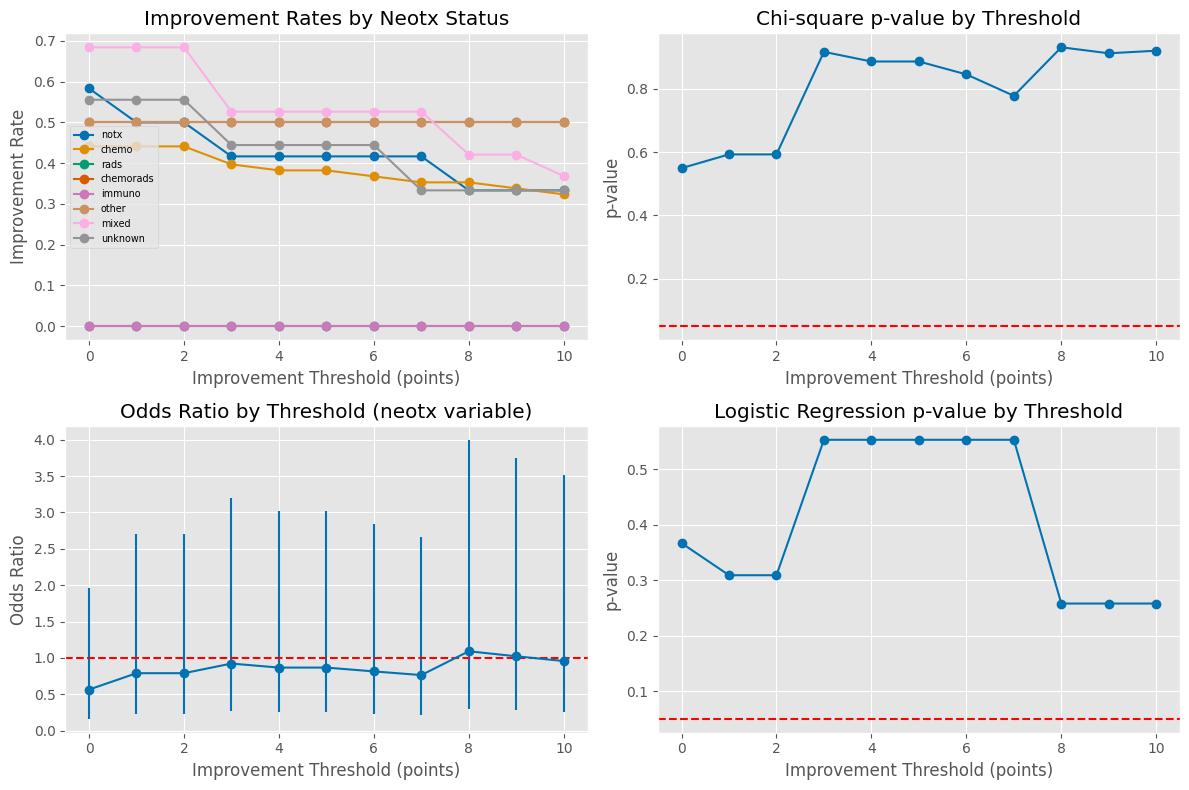


Patient Counts at Different Thresholds:
    Threshold  Improved Count  Decreased/Same Count  Improved %  \
0           0              61                    60   50.413223   
1           1              60                    61   49.586777   
2           2              60                    61   49.586777   
3           3              52                    69   42.975207   
4           4              51                    70   42.148760   
5           5              51                    70   42.148760   
6           6              50                    71   41.322314   
7           7              48                    73   39.669421   
8           8              45                    76   37.190083   
9           9              44                    77   36.363636   
10         10              42                    79   34.710744   

    Decreased/Same %  
0          49.586777  
1          50.413223  
2          50.413223  
3          57.024793  
4          57.851240  
5          57.85

In [148]:
def analyze_improvement_threshold_neotx(data, threshold):
    """
    Analyze how the improvement threshold affects classification and neotx status relationship
    
    Parameters:
    data: DataFrame containing neotx and Change scores
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the new threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    df["Trend Category_binary"] = df["Improved"].astype(int)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count
    
    # Chi-square test
    try:
        contingency = pd.crosstab(df["neotx"], df["Improved"])
        chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency)
    except:
        chi2, p_value_chi2 = None, None
    
    # Logistic regression with one-hot encoding
    try:
        neotx_dummies = pd.get_dummies(df["neotx"], prefix="neotx", drop_first=True).astype(int)
        X = sm.add_constant(neotx_dummies)
        y = df["Trend Category_binary"]
        
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        logistic_p = result.pvalues.min()  # Get minimum p-value from all neotx coefficients
        
        # Get odds ratios and confidence intervals
        odds_ratios = np.exp(result.params[1:])  # Exclude intercept
        conf_int = result.conf_int()
        odds_ratio_lower_ci = np.exp(conf_int.iloc[1:, 0])  # Lower CI for neotx variables
        odds_ratio_upper_ci = np.exp(conf_int.iloc[1:, 1])  # Upper CI for neotx variables
        
        # Take the first neotx variable's odds ratio as representative
        odds_ratio = odds_ratios.iloc[0] if len(odds_ratios) > 0 else None
        lower_ci = odds_ratio_lower_ci.iloc[0] if len(odds_ratio_lower_ci) > 0 else None
        upper_ci = odds_ratio_upper_ci.iloc[0] if len(odds_ratio_upper_ci) > 0 else None
        
    except:
        logistic_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "chi2_stat": chi2,
        "chi2_p": p_value_chi2,
        "logistic_p": logistic_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Prepare clean dataset
merged_df_clean_neotx = merged_df_neotx.dropna(subset=["neotx", "Change"]).drop_duplicates()
merged_df_clean_neotx["neotx"] = pd.to_numeric(merged_df_clean_neotx["neotx"], errors='coerce')
merged_df_clean_neotx = merged_df_clean_neotx.dropna(subset=["neotx"])

for threshold in thresholds:
    result = analyze_improvement_threshold_neotx(merged_df_clean_neotx, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis Results:")
print(sensitivity_df[["threshold", "improvement_rate", "chi2_p", "logistic_p", "odds_ratio"]])

# Plot how improvement rate changes with threshold
plt.figure(figsize=(12, 8))

# Plot improvement rates by neotx status
plt.subplot(2, 2, 1)
for neotx_val, label in neotx_labels.items():
    rates = []
    for threshold in thresholds:
        subset = merged_df_clean_neotx[merged_df_clean_neotx["neotx"] == neotx_val]
        if len(subset) > 0:
            improved = (subset["Change"] >= threshold).sum()
            rate = improved / len(subset)
            rates.append(rate)
        else:
            rates.append(0)
    plt.plot(thresholds, rates, 'o-', label=label)

plt.title("Improvement Rates by Neotx Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Improvement Rate")
plt.legend(fontsize='x-small')
plt.grid(True)

# Plot p-values from Chi-square test (equivalent to Mann-Whitney for categorical)
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["chi2_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Chi-square p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot odds ratios from logistic regression
plt.subplot(2, 2, 3)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio by Threshold (neotx variable)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

# Plot p-values from logistic regression
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["logistic_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Create a table showing the number and percentage of patients in each category at different thresholds
category_counts = []

for threshold in thresholds:
    df_temp = merged_df_clean_neotx.copy()
    df_temp["Improved"] = df_temp["Change"] >= threshold
    improved_count = df_temp["Improved"].sum()
    total = len(df_temp)
    
    category_counts.append({
        "Threshold": threshold,
        "Improved Count": improved_count,
        "Decreased/Same Count": total - improved_count,
        "Improved %": (improved_count / total) * 100,
        "Decreased/Same %": ((total - improved_count) / total) * 100
    })

category_df = pd.DataFrame(category_counts)
print("\nPatient Counts at Different Thresholds:")
print(category_df)

# statistically significantly associated with 9) age (age_diagnosis)

In [149]:
merged_df_age = score_comparison.merge(filtered_df[["id", "age_diagnosis"]], on="id", how="left")

# Calculate median age from all non-missing values
median_age = merged_df_age['age_diagnosis'].median()

# Find patient IDs where all age values are missing
patients_all_missing = merged_df_age.groupby('id')['age_diagnosis'].apply(lambda x: x.isna().all())
patients_to_impute = patients_all_missing[patients_all_missing].index

# Impute age for those patients
mask = merged_df_age['id'].isin(patients_to_impute)
merged_df_age.loc[mask, 'age_diagnosis'] = median_age
print(f"Imputed {len(patients_to_impute)} patients with median age: {median_age:.2f}")

# Create a clean dataframe with no missing values in age
merged_df_removedNA_age = merged_df_age.dropna(subset=["age_diagnosis"])
merged_df_expanded_age = merged_df_removedNA_age.drop_duplicates()
merged_df_removedNA_age = merged_df_expanded_age.copy()
merged_df_removedNA_age

Imputed 12 patients with median age: 66.18


,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,age_diagnosis
1,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,29.722718
10,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,57.597350
22,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,64.110830
31,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,50.804602
39,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,66.229970
...,...,...,...,...,...,...,...,...
1296,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,69.876863
1304,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,79.245980
1320,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,60.529648
1323,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,55.623319


In [150]:
# Show summary statistics by improvement group
print("\nBaseline scores by Trend Category:")
print(merged_df_removedNA_age.groupby("Trend Category")["age_diagnosis"].describe())

# Perform Mann-Whitney U test to compare Baseline scores between groups
improved_baseline = merged_df_removedNA_age[merged_df_removedNA_age["Trend Category"] == "Improved"]["age_diagnosis"]
decreased_same_baseline = merged_df_removedNA_age[merged_df_removedNA_age["Trend Category"] == "Decreased/Same"]["age_diagnosis"]

stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
print(f"\nMann-Whitney U test:")
print(f"Statistic: {stat}")
print(f"p-value: {p_value}")


Baseline scores by Trend Category:
                count       mean       std        min        25%        50%  \
Trend Category                                                                
Decreased/Same   70.0  64.442116  8.836364  35.168416  59.861513  66.179319   
Improved         51.0  65.433224  9.405161  29.722718  60.232528  66.179319   

                      75%        max  
Trend Category                        
Decreased/Same  69.991769  84.968206  
Improved        69.964476  83.593663  

Mann-Whitney U test:
Statistic: 1849.0
p-value: 0.7387772082278189


In [151]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_age["Trend Category_binary"] = merged_df_removedNA_age["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Logistic regression with Baseline as predictor
X = sm.add_constant(merged_df_removedNA_age["age_diagnosis"])
y = merged_df_removedNA_age["Trend Category_binary"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print("\nLogistic Regression Results:")
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.679285
         Iterations 4

Logistic Regression Results:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  121
Model:                             Logit   Df Residuals:                      119
Method:                              MLE   Df Model:                            1
Date:                   Wed, 25 Jun 2025   Pseudo R-squ.:                0.002178
Time:                           11:41:52   Log-Likelihood:                -82.193
converged:                          True   LL-Null:                       -82.373
Covariance Type:               nonrobust   LLR p-value:                    0.5491
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.1173      1.359     -0.822  

In [152]:
# Calculate odds ratio for a 10-point increase in baseline score
baseline_coef = result.params["age_diagnosis"]
odds_ratio_10points = np.exp(baseline_coef * 10)
print(f"\nOdds Ratio for a 10-point increase in baseline score: {odds_ratio_10points:.3f}")

# Calculate confidence interval for the odds ratio
baseline_conf_int = result.conf_int().loc["age_diagnosis"]
lower_ci_10points = np.exp(baseline_conf_int[0] * 10)
upper_ci_10points = np.exp(baseline_conf_int[1] * 10)
print(f"95% CI for a 10-point increase in baseline score: ({lower_ci_10points:.3f}, {upper_ci_10points:.3f})")


Odds Ratio for a 10-point increase in baseline score: 1.131
95% CI for a 10-point increase in baseline score: (0.754, 1.697)


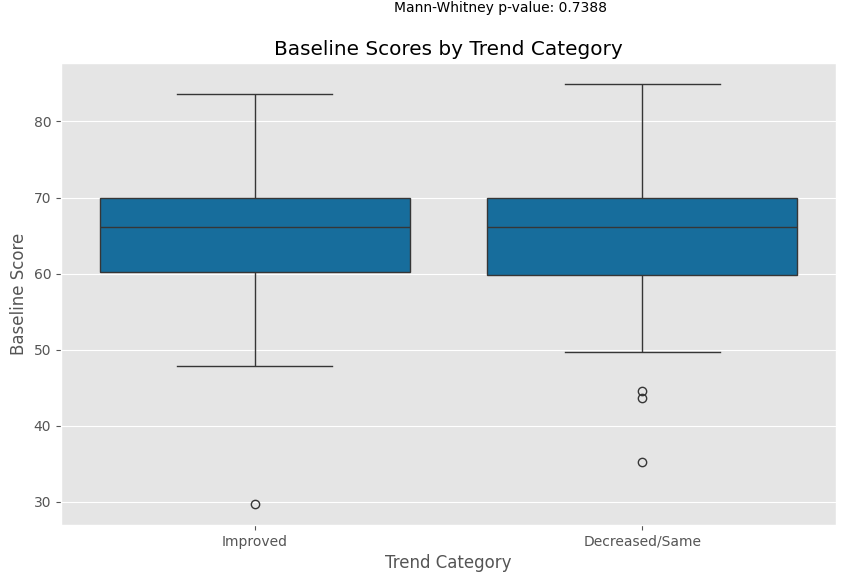

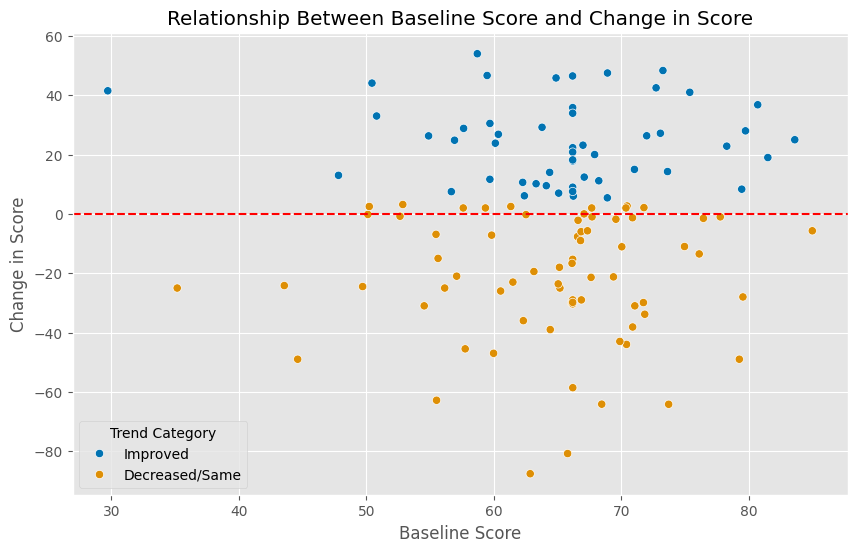

In [153]:
# Visualize with boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x="Trend Category", y="age_diagnosis", data=merged_df_removedNA_age)
plt.title("Baseline Scores by Trend Category")
plt.xlabel("Trend Category")
plt.ylabel("Baseline Score")
plt.annotate(f"Mann-Whitney p-value: {p_value:.4f}", xy=(0.5, 0.95), 
             xycoords='figure fraction', ha='center')
plt.show()



# Create a scatter plot of Baseline vs Change
plt.figure(figsize=(10, 6))
sns.scatterplot(x="age_diagnosis", y="Change", 
                hue="Trend Category", 
                data=merged_df_removedNA_age)
plt.title("Relationship Between Baseline Score and Change in Score")
plt.xlabel("Baseline Score")
plt.ylabel("Change in Score")
plt.axhline(y=0, color='r', linestyle='--')  # Add a horizontal line at y=0
plt.legend(title="Trend Category")
plt.show()

# sensitivity analysis 9) age (age_diagnosis)

Sensitivity Analysis Results:
    threshold  improvement_rate  mean_age_improved  mean_age_not_improved  \
0           0          0.504132          65.012311              64.704859   
1           1          0.495868          64.978007              64.743640   
2           2          0.495868          64.978007              64.743640   
3           3          0.429752          65.191393              64.610001   
4           4          0.421488          65.433224              64.442116   
5           5          0.421488          65.433224              64.442116   
6           6          0.413223          65.363957              64.504854   
7           7          0.396694          65.407843              64.499535   
8           8          0.371901          65.592297              64.426173   
9           9          0.363636          65.277695              64.621090   
10         10          0.347107          65.284010              64.634356   

    mann_whitney_p  logistic_p  odds_ratio  


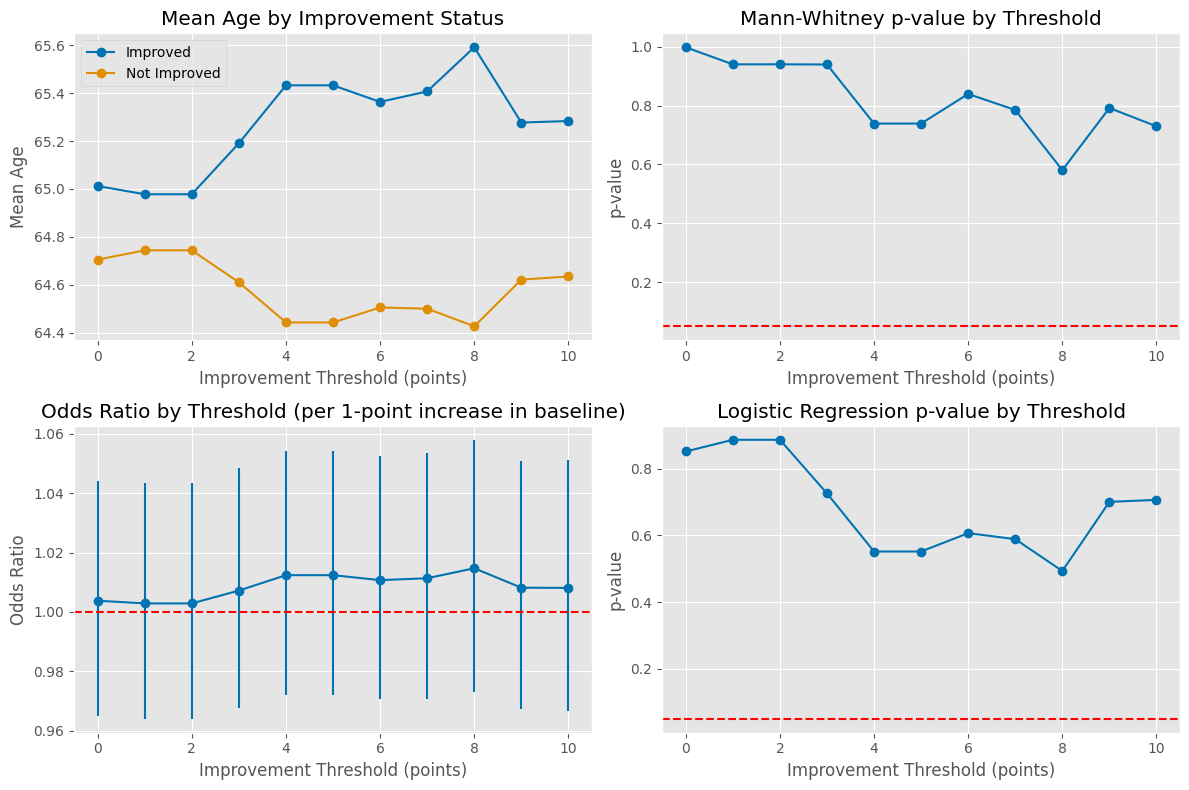


Patient Counts at Different Thresholds:
    Threshold  Improved Count  Decreased/Same Count  Improved %  \
0           0              61                    60   50.413223   
1           1              60                    61   49.586777   
2           2              60                    61   49.586777   
3           3              52                    69   42.975207   
4           4              51                    70   42.148760   
5           5              51                    70   42.148760   
6           6              50                    71   41.322314   
7           7              48                    73   39.669421   
8           8              45                    76   37.190083   
9           9              44                    77   36.363636   
10         10              42                    79   34.710744   

    Decreased/Same %  
0          49.586777  
1          50.413223  
2          50.413223  
3          57.024793  
4          57.851240  
5          57.85

In [154]:
def analyze_improvement_threshold(data, threshold):
    """
    Analyze how the improvement threshold affects classification and baseline score relationship
    
    Parameters:
    data: DataFrame containing Baseline and Change scores
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the new threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    df["Trend Category_binary"] = df["Improved"].astype(int)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count
    
    # Mann-Whitney U test
    improved_baseline = df[df["Improved"]]["age_diagnosis"]
    decreased_same_baseline = df[~df["Improved"]]["age_diagnosis"]
    
    if len(improved_baseline) > 0 and len(decreased_same_baseline) > 0:
        stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
    else:
        stat, p_value = None, None
        
    # Mean age_diagnosis in each group
    mean_age_improved = improved_baseline.mean() if len(improved_baseline) > 0 else None
    mean_age_not_improved = decreased_same_baseline.mean() if len(decreased_same_baseline) > 0 else None
    
    # Logistic regression
    X = sm.add_constant(df["age_diagnosis"])
    y = df["Trend Category_binary"]
    
    try:
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        baseline_coef = result.params["age_diagnosis"]
        baseline_p = result.pvalues["age_diagnosis"]
        odds_ratio = np.exp(baseline_coef)
        
        # Confidence intervals
        baseline_conf_int = result.conf_int().loc["age_diagnosis"]
        lower_ci = np.exp(baseline_conf_int[0])
        upper_ci = np.exp(baseline_conf_int[1])
    except:
        baseline_coef = None
        baseline_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "mean_age_improved": mean_age_improved,
        "mean_age_not_improved": mean_age_not_improved,
        "mann_whitney_stat": stat,
        "mann_whitney_p": p_value,
        "logistic_coef": baseline_coef,
        "logistic_p": baseline_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Prepare clean dataset
merged_df_clean = merged_df_age.dropna(subset=["age_diagnosis", "Change"]).drop_duplicates()

for threshold in thresholds:
    result = analyze_improvement_threshold(merged_df_clean, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis Results:")
print(sensitivity_df[["threshold", "improvement_rate", "mean_age_improved", "mean_age_not_improved", "mann_whitney_p", "logistic_p", "odds_ratio"]])

# Plot how improvement rate changes with threshold
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_age_improved"], 'o-', label='Improved')
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_age_not_improved"], 'o-', label='Not Improved')
plt.title("Mean Age by Improvement Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Mean Age")
plt.legend()
plt.grid(True)

# Plot p-values from Mann-Whitney test
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mann_whitney_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Mann-Whitney p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot odds ratios from logistic regression
plt.subplot(2, 2, 3)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio by Threshold (per 1-point increase in baseline)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

# Plot p-values from logistic regression
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["logistic_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Create a table showing the number and percentage of patients in each category at different thresholds
category_counts = []

for threshold in thresholds:
    df_temp = merged_df_clean.copy()
    df_temp["Improved"] = df_temp["Change"] >= threshold
    improved_count = df_temp["Improved"].sum()
    total = len(df_temp)
    
    category_counts.append({
        "Threshold": threshold,
        "Improved Count": improved_count,
        "Decreased/Same Count": total - improved_count,
        "Improved %": (improved_count / total) * 100,
        "Decreased/Same %": ((total - improved_count) / total) * 100
    })

category_df = pd.DataFrame(category_counts)
print("\nPatient Counts at Different Thresholds:")
print(category_df)

# statistically significantly associated with 10) sex

In [155]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [156]:
# Merge score_comparison with gender data
merged_df_gender = score_comparison.merge(filtered_df[["id", "gender"]], on="id", how="left")

print(merged_df_gender['gender'].value_counts())

# Find patient IDs where all gender values are missing
patients_all_missing = merged_df_gender.groupby('id')['gender'].apply(lambda x: x.isna().all())
patients_to_impute = patients_all_missing[patients_all_missing].index

# Impute gender for those patients with 9999.0 (unknown/missing indicator)
mask = merged_df_gender['id'].isin(patients_to_impute)
merged_df_gender.loc[mask, 'gender'] = 9999.0

print(f"Imputed {len(patients_to_impute)} missing data patients with gender = 9999.0 (unknown)")

# Create a clean dataframe with no missing values in gender
merged_df_removedNA_gender = merged_df_gender.dropna(subset=["gender"])
merged_df_expanded_gender = merged_df_removedNA_gender.drop_duplicates()
merged_df_removedNA_gender = merged_df_expanded_gender.copy()


print(merged_df_removedNA_gender['gender'].value_counts())
merged_df_removedNA_gender


gender
1.0    97
2.0    27
Name: count, dtype: int64
Imputed 0 missing data patients with gender = 9999.0 (unknown)
gender
1.0    95
2.0    26
Name: count, dtype: int64


,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,gender
4,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,1.0
11,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,1.0
19,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,1.0
28,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,1.0
40,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,2.0
...,...,...,...,...,...,...,...,...
1301,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,1.0
1305,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,1.0
1313,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,1.0
1327,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,1.0


In [157]:
# Create gender status labels
gender_labels = {1: "Male", 2: "Female"}
merged_df_removedNA_gender["gender_status"] = merged_df_removedNA_gender["gender"].map(gender_labels)

# Show summary statistics by improvement group and gender status
print("\nCrosstab of Gender Status and Trend Category:")
contingency_table = pd.crosstab(merged_df_removedNA_gender["gender_status"], 
                                merged_df_removedNA_gender["Trend Category"])
print(contingency_table)


Crosstab of Gender Status and Trend Category:
Trend Category  Decreased/Same  Improved
gender_status                           
Female                      18         8
Male                        52        43


In [158]:
# Chi-square test
chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nChi-square test:")
print(f"Chi-square statistic: {chi2}")
print(f"p-value: {p_value_chi2}")
print(f"Degrees of freedom: {dof}")


Chi-square test:
Chi-square statistic: 1.2144905533063424
p-value: 0.27044459937112625
Degrees of freedom: 1


In [159]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_gender["Trend Category_binary"] = merged_df_removedNA_gender["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Clean data for logistic regression
clean_data = merged_df_removedNA_gender.dropna(subset=["gender", "Trend Category_binary"])

# Logistic regression with one-hot encoding for categorical gender variable
gender_dummies = pd.get_dummies(clean_data["gender"], prefix="gender", drop_first=True).astype(int)
X = sm.add_constant(gender_dummies)
y = clean_data["Trend Category_binary"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print("\nLogistic Regression Results:")
print(result.summary())


Optimization terminated successfully.
         Current function value: 0.673308
         Iterations 5

Logistic Regression Results:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  121
Model:                             Logit   Df Residuals:                      119
Method:                              MLE   Df Model:                            1
Date:                   Wed, 25 Jun 2025   Pseudo R-squ.:                 0.01096
Time:                           11:41:53   Log-Likelihood:                -81.470
converged:                          True   LL-Null:                       -82.373
Covariance Type:               nonrobust   LLR p-value:                    0.1791
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1900      0.206     -0.922      0.357

In [160]:
# Calculate proportions for plotting
proportion_data = []
for gender_val, label in gender_labels.items():
    subset = merged_df_removedNA_gender[merged_df_removedNA_gender["gender"] == gender_val]
    if len(subset) > 0:
        improved_count = len(subset[subset["Trend Category"] == "Improved"])
        total_count = len(subset)
        proportion = improved_count / total_count
        proportion_data.append({
            "gender_status": label,
            "proportion_improved": proportion,
            "total_count": total_count,
            "improved_count": improved_count
        })

proportion_df = pd.DataFrame(proportion_data)
print(f"\nProportion of improvement by gender status:")
print(proportion_df)


Proportion of improvement by gender status:
  gender_status  proportion_improved  total_count  improved_count
0          Male             0.452632           95              43
1        Female             0.307692           26               8


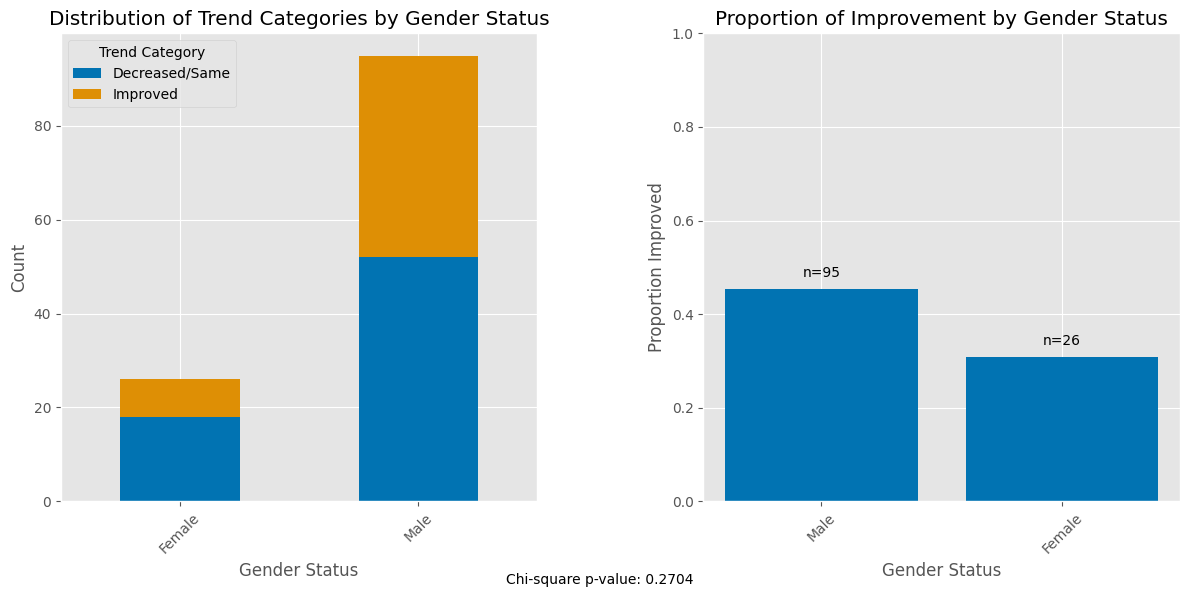

In [161]:
# Visualize with bar plot showing proportions
plt.figure(figsize=(12, 6))

# Subplot 1: Contingency table as stacked bar chart
plt.subplot(1, 2, 1)
contingency_table.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title("Distribution of Trend Categories by Gender Status")
plt.xlabel("Gender Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Trend Category")

# Subplot 2: Proportion of improvement by gender status
plt.subplot(1, 2, 2)
bars = plt.bar(proportion_df["gender_status"], proportion_df["proportion_improved"])
plt.title("Proportion of Improvement by Gender Status")
plt.xlabel("Gender Status")
plt.ylabel("Proportion Improved")
plt.xticks(rotation=45)
plt.ylim(0, 1)

# Add count labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'n={proportion_df.iloc[i]["total_count"]}',
             ha='center', va='bottom')

plt.annotate(f"Chi-square p-value: {p_value_chi2:.4f}", xy=(0.5, 0.02), 
             xycoords='figure fraction', ha='center')

plt.tight_layout()
plt.show()

# sensitivity analysis 10) sex

Sensitivity Analysis Results:
    threshold  improvement_rate    chi2_p  logistic_p  odds_ratio
0           0          0.504132  0.788007    0.624302    0.804665
1           1          0.495868  0.862039    0.692940    0.839286
2           2          0.495868  0.862039    0.692940    0.839286
3           3          0.429752  0.454313    0.333259    0.640219
4           4          0.421488  0.270445    0.188619    0.537468
5           5          0.421488  0.270445    0.188619    0.537468
6           6          0.413223  0.313188    0.220954    0.560847
7           7          0.396694  0.202965    0.138604    0.485237
8           8          0.371901  0.146660    0.082796    0.430769
9           9          0.363636  0.174019    0.052859    0.450000
10         10          0.347107  0.240450    0.019495    0.491667


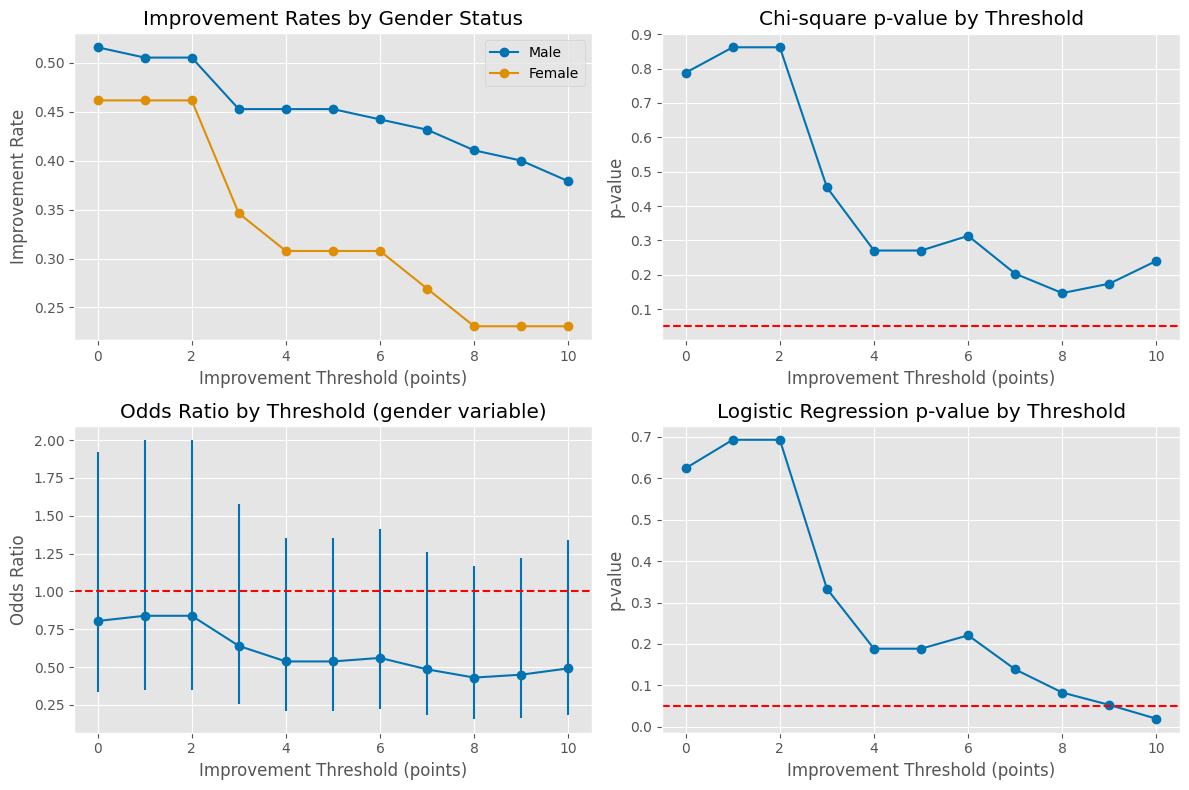


Patient Counts at Different Thresholds:
    Threshold  Improved Count  Decreased/Same Count  Improved %  \
0           0              61                    60   50.413223   
1           1              60                    61   49.586777   
2           2              60                    61   49.586777   
3           3              52                    69   42.975207   
4           4              51                    70   42.148760   
5           5              51                    70   42.148760   
6           6              50                    71   41.322314   
7           7              48                    73   39.669421   
8           8              45                    76   37.190083   
9           9              44                    77   36.363636   
10         10              42                    79   34.710744   

    Decreased/Same %  
0          49.586777  
1          50.413223  
2          50.413223  
3          57.024793  
4          57.851240  
5          57.85

In [162]:
def analyze_improvement_threshold_gender(data, threshold):
    """
    Analyze how the improvement threshold affects classification and gender status relationship
    
    Parameters:
    data: DataFrame containing gender and Change scores
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the new threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    df["Trend Category_binary"] = df["Improved"].astype(int)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count
    
    # Chi-square test
    try:
        contingency = pd.crosstab(df["gender"], df["Improved"])
        chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency)
    except:
        chi2, p_value_chi2 = None, None
    
    # Logistic regression with one-hot encoding
    try:
        gender_dummies = pd.get_dummies(df["gender"], prefix="gender", drop_first=True).astype(int)
        X = sm.add_constant(gender_dummies)
        y = df["Trend Category_binary"]
        
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        logistic_p = result.pvalues.min()  # Get minimum p-value from all gender coefficients
        
        # Get odds ratios and confidence intervals
        odds_ratios = np.exp(result.params[1:])  # Exclude intercept
        conf_int = result.conf_int()
        odds_ratio_lower_ci = np.exp(conf_int.iloc[1:, 0])  # Lower CI for gender variables
        odds_ratio_upper_ci = np.exp(conf_int.iloc[1:, 1])  # Upper CI for gender variables
        
        # Take the first gender variable's odds ratio as representative
        odds_ratio = odds_ratios.iloc[0] if len(odds_ratios) > 0 else None
        lower_ci = odds_ratio_lower_ci.iloc[0] if len(odds_ratio_lower_ci) > 0 else None
        upper_ci = odds_ratio_upper_ci.iloc[0] if len(odds_ratio_upper_ci) > 0 else None
        
    except:
        logistic_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "chi2_stat": chi2,
        "chi2_p": p_value_chi2,
        "logistic_p": logistic_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Prepare clean dataset
merged_df_clean_gender = merged_df_gender.dropna(subset=["gender", "Change"]).drop_duplicates()
merged_df_clean_gender["gender"] = pd.to_numeric(merged_df_clean_gender["gender"], errors='coerce')
merged_df_clean_gender = merged_df_clean_gender.dropna(subset=["gender"])

for threshold in thresholds:
    result = analyze_improvement_threshold_gender(merged_df_clean_gender, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis Results:")
print(sensitivity_df[["threshold", "improvement_rate", "chi2_p", "logistic_p", "odds_ratio"]])

# Plot how improvement rate changes with threshold
plt.figure(figsize=(12, 8))

# Plot improvement rates by gender status
plt.subplot(2, 2, 1)
for gender_val, label in gender_labels.items():
    rates = []
    for threshold in thresholds:
        subset = merged_df_clean_gender[merged_df_clean_gender["gender"] == gender_val]
        if len(subset) > 0:
            improved = (subset["Change"] >= threshold).sum()
            rate = improved / len(subset)
            rates.append(rate)
        else:
            rates.append(0)
    plt.plot(thresholds, rates, 'o-', label=label)

plt.title("Improvement Rates by Gender Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Improvement Rate")
plt.legend()
plt.grid(True)

# Plot p-values from Chi-square test (equivalent to Mann-Whitney for categorical)
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["chi2_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Chi-square p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot odds ratios from logistic regression
plt.subplot(2, 2, 3)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio by Threshold (gender variable)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

# Plot p-values from logistic regression
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["logistic_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Create a table showing the number and percentage of patients in each category at different thresholds
category_counts = []

for threshold in thresholds:
    df_temp = merged_df_clean_gender.copy()
    df_temp["Improved"] = df_temp["Change"] >= threshold
    improved_count = df_temp["Improved"].sum()
    total = len(df_temp)
    
    category_counts.append({
        "Threshold": threshold,
        "Improved Count": improved_count,
        "Decreased/Same Count": total - improved_count,
        "Improved %": (improved_count / total) * 100,
        "Decreased/Same %": ((total - improved_count) / total) * 100
    })

category_df = pd.DataFrame(category_counts)
print("\nPatient Counts at Different Thresholds:")
print(category_df)

# statistically significantly associated with 11) charlson comorbidity index (cci_total)

In [163]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [164]:
merged_df_cci = score_comparison.merge(filtered_df[["id", "cci_total"]], on="id", how="left")

# Calculate median cci from all non-missing values
median_cci = merged_df_cci['cci_total'].median()

# Find patient IDs where all cci values are missing
patients_all_missing = merged_df_cci.groupby('id')['cci_total'].apply(lambda x: x.isna().all())
patients_to_impute = patients_all_missing[patients_all_missing].index

# Impute cci for those patients
mask = merged_df_cci['id'].isin(patients_to_impute)
merged_df_cci.loc[mask, 'cci_total'] = median_cci
print(f"Imputed {len(patients_to_impute)} patients with median cci: {median_cci:.2f}")

# Create a clean dataframe with no missing values in cci
merged_df_removedNA_cci = merged_df_cci.dropna(subset=["cci_total"])
merged_df_expanded_cci = merged_df_removedNA_cci.drop_duplicates()
merged_df_removedNA_cci = merged_df_expanded_cci.copy()
merged_df_removedNA_cci

Imputed 25 patients with median cci: 4.00


,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,cci_total
4,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,2.0
10,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,4.0
18,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,4.0
28,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,4.0
40,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,4.0
...,...,...,...,...,...,...,...,...
1301,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,4.0
1305,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,6.0
1313,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,4.0
1327,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,4.0


In [165]:
# Show summary statistics by improvement group
print("\nBaseline scores by Trend Category:")
print(merged_df_removedNA_cci.groupby("Trend Category")["cci_total"].describe())


Baseline scores by Trend Category:
                count      mean       std  min  25%  50%  75%  max
Trend Category                                                    
Decreased/Same   70.0  3.857143  1.506370  0.0  3.0  4.0  5.0  9.0
Improved         51.0  4.274510  1.563054  2.0  4.0  4.0  5.0  9.0


In [166]:
# Perform Mann-Whitney U test to compare Baseline scores between groups
improved_baseline = merged_df_removedNA_cci[merged_df_removedNA_cci["Trend Category"] == "Improved"]["cci_total"]
decreased_same_baseline = merged_df_removedNA_cci[merged_df_removedNA_cci["Trend Category"] == "Decreased/Same"]["cci_total"]

stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
print(f"\nMann-Whitney U test:")
print(f"Statistic: {stat}")
print(f"p-value: {p_value}")



Mann-Whitney U test:
Statistic: 2007.0
p-value: 0.22481991283384006


In [167]:
# Convert categorical variable to binary (1 = Improved, 0 = Decreased/Same)
merged_df_removedNA_cci["Trend Category_binary"] = merged_df_removedNA_cci["Trend Category"].map(
    {"Improved": 1, "Decreased/Same": 0}
)

# Logistic regression with Baseline as predictor
X = sm.add_constant(merged_df_removedNA_cci["cci_total"])
y = merged_df_removedNA_cci["Trend Category_binary"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print("\nLogistic Regression Results:")
print(result.summary())


Optimization terminated successfully.
         Current function value: 0.671658
         Iterations 4

Logistic Regression Results:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  121
Model:                             Logit   Df Residuals:                      119
Method:                              MLE   Df Model:                            1
Date:                   Wed, 25 Jun 2025   Pseudo R-squ.:                 0.01338
Time:                           11:41:55   Log-Likelihood:                -81.271
converged:                          True   LL-Null:                       -82.373
Covariance Type:               nonrobust   LLR p-value:                    0.1376
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.0506      0.538     -1.953      0.051


Odds Ratio for a 10-point increase in baseline score: 6.092
95% CI for a 10-point increase in baseline score: (0.541, 68.618)


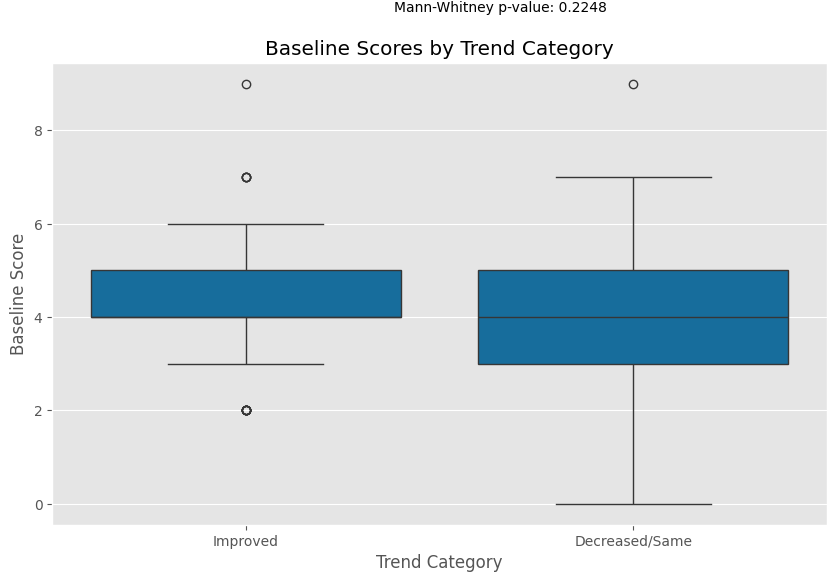

In [168]:
# Calculate odds ratio for a 10-point increase in baseline score
baseline_coef = result.params["cci_total"]
odds_ratio_10points = np.exp(baseline_coef * 10)
print(f"\nOdds Ratio for a 10-point increase in baseline score: {odds_ratio_10points:.3f}")

# Calculate confidence interval for the odds ratio
baseline_conf_int = result.conf_int().loc["cci_total"]
lower_ci_10points = np.exp(baseline_conf_int[0] * 10)
upper_ci_10points = np.exp(baseline_conf_int[1] * 10)
print(f"95% CI for a 10-point increase in baseline score: ({lower_ci_10points:.3f}, {upper_ci_10points:.3f})")

# Visualize with boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x="Trend Category", y="cci_total", data=merged_df_removedNA_cci)
plt.title("Baseline Scores by Trend Category")
plt.xlabel("Trend Category")
plt.ylabel("Baseline Score")
plt.annotate(f"Mann-Whitney p-value: {p_value:.4f}", xy=(0.5, 0.95), 
             xycoords='figure fraction', ha='center')
plt.show()


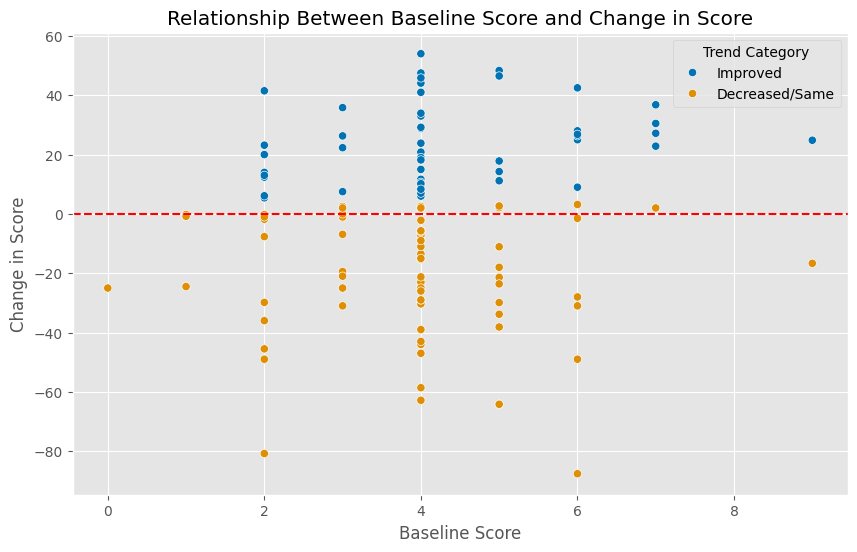

In [169]:
# Create a scatter plot of Baseline vs Change
plt.figure(figsize=(10, 6))
sns.scatterplot(x="cci_total", y="Change", 
                hue="Trend Category", 
                data=merged_df_removedNA_cci)
plt.title("Relationship Between Baseline Score and Change in Score")
plt.xlabel("Baseline Score")
plt.ylabel("Change in Score")
plt.axhline(y=0, color='r', linestyle='--')  # Add a horizontal line at y=0
plt.legend(title="Trend Category")
plt.show()

# sensitivity analysis 11) charlson comorbidity index (cci_total)

Sensitivity Analysis Results:
    threshold  improvement_rate  mean_cci_improved  mean_cci_not_improved  \
0           0          0.504132           4.295082               3.766667   
1           1          0.495868           4.316667               3.754098   
2           2          0.495868           4.316667               3.754098   
3           3          0.429752           4.307692               3.826087   
4           4          0.421488           4.274510               3.857143   
5           5          0.421488           4.274510               3.857143   
6           6          0.413223           4.320000               3.830986   
7           7          0.396694           4.375000               3.808219   
8           8          0.371901           4.422222               3.802632   
9           9          0.363636           4.431818               3.805195   
10         10          0.347107           4.404762               3.835443   

    mann_whitney_p  logistic_p  odds_ratio  


<Figure size 1000x600 with 0 Axes>

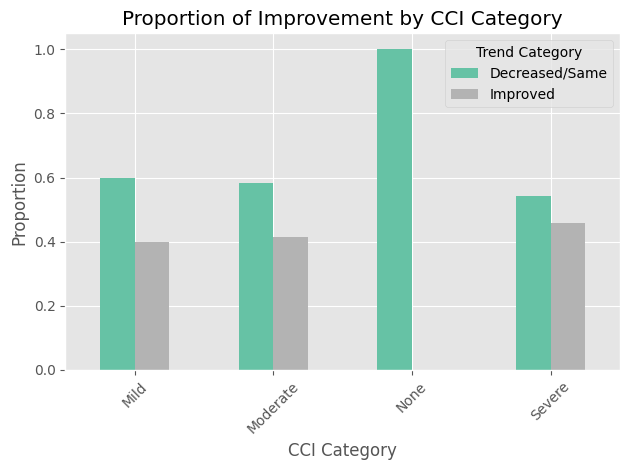

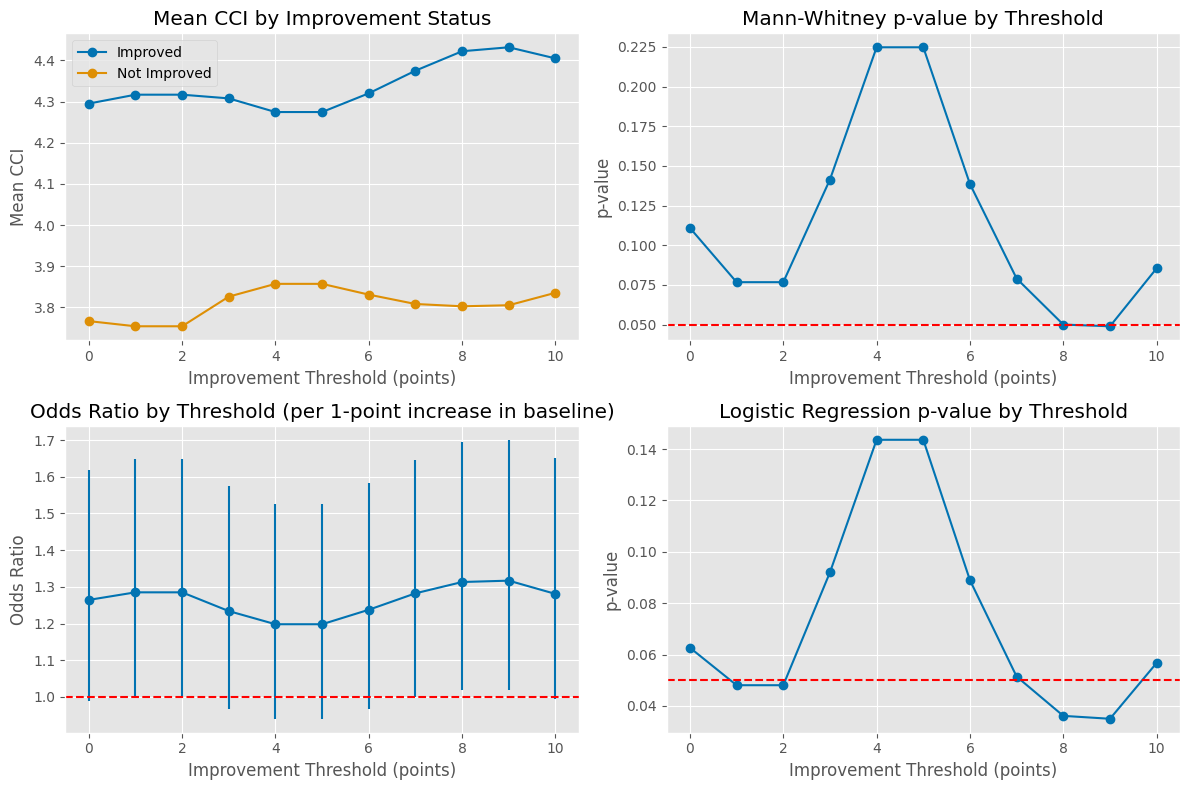


Patient Counts at Different Thresholds:
    Threshold  Improved Count  Decreased/Same Count  Improved %  \
0           0              61                    60   50.413223   
1           1              60                    61   49.586777   
2           2              60                    61   49.586777   
3           3              52                    69   42.975207   
4           4              51                    70   42.148760   
5           5              51                    70   42.148760   
6           6              50                    71   41.322314   
7           7              48                    73   39.669421   
8           8              45                    76   37.190083   
9           9              44                    77   36.363636   
10         10              42                    79   34.710744   

    Decreased/Same %  
0          49.586777  
1          50.413223  
2          50.413223  
3          57.024793  
4          57.851240  
5          57.85

In [170]:
def analyze_improvement_threshold(data, threshold):
    """
    Analyze how the improvement threshold affects classification and baseline score relationship
    
    Parameters:
    data: DataFrame containing Baseline and Change scores
    threshold: The minimum Change value to classify as "Improved"
    
    Returns:
    Dictionary containing analysis results
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Create improvement category based on the new threshold
    df["Improved"] = df["Change"] >= threshold
    df["Trend Category"] = df["Improved"].map({True: "Improved", False: "Decreased/Same"})
    df["Trend Category_binary"] = df["Improved"].astype(int)
    
    # Count patients in each category
    improved_count = df["Improved"].sum()
    total_count = len(df)
    improvement_rate = improved_count / total_count
    
    # Mann-Whitney U test
    improved_baseline = df[df["Improved"]]["cci_total"]
    decreased_same_baseline = df[~df["Improved"]]["cci_total"]
    
    if len(improved_baseline) > 0 and len(decreased_same_baseline) > 0:
        stat, p_value = stats.mannwhitneyu(improved_baseline, decreased_same_baseline)
    else:
        stat, p_value = None, None
        
    # Mean cci_total in each group
    mean_cci_improved = improved_baseline.mean() if len(improved_baseline) > 0 else None
    mean_cci_not_improved = decreased_same_baseline.mean() if len(decreased_same_baseline) > 0 else None
    
    # Logistic regression
    X = sm.add_constant(df["cci_total"])
    y = df["Trend Category_binary"]
    
    try:
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)
        baseline_coef = result.params["cci_total"]
        baseline_p = result.pvalues["cci_total"]
        odds_ratio = np.exp(baseline_coef)
        
        # Confidence intervals
        baseline_conf_int = result.conf_int().loc["cci_total"]
        lower_ci = np.exp(baseline_conf_int[0])
        upper_ci = np.exp(baseline_conf_int[1])
    except:
        baseline_coef = None
        baseline_p = None
        odds_ratio = None
        lower_ci = None
        upper_ci = None
    
    return {
        "threshold": threshold,
        "improved_count": improved_count,
        "total_count": total_count,
        "improvement_rate": improvement_rate,
        "mean_cci_improved": mean_cci_improved,
        "mean_cci_not_improved": mean_cci_not_improved,
        "mann_whitney_stat": stat,
        "mann_whitney_p": p_value,
        "logistic_coef": baseline_coef,
        "logistic_p": baseline_p,
        "odds_ratio": odds_ratio,
        "odds_ratio_lower_ci": lower_ci,
        "odds_ratio_upper_ci": upper_ci
    }

# Run the analysis for different thresholds
thresholds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

# Prepare clean dataset
merged_df_clean = merged_df_cci.dropna(subset=["cci_total", "Change"]).drop_duplicates()

for threshold in thresholds:
    result = analyze_improvement_threshold(merged_df_clean, threshold)
    results.append(result)

# Convert results to DataFrame for easier analysis
sensitivity_df = pd.DataFrame(results)

# Display results
print("Sensitivity Analysis Results:")
print(sensitivity_df[["threshold", "improvement_rate", "mean_cci_improved", "mean_cci_not_improved", "mann_whitney_p", "logistic_p", "odds_ratio"]])

print("\n### Analysis with CCI categories ###")
# Define clinical CCI categories
def categorize_cci(cci):
    if cci == 0:
        return "None"
    elif cci <= 2:
        return "Mild"
    elif cci <= 4:
        return "Moderate"
    else:
        return "Severe"

# Add CCI category column
merged_df_clean["cci_category"] = merged_df_clean["cci_total"].apply(categorize_cci)

# Create contingency table
contingency_table_cci = pd.crosstab(merged_df_clean["Trend Category"],
                                    merged_df_clean["cci_category"])
print("Contingency Table:")
print(contingency_table_cci)

# Chi-square test
chi2_stat, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_table_cci)
print(f"Chi-Square Test p-value: {p_value_chi2}")

# Visualize the relationship between CCI categories and Trend Category
plt.figure(figsize=(10, 6))
proportions = pd.crosstab(merged_df_clean["cci_category"],
                         merged_df_clean["Trend Category"],
                         normalize="index")
proportions.plot(kind="bar", stacked=False, colormap="Set2")
plt.title("Proportion of Improvement by CCI Category")
plt.xlabel("CCI Category")
plt.ylabel("Proportion")
plt.legend(title="Trend Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot how improvement rate changes with threshold
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_cci_improved"], 'o-', label='Improved')
plt.plot(sensitivity_df["threshold"], sensitivity_df["mean_cci_not_improved"], 'o-', label='Not Improved')
plt.title("Mean CCI by Improvement Status")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Mean CCI")
plt.legend()
plt.grid(True)

# Plot p-values from Mann-Whitney test
plt.subplot(2, 2, 2)
plt.plot(sensitivity_df["threshold"], sensitivity_df["mann_whitney_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Mann-Whitney p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

# Plot odds ratios from logistic regression
plt.subplot(2, 2, 3)
plt.errorbar(
    sensitivity_df["threshold"], 
    sensitivity_df["odds_ratio"],
    yerr=[
        sensitivity_df["odds_ratio"] - sensitivity_df["odds_ratio_lower_ci"],
        sensitivity_df["odds_ratio_upper_ci"] - sensitivity_df["odds_ratio"]
    ],
    fmt='o-'
)
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Odds Ratio by Threshold (per 1-point increase in baseline)")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("Odds Ratio")
plt.grid(True)

# Plot p-values from logistic regression
plt.subplot(2, 2, 4)
plt.plot(sensitivity_df["threshold"], sensitivity_df["logistic_p"], 'o-')
plt.axhline(y=0.05, color='r', linestyle='--')
plt.title("Logistic Regression p-value by Threshold")
plt.xlabel("Improvement Threshold (points)")
plt.ylabel("p-value")
plt.grid(True)

plt.tight_layout()
plt.show()

# Create a table showing the number and percentage of patients in each category at different thresholds
category_counts = []

for threshold in thresholds:
    df_temp = merged_df_clean.copy()
    df_temp["Improved"] = df_temp["Change"] >= threshold
    improved_count = df_temp["Improved"].sum()
    total = len(df_temp)
    
    category_counts.append({
        "Threshold": threshold,
        "Improved Count": improved_count,
        "Decreased/Same Count": total - improved_count,
        "Improved %": (improved_count / total) * 100,
        "Decreased/Same %": ((total - improved_count) / total) * 100
    })

category_df = pd.DataFrame(category_counts)
print("\nPatient Counts at Different Thresholds:")
print(category_df)

# Stepwise Multivariate logistic + Model Performance Evaluation

In [188]:
# Merge all the specific columns into merged_df_removedNA_baseline based on id
merged_df_total = merged_df_removedNA_baseline.merge(
    merged_df_removedNA_pwb[['id', 'pwb_subscale_score_baseline']], on='id', how='left'
    ).merge(
    merged_df_removedNA_swb[['id', 'swb_subscale_score_baseline']], on='id', how='left'
    ).merge(
    merged_df_removedNA_ewb[['id', 'ewb_subscale_score_baseline']], on='id', how='left'
    ).merge(
    merged_df_removedNA_fwb[['id', 'fwb_subscale_score_baseline']], on='id', how='left'
    ).merge(
    merged_df_removedNA_ecs[['id', 'ecs_subscale_score_baseline']], on='id', how='left'
    ).merge(
    merged_df_removedNA_bmi[['id', 'bmi']], on='id', how='left'
    ).merge(
    merged_df_removedNA_smoking[['id', 'smoking']], on='id', how='left'
    ).merge(
    merged_df_removedNA_alcohol[['id', 'alcohol']], on='id', how='left'
    ).merge(
    merged_df_removedNA_level[['id', 'level_tumor']], on='id', how='left'
    ).merge(
    merged_df_removedNA_tumorhistology[['id', 'path_histology']], on='id', how='left'
    ).merge(
    merged_df_removedNA_pathstage[['id', 'path_esoph_stage']], on='id', how='left'
    ).merge(
    merged_df_removedNA_procedure[['id', 'procedure123456']], on='id', how='left'
    ).merge(
    merged_df_removedNA_neotx[['id', 'neotx']], on='id', how='left'
    ).merge(
    merged_df_removedNA_age[['id', 'age_diagnosis']], on='id', how='left'
    ).merge(
    merged_df_removedNA_gender[['id', 'gender']], on='id', how='left'
    ).merge(
    merged_df_removedNA_cci[['id', 'cci_total']], on='id', how='left'
    )
merged_df_total

,id,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category,Trend Category_binary,pwb_subscale_score_baseline,swb_subscale_score_baseline,...,smoking,alcohol,level_tumor,path_histology,path_esoph_stage,procedure123456,neotx,age_diagnosis,gender,cci_total
0,32,baseline_arm_1,117.5,159.0,41.5,True,Improved,1,24.5,22.0,...,1.0,1.0,4.0,1.0,9999.0,1.0,2.0,29.722718,1.0,2.0
1,76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same,0,7.0,23.0,...,1.0,1.0,4.0,4.0,9999.0,1.0,2.0,57.597350,1.0,4.0
2,125,baseline_arm_1,119.5,129.0,9.5,True,Improved,1,21.0,17.5,...,3.0,0.0,4.0,4.0,3b,1.0,2.0,64.110830,1.0,4.0
3,160,baseline_arm_1,119.0,152.0,33.0,True,Improved,1,21.0,20.0,...,0.0,0.0,6.0,4.0,3b,1.0,2.0,50.804602,1.0,4.0
4,198,baseline_arm_1,133.0,139.0,6.0,True,Improved,1,25.0,13.0,...,9999.0,9999.0,4.0,8.0,9999.0,2.0,9999.0,66.229970,2.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same,0,23.0,24.0,...,3.0,1.0,6.0,4.0,9999.0,1.0,2.0,69.876863,1.0,4.0
122,1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same,0,26.0,28.0,...,0.0,0.0,6.0,1.0,9999.0,1.0,2.0,79.245980,1.0,6.0
123,1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same,0,27.0,13.0,...,3.0,2.0,6.0,8.0,9999.0,1.0,2.0,60.529648,1.0,4.0
124,1615,baseline_arm_1,126.0,111.0,-15.0,False,Decreased/Same,0,23.0,24.0,...,3.0,0.0,4.0,4.0,9999.0,1.0,2.0,55.623319,1.0,4.0


In [189]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Define the target variable
y = merged_df_total["Trend Category_binary"]

# Create dummy variables for categorical variables
smoking_dummies = pd.get_dummies(merged_df_total["smoking"], prefix="smoking", drop_first=True).astype(int)
alcohol_dummies = pd.get_dummies(merged_df_total["alcohol"], prefix="alcohol", drop_first=True).astype(int)
level_tumor_dummies = pd.get_dummies(merged_df_total["level_tumor"], prefix="level_tumor", drop_first=True).astype(int)
path_histology_dummies = pd.get_dummies(merged_df_total["path_histology"], prefix="path_histology", drop_first=True).astype(int)
path_esoph_stage_dummies = pd.get_dummies(merged_df_total["path_esoph_stage"], prefix="path_esoph_stage", drop_first=True).astype(int)
procedure123456_dummies = pd.get_dummies(merged_df_total["procedure123456"], prefix="procedure123456", drop_first=True).astype(int)
neotx_dummies = pd.get_dummies(merged_df_total["neotx"], prefix="neotx", drop_first=True).astype(int)
gender_dummies = pd.get_dummies(merged_df_total["gender"], prefix="gender", drop_first=True).astype(int)

# Define variable groups
modifiable_vars = pd.concat([
    merged_df_total["Baseline"],
    merged_df_total["pwb_subscale_score_baseline"],
    merged_df_total["swb_subscale_score_baseline"],
    merged_df_total["ewb_subscale_score_baseline"],
    merged_df_total["fwb_subscale_score_baseline"],
    merged_df_total["ecs_subscale_score_baseline"],
    merged_df_total["bmi"],
    smoking_dummies,
    alcohol_dummies
], axis=1)

tumor_chars = pd.concat([
    level_tumor_dummies,
    path_histology_dummies,
    path_esoph_stage_dummies
], axis=1)

treatment_chars = pd.concat([
    procedure123456_dummies,
    neotx_dummies
], axis=1)

demographics = pd.concat([
    merged_df_total["age_diagnosis"],
    gender_dummies,
    merged_df_total["cci_total"]
], axis=1)


In [190]:
# Function to calculate pseudo R-squared (McFadden's R-squared)
def mcfadden_r2(model_result):
    return 1 - (model_result.llf / model_result.llnull)

# Function to format results table
def format_results_table(model_result, model_name):
    # Get OR and 95% CI
    params = model_result.params
    conf_int = model_result.conf_int()
    pvalues = model_result.pvalues
    
    # Calculate OR and CI
    or_values = np.exp(params)
    or_ci_lower = np.exp(conf_int[0])
    or_ci_upper = np.exp(conf_int[1])
    
    # Create results dataframe
    results_df = pd.DataFrame({
        'Variable': params.index,
        'OR': or_values,
        'CI_Lower': or_ci_lower,
        'CI_Upper': or_ci_upper,
        'P_Value': pvalues
    })
    
    # Format the results
    results_df['OR_CI'] = results_df.apply(lambda x: f"{x['OR']:.3f} ({x['CI_Lower']:.3f}-{x['CI_Upper']:.3f})", axis=1)
    results_df['P_Value_formatted'] = results_df['P_Value'].apply(lambda x: f"{x:.3f}" if x >= 0.001 else "<0.001")
    
    print(f"\n=== {model_name} ===")
    print(results_df[['Variable', 'OR_CI', 'P_Value_formatted']].to_string(index=False))
    
    return results_df

# Function to calculate model performance metrics
def calculate_model_performance(model_result, X, y, model_name):
    # AIC
    aic = model_result.aic
    
    # Predicted probabilities
    y_pred_proba = model_result.predict(X)
    
    # AUC
    auc = roc_auc_score(y, y_pred_proba)
    
    # Pseudo R-squared
    pseudo_r2 = mcfadden_r2(model_result)
    
    return {
        'Model': model_name,
        'AIC': aic,
        'AUC': auc,
        'Pseudo_R2': pseudo_r2
    }


In [191]:
# Model 1: Modifiable variables only
print("Fitting Model 1: Modifiable variables only")
X1 = sm.add_constant(modifiable_vars)
model1 = sm.Logit(y, X1).fit()
results1 = format_results_table(model1, "Model 1: Modifiable Variables")
perf1 = calculate_model_performance(model1, X1, y, "Model 1")

Fitting Model 1: Modifiable variables only
Optimization terminated successfully.
         Current function value: 0.495809
         Iterations 7

=== Model 1: Modifiable Variables ===
                   Variable                        OR_CI P_Value_formatted
                      const 2728.181 (44.894-165789.468)            <0.001
                   Baseline         0.082 (0.000-24.757)             0.391
pwb_subscale_score_baseline      12.401 (0.041-3735.311)             0.387
swb_subscale_score_baseline      10.514 (0.035-3144.925)             0.419
ewb_subscale_score_baseline      11.584 (0.039-3481.751)             0.400
fwb_subscale_score_baseline      11.855 (0.039-3582.576)             0.396
ecs_subscale_score_baseline      11.125 (0.037-3335.988)             0.408
                        bmi          0.995 (0.920-1.075)             0.892
                smoking_1.0          0.203 (0.041-1.011)             0.052
                smoking_3.0          1.045 (0.310-3.522)          

In [192]:
# Model 2: Model 1 + tumor characteristics
print("\nFitting Model 2: Model 1 + Tumor characteristics")
X2 = sm.add_constant(pd.concat([modifiable_vars, tumor_chars], axis=1))
model2 = sm.Logit(y, X2).fit()
results2 = format_results_table(model2, "Model 2: + Tumor Characteristics")
perf2 = calculate_model_performance(model2, X2, y, "Model 2")


Fitting Model 2: Model 1 + Tumor characteristics
         Current function value: 0.416337
         Iterations: 35

=== Model 2: + Tumor Characteristics ===
                   Variable                           OR_CI P_Value_formatted
                      const               0.000 (0.000-inf)             0.999
                   Baseline             0.105 (0.001-9.158)             0.323
pwb_subscale_score_baseline           9.810 (0.112-860.627)             0.317
swb_subscale_score_baseline           8.315 (0.096-722.153)             0.352
ewb_subscale_score_baseline           8.783 (0.101-764.551)             0.340
fwb_subscale_score_baseline           9.153 (0.104-803.708)             0.332
ecs_subscale_score_baseline           8.709 (0.100-756.916)             0.342
                        bmi             0.986 (0.887-1.096)             0.795
                smoking_1.0             0.231 (0.033-1.622)             0.141
                smoking_3.0             1.089 (0.232-5.114)   

In [193]:
# Model 3: Model 2 + treatment characteristics
print("\nFitting Model 3: Model 2 + Treatment characteristics")
X3 = sm.add_constant(pd.concat([modifiable_vars, tumor_chars, treatment_chars], axis=1))
model3 = sm.Logit(y, X3).fit()
results3 = format_results_table(model3, "Model 3: + Treatment Characteristics")
perf3 = calculate_model_performance(model3, X3, y, "Model 3")


Fitting Model 3: Model 2 + Treatment characteristics
         Current function value: inf
         Iterations: 35


LinAlgError: Singular matrix

In [197]:
# Model 4: Model 3 + demographics
print("\nFitting Model 4: Model 3 + Demographics")
X4 = sm.add_constant(pd.concat([modifiable_vars, tumor_chars, treatment_chars, demographics], axis=1))
model4 = sm.Logit(y, X4).fit()
results4 = format_results_table(model4, "Model 4: + Demographics")
perf4 = calculate_model_performance(model4, X4, y, "Model 4")


Fitting Model 4: Model 3 + Demographics
         Current function value: inf
         Iterations: 35


LinAlgError: Singular matrix

In [195]:

# Create performance comparison table
performance_df = pd.DataFrame([perf1, perf2, perf3, perf4])
print("\n=== MODEL PERFORMANCE COMPARISON (Table 4) ===")
print(performance_df.round(3).to_string(index=False))

# Print model summaries for detailed review
print("\n=== DETAILED MODEL SUMMARIES ===")
print("\nModel 1 Summary:")
print(model1.summary())

print("\nModel 2 Summary:")
print(model2.summary())

print("\nModel 3 Summary:")
print(model3.summary())

print("\nModel 4 Summary:")
print(model4.summary())

# Store results for further analysis if needed
models = {
    'Model 1': model1,
    'Model 2': model2,
    'Model 3': model3,
    'Model 4': model4
}

results_tables = {
    'Model 1': results1,
    'Model 2': results2,
    'Model 3': results3,
    'Model 4': results4
}

NameError: name 'perf3' is not defined

In [196]:

# Create performance comparison table
performance_df = pd.DataFrame([perf1, perf2])
print("\n=== MODEL PERFORMANCE COMPARISON (Table 4) ===")
print(performance_df.round(3).to_string(index=False))

# Print model summaries for detailed review
print("\n=== DETAILED MODEL SUMMARIES ===")
print("\nModel 1 Summary:")
print(model1.summary())

print("\nModel 2 Summary:")
print(model2.summary())

print("\nModel 3 Summary:")
print(model3.summary())

print("\nModel 4 Summary:")
print(model4.summary())

# Store results for further analysis if needed
models = {
    'Model 1': model1,
    'Model 2': model2,
    'Model 3': model3,
    'Model 4': model4
}

results_tables = {
    'Model 1': results1,
    'Model 2': results2,
    'Model 3': results3,
    'Model 4': results4
}


=== MODEL PERFORMANCE COMPARISON (Table 4) ===
  Model     AIC   AUC  Pseudo_R2
Model 1 152.944 0.842      0.271
Model 2 176.917 0.892      0.388

=== DETAILED MODEL SUMMARIES ===

Model 1 Summary:
                             Logit Regression Results                            
Dep. Variable:     Trend Category_binary   No. Observations:                  126
Model:                             Logit   Df Residuals:                      112
Method:                              MLE   Df Model:                           13
Date:                   Wed, 25 Jun 2025   Pseudo R-squ.:                  0.2714
Time:                           12:12:34   Log-Likelihood:                -62.472
converged:                          True   LL-Null:                       -85.743
Covariance Type:               nonrobust   LLR p-value:                 1.155e-05
                                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------

NameError: name 'model3' is not defined

In [199]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Function to calculate VIF and check for multicollinearity
def check_multicollinearity(X, threshold=10):
    """
    Calculate VIF for each variable and identify multicollinear variables
    """
    print("\n=== MULTICOLLINEARITY CHECK ===")
    
    # Remove constant column for VIF calculation
    X_no_const = X.drop('const', axis=1) if 'const' in X.columns else X
    
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X_no_const.columns
    vif_data["VIF"] = [variance_inflation_factor(X_no_const.values, i) 
                       for i in range(len(X_no_const.columns))]
    
    # Sort by VIF value
    vif_data = vif_data.sort_values('VIF', ascending=False)
    
    print(f"VIF values (threshold = {threshold}):")
    print(vif_data.to_string(index=False))
    
    # Identify problematic variables
    high_vif = vif_data[vif_data['VIF'] > threshold]
    if len(high_vif) > 0:
        print(f"\nVariables with VIF > {threshold}:")
        print(high_vif['Variable'].tolist())
        return high_vif['Variable'].tolist()
    else:
        print(f"\nNo variables with VIF > {threshold}")
        return []

# Function to remove multicollinear variables iteratively
def remove_multicollinear_vars(X, threshold=10):
    """
    Remove variables with high VIF iteratively
    """
    X_clean = X.copy()
    
    while True:
        # Check for constant column
        if 'const' in X_clean.columns:
            X_for_vif = X_clean.drop('const', axis=1)
        else:
            X_for_vif = X_clean
            
        if len(X_for_vif.columns) == 0:
            break
            
        # Calculate VIF
        try:
            vif_values = [variance_inflation_factor(X_for_vif.values, i) 
                         for i in range(len(X_for_vif.columns))]
            max_vif = max(vif_values)
            max_vif_idx = vif_values.index(max_vif)
            max_vif_var = X_for_vif.columns[max_vif_idx]
            
            if max_vif > threshold:
                print(f"Removing {max_vif_var} (VIF = {max_vif:.2f})")
                X_clean = X_clean.drop(max_vif_var, axis=1)
            else:
                break
        except:
            print("Error in VIF calculation, stopping removal process")
            break
    
    return X_clean

# Function to check for perfect correlation and remove redundant variables
def remove_perfect_correlation(df, threshold=0.99):
    """
    Remove variables that are perfectly or near-perfectly correlated
    """
    corr_matrix = df.corr().abs()
    
    # Create a mask for the upper triangle
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Find variables with correlation above threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    if to_drop:
        print(f"Removing highly correlated variables (correlation > {threshold}): {to_drop}")
        df_clean = df.drop(to_drop, axis=1)
        return df_clean
    else:
        return df


# Check for multicollinearity issues before fitting models
print("=== CHECKING FOR MULTICOLLINEARITY ISSUES ===")

# Check each variable group separately first
print("\n1. Checking modifiable variables:")
modifiable_vars_clean = remove_perfect_correlation(modifiable_vars)
X1_temp = sm.add_constant(modifiable_vars_clean)
high_vif_vars = check_multicollinearity(X1_temp)

print("\n2. Checking tumor characteristics:")
tumor_chars_clean = remove_perfect_correlation(tumor_chars)
if len(tumor_chars_clean.columns) > 0:
    X_tumor_temp = sm.add_constant(tumor_chars_clean)
    high_vif_tumor = check_multicollinearity(X_tumor_temp)

print("\n3. Checking treatment characteristics:")
treatment_chars_clean = remove_perfect_correlation(treatment_chars)
if len(treatment_chars_clean.columns) > 0:
    X_treatment_temp = sm.add_constant(treatment_chars_clean)
    high_vif_treatment = check_multicollinearity(X_treatment_temp)

print("\n4. Checking demographics:")
demographics_clean = remove_perfect_correlation(demographics)
if len(demographics_clean.columns) > 0:
    X_demo_temp = sm.add_constant(demographics_clean)
    high_vif_demo = check_multicollinearity(X_demo_temp)

# Model 1: Modifiable variables only
print("\n=== FITTING MODELS ===")
print("Fitting Model 1: Modifiable variables only")
X1 = sm.add_constant(modifiable_vars_clean)
X1 = remove_multicollinear_vars(X1, threshold=10)
try:
    model1 = sm.Logit(y, X1).fit()
    results1 = format_results_table(model1, "Model 1: Modifiable Variables")
    perf1 = calculate_model_performance(model1, X1, y, "Model 1")
except Exception as e:
    print(f"Error fitting Model 1: {e}")
    model1, results1, perf1 = None, None, None

# Model 2: Model 1 + tumor characteristics
print("\nFitting Model 2: Model 1 + Tumor characteristics")
X2 = sm.add_constant(pd.concat([modifiable_vars_clean, tumor_chars_clean], axis=1))
X2 = remove_multicollinear_vars(X2, threshold=10)
try:
    model2 = sm.Logit(y, X2).fit()
    results2 = format_results_table(model2, "Model 2: + Tumor Characteristics")
    perf2 = calculate_model_performance(model2, X2, y, "Model 2")
except Exception as e:
    print(f"Error fitting Model 2: {e}")
    model2, results2, perf2 = None, None, None

# Model 3: Model 2 + treatment characteristics
print("\nFitting Model 3: Model 2 + Treatment characteristics")
X3 = sm.add_constant(pd.concat([modifiable_vars_clean, tumor_chars_clean, treatment_chars_clean], axis=1))
X3 = remove_multicollinear_vars(X3, threshold=10)
try:
    model3 = sm.Logit(y, X3).fit()
    results3 = format_results_table(model3, "Model 3: + Treatment Characteristics")
    perf3 = calculate_model_performance(model3, X3, y, "Model 3")
except Exception as e:
    print(f"Error fitting Model 3: {e}")
    model3, results3, perf3 = None, None, None

# Model 4: Model 3 + demographics
print("\nFitting Model 4: Model 3 + Demographics")
X4 = sm.add_constant(pd.concat([modifiable_vars_clean, tumor_chars_clean, treatment_chars_clean, demographics_clean], axis=1))
X4 = remove_multicollinear_vars(X4, threshold=10)
print(f"Final Model 4 variables: {list(X4.columns)}")
try:
    model4 = sm.Logit(y, X4).fit(maxiter=100)  # Increase max iterations
    results4 = format_results_table(model4, "Model 4: + Demographics")
    perf4 = calculate_model_performance(model4, X4, y, "Model 4")
except Exception as e:
    print(f"Error fitting Model 4: {e}")
    model4, results4, perf4 = None, None, None

# Create performance comparison table
valid_models = []
if perf1: valid_models.append(perf1)
if perf2: valid_models.append(perf2)
if perf3: valid_models.append(perf3)
if perf4: valid_models.append(perf4)

if valid_models:
    performance_df = pd.DataFrame(valid_models)
    print("\n=== MODEL PERFORMANCE COMPARISON (Table 4) ===")
    print(performance_df.round(3).to_string(index=False))

# Print model summaries for detailed review
print("\n=== DETAILED MODEL SUMMARIES ===")
if model1:
    print("\nModel 1 Summary:")
    print(model1.summary())

if model2:
    print("\nModel 2 Summary:")
    print(model2.summary())

if model3:
    print("\nModel 3 Summary:")
    print(model3.summary())

if model4:
    print("\nModel 4 Summary:")
    print(model4.summary())

# Store results for further analysis if needed
models = {}
results_tables = {}

if model1:
    models['Model 1'] = model1
    results_tables['Model 1'] = results1
if model2:
    models['Model 2'] = model2
    results_tables['Model 2'] = results2
if model3:
    models['Model 3'] = model3
    results_tables['Model 3'] = results3
if model4:
    models['Model 4'] = model4
    results_tables['Model 4'] = results4

=== CHECKING FOR MULTICOLLINEARITY ISSUES ===

1. Checking modifiable variables:

=== MULTICOLLINEARITY CHECK ===
VIF values (threshold = 10):
                   Variable           VIF
                   Baseline 578816.185853
ecs_subscale_score_baseline  86318.470923
pwb_subscale_score_baseline  18273.538660
swb_subscale_score_baseline  17421.032453
fwb_subscale_score_baseline  13252.881171
ewb_subscale_score_baseline   9451.796113
                        bmi     17.084270
             alcohol_9999.0     10.347200
             smoking_9999.0      9.641186
                alcohol_1.0      2.464889
                smoking_3.0      2.227356
                smoking_1.0      1.575977
                alcohol_2.0      1.332631

Variables with VIF > 10:
['Baseline', 'ecs_subscale_score_baseline', 'pwb_subscale_score_baseline', 'swb_subscale_score_baseline', 'fwb_subscale_score_baseline', 'ewb_subscale_score_baseline', 'bmi', 'alcohol_9999.0']

2. Checking tumor characteristics:
Removing highl


Fitting Model 2: Model 1 + Tumor characteristics
Removing Baseline (VIF = 613079.92)
Removing pwb_subscale_score_baseline (VIF = 38.53)
Removing bmi (VIF = 33.48)
Removing ecs_subscale_score_baseline (VIF = 29.47)
Removing swb_subscale_score_baseline (VIF = 28.30)
Removing ewb_subscale_score_baseline (VIF = 21.57)
Removing alcohol_9999.0 (VIF = 18.82)
Removing path_esoph_stage_9999.0 (VIF = 14.19)
Removing fwb_subscale_score_baseline (VIF = 11.98)
         Current function value: 0.569143
         Iterations: 35

=== Model 2: + Tumor Characteristics ===
           Variable                              OR_CI P_Value_formatted
              const                  0.000 (0.000-inf)             0.989
        smoking_1.0                0.688 (0.170-2.778)             0.599
        smoking_3.0                1.112 (0.346-3.571)             0.858
     smoking_9999.0                1.477 (0.434-5.030)             0.533
        alcohol_1.0                1.209 (0.436-3.350)             0.716
 